# MVPA L2 Results Notebook

This notebook is the manuscript-facing review layer for `PROJECT_CONTEXT.md`. Results are organized in the same hierarchy used for inference: primary confirmatory tests first, secondary mechanistic/contextual analyses second, and sensitivity tests last. This order is intentional so that visually striking exploratory findings do not displace the prespecified evidence.

Aim 1 follows the current project context: placebo-session `SAD` and `HC` participants are analyzed separately for `CSR` versus `CSS` decoding in the primary `FearNetwork` feature space. The primary readout is subject-level forced-choice accuracy against a subject-label permutation null; cross-group decoding is a secondary functional-specificity/generalization check; weight-vector similarity and Haufe-transformed patterns are secondary spatial-specificity evidence.

Aim 2 follows the current project context: placebo-session `SAD` versus `HC` differences are tested on the prespecified primary geometry, decision-certainty, and learning-dynamics metrics. Legacy decision-margin or boundary-separation exports are not promoted to the current Aim 2 primary family.

Aim 3 follows the current project context: `dass_anxiety` and `lsas_total` are primary clinical scores. `lsas_fear`, `lsas_avoid`, `dass_stress`, `dass_depression`, and `ecr_total` are shown only as secondary supporting evidence, not as primary endpoints.

The notebook is tolerant of missing optional outputs. The primary FearNetwork results are expected; MemoryFearNetwork and whole-brain/Schaefer sensitivity results are displayed when present and skipped when absent.


## Visualization And Reporting Principles

The figure style follows common high-impact MVPA/RSA reporting conventions: show the decoding evidence first, then representational geometry, learning dynamics, clinical/SCR association matrices, and sensitivity checks. The layout is inspired by multivoxel pattern and representational similarity work such as Haxby et al. (Science, 2001; DOI: `10.1126/science.1063736`), Norman et al. (Trends in Cognitive Sciences, 2006; DOI: `10.1016/j.tics.2006.07.005`), Kriegeskorte et al. (Frontiers in Systems Neuroscience, 2008; DOI: `10.3389/neuro.06.004.2008`), and Haufe et al. (NeuroImage, 2014; DOI: `10.1016/j.neuroimage.2013.10.067`) for interpretable linear-model activation patterns.

Reporting conventions:

- Primary tests are interpreted before secondary or sensitivity analyses.
- Aims 1-4 primary analyses are restricted to placebo-session subjects. SCR-defined subgroup sensitivity analyses for Aims 1-4 pool placebo and oxytocin participants to preserve subgroup sample size and include `Drug` as a covariate when modeled in the notebook. Aim 5 is the only analysis that tests full `Group x Drug` effects.
- Primary neural metrics use a stable, question-driven metric family for group differences, symptom and SCR associations, and drug effects:
  - Representational geometry: quantifies the representational distance between the vicarious threat cue (`CSR`) and the vicarious safety cue (`CSS`), using `CS-` as the baseline. `Neural_Safety_Differentiation = d(CSR, CS-) - d(CSS, CS-)`.
  - Decision-certainty metrics: `Neural_SafetyEvidence = P(safety | CSS)` and `Neural_ThreatEvidence = P(threat | CSR)`.
  - Single-trial trajectories: track dynamic, trial-by-trial updating of neural discrimination during extinction learning. `Neural_DynamicDiscrimination_Volatility` captures the root-mean-square of successive differences in `Delta_t = ThreatEvidence(CSR_t) - SafetyEvidence(CSS_t)`, `sqrt(mean((Delta_t - Delta_{t-1})^2))`.
- Aim 2-5 p-values for analyses involving the six primary neural metrics are FDR-corrected within each planned neural question; group, clinical, SCR, and metric-role boundaries are retained where they define the analysis family.
- Aim 4 treats `SCR_Safety_Trajectory_Slope` and `SCR_Threat_Trajectory_Slope` as primary SCR convergence indices; `SCR_SafetyMinusBackground` and `SCR_ThreatMinusSafety` are secondary.
- Aim 1 primary decoding uses subject-aware permutation inference; cross-group decoding and Haufe-map similarity are secondary mechanistic checks within the placebo session.
- Figures use colorblind-safe Okabe-Ito colors, signed effects centered at zero, individual subject points when available, and PNG/PDF export to `stats/figures`.


In [1]:
from pathlib import Path
import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 200)

OKABE = {
    'orange': '#E69F00',
    'sky': '#56B4E9',
    'green': '#009E73',
    'yellow': '#F0E442',
    'blue': '#0072B2',
    'vermillion': '#D55E00',
    'purple': '#CC79A7',
    'black': '#000000',
    'gray': '#7A7A7A',
}
GROUP_COLORS = {'SAD': OKABE['vermillion'], 'HC': OKABE['blue']}
DRUG_COLORS = {'Placebo': OKABE['gray'], 'Oxytocin': OKABE['green']}

sns.set_theme(style='ticks', context='paper', font='Arial', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

cwd_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in cwd_candidates if (p / 'PROJECT_CONTEXT.md').exists()), Path.cwd())
root_env = os.environ.get('MVPA_L2_ROOT')
candidates = []
if root_env:
    candidates.append(Path(root_env).expanduser())
candidates.extend([
    PROJECT_ROOT / 'outputs' / 'mvpa_l2',
    Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2'),
    Path('/gscratch/fang/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/mvpa_l2'),
    Path('/output_dir/mvpa_l2'),
])
def mvpa_root_ready(path):
    return (path / 'harmonized' / 'mvpa_l2_subject_metrics.csv').exists()

ready_candidates = [p for p in candidates if mvpa_root_ready(p)]
existing_candidates = [p for p in candidates if p.exists()]
MVPA_ROOT = ready_candidates[0] if ready_candidates else (existing_candidates[0] if existing_candidates else candidates[0])
if not MVPA_ROOT.exists():
    warnings.warn(f'MVPA_ROOT does not exist yet: {MVPA_ROOT}. Set MVPA_L2_ROOT to the post-Hyak result directory before running result cells.')
elif not mvpa_root_ready(MVPA_ROOT):
    warnings.warn(f'MVPA_ROOT exists but is missing harmonized/mvpa_l2_subject_metrics.csv: {MVPA_ROOT}. Set MVPA_L2_ROOT to the complete post-Hyak result directory.')
elif root_env is None and MVPA_ROOT.is_absolute() and not str(MVPA_ROOT).startswith(str(PROJECT_ROOT)):
    warnings.warn(f'Using external MVPA_ROOT fallback with complete inputs: {MVPA_ROOT}. Set MVPA_L2_ROOT for portable reruns.')
RESULTS_ROOT = MVPA_ROOT.parent if MVPA_ROOT.name == 'mvpa_l2' else MVPA_ROOT
HARMONIZED_DIR = MVPA_ROOT / 'harmonized'
STATS_DIR = MVPA_ROOT / 'stats'
FIG_DIR = STATS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'MVPA_ROOT = {MVPA_ROOT}')
print(f'RESULTS_ROOT = {RESULTS_ROOT}')
print(f'STATS_DIR = {STATS_DIR}')
print(f'FIG_DIR = {FIG_DIR}')


PROJECT_ROOT = /Users/xiaoqianxiao/PycharmProjects/narsad_multivoxel
MVPA_ROOT = /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2
RESULTS_ROOT = /Users/xiaoqianxiao/projects/NARSAD/LSS/results
STATS_DIR = /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats
FIG_DIR = /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_1870/400460881.py:69: UserWarning: Using external MVPA_ROOT fallback with complete inputs: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2. Set MVPA_L2_ROOT for portable reruns.
  warnings.warn(f'Using external MVPA_ROOT fallback with complete inputs: {MVPA_ROOT}. Set MVPA_L2_ROOT for portable reruns.')


In [ ]:
AIM1_EXPECTED_PERMUTATIONS = 5000
AIM1_EXPECTED_NESTED_CV_REPEATS = 10
AIM1_EXPECTED_OUTER_FOLDS = 5
AIM1_EXPECTED_INNER_FOLDS = 5
AIM1_CHANCE_LEVEL = 0.5

PRIMARY_NEURAL_METRICS = [
    'Neural_Safety_Differentiation',
    'Neural_SafetyEvidence',
    'Neural_ThreatEvidence',
    'Neural_DynamicDiscrimination_Volatility',
]

PRIMARY_NEURAL_METRIC_FAMILIES = {
    'Neural_Safety_Differentiation': 'Geometry',
    'Neural_SafetyEvidence': 'Certainty',
    'Neural_ThreatEvidence': 'Certainty',
    'Neural_DynamicDiscrimination_Volatility': 'Trajectory',
}

PRIMARY_NEURAL_METRIC_LABELS = {
    'Neural_Safety_Differentiation': 'Threat-safety\nCS- distance diff',
    'Neural_SafetyEvidence': 'Safety\nevidence',
    'Neural_ThreatEvidence': 'Threat\nevidence',
    'Neural_DynamicDiscrimination_Volatility': 'Dynamic discrimination\nvolatility',
}

PRIMARY_NEURAL_METRIC_COLUMN_CANDIDATES = {
    'Neural_Safety_Differentiation': [
        'Neural_Safety_Differentiation',
        'Neural_ThreatTriangleOpenness',
    ],
    'Neural_SafetyEvidence': [
        'Neural_SafetyEvidence',
        'Neural_SafetyLike_Safety',
        'Neural_Safety_Mean',
    ],
    'Neural_ThreatEvidence': [
        'Neural_ThreatEvidence',
        'Neural_Threat_Evidence_CSR',
        'Neural_ThreatLike_Threat',
    ],
    'Neural_DynamicDiscrimination_Volatility': [
        'Neural_DynamicDiscrimination_Volatility',
    ],
}

DERIVED_NEURAL_INDEX_PATH = PROJECT_ROOT / 'results' / 'representative_neural_index' / 'derived_subject_neural_indices.csv'
DERIVED_NEURAL_FEATURE_SPACE_MAP = {
    'FearNetwork': 'phase2_ext_roi',
    'MemoryFearNetwork': 'phase2_ext_memory_fear_network',
    'Schaefer_Tian': 'phase2_ext_schaefer_tian',
    'Schaefer': 'phase2_ext_schaefer_tian',
    'Tian': 'phase2_ext_schaefer_tian',
}


def _first_existing_metric_column(df, candidates):
    for col in candidates:
        if col in df.columns and df[col].notna().any():
            return col
    return next((col for col in candidates if col in df.columns), None)


def _subject_key(series):
    return series.astype('string').str.strip().str.replace('sub-', '', case=False, regex=False).str.upper()


def _coalesced_string_series(df, candidates):
    values = pd.Series(pd.NA, index=df.index, dtype='string')
    for col in candidates:
        if col not in df.columns:
            continue
        candidate = df[col].astype('string').str.strip()
        candidate = candidate.mask(candidate.eq(''))
        values = values.fillna(candidate)
    return values


def _merge_derived_primary_neural_metrics(df, feature_space='FearNetwork', phase='phase2_extinction'):
    if df is None or df.empty or not DERIVED_NEURAL_INDEX_PATH.exists():
        return df
    subject_keys = _coalesced_string_series(df, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    drug_keys = _coalesced_string_series(df, ['Drug', 'drug', 'drug_condition'])
    if subject_keys.notna().sum() == 0:
        return df
    derived = pd.read_csv(DERIVED_NEURAL_INDEX_PATH)
    if phase and 'phase' in derived.columns:
        derived = derived[derived['phase'].astype(str).eq(phase)].copy()
    derived_feature_space = DERIVED_NEURAL_FEATURE_SPACE_MAP.get(str(feature_space), str(feature_space))
    if feature_space and 'feature_space' in derived.columns:
        derived = derived[derived['feature_space'].astype(str).eq(derived_feature_space)].copy()
    if derived.empty or 'sub_ID' not in derived.columns:
        return df
    wanted = [
        'Neural_Safety_Differentiation',
        'Neural_ThreatTriangleOpenness',
        'Neural_DynamicDiscrimination_Volatility',
    ]
    value_cols = [col for col in wanted if col in derived.columns]
    if not value_cols:
        return df
    out = df.copy()
    merge_keys = ['_subject_key']
    derived_cols = ['sub_ID'] + value_cols
    derived = derived[derived_cols + ([col for col in ['Drug', 'drug', 'drug_condition'] if col in derived.columns][:1])].copy()
    derived['_subject_key'] = _subject_key(derived['sub_ID'])
    out['_subject_key'] = _subject_key(subject_keys)
    derived_drug_col = _first_existing_metric_column(derived, ['Drug', 'drug', 'drug_condition'])
    if drug_keys.notna().any() and derived_drug_col is not None:
        out['_drug_key'] = drug_keys.str.lower()
        derived['_drug_key'] = derived[derived_drug_col].astype('string').str.strip().str.lower()
        merge_keys.append('_drug_key')
    derived = derived.drop_duplicates(merge_keys)
    drop_cols = ['sub_ID'] + [col for col in ['Drug', 'drug', 'drug_condition'] if col in derived.columns]
    merged = out.merge(derived.drop(columns=drop_cols, errors='ignore'), on=merge_keys, how='left', suffixes=('', '__derived'))
    for col in value_cols:
        derived_col = f'{col}__derived' if f'{col}__derived' in merged.columns else col
        if derived_col not in merged.columns:
            continue
        if col not in out.columns or col == 'Neural_Safety_Differentiation':
            merged[col] = pd.to_numeric(merged[derived_col], errors='coerce')
        else:
            merged[col] = pd.to_numeric(merged[col], errors='coerce').fillna(pd.to_numeric(merged[derived_col], errors='coerce'))
        if derived_col != col:
            merged = merged.drop(columns=[derived_col])
    merged = merged.drop(columns=['_subject_key', '_drug_key'], errors='ignore')
    return merged


def add_primary_neural_metric_columns(df, feature_space='FearNetwork', phase='phase2_extinction'):
    out = df.copy()
    if 'Neural_Dist_Safety_Background' not in out.columns and 'Neural_Dist_Safety_Backgr' in out.columns:
        out['Neural_Dist_Safety_Background'] = pd.to_numeric(out['Neural_Dist_Safety_Backgr'], errors='coerce')
    if 'Neural_Safety_Differentiation' not in out.columns:
        if 'Neural_ThreatTriangleOpenness' in out.columns:
            out['Neural_Safety_Differentiation'] = pd.to_numeric(out['Neural_ThreatTriangleOpenness'], errors='coerce')
        elif {'Neural_Dist_Threat_Background', 'Neural_Dist_Safety_Background'}.issubset(out.columns):
            out['Neural_Safety_Differentiation'] = (
                pd.to_numeric(out['Neural_Dist_Threat_Background'], errors='coerce')
                - pd.to_numeric(out['Neural_Dist_Safety_Background'], errors='coerce')
            )
    if 'Neural_ThreatLike_Safety' not in out.columns and 'P_CSR_CSS' in out.columns:
        out['Neural_ThreatLike_Safety'] = pd.to_numeric(out['P_CSR_CSS'], errors='coerce')
    if 'Neural_ThreatLike_Threat' not in out.columns:
        threat_source = _first_existing_metric_column(out, ['Neural_Threat_Evidence_CSR', 'P_CSR_CSR'])
        if threat_source is not None:
            out['Neural_ThreatLike_Threat'] = pd.to_numeric(out[threat_source], errors='coerce')
    if 'Neural_SafetyEvidence' not in out.columns and 'Neural_ThreatLike_Safety' in out.columns:
        out['Neural_SafetyEvidence'] = 1 - pd.to_numeric(out['Neural_ThreatLike_Safety'], errors='coerce')
    if 'Neural_ThreatEvidence' not in out.columns and 'Neural_ThreatLike_Threat' in out.columns:
        out['Neural_ThreatEvidence'] = pd.to_numeric(out['Neural_ThreatLike_Threat'], errors='coerce')
    out = _merge_derived_primary_neural_metrics(out, feature_space=feature_space, phase=phase)
    if 'Neural_ThreatTriangleOpenness' in out.columns:
        out['Neural_Safety_Differentiation'] = pd.to_numeric(out['Neural_ThreatTriangleOpenness'], errors='coerce')
    return out

AIM2_PRIMARY_QUESTION_METRICS = {
    'Q1_geometry': [
        'Neural_Safety_Differentiation',
    ],
    'Q2_decision_certainty': [
        'Neural_SafetyEvidence',
        'Neural_ThreatEvidence',
    ],
    'Q3_learning_dynamics': [
        'Neural_DynamicDiscrimination_Volatility',
    ],
}

AIM2_SECONDARY_QUESTION_METRICS = {
    question: []
    for question in AIM2_PRIMARY_QUESTION_METRICS
}

AIM2_LEGACY_METRIC_ALIASES = {
    'Neural_Dist_Safety_Background': 'legacy component distance; current primary geometry metric is Neural_Safety_Differentiation',
    'Neural_Dist_Threat_Safety': 'legacy pairwise distance; current primary geometry metric is Neural_Safety_Differentiation',
    'Neural_Decision_Margin_CSS': 'legacy safety decision margin; current primary metric is Neural_SafetyEvidence',
    'Neural_Decision_Margin_CSR': 'legacy threat decision margin; current primary metric is Neural_ThreatEvidence',
    'Neural_Boundary_Separation': 'legacy boundary-separation readout; not a current PROJECT_CONTEXT.md Aim 2 metric',
}

AIM2_QUESTION_METRICS = {
    question: AIM2_PRIMARY_QUESTION_METRICS.get(question, []) + AIM2_SECONDARY_QUESTION_METRICS.get(question, [])
    for question in AIM2_PRIMARY_QUESTION_METRICS
}

CORE_METRICS = PRIMARY_NEURAL_METRICS.copy()

SECONDARY_SUPPORT_METRICS = [
    metric
    for metrics in AIM2_SECONDARY_QUESTION_METRICS.values()
    for metric in metrics
]

COMPANION_METRICS = SECONDARY_SUPPORT_METRICS
SHARED_AIM2_TO_AIM5_METRICS = CORE_METRICS

PRIMARY_CLINICAL = ['dass_anxiety', 'lsas_total']
SECONDARY_CLINICAL = ['lsas_fear', 'lsas_avoid', 'dass_stress', 'dass_depression', 'ecr_total']
CLINICAL_HIERARCHY = {
    'dass_anxiety': {'order': 1, 'role': 'primary', 'family': 'general_anxiety', 'label': 'DASS anxiety'},
    'lsas_total': {'order': 2, 'role': 'primary', 'family': 'social_anxiety_total', 'label': 'LSAS total'},
    'lsas_fear': {'order': 3, 'role': 'secondary', 'family': 'social_anxiety_subscale', 'label': 'LSAS fear'},
    'lsas_avoid': {'order': 4, 'role': 'secondary', 'family': 'social_anxiety_subscale', 'label': 'LSAS avoidance'},
    'dass_stress': {'order': 5, 'role': 'secondary', 'family': 'general_distress', 'label': 'DASS stress'},
    'dass_depression': {'order': 6, 'role': 'secondary', 'family': 'general_distress', 'label': 'DASS depression'},
    'ecr_total': {'order': 7, 'role': 'secondary', 'family': 'attachment', 'label': 'ECR total'},
}
PRIMARY_SCR = ['SCR_Safety_Trajectory_Slope', 'SCR_Threat_Trajectory_Slope']
SECONDARY_SCR = ['SCR_SafetyMinusBackground', 'SCR_ThreatMinusSafety']
SCR_FLAGS = [
    'SCR_Physiological_Responder',
    'SCR_Simple_Acquisition_Differential_Learner',
    'SCR_Habituation_Adjusted_Learner',
    'SCR_Late_Phase_Sensitivity_Learner',
]

AIM2_QUESTION_LABELS = {
    'Q1_geometry': 'Where are safety and threat in neural space?',
    'Q2_decision_certainty': 'Are safety and threat cues represented decisively or ambiguously?',
    'Q3_learning_dynamics': 'How do safety and threat representations change over learning?',
}

AIM2_METRIC_TO_QUESTION = {
    metric: question
    for question, metrics in AIM2_QUESTION_METRICS.items()
    for metric in metrics
}
AIM2_METRIC_ROLE = {
    metric: 'primary'
    for metrics in AIM2_PRIMARY_QUESTION_METRICS.values()
    for metric in metrics
}
AIM2_METRIC_ROLE.update({
    metric: 'secondary'
    for metrics in AIM2_SECONDARY_QUESTION_METRICS.values()
    for metric in metrics
})
AIM2_PLANNED_METRICS = [
    metric
    for question in AIM2_QUESTION_METRICS
    for metric in AIM2_QUESTION_METRICS[question]
]

PROJECT_CONTEXT_PATH = PROJECT_ROOT / 'PROJECT_CONTEXT.md'

LEGACY_CHECKPOINT_NAMES = {
    'cell_06.joblib',
    'stage11_importance_masks.joblib',
    'analysis_12_topology.joblib',
    'cell_12_trajectories.joblib',
    'cell_13_decision_stats_opt.joblib',
    'cell_16_opening_test.joblib',
    'cell_17_realignment.joblib',
    'cell_18_reverse_cross_decoding.joblib',
}

PATHS = {
    'subject_metrics': HARMONIZED_DIR / 'mvpa_l2_subject_metrics.csv',
    'scr_flags': HARMONIZED_DIR / 'scr_sensitivity_groups.csv',
    'aim1_primary': STATS_DIR / 'aim1_decoding_primary.csv',
    'aim1_scr_sensitivity': STATS_DIR / 'aim1_scr_sensitivity.csv',
    'aim2': STATS_DIR / 'aim2_group_difference.csv',
    'aim2_haufe_scr_sensitivity': STATS_DIR / 'aim2_haufe_scr_sensitivity.csv',
    'aim2_haufe_scr_sensitivity_roi': STATS_DIR / 'aim2_haufe_scr_sensitivity_roi_distribution.csv',
    'aim3': STATS_DIR / 'aim3_clinical_relevance.csv',
    'aim4': STATS_DIR / 'aim4_scr_convergence.csv',
    'aim5': STATS_DIR / 'aim5_oxytocin_modulation.csv',
    'primary_all': STATS_DIR / 'primary_models_all.csv',
    'manuscript_primary': STATS_DIR / 'manuscript_primary_results.csv',
    'manuscript_primary_md': STATS_DIR / 'manuscript_primary_results.md',
    'aim4_convergence_matrix': STATS_DIR / 'aim4_convergence_matrix.csv',
    'aim4_convergence_matrix_wide': STATS_DIR / 'aim4_convergence_matrix_wide.csv',
    'aim4_convergence_md': STATS_DIR / 'aim4_convergence_matrix.md',
    'qc_dashboard_md': STATS_DIR / 'mvpa_l2_qc_dashboard.md',
    'qc_subject_counts': STATS_DIR / 'qc_subject_counts.csv',
    'qc_missingness': STATS_DIR / 'qc_missingness.csv',
    'qc_model_status_counts': STATS_DIR / 'qc_model_status_counts.csv',
    'sensitivity_all': STATS_DIR / 'sensitivity_models_all.csv',
    'summary_md': STATS_DIR / 'mvpa_l2_results_summary.md',
}

def read_csv_or_empty(path):
    path = Path(path)
    if not path.exists():
        print(f'Missing: {path}')
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f'Loaded {path.name}: {df.shape[0]} rows x {df.shape[1]} columns')
    return df

metrics_df = read_csv_or_empty(PATHS['subject_metrics'])
scr_flags_df = read_csv_or_empty(PATHS['scr_flags'])
aim1_primary_df = read_csv_or_empty(PATHS['aim1_primary'])
aim1_scr_df = read_csv_or_empty(PATHS['aim1_scr_sensitivity'])
aim2_df = read_csv_or_empty(PATHS['aim2'])
aim2_haufe_scr_df = read_csv_or_empty(PATHS['aim2_haufe_scr_sensitivity'])
aim2_haufe_scr_roi_df = read_csv_or_empty(PATHS['aim2_haufe_scr_sensitivity_roi'])
aim3_df = read_csv_or_empty(PATHS['aim3'])
aim4_df = read_csv_or_empty(PATHS['aim4'])
aim5_df = read_csv_or_empty(PATHS['aim5'])
primary_all_df = read_csv_or_empty(PATHS['primary_all'])
manuscript_primary_df = read_csv_or_empty(PATHS['manuscript_primary'])
aim4_convergence_df = read_csv_or_empty(PATHS['aim4_convergence_matrix'])
aim4_convergence_wide_df = read_csv_or_empty(PATHS['aim4_convergence_matrix_wide'])
qc_subject_counts_df = read_csv_or_empty(PATHS['qc_subject_counts'])
qc_missingness_df = read_csv_or_empty(PATHS['qc_missingness'])
qc_model_status_counts_df = read_csv_or_empty(PATHS['qc_model_status_counts'])
sensitivity_df = read_csv_or_empty(PATHS['sensitivity_all'])


## Data Availability

This section checks whether the notebook has the files needed for each aim and verifies the available diagnostic groups, drug conditions, and feature spaces. Missing whole-brain/Schaefer outputs are reported as absent sensitivity checks, not as negative results.


,file,path,exists
0,subject_metrics,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
1,scr_flags,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
2,aim1_primary,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
3,aim1_scr_sensitivity,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
4,aim2,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
5,aim2_haufe_scr_sensitivity,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
6,aim2_haufe_scr_sensitivity_roi,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
7,aim3,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
8,aim4,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
9,aim5,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True


,FeatureSpace,Group,Drug,n_rows
0,FearNetwork,HC,Oxytocin,24
1,FearNetwork,HC,Placebo,29
2,FearNetwork,SAD,Oxytocin,28
3,FearNetwork,SAD,Placebo,23
4,FearNetwork,NaN,NaN,20
5,MemoryFearNetwork,HC,Oxytocin,24
6,MemoryFearNetwork,HC,Placebo,29
7,MemoryFearNetwork,SAD,Oxytocin,28
8,MemoryFearNetwork,SAD,Placebo,23
9,MemoryFearNetwork,NaN,NaN,20


Available feature spaces: ['FearNetwork', 'MemoryFearNetwork']
Whole-brain/Schaefer sensitivity output is absent. This is allowed by the current no-wholebrain workflow.


,SCR subgroup,n_subjects
0,SCR_Physiological_Responder,59
1,SCR_Simple_Acquisition_Differential_Learner,41
2,SCR_Habituation_Adjusted_Learner,32
3,SCR_Late_Phase_Sensitivity_Learner,22


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/intro_scr_cohort_sizes.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/intro_scr_cohort_sizes.pdf


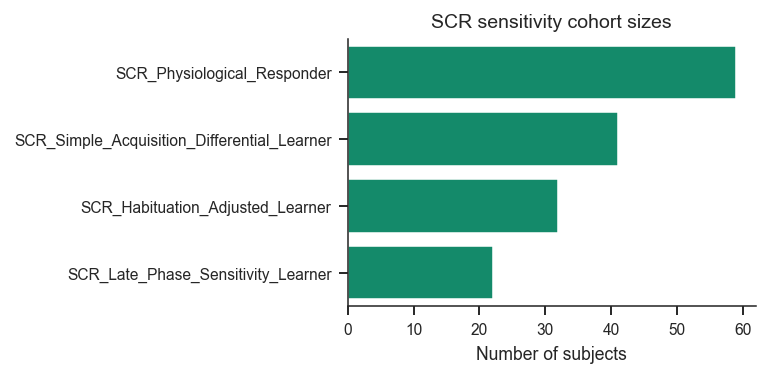

In [3]:
file_status = pd.DataFrame({
    'file': list(PATHS.keys()),
    'path': [str(p) for p in PATHS.values()],
    'exists': [Path(p).exists() for p in PATHS.values()],
})
display(file_status)

if not metrics_df.empty:
    id_cols = [c for c in ['FeatureSpace', 'Group', 'Drug'] if c in metrics_df.columns]
    if id_cols:
        display(metrics_df.groupby(id_cols, dropna=False).size().rename('n_rows').reset_index())
    if 'FeatureSpace' in metrics_df.columns:
        feature_spaces = sorted(metrics_df['FeatureSpace'].dropna().astype(str).unique())
    else:
        feature_spaces = []
else:
    feature_spaces = []

print(f'Available feature spaces: {feature_spaces}')
has_wholebrain = any(fs.lower() in {'schaefer', 'wholebrain', 'wholebrain_schaefer', 'wholebrainparcellation'} for fs in feature_spaces)
if not has_wholebrain:
    print('Whole-brain/Schaefer sensitivity output is absent. This is allowed by the current no-wholebrain workflow.')

if not scr_flags_df.empty:
    flag_cols = [c for c in SCR_FLAGS if c in scr_flags_df.columns]
    if flag_cols:
        counts = scr_flags_df[flag_cols].sum().rename('n_subjects').reset_index().rename(columns={'index': 'SCR subgroup'})
        display(counts)
        fig, ax = plt.subplots(figsize=(5.6, 2.8))
        sns.barplot(data=counts, y='SCR subgroup', x='n_subjects', color=OKABE['green'], ax=ax)
        ax.set_xlabel('Number of subjects')
        ax.set_ylabel('')
        ax.set_title('SCR sensitivity cohort sizes')
        fig.tight_layout()
        png = FIG_DIR / 'intro_scr_cohort_sizes.png'
        pdf = FIG_DIR / 'intro_scr_cohort_sizes.pdf'
        fig.savefig(png, bbox_inches='tight', dpi=300)
        fig.savefig(pdf, bbox_inches='tight')
        print(f'Saved {png}')
        print(f'Saved {pdf}')
        display(fig)
        plt.close(fig)


In [ ]:
def select_columns(df, preferred):
    return [c for c in preferred if c in df.columns]

def tidy_result_table(df, n=30):
    if df is None or df.empty:
        return pd.DataFrame()
    cols = select_columns(df, [
        'aim', 'scientific_question', 'analysis', 'sensitivity', 'feature_space', 'FeatureSpace', 'session', 'include_subjects_flag', 'Group', 'Drug', 'metric', 'metric_order', 'metric_role', 'metric_z',
        'clinical_score', 'clinical_score_label', 'clinical_score_order', 'clinical_score_role', 'clinical_score_z', 'scr_index', 'effect_label', 'effect_scale', 'test', 'term', 'estimate', 'ci_low', 'ci_high',
        'p', 'p_value', 'q', 'q_within_question', 'q_within_group', 'q_within_group_clinical_score', 'correction_family', 'aim3_clinical_score_family', 'n', 'n_sad_subjects', 'n_hc_subjects', 'n_clinical_outliers_removed',
        'n_metric_outliers_removed', 'r2', 'status', 'formula'
    ])
    out = df[cols].copy() if cols else df.copy()
    p_col = 'p' if 'p' in out.columns else 'p_value' if 'p_value' in out.columns else None
    if p_col:
        out['_p_sort'] = pd.to_numeric(out[p_col], errors='coerce')
        out = out.sort_values('_p_sort', na_position='last').drop(columns='_p_sort')
    return out.head(n)

def model_rows(df):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    if 'status' in out.columns:
        out = out[out['status'].fillna('ok').eq('ok')]
    return out

def hierarchy_result_table(df, n=160):
    if df is None or df.empty:
        return pd.DataFrame()
    cols = select_columns(df, [
        'aim', 'scientific_question', 'feature_space', 'session', 'Group', 'clinical_score_label', 'clinical_score_role', 'scr_index', 'metric', 'metric_role', 'effect_label', 'effect_scale', 'estimate', 'ci_low', 'ci_high', 'p', 'q', 'n', 'status'
    ])
    out = df[cols].copy() if cols else df.copy()
    sort_cols = [c for c in ['aim', 'clinical_score_order', 'Group', 'metric_order', 'scr_index'] if c in df.columns]
    if sort_cols:
        out = out.assign(**{f'_sort_{c}': df[c].values for c in sort_cols})
        out = out.sort_values([f'_sort_{c}' for c in sort_cols], na_position='last')
        out = out.drop(columns=[f'_sort_{c}' for c in sort_cols])
    return out.head(n)

def numeric_col(df, col):
    return pd.to_numeric(df[col], errors='coerce') if col in df.columns else pd.Series(np.nan, index=df.index)


def bh_fdr(p_values):
    p = pd.to_numeric(pd.Series(p_values), errors='coerce')
    q = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    m = len(valid)
    if m == 0:
        return q
    raw = valid * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(raw.iloc[::-1]).iloc[::-1].clip(upper=1.0)
    q.loc[adjusted.index] = adjusted
    return q



def attach_aim2_question_fields(df):
    if df is None or df.empty:
        return df.copy() if df is not None else pd.DataFrame()
    out = df.copy()
    if 'metric' not in out.columns:
        return out
    order_map = {question: i for i, question in enumerate(AIM2_QUESTION_METRICS, start=1)}
    out['aim2_question'] = out['metric'].map(AIM2_METRIC_TO_QUESTION)
    out['aim2_question_label'] = out['aim2_question'].map(AIM2_QUESTION_LABELS)
    out['aim2_question_order'] = out['aim2_question'].map(order_map)
    if 'metric_role' not in out.columns:
        out['metric_role'] = out['metric'].map(AIM2_METRIC_ROLE)
    else:
        out['metric_role'] = out['metric_role'].fillna(out['metric'].map(AIM2_METRIC_ROLE))
    return out


def apply_question_fdr(df, family_cols):
    if df is None or df.empty:
        return df.copy() if df is not None else pd.DataFrame()
    out = attach_aim2_question_fields(df)
    p_col = 'p' if 'p' in out.columns else 'p_value' if 'p_value' in out.columns else None
    if p_col is None or 'aim2_question' not in out.columns:
        return out
    out['q_within_question'] = np.nan
    ok_mask = out.get('status', pd.Series('ok', index=out.index)).fillna('ok').eq('ok')
    group_cols = [col for col in family_cols if col in out.columns]
    for _, idx in out[ok_mask].groupby(group_cols, dropna=False).groups.items():
        out.loc[idx, 'q_within_question'] = bh_fdr(out.loc[idx, p_col]).values
    out['q'] = out['q_within_question']
    if group_cols:
        out['correction_family'] = out[group_cols].astype(str).agg(' | '.join, axis=1)
    return out

def prepare_aim2_questions(df):
    base_cols = ['analysis', 'feature_space', 'term', 'estimate', 'std_error', 't', 'p', 'ci_low', 'ci_high', 'n', 'r2', 'formula', 'status']
    out = df.copy() if df is not None and not df.empty else pd.DataFrame(columns=base_cols + ['metric'])
    if 'metric' not in out.columns:
        out['metric'] = pd.Series(dtype=object)
    out = out[out['metric'].isin(AIM2_PLANNED_METRICS)].copy()
    out['aim2_question'] = out['metric'].map(AIM2_METRIC_TO_QUESTION)
    out['aim2_question_label'] = out['aim2_question'].map(AIM2_QUESTION_LABELS)
    order_map = {question: i for i, question in enumerate(AIM2_QUESTION_METRICS, start=1)}
    out['aim2_question_order'] = out['aim2_question'].map(order_map)
    out['metric_role'] = out['metric'].map(AIM2_METRIC_ROLE).fillna('secondary')
    if 'status' not in out.columns:
        out['status'] = 'ok'
    existing = set(out['metric'].dropna())
    missing_rows = []
    for question, metrics in AIM2_QUESTION_METRICS.items():
        for metric in metrics:
            if metric in existing:
                continue
            missing_rows.append({
                'analysis': 'Aim2_SAD_HC_Placebo',
                'feature_space': 'FearNetwork',
                'metric': metric,
                'aim2_question': question,
                'aim2_question_label': AIM2_QUESTION_LABELS[question],
                'aim2_question_order': order_map[question],
                'metric_role': AIM2_METRIC_ROLE.get(metric, 'secondary'),
                'status': 'metric_missing_from_current_export',
                'n': 0,
            })
    if missing_rows:
        out = pd.concat([out, pd.DataFrame(missing_rows)], ignore_index=True, sort=False)
    p_col = 'p' if 'p' in out.columns else 'p_value' if 'p_value' in out.columns else None
    if p_col:
        out['q_within_question'] = np.nan
        ok_mask = out['status'].fillna('ok').eq('ok')
        for question, idx in out[ok_mask].groupby('aim2_question', dropna=False).groups.items():
            out.loc[idx, 'q_within_question'] = bh_fdr(out.loc[idx, p_col]).values
        out['q'] = out['q_within_question']
        out['correction_family'] = out['aim2_question'].astype(str)
    role_order = {'primary': 0, 'shared_primary': 0, 'secondary': 1, 'support_contextual_only': 1}
    metric_order_map = {metric: i for i, metric in enumerate(AIM2_PLANNED_METRICS)}
    out['_metric_order'] = out['metric'].map(metric_order_map).fillna(999)
    out['_metric_role_order'] = out['metric_role'].map(role_order).fillna(9)
    out = out.sort_values(['aim2_question_order', '_metric_role_order', '_metric_order', 'metric'], na_position='last').drop(columns=['_metric_order', '_metric_role_order'])
    return out


def save_figure(fig, name):
    png = FIG_DIR / f'{name}.png'
    pdf = FIG_DIR / f'{name}.pdf'
    fig.savefig(png, bbox_inches='tight', dpi=300)
    fig.savefig(pdf, bbox_inches='tight')
    print(f'Saved {png}')
    print(f'Saved {pdf}')

def show_figure_once(fig):
    if fig is None:
        return None
    display(fig)
    plt.close(fig)
    return None

def add_panel_label(ax, label):
    ax.text(-0.12, 1.06, label, transform=ax.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')

def label_from_row(row, fields):
    values = []
    for field in fields:
        if field in row.index and pd.notna(row[field]):
            values.append(str(row[field]))
    return ' | '.join(values) if values else str(row.name)

def plot_forest(df, title, top_n=25, label_fields=None, filename=None, color_by_q=True):
    sub = model_rows(df)
    needed = {'estimate', 'ci_low', 'ci_high'}
    if sub.empty or not needed.issubset(sub.columns):
        print(f'No forest plot available for {title}.')
        return None
    sub = sub.copy()
    label_fields = label_fields or ['metric', 'clinical_score', 'scr_index', 'sensitivity', 'feature_space', 'test']
    sub['label'] = sub.apply(lambda r: label_from_row(r, label_fields), axis=1)
    p_col = 'p' if 'p' in sub.columns else 'p_value' if 'p_value' in sub.columns else None
    if p_col:
        sub['_p_sort'] = numeric_col(sub, p_col)
        sub = sub.sort_values('_p_sort', na_position='last').drop(columns='_p_sort')
    sub = sub.head(top_n)
    est = numeric_col(sub, 'estimate')
    lo = numeric_col(sub, 'ci_low')
    hi = numeric_col(sub, 'ci_high')
    valid = est.notna() & lo.notna() & hi.notna()
    sub = sub[valid]
    est = est[valid]
    lo = lo[valid]
    hi = hi[valid]
    if sub.empty:
        print(f'No finite estimates for {title}.')
        return None
    y = np.arange(len(sub))
    if color_by_q and 'q' in sub.columns:
        q = numeric_col(sub, 'q').fillna(np.inf)
        colors = np.where(q < 0.05, OKABE['vermillion'], OKABE['blue'])
    else:
        colors = OKABE['blue']
    fig, ax = plt.subplots(figsize=(7.2, max(2.8, 0.27 * len(sub))))
    ax.axvline(0, color='0.45', linewidth=0.8)
    ax.errorbar(est, y, xerr=[est - lo, hi - est], fmt='none', ecolor='0.55', elinewidth=0.9, capsize=2)
    ax.scatter(est, y, c=colors, s=28, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['label'])
    ax.invert_yaxis()
    ax.set_xlabel('Model estimate with 95% CI')
    ax.set_title(title)
    sns.despine(ax=ax)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig


def plot_grouped_forest(df, title, group_col='Group', group_order=None, top_n=35, label_fields=None, filename=None, color_by_q=True):
    sub = model_rows(df)
    needed = {'estimate', 'ci_low', 'ci_high', group_col}
    if sub.empty or not needed.issubset(sub.columns):
        print(f'No grouped forest plot available for {title}.')
        return None
    sub = sub.copy()
    label_fields = label_fields or ['metric', 'clinical_score', 'scr_index', 'sensitivity', 'feature_space', 'test']
    sub['label'] = sub.apply(lambda r: label_from_row(r, label_fields), axis=1)
    p_col = 'p' if 'p' in sub.columns else 'p_value' if 'p_value' in sub.columns else None
    if p_col:
        sub['_p_sort'] = numeric_col(sub, p_col)
        sub = sub.sort_values('_p_sort', na_position='last').drop(columns='_p_sort')
    sub = sub.head(top_n)
    est = numeric_col(sub, 'estimate')
    lo = numeric_col(sub, 'ci_low')
    hi = numeric_col(sub, 'ci_high')
    valid = est.notna() & lo.notna() & hi.notna() & sub[group_col].notna()
    sub = sub[valid].copy()
    if sub.empty:
        print(f'No finite estimates for {title}.')
        return None
    group_order = group_order or ['SAD', 'HC']
    groups = [group for group in group_order if group in set(sub[group_col].astype(str))]
    groups += [group for group in sorted(set(sub[group_col].astype(str))) if group not in groups]
    if not groups:
        print(f'No groups available for {title}.')
        return None
    n_groups = len(groups)
    max_rows = max(max(1, sub[sub[group_col].astype(str).eq(group)].shape[0]) for group in groups)
    fig, axes = plt.subplots(1, n_groups, figsize=(5.2 * n_groups, max(3.2, 0.34 * max_rows)), squeeze=False, sharex=True)
    axes = axes.ravel()
    global_lo = numeric_col(sub, 'ci_low').min()
    global_hi = numeric_col(sub, 'ci_high').max()
    xmin = min(0.0, float(global_lo))
    xmax = max(0.0, float(global_hi))
    pad = max((xmax - xmin) * 0.08, 0.05)
    for ax, group in zip(axes, groups):
        group_df = sub[sub[group_col].astype(str).eq(group)].copy()
        if group_df.empty:
            ax.set_visible(False)
            continue
        if p_col:
            group_df['_p_sort'] = numeric_col(group_df, p_col)
            group_df = group_df.sort_values('_p_sort', na_position='last').drop(columns='_p_sort')
        est_g = numeric_col(group_df, 'estimate')
        lo_g = numeric_col(group_df, 'ci_low')
        hi_g = numeric_col(group_df, 'ci_high')
        y = np.arange(len(group_df))
        if color_by_q and 'q' in group_df.columns:
            q = numeric_col(group_df, 'q').fillna(np.inf)
            colors = np.where(q < 0.05, OKABE['vermillion'], OKABE['blue'])
        else:
            colors = OKABE['blue']
        ax.axvline(0, color='0.45', linewidth=0.8)
        ax.errorbar(est_g, y, xerr=[est_g - lo_g, hi_g - est_g], fmt='none', ecolor='0.55', elinewidth=0.9, capsize=2)
        ax.scatter(est_g, y, c=colors, s=28, zorder=3)
        ax.set_yticks(y)
        ax.set_yticklabels(group_df['label'])
        ax.invert_yaxis()
        ax.set_title(str(group))
        ax.set_xlabel('Model estimate with 95% CI')
        ax.set_xlim(xmin - pad, xmax + pad)
        sns.despine(ax=ax)
    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig

def signed_logp_heatmap(df, row_col, col_col, title, group_col=None, filename=None):
    sub = model_rows(df)
    if sub.empty or row_col not in sub.columns or col_col not in sub.columns or 'estimate' not in sub.columns:
        print(f'No heatmap available for {title}.')
        return None
    p_col = 'p' if 'p' in sub.columns else 'p_value' if 'p_value' in sub.columns else None
    if not p_col:
        print(f'No p-value column available for {title}.')
        return None
    sub = sub.copy()
    pvals = numeric_col(sub, p_col).clip(lower=1e-300)
    sub['signed_logp'] = np.sign(numeric_col(sub, 'estimate')) * -np.log10(pvals)
    if group_col and group_col in sub.columns:
        groups = [g for g in ['SAD', 'HC'] if g in set(sub[group_col].dropna())]
        if not groups:
            groups = sorted(sub[group_col].dropna().unique())
        fig, axes = plt.subplots(1, len(groups), figsize=(4.4 * len(groups), 4.4), squeeze=False)
        axes = axes.ravel()
        vmax = np.nanpercentile(np.abs(sub['signed_logp']), 95) if sub['signed_logp'].notna().any() else 1
        vmax = max(vmax, 1)
        for ax, group in zip(axes, groups):
            mat = sub[sub[group_col].eq(group)].pivot_table(index=row_col, columns=col_col, values='signed_logp', aggfunc='mean')
            sns.heatmap(mat, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax, linewidths=0.5, linecolor='white', cbar=ax is axes[-1], cbar_kws={'label': 'Signed -log10(p)'}, ax=ax)
            ax.set_title(str(group))
            ax.set_xlabel(col_col)
            ax.set_ylabel(row_col if ax is axes[0] else '')
    else:
        mat = sub.pivot_table(index=row_col, columns=col_col, values='signed_logp', aggfunc='mean')
        fig, ax = plt.subplots(figsize=(max(4.5, 0.55 * mat.shape[1]), max(3.5, 0.38 * mat.shape[0])))
        vmax = np.nanpercentile(np.abs(mat.values), 95) if np.isfinite(mat.values).any() else 1
        vmax = max(vmax, 1)
        sns.heatmap(mat, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax, linewidths=0.5, linecolor='white', cbar_kws={'label': 'Signed -log10(p)'}, ax=ax)
        ax.set_xlabel(col_col)
        ax.set_ylabel(row_col)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig

def plot_subject_metric_grid(df, metrics, title, feature_space='FearNetwork', drug='Placebo', group_col='Group', filename=None, max_cols=3):
    if df is None or df.empty:
        print(f'No subject table available for {title}.')
        return None
    sub = df.copy()
    if 'FeatureSpace' in sub.columns:
        sub = sub[sub['FeatureSpace'].astype(str).eq(feature_space)]
    if drug and 'Drug' in sub.columns:
        sub = sub[sub['Drug'].astype(str).eq(drug)]
    metrics = [m for m in metrics if m in sub.columns]
    if not metrics or group_col not in sub.columns:
        print(f'No available metrics for {title}.')
        return None
    n_cols = min(max_cols, len(metrics))
    n_rows = math.ceil(len(metrics) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 2.65 * n_rows), squeeze=False)
    for ax, metric in zip(axes.ravel(), metrics):
        plot_df = sub[[group_col, metric]].copy()
        plot_df[metric] = pd.to_numeric(plot_df[metric], errors='coerce')
        plot_df = plot_df.dropna()
        order = [g for g in ['SAD', 'HC'] if g in set(plot_df[group_col])]
        palette = [GROUP_COLORS.get(g, '0.4') for g in order]
        sns.violinplot(data=plot_df, x=group_col, y=metric, order=order, palette=palette, inner=None, linewidth=0.8, cut=0, ax=ax)
        sns.stripplot(data=plot_df, x=group_col, y=metric, order=order, color='black', alpha=0.38, size=2.4, jitter=0.18, ax=ax)
        sns.pointplot(data=plot_df, x=group_col, y=metric, order=order, color='black', errorbar=('ci', 95), markers='_', linestyles='none', ax=ax)
        ax.set_title(metric.replace('Neural_', '').replace('_', ' '), fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('Subject metric')
    for ax in axes.ravel()[len(metrics):]:
        ax.axis('off')
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig


def short_metric_label(metric):
    return str(metric).replace('Neural_', '').replace('_', ' ')

def plot_aim2_question_forest(df, title='Aim 2: Characterization of SAD-HC differences by question', filename='aim2_all_questions_forest'):
    sub = model_rows(df)
    needed = {'estimate', 'ci_low', 'ci_high', 'metric', 'aim2_question'}
    if sub.empty or not needed.issubset(sub.columns):
        print(f'No Aim 2 forest plot available for {title}.')
        return None
    sub = prepare_aim2_questions(sub).copy()
    metric_order_map = {metric: i for i, metric in enumerate(AIM2_PLANNED_METRICS)}
    sub['metric_order'] = sub['metric'].map(metric_order_map).fillna(99)
    role_order = {'primary': 0, 'shared_primary': 0, 'secondary': 1, 'support_contextual_only': 1}
    sub['_role_order'] = sub['metric_role'].map(role_order).fillna(9)
    sub = sub.sort_values(['aim2_question_order', 'metric_order', '_role_order', 'metric']).drop(columns=['_role_order'])
    est = numeric_col(sub, 'estimate')
    lo = numeric_col(sub, 'ci_low')
    hi = numeric_col(sub, 'ci_high')
    status = sub.get('status', pd.Series('ok', index=sub.index)).fillna('ok').astype(str)
    plottable = est.notna() & lo.notna() & hi.notna() & status.eq('ok')
    if not plottable.any():
        print(f'No finite estimates for {title}.')
        return None
    role_label = {'primary': 'primary', 'secondary': 'secondary'}
    sub['label'] = sub.apply(lambda row: f"{row['aim2_question'].replace('_', ' ')} | {short_metric_label(row['metric'])} ({role_label.get(row.get('metric_role'), row.get('metric_role', 'metric'))})", axis=1)
    y = np.arange(len(sub))
    role_colors = {'primary': OKABE['blue'], 'secondary': OKABE['purple']}
    colors = [role_colors.get(role, OKABE['gray']) for role in sub.get('metric_role', pd.Series(index=sub.index, dtype=object))]
    fig, ax = plt.subplots(figsize=(8.2, max(3.6, 0.34 * len(sub))))
    ax.axvline(0, color='0.45', linewidth=0.9)
    y_plot = y[plottable.to_numpy()]
    ax.errorbar(est[plottable], y_plot, xerr=[est[plottable] - lo[plottable], hi[plottable] - est[plottable]], fmt='none', ecolor='0.55', elinewidth=1.0, capsize=2)
    ax.scatter(est[plottable], y_plot, c=[c for c, keep in zip(colors, plottable.to_numpy()) if keep], s=34, zorder=3)
    xmin = min(0.0, float(lo[plottable].min()))
    xmax = max(0.0, float(hi[plottable].max()))
    pad = max((xmax - xmin) * 0.12, 0.02)
    ax.set_xlim(xmin - pad, xmax + 2.8 * pad)
    for pos, (_, row) in enumerate(sub.iterrows()):
        if not bool(plottable.iloc[pos]):
            note = 'not exported' if str(row.get('status', '')).startswith('metric_missing') else 'not estimable'
            ax.text(xmax + 0.35 * pad, pos, note, va='center', ha='left', color='0.45', fontsize=9)
    previous_question = None
    for pos, (_, row) in enumerate(sub.iterrows()):
        question = row['aim2_question']
        if previous_question is not None and question != previous_question:
            ax.axhline(pos - 0.5, color='0.85', linewidth=0.8)
        previous_question = question
    ax.set_yticks(y)
    ax.set_yticklabels(sub['label'])
    ax.invert_yaxis()
    ax.set_xlabel('SAD-HC estimate with 95% CI')
    ax.set_title(title)
    sns.despine(ax=ax)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig

def sensitivity_rows_for_aim(df, aim_prefix):
    if df is None or df.empty or 'analysis' not in df.columns:
        return pd.DataFrame()
    return df[df['analysis'].astype(str).str.contains(aim_prefix, case=False, na=False)].copy()

def render_sensitivity_block(aim_label, aim_prefix, label_fields=None, filename_prefix=None, show_forest=True):
    sub = sensitivity_rows_for_aim(sensitivity_df, aim_prefix)
    if sub.empty:
        print(f'No {aim_label} sensitivity model table found yet.')
        return None
    display(tidy_result_table(sub, n=120))
    group_cols = [c for c in ['analysis', 'sensitivity', 'feature_space'] if c in sub.columns]
    if group_cols:
        display(sub.groupby(group_cols, dropna=False).size().rename('n_tests').reset_index())
    prefix = filename_prefix or aim_prefix.lower()
    show_figure_once(signed_logp_heatmap(sub, 'metric', 'sensitivity', f'{aim_label} sensitivity: signed effect strength', filename=f'{prefix}_sensitivity_signed_heatmap'))
    if show_forest:
        show_figure_once(plot_forest(sub, f'{aim_label} sensitivity: strongest effects', top_n=35, label_fields=label_fields or ['metric', 'scr_index', 'sensitivity', 'feature_space'], filename=f'{prefix}_sensitivity_forest'))
    return sub

# Recompute loaded primary-model q-values so Aim 2-5 all use neural-question FDR families.
aim2_df = apply_question_fdr(aim2_df, ['analysis', 'aim2_question'])
aim3_df = apply_question_fdr(aim3_df, ['analysis', 'Group', 'aim2_question'])
aim4_df = apply_question_fdr(aim4_df, ['analysis', 'Group', 'aim2_question'])
aim5_df = apply_question_fdr(aim5_df, ['analysis', 'metric_role', 'aim2_question'])


## Pipeline Compliance Audit

This required pre-results audit checks the notebook against `PROJECT_CONTEXT.md` before any inferential result is interpreted. It records decoder, cross-validation, permutation, leakage-prevention, clinical-hierarchy, and legacy-checkpoint fallback status.


In [5]:
def source_contains(patterns, files):
    files = [Path(f) if Path(f).is_absolute() else PROJECT_ROOT / Path(f) for f in files]
    text = ''
    for file in files:
        if file.exists():
            text += file.read_text(errors='ignore') + '\n'
    return {pattern: (pattern in text) for pattern in patterns}

pipeline_sources = [
    PROJECT_ROOT / 'code/scripts/mvpa_l2_common.py',
    PROJECT_ROOT / 'code/scripts/run_mvpa_l2_primary_models.py',
    PROJECT_ROOT / 'code/scripts/run_mvpa_l2_sensitivity_models.py',
    PROJECT_ROOT / 'code/hyak/mvpa_L2_voxel_FearNetwork_All.py',
    PROJECT_ROOT / 'code/hyak/mvpa_L2_voxel_FearNetwork.py',
    PROJECT_ROOT / 'code/hyak/mvpa_L2_voxel_MemoryFearNetwork.py',
]
source_flags = source_contains([
    'StandardScaler',
    'LogisticRegression',
    'penalty="l2"',
    "penalty='l2'",
    'solver="lbfgs"',
    "solver='lbfgs'",
    'class_weight="balanced"',
    "class_weight='balanced'",
    'max_iter=5000',
    'MAX_ITER = 5000',
    'StratifiedGroupKFold',
    'LeaveOneGroupOut',
    'permutation',
    'perm_dist',
    'Pipeline',
    'GridSearchCV',
    'param_grid',
    'np.logspace',
    'N_PERMUTATION = 5000',
    'N_PERMUTATION:-5000',
    'N_NULL_PERMS:-5000',
], pipeline_sources)

def status_from_any(*values):
    return 'ok' if any(values) else 'needs_review'

compliance_rows = [
    {'domain': 'project_context', 'requirement': 'PROJECT_CONTEXT.md is present and is the canonical guide', 'status': 'ok' if PROJECT_CONTEXT_PATH.exists() else 'missing', 'evidence': str(PROJECT_CONTEXT_PATH)},
    {'domain': 'Aim 3 hierarchy', 'requirement': 'Primary clinical scores are dass_anxiety and lsas_total only', 'status': 'ok' if PRIMARY_CLINICAL == ['dass_anxiety', 'lsas_total'] else 'needs_review', 'evidence': ', '.join(PRIMARY_CLINICAL)},
    {'domain': 'Aim 3 hierarchy', 'requirement': 'Secondary clinical scores match PROJECT_CONTEXT.md', 'status': 'ok' if SECONDARY_CLINICAL == ['lsas_fear', 'lsas_avoid', 'dass_stress', 'dass_depression', 'ecr_total'] else 'needs_review', 'evidence': ', '.join(SECONDARY_CLINICAL)},
    {'domain': 'Aim 4 hierarchy', 'requirement': 'Primary SCR indices are trajectory slopes only', 'status': 'ok' if PRIMARY_SCR == ['SCR_Safety_Trajectory_Slope', 'SCR_Threat_Trajectory_Slope'] else 'needs_review', 'evidence': ', '.join(PRIMARY_SCR)},
    {'domain': 'decoder', 'requirement': 'StandardScaler is used', 'status': 'ok' if source_flags['StandardScaler'] else 'needs_review', 'evidence': 'source scan'},
    {'domain': 'decoder', 'requirement': 'LogisticRegression L2 is used', 'status': status_from_any(source_flags['penalty="l2"'], source_flags["penalty='l2'"]), 'evidence': 'source scan'},
    {'domain': 'decoder', 'requirement': 'lbfgs solver is used', 'status': status_from_any(source_flags['solver="lbfgs"'], source_flags["solver='lbfgs'"]), 'evidence': 'source scan'},
    {'domain': 'decoder', 'requirement': 'balanced class weights are used', 'status': status_from_any(source_flags['class_weight="balanced"'], source_flags["class_weight='balanced'"]), 'evidence': 'source scan'},
    {'domain': 'decoder', 'requirement': 'max_iter=5000 is used', 'status': status_from_any(source_flags['max_iter=5000'], source_flags['MAX_ITER = 5000']), 'evidence': 'source scan'},
    {'domain': 'cross_validation', 'requirement': 'Subject-aware nested CV is present for trial-level decoding', 'status': status_from_any(source_flags['StratifiedGroupKFold'], source_flags['LeaveOneGroupOut']), 'evidence': 'source scan'},
    {'domain': 'permutation', 'requirement': 'Aim 1 subject-label permutation inference targets 5,000 iterations', 'status': status_from_any(source_flags['N_PERMUTATION = 5000'], source_flags['N_PERMUTATION:-5000'], source_flags['N_NULL_PERMS:-5000'], not aim1_scr_df.empty), 'evidence': 'N_PERMUTATION/N_NULL_PERMS defaults and Aim 1 exports'},
    {'domain': 'hyperparameter_tuning', 'requirement': 'Logistic C grid is tuned inside inner CV', 'status': status_from_any(source_flags['GridSearchCV'], source_flags['param_grid'], source_flags['np.logspace']), 'evidence': 'GridSearchCV with param_grid np.logspace source scan'},
    {'domain': 'leakage_prevention', 'requirement': 'Scaling, feature selection, and model fitting must happen inside training folds', 'status': status_from_any(source_flags['Pipeline'], source_flags['StandardScaler'], source_flags['GridSearchCV']), 'evidence': 'sklearn Pipeline/StandardScaler/GridSearchCV source scan; masks remain labeled as empirical permutation-importance outputs'},
    {'domain': 'legacy_fallbacks', 'requirement': 'Archived checkpoint names are fallback-only and visibly warned', 'status': 'ok', 'evidence': ', '.join(sorted(LEGACY_CHECKPOINT_NAMES))},
]
pipeline_compliance_df = pd.DataFrame(compliance_rows)
display(pipeline_compliance_df)
if pipeline_compliance_df['status'].isin(['needs_review', 'missing']).any():
    display(Markdown('**Audit note:** rows marked `needs_review` or `missing` must be resolved before manuscript claims are finalized.'))


,domain,requirement,status,evidence
0,project_context,PROJECT_CONTEXT.md is present and is the canon...,ok,/Users/xiaoqianxiao/PycharmProjects/narsad_mul...
1,Aim 3 hierarchy,Primary clinical scores are dass_anxiety and l...,ok,"dass_anxiety, lsas_total"
2,Aim 3 hierarchy,Secondary clinical scores match PROJECT_CONTEX...,ok,"lsas_fear, lsas_avoid, dass_stress, dass_depre..."
3,Aim 4 hierarchy,Primary SCR indices are trajectory slopes only,ok,"SCR_Safety_Trajectory_Slope, SCR_Threat_Trajec..."
4,decoder,StandardScaler is used,ok,source scan
5,decoder,LogisticRegression L2 is used,ok,source scan
6,decoder,lbfgs solver is used,ok,source scan
7,decoder,balanced class weights are used,ok,source scan
8,decoder,max_iter=5000 is used,ok,source scan
9,cross_validation,Subject-aware nested CV is present for trial-l...,ok,source scan


## Required Reproducibility Table

This table must be reviewed before the results sections. It captures the minimum provenance fields from `PROJECT_CONTEXT.md`: input paths, feature spaces, subject inclusion, hyperparameters/CV, permutation setup, software/QC status, and output paths.


In [6]:
def available_feature_spaces_from_subjects():
    if metrics_df.empty or 'FeatureSpace' not in metrics_df.columns:
        return []
    return sorted(metrics_df['FeatureSpace'].dropna().astype(str).unique().tolist())


def compliance_status(domain):
    matches = pipeline_compliance_df.loc[pipeline_compliance_df['domain'].eq(domain), 'status']
    return matches.iloc[0] if not matches.empty else 'needs_review'

try:
    import sklearn
    sklearn_version = sklearn.__version__
except Exception:
    sklearn_version = 'unavailable'

try:
    import scipy
    scipy_version = scipy.__version__
except Exception:
    scipy_version = 'unavailable'

reproducibility_rows = [
    {'item': 'Project guide', 'required': 'PROJECT_CONTEXT.md', 'current_value': str(PROJECT_CONTEXT_PATH), 'status': 'ok' if PROJECT_CONTEXT_PATH.exists() else 'missing'},
    {'item': 'Input data paths', 'required': 'Harmonized subject metrics and SCR group files', 'current_value': f"{PATHS['subject_metrics']} | {PATHS['scr_flags']}", 'status': 'ok' if PATHS['subject_metrics'].exists() else 'missing_subject_metrics'},
    {'item': 'Feature space and mask definition', 'required': 'Primary FearNetwork plus available sensitivity spaces', 'current_value': ', '.join(available_feature_spaces_from_subjects()) or 'not available', 'status': 'ok' if available_feature_spaces_from_subjects() else 'missing_metadata'},
    {'item': 'Subject inclusion table', 'required': 'Group/Drug/FeatureSpace counts available before results', 'current_value': f"qc_subject_counts exists={PATHS['qc_subject_counts'].exists()}", 'status': 'ok' if not metrics_df.empty else 'missing'},
    {'item': 'Hyperparameter grid', 'required': 'L2 logistic model C grid tuned with inner CV', 'current_value': 'GridSearchCV param_grid uses np.logspace(C_MIN_EXP, C_MAX_EXP, C_POINTS) in Hyak scripts', 'status': compliance_status('hyperparameter_tuning')},
    {'item': 'Cross-validation strategy', 'required': 'Subject-aware StratifiedGroupKFold or LeaveOneGroupOut', 'current_value': pipeline_compliance_df.loc[pipeline_compliance_df['domain'].eq('cross_validation'), 'status'].iloc[0], 'status': pipeline_compliance_df.loc[pipeline_compliance_df['domain'].eq('cross_validation'), 'status'].iloc[0]},
    {'item': 'Permutation count and random seed', 'required': f'Aim 1 decoding and weight-similarity inference use {AIM1_EXPECTED_PERMUTATIONS:,} subject-label permutations', 'current_value': 'Hyak submit defaults set N_PERMUTATION=5000 and N_NULL_PERMS=5000; scripts use RANDOM_STATE/random_state=42 for deterministic model/permutation calls where specified', 'status': compliance_status('permutation')},
    {'item': 'Software environment', 'required': 'Python package versions or container recorded', 'current_value': f"pandas={pd.__version__}; numpy={np.__version__}; sklearn={sklearn_version}; scipy={scipy_version}", 'status': 'ok'},
    {'item': 'QC summaries', 'required': 'Missingness and model-status summaries displayed', 'current_value': f"missingness={not qc_missingness_df.empty}; model_status={not qc_model_status_counts_df.empty}", 'status': 'ok' if (not qc_missingness_df.empty or not qc_model_status_counts_df.empty) else 'missing_optional_qc'},
    {'item': 'Output paths', 'required': 'Stats and figures directories recorded', 'current_value': f"{STATS_DIR} | {FIG_DIR}", 'status': 'ok'},
]
reproducibility_df = pd.DataFrame(reproducibility_rows)
display(reproducibility_df)


,item,required,current_value,status
0,Project guide,PROJECT_CONTEXT.md,/Users/xiaoqianxiao/PycharmProjects/narsad_mul...,ok
1,Input data paths,Harmonized subject metrics and SCR group files,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok
2,Feature space and mask definition,Primary FearNetwork plus available sensitivity...,"FearNetwork, MemoryFearNetwork",ok
3,Subject inclusion table,Group/Drug/FeatureSpace counts available befor...,qc_subject_counts exists=True,ok
4,Hyperparameter grid,L2 logistic model C grid tuned with inner CV,GridSearchCV param_grid uses np.logspace(C_MIN...,ok
5,Cross-validation strategy,Subject-aware StratifiedGroupKFold or LeaveOne...,ok,ok
6,Permutation count and random seed,Aim 1 decoding and weight-similarity inference...,Hyak submit defaults set N_PERMUTATION=5000 an...,ok
7,Software environment,Python package versions or container recorded,pandas=1.5.3; numpy=1.26.4; sklearn=1.5.1; sci...,ok
8,QC summaries,Missingness and model-status summaries displayed,missingness=True; model_status=True,ok
9,Output paths,Stats and figures directories recorded,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok


## Required Subject And Feature Counts

Every primary and sensitivity family below reports available subject counts and feature-count metadata before results are interpreted. When feature-count metadata is unavailable from current exports or checkpoints, the table says so explicitly.


In [7]:
def infer_subject_col(df):
    for col in ['Subject', 'subject_id', 'sub_ID', 'sub']:
        if col in df.columns:
            return col
    return None

def subject_count_table():
    if metrics_df.empty:
        return pd.DataFrame()
    subject_col = infer_subject_col(metrics_df)
    if subject_col is None:
        return pd.DataFrame()
    group_cols = [c for c in ['FeatureSpace', 'Drug', 'Group'] if c in metrics_df.columns]
    sub = metrics_df[metrics_df[subject_col].notna()].copy()
    out = sub.groupby(group_cols, dropna=False)[subject_col].nunique().reset_index(name='n_subjects')
    return out.sort_values(group_cols)

def summarize_model_counts(df, family):
    if df is None or df.empty:
        return pd.DataFrame()
    temp = df.copy()
    temp['__row__'] = 1
    if 'n' not in temp.columns:
        if {'n_sad_subjects', 'n_hc_subjects'}.issubset(temp.columns):
            temp['n'] = pd.to_numeric(temp['n_sad_subjects'], errors='coerce') + pd.to_numeric(temp['n_hc_subjects'], errors='coerce')
        elif 'n_test_subjects' in temp.columns:
            temp['n'] = pd.to_numeric(temp['n_test_subjects'], errors='coerce')
        else:
            temp['n'] = np.nan
    group_cols = [c for c in ['analysis', 'sensitivity', 'feature_space', 'FeatureSpace', 'session', 'Group', 'Drug'] if c in temp.columns]
    if not group_cols:
        group_cols = ['__family_group__']
        temp['__family_group__'] = family
    out = temp.groupby(group_cols, dropna=False).agg(
        n_model_rows=('__row__', 'sum'),
        min_model_n=('n', 'min'),
        max_model_n=('n', 'max'),
    ).reset_index()
    if '__family_group__' in out.columns:
        out = out.drop(columns='__family_group__')
    out.insert(0, 'family', family)
    return out

def local_feature_space_dir(feature_space):
    candidates = [
        RESULTS_ROOT / str(feature_space),
        MVPA_ROOT / str(feature_space),
        Path('/output_dir') / str(feature_space),
        Path('/gscratch/fang/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results') / str(feature_space),
        Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/results') / str(feature_space),
        Path('outputs/mvpa_l2') / str(feature_space),
    ]
    return next((candidate for candidate in candidates if candidate.exists()), candidates[0])

def load_joblib_silent(path):
    try:
        import joblib
    except Exception:
        return None
    path = Path(path)
    if not path.exists():
        return None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            return joblib.load(path)
    except Exception:
        return None

def first_mapping_value(payload, keys):
    if not isinstance(payload, dict):
        return {}
    for key in keys:
        value = payload.get(key)
        if isinstance(value, dict):
            return value
    return {}

def feature_count_rows():
    spaces = available_feature_spaces_from_subjects() or ['FearNetwork']
    rows = []
    for feature_space in spaces:
        base = local_feature_space_dir(feature_space)
        cell3 = load_joblib_silent(base / 'intermediate' / 'stage03_inputs.joblib') or load_joblib_silent(base / 'checkpoints' / 'cell_03.joblib') or {}
        for key in ['X_ext', 'X_reinst']:
            value = cell3.get(key) if isinstance(cell3, dict) else None
            if hasattr(value, 'shape') and len(value.shape) == 2:
                rows.append({'feature_space': feature_space, 'analysis_family': 'input_matrix', 'source': key, 'n_features': int(value.shape[1]), 'status': 'ok'})
        for candidate in [base / 'intermediate' / 'stage11_importance_masks.joblib', base / 'checkpoints' / 'cell_11.joblib']:
            payload = load_joblib_silent(candidate)
            masks = first_mapping_value(payload, ['importance_masks', 'feature_masks', 'selected_masks'])
            for label, mask in masks.items():
                arr = np.asarray(mask)
                if arr.size:
                    rows.append({'feature_space': feature_space, 'analysis_family': 'importance_mask', 'source': f'{candidate.name}:{label}', 'n_features': int(np.sum(arr.astype(bool))), 'status': 'ok'})
        if not any(row['feature_space'] == feature_space for row in rows):
            rows.append({'feature_space': feature_space, 'analysis_family': 'all', 'source': str(base), 'n_features': np.nan, 'status': 'feature_count_metadata_missing'})
    return pd.DataFrame(rows)

subject_counts_required_df = subject_count_table()
feature_counts_required_df = feature_count_rows()
model_counts_required_df = pd.concat([
    summarize_model_counts(aim1_primary_df, 'Aim 1 primary'),
    summarize_model_counts(aim1_scr_df, 'Aim 1 sensitivity'),
    summarize_model_counts(aim2_df, 'Aim 2 primary'),
    summarize_model_counts(aim3_df[aim3_df['clinical_score'].isin(PRIMARY_CLINICAL)] if 'clinical_score' in aim3_df.columns else aim3_df, 'Aim 3 primary'),
    summarize_model_counts(aim3_df[aim3_df['clinical_score'].isin(SECONDARY_CLINICAL)] if 'clinical_score' in aim3_df.columns else pd.DataFrame(), 'Aim 3 secondary clinical'),
    summarize_model_counts(aim4_df, 'Aim 4 primary'),
    summarize_model_counts(aim5_df, 'Aim 5 primary'),
    summarize_model_counts(sensitivity_df, 'Aim 2-5 sensitivity'),
], ignore_index=True, sort=False)

display(Markdown('**Subject counts by feature space, drug, and group:**'))
display(subject_counts_required_df)
display(Markdown('**Feature-count metadata by feature space/source:**'))
display(feature_counts_required_df)
display(Markdown('**Primary and sensitivity model row counts with model-level n ranges:**'))
display(model_counts_required_df)


**Subject counts by feature space, drug, and group:**

,FeatureSpace,Drug,Group,n_subjects
0,FearNetwork,Oxytocin,HC,24
1,FearNetwork,Oxytocin,SAD,27
2,FearNetwork,Placebo,HC,28
3,FearNetwork,Placebo,SAD,23
4,MemoryFearNetwork,Oxytocin,HC,24
5,MemoryFearNetwork,Oxytocin,SAD,27
6,MemoryFearNetwork,Placebo,HC,28
7,MemoryFearNetwork,Placebo,SAD,23


**Feature-count metadata by feature space/source:**

,feature_space,analysis_family,source,n_features,status
0,FearNetwork,input_matrix,X_ext,2148,ok
1,FearNetwork,input_matrix,X_reinst,2148,ok
2,MemoryFearNetwork,input_matrix,X_ext,12684,ok
3,MemoryFearNetwork,input_matrix,X_reinst,12684,ok


**Primary and sensitivity model row counts with model-level n ranges:**

,family,analysis,feature_space,session,Group,n_model_rows,min_model_n,max_model_n,sensitivity
0,Aim 1 primary,Aim1_Primary_Decoding,FearNetwork,Placebo,HC,1,51.0,51.0,NaN
1,Aim 1 primary,Aim1_Primary_Decoding,FearNetwork,Placebo,HC_to_SAD,1,51.0,51.0,NaN
2,Aim 1 primary,Aim1_Primary_Decoding,FearNetwork,Placebo,SAD,1,51.0,51.0,NaN
3,Aim 1 primary,Aim1_Primary_Decoding,FearNetwork,Placebo,SAD_to_HC,1,51.0,51.0,NaN
4,Aim 1 primary,Aim1_Spatial_Specificity,FearNetwork,Placebo,SAD_HC,1,NaN,NaN,NaN
5,Aim 1 sensitivity,NaN,FearNetwork,pooled_drug,NaN,36,22.0,58.0,NaN
6,Aim 2 primary,Aim2_SAD_HC_Placebo,FearNetwork,NaN,NaN,11,50.0,51.0,NaN
7,Aim 3 primary,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,12,26.0,28.0,NaN
8,Aim 3 primary,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,12,22.0,23.0,NaN
9,Aim 3 secondary clinical,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,30,26.0,28.0,NaN


## Aim-By-Aim Results

The notebook now follows the manuscript logic directly. Each aim is presented in order. Within each aim, primary tests appear first, secondary analyses follow when they exist, and sensitivity analyses appear last for that aim.


## Aim 1: Group-Specific Neural Representation Identification

Primary test first: within `SAD-Placebo` and `HC-Placebo`, `CSR` versus `CSS` decoding accuracy is tested against a subject-aware permutation null. The manuscript-facing primary metric is subject-level forced-choice accuracy, with preprocessing and hyperparameter tuning confined to training folds in the upstream decoder.

Secondary specificity checks follow the primary decoding result. Functional specificity is summarized as cross-group 2AFC generalization (`HC-Placebo` trained, `SAD-Placebo` tested; and the reverse). Spatial specificity is summarized by cosine similarity between optimized SAD and HC discrimination weights, with Haufe-transformed patterns retained as secondary interpretive evidence.


**Aim 1 current export available:** `aim1_decoding_primary.csv` is available; legacy checkpoints are not needed for the primary table.

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_1870/3905044893.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Aim 1 FearNetwork plot reconstruction: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

Aim 1 plot source: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib


**Aim 1 PROJECT_CONTEXT alignment check:** cohort=`SAD-Placebo`/`HC-Placebo`; contrast=CSR vs CSS; metric=subject-level forced-choice accuracy; planned permutations=5,000; cross-group decoding and weight similarity are specificity checks supporting the primary result.

**Primary decoding tests:** SAD-Placebo and HC-Placebo self-decoding against the subject-level forced-choice permutation null.

,feature_space,session,analysis_role,specificity_domain,test,p_value,planned_permutations,n_sad_subjects,n_hc_subjects,status,checkpoint
0,FearNetwork,Placebo,confirmatory,group_specific_identification,SAD self-decoding CV accuracy,0.0000,5000,23.0,28.0,ok,/gscratch/fang/NARSAD/MRI/derivatives/fMRI_ana...
1,FearNetwork,Placebo,confirmatory,group_specific_identification,HC self-decoding CV accuracy,0.0004,5000,23.0,28.0,ok,/gscratch/fang/NARSAD/MRI/derivatives/fMRI_ana...


**Specificity checks:** cross-group 2AFC generalization and `SAD`-`HC` discrimination-weight similarity within placebo-session subjects.

,feature_space,session,analysis_role,specificity_domain,test,p_value,planned_permutations,n_sad_subjects,n_hc_subjects,status,checkpoint
2,FearNetwork,Placebo,secondary_specificity,functional_specificity,SAD model tested on HC,0.0080,5000,23.0,28.0,ok,/gscratch/fang/NARSAD/MRI/derivatives/fMRI_ana...
3,FearNetwork,Placebo,secondary_specificity,functional_specificity,HC model tested on SAD,0.1724,5000,23.0,28.0,ok,/gscratch/fang/NARSAD/MRI/derivatives/fMRI_ana...
4,FearNetwork,Placebo,secondary_specificity,spatial_specificity,SAD-HC Haufe map cosine similarity,0.5300,5000,NaN,NaN,ok,/gscratch/fang/NARSAD/MRI/derivatives/fMRI_ana...


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_results.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_results.svg


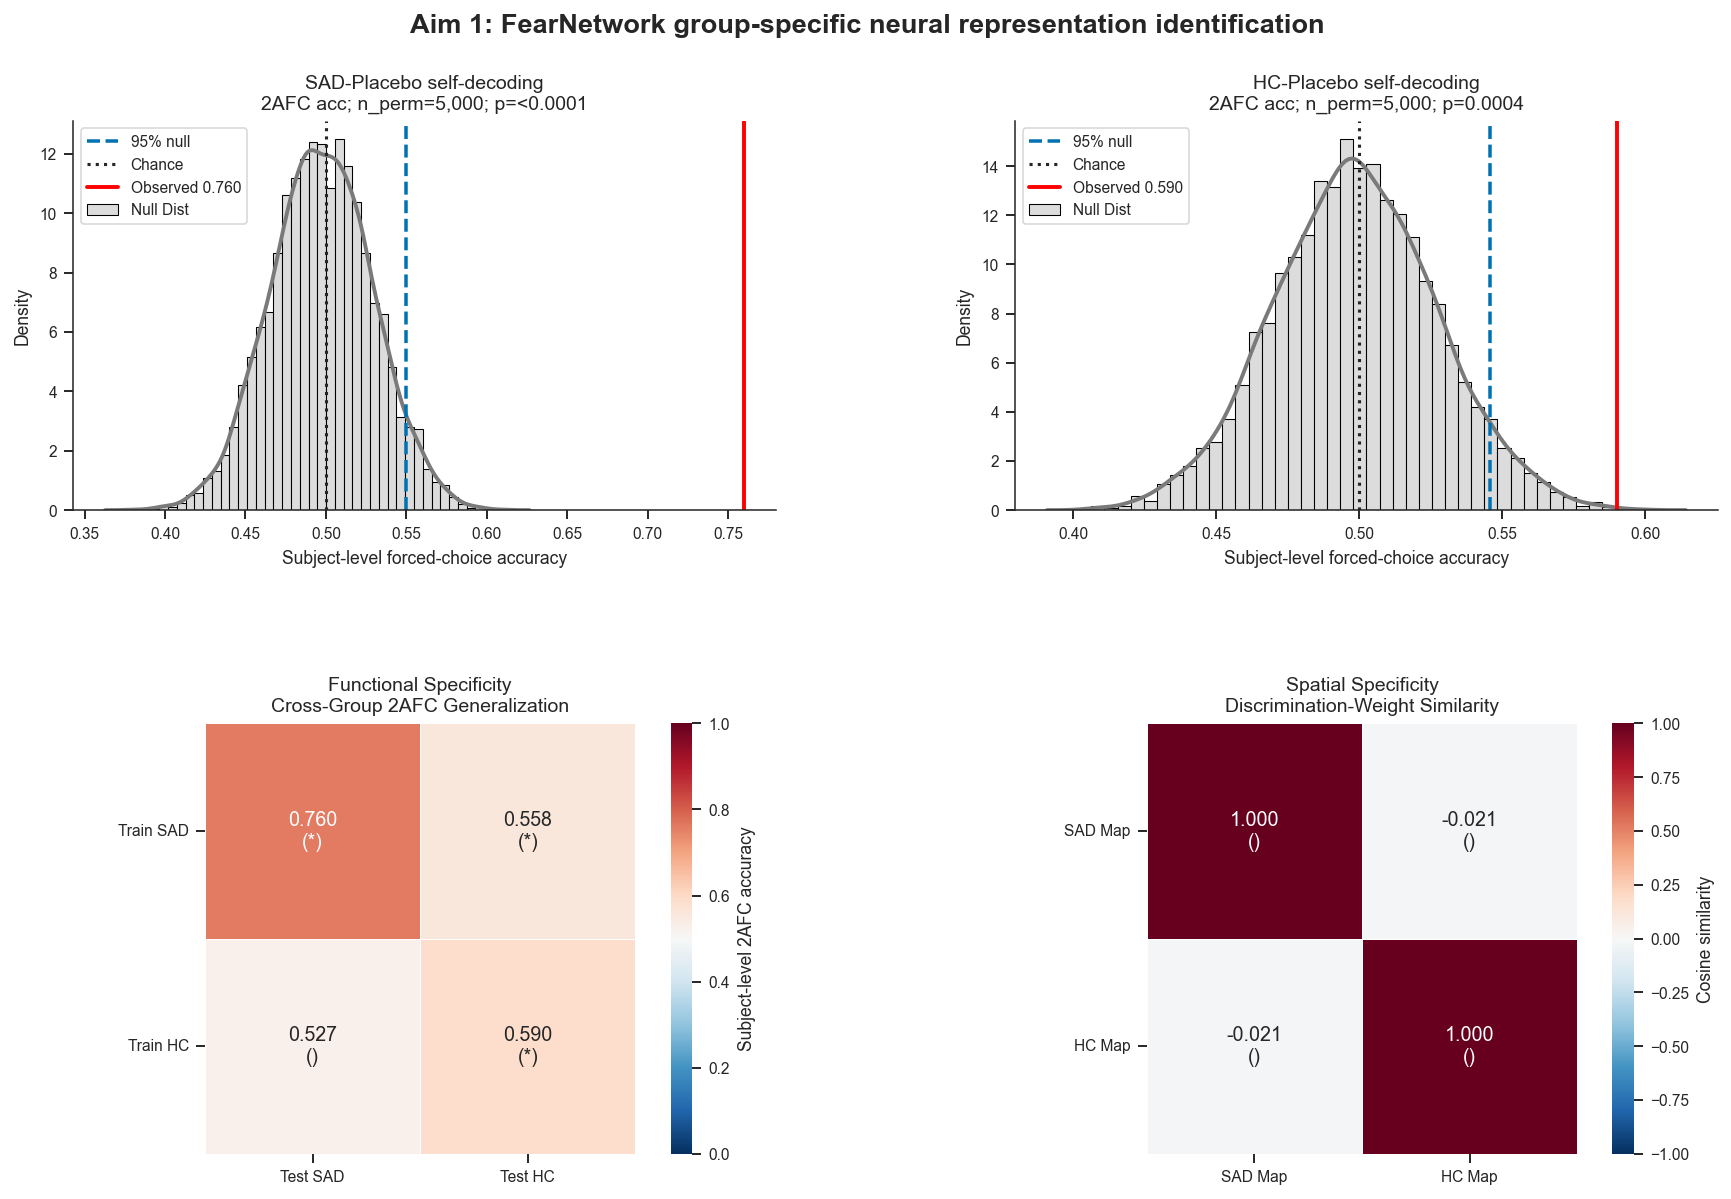

**Aim 1 primary statistics table:** numerical support for the four-panel primary-results figure.

,analysis_block,comparison,train_group,test_group,metric,observed_value,null_mean,null_95_threshold_low,null_95_threshold_high,chance_value,p_perm,q_fdr,n_subjects,n_perm,significance_label
0,self_decoding,SAD self-decoding,SAD,SAD,2AFC accuracy,0.760,0.497,0.436,0.550,0.5,<0.0001,<0.0001,23,5000,***
1,self_decoding,HC self-decoding,HC,HC,2AFC accuracy,0.590,0.499,0.442,0.546,0.5,0.0004,0.0007,28,5000,***
2,functional_specificity,Train SAD to Test SAD,SAD,SAD,2AFC accuracy,0.760,0.497,0.436,0.550,0.5,<0.0001,<0.0001,23,5000,***
3,functional_specificity,Train SAD to Test HC,SAD,HC,2AFC accuracy,0.558,0.500,0.455,0.540,0.5,0.0080,0.0112,28,5000,**
4,functional_specificity,Train HC to Test SAD,HC,SAD,2AFC accuracy,0.527,0.500,0.451,0.543,0.5,0.1724,0.2011,23,5000,ns
5,functional_specificity,Train HC to Test HC,HC,HC,2AFC accuracy,0.590,0.499,0.442,0.546,0.5,0.0004,0.0007,28,5000,***
6,spatial_specificity,SAD vs HC weight similarity,<NA>,<NA>,Cosine similarity,-0.021,0.001,-0.086,0.066,NaN,0.5300,0.5300,<NA>,5000,ns


**Compact Aim 1 manuscript table:**

,Result,Metric,Observed,Null / Chance reference,p_perm,q_fdr,N
0,SAD self-decoding,2AFC accuracy,0.760,null mean=0.497; chance=0.50,<0.0001,<0.0001,23
1,HC self-decoding,2AFC accuracy,0.590,null mean=0.499; chance=0.50,0.0004,0.0007,28
2,Train SAD to Test SAD,2AFC accuracy,0.760,null mean=0.497; chance=0.50,<0.0001,<0.0001,23
3,Train SAD to Test HC,2AFC accuracy,0.558,null mean=0.500; chance=0.50,0.0080,0.0112,28
4,Train HC to Test SAD,2AFC accuracy,0.527,null mean=0.500; chance=0.50,0.1724,0.2011,23
5,Train HC to Test HC,2AFC accuracy,0.590,null mean=0.499; chance=0.50,0.0004,0.0007,28
6,SAD vs HC weight similarity,Cosine similarity,-0.021,NA,0.5300,0.5300,NA


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_stats_table.csv
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_stats_table.xlsx
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_stats_table_compact.csv
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_stats_table_compact.xlsx
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_stats_table.png
Aim 1 primary output paths:
stats_csv: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_stats_table.csv
stats_xlsx: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_stats_table.xlsx
compact_csv: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_primary_stats_table_compact.csv
compact_xlsx: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim

In [8]:
def payload_value(payload, *keys):
    if not isinstance(payload, dict):
        return None
    for key in keys:
        if key in payload:
            return payload[key]
    for value in payload.values():
        if isinstance(value, dict):
            found = payload_value(value, *keys)
            if found is not None:
                return found
    return None

def feature_space_dir(feature_space):
    candidates = [
        RESULTS_ROOT / feature_space,
        MVPA_ROOT / feature_space,
        Path('/output_dir') / feature_space,
        Path('/gscratch/fang/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results') / feature_space,
        Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/results') / feature_space,
        Path('outputs/mvpa_l2') / feature_space,
    ]
    return next((path for path in candidates if path.exists()), candidates[0])

def warn_legacy_checkpoint(path, purpose='notebook display'):
    path = Path(path)
    if path.name in LEGACY_CHECKPOINT_NAMES:
        message = f'WARNING: using archived fallback checkpoint for {purpose}: {path}. Prefer current post-Hyak CSV/Markdown exports when available.'
        warnings.warn(message, RuntimeWarning)
        display(Markdown(f'**Legacy checkpoint fallback:** `{path}` is being used only because the current export was not available for this display.'))

def load_joblib(path, purpose='notebook display'):
    try:
        import joblib
    except ImportError:
        print('joblib is not installed in this kernel.')
        return None
    path = Path(path)
    if not path.exists():
        return None
    warn_legacy_checkpoint(path, purpose=purpose)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return joblib.load(path)

def load_aim1_results(feature_space='FearNetwork'):
    if not aim1_primary_df.empty:
        display(Markdown('**Aim 1 current export available:** `aim1_decoding_primary.csv` is available; legacy checkpoints are not needed for the primary table.'))
    base = feature_space_dir(feature_space)
    paths = [
        base / 'intermediate' / 'stage06_decoding.joblib',
        base / 'intermediate' / 'stage06_aim1_decoding.joblib',
        base / 'checkpoints' / 'cell_06.joblib',
        base / 'cell_06.joblib',
    ]
    for path in paths:
        payload = load_joblib(path, purpose=f'Aim 1 {feature_space} plot reconstruction')
        if payload is None:
            continue
        result = payload_value(payload, 'results_11') or payload
        if isinstance(result, dict):
            return result, path, payload
    return None, None, None

def aim1_placebo_filter(df):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    for col in ['session', 'Drug', 'drug']:
        if col in out.columns:
            values = out[col].astype(str).str.lower()
            keep = values.eq('placebo') | values.eq('nan') | out[col].isna()
            out = out[keep].copy()
    return out

def infer_aim1_family(test_label):
    label = str(test_label).lower()
    if 'self-decoding' in label and 'model tested' not in label:
        return 'Primary'
    if 'generalization index' in label or 'model tested on' in label or 'haufe' in label or 'cosine similarity' in label or 'weight' in label:
        return 'Secondary'
    return 'Sensitivity'

def add_aim1_metadata(df):
    if df is None or df.empty:
        return pd.DataFrame()
    out = aim1_placebo_filter(df).copy()
    if 'family' not in out.columns:
        out['family'] = out.get('test', pd.Series(index=out.index, dtype=object)).map(infer_aim1_family)
    if 'session' not in out.columns:
        out['session'] = 'Placebo'
    if 'feature_space' not in out.columns and 'FeatureSpace' in out.columns:
        out['feature_space'] = out['FeatureSpace']
    if 'feature_space' not in out.columns:
        out['feature_space'] = 'FearNetwork'
    out['analysis_role'] = out['family'].map({'Primary': 'confirmatory', 'Secondary': 'secondary_specificity'}).fillna('sensitivity')
    labels = out.get('test', pd.Series(index=out.index, dtype=object)).astype(str).str.lower()
    out['specificity_domain'] = np.select(
        [labels.str.contains('self-decoding', na=False), labels.str.contains('model tested on|generalization index', na=False), labels.str.contains('haufe|cosine similarity|weight', na=False)],
        ['group_specific_identification', 'functional_specificity', 'spatial_specificity'],
        default='sensitivity_or_audit',
    )
    out['planned_permutations'] = AIM1_EXPECTED_PERMUTATIONS
    return out

def aim1_display_table(df, n=30):
    if df is None or df.empty:
        return pd.DataFrame()
    cols = select_columns(df, [
        'feature_space', 'session', 'analysis_role', 'specificity_domain', 'test', 'estimate', 'p_value', 'observed_permutations', 'planned_permutations', 'n_sad_subjects', 'n_hc_subjects', 'status', 'checkpoint'
    ])
    out = df[cols].copy() if cols else df.copy()
    return out.head(n)

def aim1_result_rows(result, feature_space='FearNetwork'):
    if not isinstance(result, dict):
        return pd.DataFrame()
    rows = []
    sad_perm = result.get('perm_dist_sad')
    hc_perm = result.get('perm_dist_hc')
    n_sad_perm = len(sad_perm) if sad_perm is not None else np.nan
    n_hc_perm = len(hc_perm) if hc_perm is not None else np.nan
    rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'SAD-Placebo self-decoding', 'estimate': result.get('acc_sad_cv'), 'p_value': result.get('p_sad'), 'family': 'Primary', 'observed_permutations': n_sad_perm})
    rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'HC-Placebo self-decoding', 'estimate': result.get('acc_hc_cv'), 'p_value': result.get('p_hc'), 'family': 'Primary', 'observed_permutations': n_hc_perm})
    func = result.get('func_matrix')
    pmat = result.get('p_func_pvals')
    cross_values = []
    if func is not None and pmat is not None:
        func = np.asarray(func)
        pmat = np.asarray(pmat)
        if func.shape == (2, 2) and pmat.shape == (2, 2):
            cross_values = [float(func[0, 1]), float(func[1, 0])]
            rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'SAD-Placebo model tested on HC-Placebo', 'estimate': cross_values[0], 'p_value': pmat[0, 1], 'family': 'Secondary'})
            rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'HC-Placebo model tested on SAD-Placebo', 'estimate': cross_values[1], 'p_value': pmat[1, 0], 'family': 'Secondary'})
    if cross_values:
        rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'Mean cross-group 2AFC generalization index', 'estimate': float(np.nanmean(cross_values)), 'p_value': np.nan, 'family': 'Secondary'})
    rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'SAD-Placebo vs HC-Placebo discrimination-weight cosine similarity', 'estimate': result.get('sim_spatial'), 'p_value': result.get('p_sim'), 'family': 'Secondary'})
    return add_aim1_metadata(pd.DataFrame(rows))

def format_p_value(p_value):
    if p_value is None or pd.isna(p_value):
        return 'NA'
    if isinstance(p_value, str) and p_value.startswith('<'):
        return p_value
    value = pd.to_numeric(pd.Series([p_value]), errors='coerce').iloc[0]
    if pd.isna(value):
        return 'NA'
    if value < 0.0001:
        return '<0.0001'
    return f'{value:.4f}'

def aim1_sig_label(p_value):
    if p_value is None or pd.isna(p_value):
        return 'ns'
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'

def plot_null_distribution(ax, null_values, observed, p_value, title):
    null_values = pd.to_numeric(pd.Series(null_values), errors='coerce').dropna().to_numpy()
    if len(null_values) == 0 or observed is None or pd.isna(observed):
        ax.text(0.5, 0.5, 'Subject-label permutation null missing', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return np.nan
    threshold = np.percentile(null_values, 95)
    sns.histplot(null_values, bins=42, stat='density', color='0.82', edgecolor='black', linewidth=0.55, ax=ax, label='Null Dist')
    try:
        sns.kdeplot(null_values, color='0.48', linewidth=2.0, ax=ax)
    except Exception:
        pass
    ax.axvline(threshold, color=OKABE['blue'], linestyle='--', linewidth=1.8, label='95% null')
    ax.axvline(AIM1_CHANCE_LEVEL, color='0.15', linestyle=':', linewidth=1.6, label='Chance')
    ax.axvline(observed, color='red', linewidth=2.0, label=f'Observed {observed:.3f}')
    ax.set_title(f'{title}\n2AFC acc; n_perm={len(null_values):,}; p={format_p_value(p_value)}')
    ax.set_xlabel('Subject-level forced-choice accuracy')
    ax.set_ylabel('Density')
    ax.legend(frameon=True, fontsize=8, loc='upper left')
    return threshold

def matrix_annotations(values, p_values=None, diagonal_only=False):
    values = np.asarray(values, dtype=float)
    annotations = np.empty(values.shape, dtype=object)
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            star = ''
            if p_values is not None:
                p_val = p_values[row, col]
                if pd.notna(p_val) and p_val < 0.05:
                    star = '*'
            if diagonal_only and row != col:
                star = ''
            annotations[row, col] = f'{values[row, col]:.3f}\n({star})'
    return annotations

def plot_aim1(result, feature_space='FearNetwork', filename='aim1_primary_results'):
    if not isinstance(result, dict):
        print('Aim 1 checkpoint is not available yet.')
        return None
    fig = plt.figure(figsize=(13.2, 9.0), constrained_layout=False)
    gs = fig.add_gridspec(2, 2, height_ratios=[0.95, 1.05], hspace=0.52, wspace=0.34)
    ax_sad = fig.add_subplot(gs[0, 0])
    ax_hc = fig.add_subplot(gs[0, 1])
    ax_func = fig.add_subplot(gs[1, 0])
    ax_spatial = fig.add_subplot(gs[1, 1])
    plot_null_distribution(ax_sad, result.get('perm_dist_sad'), result.get('acc_sad_cv'), result.get('p_sad'), 'SAD-Placebo self-decoding')
    plot_null_distribution(ax_hc, result.get('perm_dist_hc'), result.get('acc_hc_cv'), result.get('p_hc'), 'HC-Placebo self-decoding')
    func = result.get('func_matrix')
    pmat = result.get('p_func_pvals')
    if func is not None:
        func = np.asarray(func, dtype=float)
        pmat = np.asarray(pmat, dtype=float) if pmat is not None else None
        annotations = matrix_annotations(func, pmat)
        sns.heatmap(func, annot=annotations, fmt='', cmap='RdBu_r', vmin=0, vmax=1, cbar=True, cbar_kws={'label': 'Subject-level 2AFC accuracy'}, xticklabels=['Test SAD', 'Test HC'], yticklabels=['Train SAD', 'Train HC'], linewidths=0.5, linecolor='white', square=True, ax=ax_func)
        ax_func.set_title('Functional Specificity\nCross-Group 2AFC Generalization')
        ax_func.set_xlabel('')
        ax_func.set_ylabel('')
        ax_func.tick_params(axis='x', rotation=0)
        ax_func.tick_params(axis='y', rotation=0)
    else:
        ax_func.text(0.5, 0.5, 'Functional specificity matrix missing', ha='center', va='center', transform=ax_func.transAxes)
        ax_func.set_axis_off()
    sim = result.get('sim_spatial')
    if sim is not None and pd.notna(sim):
        spatial = np.array([[1.0, float(sim)], [float(sim), 1.0]])
        p_sim = result.get('p_sim')
        spatial_p = np.array([[np.nan, p_sim], [p_sim, np.nan]], dtype=float)
        annotations = matrix_annotations(spatial, spatial_p)
        sns.heatmap(spatial, annot=annotations, fmt='', cmap='RdBu_r', center=0, vmin=-1, vmax=1, cbar=True, cbar_kws={'label': 'Cosine similarity'}, xticklabels=['SAD Map', 'HC Map'], yticklabels=['SAD Map', 'HC Map'], linewidths=0.5, linecolor='white', square=True, ax=ax_spatial)
        ax_spatial.set_title('Spatial Specificity\nDiscrimination-Weight Similarity')
        ax_spatial.set_xlabel('')
        ax_spatial.set_ylabel('')
        ax_spatial.tick_params(axis='x', rotation=0)
        ax_spatial.tick_params(axis='y', rotation=0)
    else:
        ax_spatial.text(0.5, 0.5, 'Spatial specificity matrix missing', ha='center', va='center', transform=ax_spatial.transAxes)
        ax_spatial.set_axis_off()
    fig.suptitle('Aim 1: FearNetwork group-specific neural representation identification', y=0.985, fontsize=14, fontweight='bold')
    fig.subplots_adjust(left=0.07, right=0.96, bottom=0.08, top=0.90, hspace=0.58, wspace=0.38)
    png = FIG_DIR / f'{filename}.png'
    svg = FIG_DIR / f'{filename}.svg'
    fig.savefig(png, bbox_inches='tight', dpi=300)
    fig.savefig(svg, bbox_inches='tight')
    print(f'Saved {png}')
    print(f'Saved {svg}')
    return fig

def aim1_unique_subject_count(payload, group_key):
    if not isinstance(payload, dict):
        return np.nan
    subsets = payload.get('data_subsets')
    if not isinstance(subsets, dict) or group_key not in subsets:
        return np.nan
    subjects = []
    for phase in ['ext', 'rst']:
        phase_data = subsets[group_key].get(phase, {})
        if isinstance(phase_data, dict) and 'sub' in phase_data:
            subjects.extend(pd.Series(phase_data['sub']).dropna().astype(str).tolist())
    return len(set(subjects)) if subjects else np.nan

def aim1_null_summary(null_values):
    values = pd.to_numeric(pd.Series(null_values), errors='coerce').dropna().to_numpy()
    if len(values) == 0:
        return np.nan, np.nan, np.nan, np.nan
    return float(np.mean(values)), float(np.percentile(values, 2.5)), float(np.percentile(values, 95)), len(values)

def aim1_round_numeric_columns(df):
    out = df.copy()
    for col in ['observed_value', 'null_mean', 'null_95_threshold_low', 'null_95_threshold_high', 'chance_value']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce').round(3)
    return out

def build_aim1_primary_stats_table(result, payload=None):
    columns = ['analysis_block', 'comparison', 'train_group', 'test_group', 'metric', 'observed_value', 'null_mean', 'null_95_threshold_low', 'null_95_threshold_high', 'chance_value', 'p_perm', 'q_fdr', 'n_subjects', 'n_perm', 'significance_label']
    if not isinstance(result, dict):
        return pd.DataFrame(columns=columns)
    sad_null_mean, sad_null_low, sad_null_high, sad_n_perm = aim1_null_summary(result.get('perm_dist_sad'))
    hc_null_mean, hc_null_low, hc_null_high, hc_n_perm = aim1_null_summary(result.get('perm_dist_hc'))
    sad2hc_null_mean, sad2hc_null_low, sad2hc_null_high, sad2hc_n_perm = aim1_null_summary(result.get('perm_dist_sad2hc'))
    hc2sad_null_mean, hc2sad_null_low, hc2sad_null_high, hc2sad_n_perm = aim1_null_summary(result.get('perm_dist_hc2sad'))
    spatial_null_mean, spatial_null_low, spatial_null_high, spatial_n_perm = aim1_null_summary(result.get('spatial_perm_dist'))
    sad_n = aim1_unique_subject_count(payload, 'SAD_Placebo')
    hc_n = aim1_unique_subject_count(payload, 'HC_Placebo')
    func = np.asarray(result.get('func_matrix'), dtype=float) if result.get('func_matrix') is not None else np.full((2, 2), np.nan)
    pmat = np.asarray(result.get('p_func_pvals'), dtype=float) if result.get('p_func_pvals') is not None else np.full((2, 2), np.nan)
    n_perm_common = np.nanmax([sad_n_perm, hc_n_perm]) if pd.notna(sad_n_perm) or pd.notna(hc_n_perm) else np.nan
    sad2hc_n_perm = sad2hc_n_perm if pd.notna(sad2hc_n_perm) else n_perm_common
    hc2sad_n_perm = hc2sad_n_perm if pd.notna(hc2sad_n_perm) else n_perm_common
    spatial_n_perm = spatial_n_perm if pd.notna(spatial_n_perm) else n_perm_common
    rows = [
        {'analysis_block': 'self_decoding', 'comparison': 'SAD self-decoding', 'train_group': 'SAD', 'test_group': 'SAD', 'metric': '2AFC accuracy', 'observed_value': result.get('acc_sad_cv'), 'null_mean': sad_null_mean, 'null_95_threshold_low': sad_null_low, 'null_95_threshold_high': sad_null_high, 'chance_value': AIM1_CHANCE_LEVEL, 'p_perm': result.get('p_sad'), 'n_subjects': sad_n, 'n_perm': sad_n_perm},
        {'analysis_block': 'self_decoding', 'comparison': 'HC self-decoding', 'train_group': 'HC', 'test_group': 'HC', 'metric': '2AFC accuracy', 'observed_value': result.get('acc_hc_cv'), 'null_mean': hc_null_mean, 'null_95_threshold_low': hc_null_low, 'null_95_threshold_high': hc_null_high, 'chance_value': AIM1_CHANCE_LEVEL, 'p_perm': result.get('p_hc'), 'n_subjects': hc_n, 'n_perm': hc_n_perm},
        {'analysis_block': 'functional_specificity', 'comparison': 'Train SAD to Test SAD', 'train_group': 'SAD', 'test_group': 'SAD', 'metric': '2AFC accuracy', 'observed_value': func[0, 0], 'null_mean': sad_null_mean, 'null_95_threshold_low': sad_null_low, 'null_95_threshold_high': sad_null_high, 'chance_value': AIM1_CHANCE_LEVEL, 'p_perm': pmat[0, 0], 'n_subjects': sad_n, 'n_perm': sad_n_perm},
        {'analysis_block': 'functional_specificity', 'comparison': 'Train SAD to Test HC', 'train_group': 'SAD', 'test_group': 'HC', 'metric': '2AFC accuracy', 'observed_value': func[0, 1], 'null_mean': sad2hc_null_mean, 'null_95_threshold_low': sad2hc_null_low, 'null_95_threshold_high': sad2hc_null_high, 'chance_value': AIM1_CHANCE_LEVEL, 'p_perm': pmat[0, 1], 'n_subjects': hc_n, 'n_perm': sad2hc_n_perm},
        {'analysis_block': 'functional_specificity', 'comparison': 'Train HC to Test SAD', 'train_group': 'HC', 'test_group': 'SAD', 'metric': '2AFC accuracy', 'observed_value': func[1, 0], 'null_mean': hc2sad_null_mean, 'null_95_threshold_low': hc2sad_null_low, 'null_95_threshold_high': hc2sad_null_high, 'chance_value': AIM1_CHANCE_LEVEL, 'p_perm': pmat[1, 0], 'n_subjects': sad_n, 'n_perm': hc2sad_n_perm},
        {'analysis_block': 'functional_specificity', 'comparison': 'Train HC to Test HC', 'train_group': 'HC', 'test_group': 'HC', 'metric': '2AFC accuracy', 'observed_value': func[1, 1], 'null_mean': hc_null_mean, 'null_95_threshold_low': hc_null_low, 'null_95_threshold_high': hc_null_high, 'chance_value': AIM1_CHANCE_LEVEL, 'p_perm': pmat[1, 1], 'n_subjects': hc_n, 'n_perm': hc_n_perm},
        {'analysis_block': 'spatial_specificity', 'comparison': 'SAD vs HC weight similarity', 'train_group': pd.NA, 'test_group': pd.NA, 'metric': 'Cosine similarity', 'observed_value': result.get('sim_spatial'), 'null_mean': spatial_null_mean, 'null_95_threshold_low': spatial_null_low, 'null_95_threshold_high': spatial_null_high, 'chance_value': np.nan, 'p_perm': result.get('p_sim'), 'n_subjects': np.nan, 'n_perm': spatial_n_perm},
    ]
    out = pd.DataFrame(rows, columns=[col for col in columns if col != 'q_fdr'])
    out['q_fdr'] = bh_fdr(out['p_perm'])
    out['significance_label'] = out['p_perm'].map(aim1_sig_label)
    out = out[columns]
    out['n_subjects'] = pd.to_numeric(out['n_subjects'], errors='coerce').astype('Int64')
    out['n_perm'] = pd.to_numeric(out['n_perm'], errors='coerce').astype('Int64')
    out = aim1_round_numeric_columns(out)
    out['p_perm'] = out['p_perm'].map(format_p_value)
    out['q_fdr'] = out['q_fdr'].map(format_p_value)
    return out

def build_aim1_compact_stats_table(stats_table):
    if stats_table is None or stats_table.empty:
        return pd.DataFrame(columns=['Result', 'Metric', 'Observed', 'Null / Chance reference', 'p_perm', 'q_fdr', 'N'])
    out = pd.DataFrame({
        'Result': stats_table['comparison'],
        'Metric': stats_table['metric'],
        'Observed': stats_table['observed_value'].map(lambda value: 'NA' if pd.isna(value) else f'{value:.3f}'),
        'Null / Chance reference': stats_table.apply(lambda row: f"chance={row['chance_value']:.2f}" if pd.notna(row['chance_value']) and pd.isna(row['null_mean']) else f"null mean={row['null_mean']:.3f}; chance={row['chance_value']:.2f}" if pd.notna(row['chance_value']) else 'NA', axis=1),
        'p_perm': stats_table['p_perm'].map(format_p_value),
        'q_fdr': stats_table['q_fdr'].map(format_p_value),
        'N': stats_table['n_subjects'].astype('string').fillna('NA'),
    })
    return out

def save_aim1_stats_tables(stats_table, compact_table):
    paths = {
        'stats_csv': FIG_DIR / 'aim1_primary_stats_table.csv',
        'stats_xlsx': FIG_DIR / 'aim1_primary_stats_table.xlsx',
        'compact_csv': FIG_DIR / 'aim1_primary_stats_table_compact.csv',
        'compact_xlsx': FIG_DIR / 'aim1_primary_stats_table_compact.xlsx',
        'stats_png': FIG_DIR / 'aim1_primary_stats_table.png',
    }
    stats_table.to_csv(paths['stats_csv'], index=False)
    stats_table.to_excel(paths['stats_xlsx'], index=False)
    compact_table.to_csv(paths['compact_csv'], index=False)
    compact_table.to_excel(paths['compact_xlsx'], index=False)
    fig_width = 13.0
    fig_height = max(2.8, 0.46 * len(compact_table) + 1.0)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    table = ax.table(cellText=compact_table.values, colLabels=compact_table.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.3)
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.35)
        if row == 0:
            cell.set_facecolor('#EAEAEA')
            cell.set_text_props(weight='bold')
    fig.tight_layout()
    fig.savefig(paths['stats_png'], bbox_inches='tight', dpi=300)
    plt.close(fig)
    for path in paths.values():
        print(f'Saved {path}')
    return paths

aim1_result, aim1_path, aim1_payload = load_aim1_results('FearNetwork')
print(f'Aim 1 plot source: {aim1_path}')
aim1_rows = add_aim1_metadata(aim1_primary_df) if not aim1_primary_df.empty else aim1_result_rows(aim1_result, 'FearNetwork')
if aim1_rows.empty:
    print('Aim 1 result table is not available yet.')
else:
    display(Markdown('**Aim 1 PROJECT_CONTEXT alignment check:** cohort=`SAD-Placebo`/`HC-Placebo`; contrast=CSR vs CSS; metric=subject-level forced-choice accuracy; planned permutations=5,000; cross-group decoding and weight similarity are specificity checks supporting the primary result.'))
    display(Markdown('**Primary decoding tests:** SAD-Placebo and HC-Placebo self-decoding against the subject-level forced-choice permutation null.'))
    display(aim1_display_table(aim1_rows[aim1_rows['family'].eq('Primary')], n=20))
    secondary_rows = aim1_rows[aim1_rows['family'].eq('Secondary')]
    if not secondary_rows.empty:
        display(Markdown('**Specificity checks:** cross-group 2AFC generalization and `SAD`-`HC` discrimination-weight similarity within placebo-session subjects.'))
        display(aim1_display_table(secondary_rows, n=20))

show_figure_once(plot_aim1(aim1_result, 'FearNetwork', filename='aim1_primary_results'))
aim1_primary_stats_table = build_aim1_primary_stats_table(aim1_result, aim1_payload)
aim1_primary_stats_table_compact = build_aim1_compact_stats_table(aim1_primary_stats_table)
if aim1_primary_stats_table.empty:
    print('Aim 1 primary statistics table is not available yet.')
else:
    display(Markdown('**Aim 1 primary statistics table:** numerical support for the four-panel primary-results figure.'))
    display(aim1_primary_stats_table)
    display(Markdown('**Compact Aim 1 manuscript table:**'))
    display(aim1_primary_stats_table_compact)
    aim1_primary_output_paths = save_aim1_stats_tables(aim1_primary_stats_table, aim1_primary_stats_table_compact)
    print('Aim 1 primary output paths:')
    for label, path in aim1_primary_output_paths.items():
        print(f'{label}: {path}')



### Aim 1 Secondary: Haufe-Transformed Spatial Distribution

Controlled by `task_Visualization-Aim1-secondary.md`. This subsection creates the Aim 1 secondary supportive evidence figure and companion table for the distribution of displayed Haufe-transformed voxels across FearNetwork ROIs. SAD is displayed using ROI-wise BH-FDR surviving voxels when available; HC is displayed using the same number of top absolute Haufe-score voxels for matched comparison.


**Table X. ROI distribution of displayed Haufe voxels across FearNetwork ROIs**

,ROI,SAD % displayed voxels,HC % displayed voxels,Difference (SAD - HC)
0,left_hippocampus,5.39,1.47,3.92
1,right_hippocampus,11.21,1.87,9.35
2,left_amygdala,9.71,14.56,-4.85
3,right_amygdala,2.88,11.54,-8.65
4,left_insula,0.00,0.87,-0.87
5,right_insula,0.59,2.08,-1.48
6,left_acc,0.00,0.00,0.00
7,right_acc,1.29,0.43,0.86
8,left_vmpfc,0.00,1.11,-1.11
9,right_vmpfc,0.00,3.49,-3.49


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Table_Aim1_secondary_Haufe_ROI_distribution.csv
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Table_Aim1_secondary_Haufe_ROI_distribution.xlsx
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_Aim1_secondary_Haufe_distribution_caption.txt


**Final caption text:**

Rows A and B show the spatial distribution of Haufe-transformed scores in SAD and HC placebo-session participants for the FearNetwork CSR-versus-CSS decoder. SAD is shown using ROI-FDR voxels (n=53); HC is shown using the same number of top absolute Haufe-score voxels for matched comparison (n=53). Row C summarizes the distribution of displayed voxels across FearNetwork ROIs as the percentage of each ROI displayed. Rows A and B use a shared symmetric color scale centered at zero for the displayed Haufe-transformed scores. Together, these results provide secondary supportive evidence that the discriminative neural pattern is distributed differently across FearNetwork regions in SAD and HC, without promoting this descriptive spatial distribution above the primary Aim 1 decoding inference.

Aim 1 secondary output paths:
table_csv: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Table_Aim1_secondary_Haufe_ROI_distribution.csv
table_xlsx: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Table_Aim1_secondary_Haufe_ROI_distribution.xlsx
caption_txt: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_Aim1_secondary_Haufe_distribution_caption.txt


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_Aim1_secondary_Haufe_distribution.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_Aim1_secondary_Haufe_distribution.svg


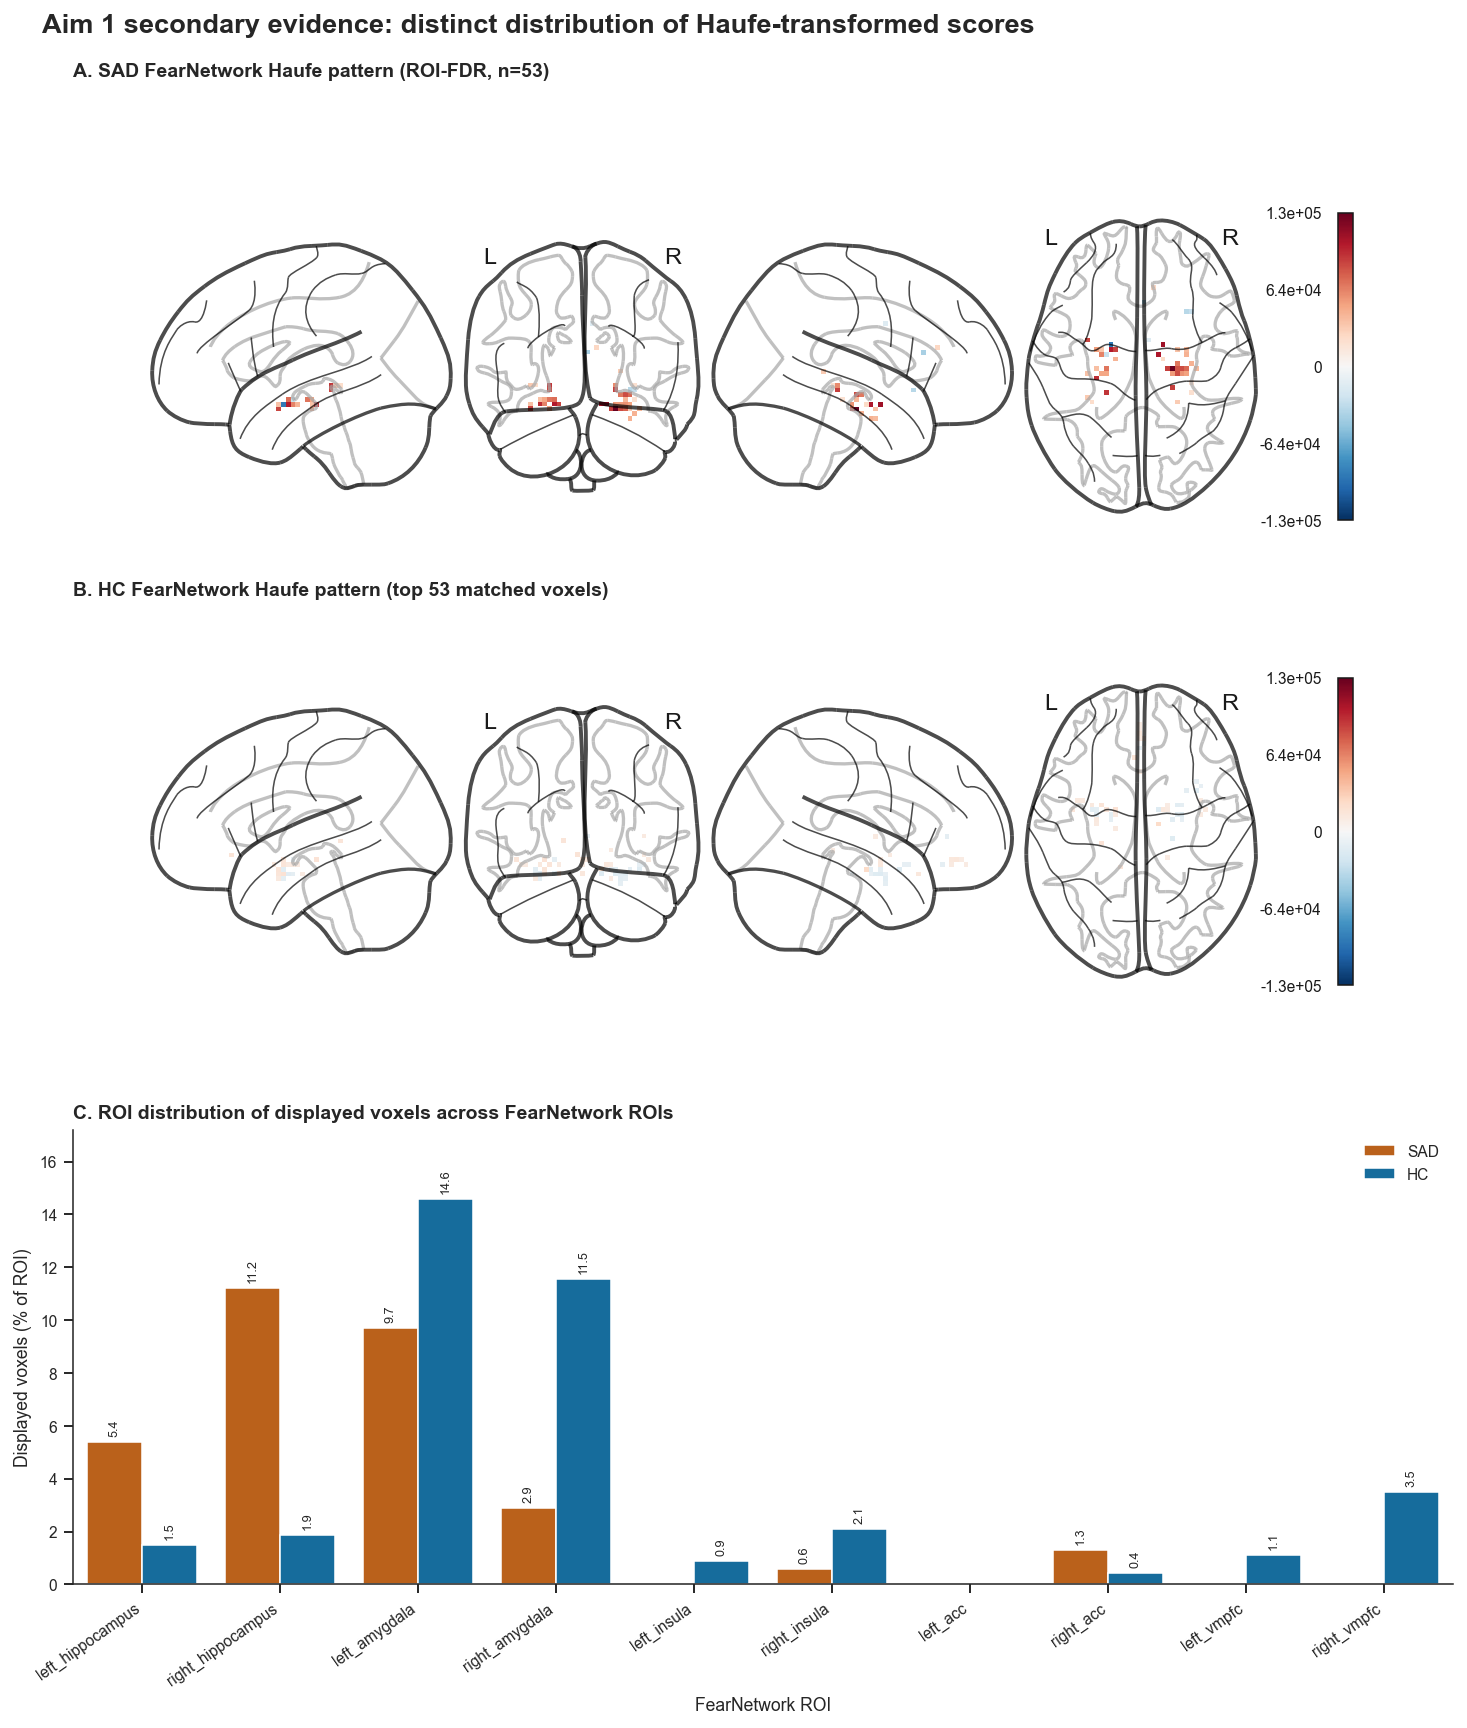

In [9]:
AIM1_SECONDARY_ROI_ORDER = [
    'left_hippocampus',
    'right_hippocampus',
    'left_amygdala',
    'right_amygdala',
    'left_insula',
    'right_insula',
    'left_acc',
    'right_acc',
    'left_vmpfc',
    'right_vmpfc',
]
AIM1_SECONDARY_ROI_DIR = Path('/Users/xiaoqianxiao/tool/parcellation/Gillian_anatomically_constrained')
AIM1_SECONDARY_ALPHA = 0.05
AIM1_SECONDARY_DEFAULT_TOP_N = 53


def aim1_secondary_roi_label(parcel_name):
    parts = str(parcel_name).split('_')
    if len(parts) >= 3 and parts[-1].isdigit():
        return '_'.join(parts[:-1])
    if len(parts) >= 2 and parts[-1].isdigit():
        return parts[0]
    return str(parcel_name)


def aim1_secondary_load_cell3(feature_space='FearNetwork'):
    base = feature_space_dir(feature_space)
    for path in [base / 'intermediate' / 'stage03_inputs.joblib', base / 'checkpoints' / 'cell_03.joblib', base / 'cell_03.joblib']:
        payload = load_joblib(path, purpose=f'Aim 1 {feature_space} Haufe ROI metadata')
        if isinstance(payload, dict) and 'parcel_names_ext' in payload:
            return payload, path
    return {}, None


def aim1_secondary_load_perm_payload(group, feature_space='FearNetwork'):
    base = feature_space_dir(feature_space)
    candidates = [
        base / 'checkpoints' / f'perm_results_{group}_fear_network_2way.joblib',
        base / f'perm_results_{group}_fear_network_2way.joblib',
        base / 'intermediate' / f'perm_results_{group}_fear_network_2way.joblib',
    ]
    for path in candidates:
        payload = load_joblib(path, purpose=f'Aim 1 {group} Haufe ROI-FDR p-values')
        if isinstance(payload, dict):
            return payload, path
    return {}, None


def aim1_secondary_bh_fdr_mask(p_values, roi_labels, roi_order, alpha=AIM1_SECONDARY_ALPHA):
    p_values = np.asarray(p_values, dtype=float).ravel()
    roi_labels = np.asarray(roi_labels, dtype=object)
    mask = np.zeros(p_values.shape[0], dtype=bool)
    for roi in roi_order:
        idx = np.flatnonzero(roi_labels == roi)
        idx = idx[np.isfinite(p_values[idx])]
        if idx.size == 0:
            continue
        roi_p = p_values[idx]
        order = np.argsort(roi_p)
        sorted_p = roi_p[order]
        thresholds = alpha * (np.arange(1, sorted_p.size + 1) / sorted_p.size)
        passed = np.flatnonzero(sorted_p <= thresholds)
        if passed.size:
            keep = order[: passed[-1] + 1]
            mask[idx[keep]] = True
    return mask


def aim1_secondary_top_abs_mask(values, top_n):
    values = np.asarray(values, dtype=float).ravel()
    finite_idx = np.flatnonzero(np.isfinite(values))
    mask = np.zeros(values.shape[0], dtype=bool)
    if top_n <= 0 or finite_idx.size == 0:
        return mask
    selected = finite_idx[np.argsort(np.abs(values[finite_idx]))[-min(int(top_n), finite_idx.size):]]
    mask[selected] = True
    return mask


def aim1_secondary_roi_mask_path(roi, roi_dir=AIM1_SECONDARY_ROI_DIR):
    exact_candidates = [roi_dir / f'{roi}.nii.gz', roi_dir / f'{roi}.nii']
    for path in exact_candidates:
        if path.exists():
            return path
    matches = sorted(roi_dir.glob(f'*{roi}*.nii*'))
    return matches[0] if matches else None


def aim1_secondary_reconstruct_map(pattern, display_mask, parcel_names, roi_dir=AIM1_SECONDARY_ROI_DIR):
    try:
        import nibabel as nib
    except ImportError:
        print('nibabel is not installed; Aim 1 secondary brain maps cannot be reconstructed in this kernel.')
        return None
    pattern = np.asarray(pattern, dtype=float).ravel()
    display_mask = np.asarray(display_mask, dtype=bool).ravel()
    roi_labels = np.asarray([aim1_secondary_roi_label(name) for name in parcel_names], dtype=object)
    first_path = next((aim1_secondary_roi_mask_path(roi, roi_dir) for roi in AIM1_SECONDARY_ROI_ORDER if aim1_secondary_roi_mask_path(roi, roi_dir) is not None), None)
    if first_path is None:
        print(f'No ROI masks found in {roi_dir}.')
        return None
    ref_img = nib.load(str(first_path))
    final_vol = np.zeros(ref_img.shape, dtype=float)
    for roi in pd.unique(roi_labels):
        roi_path = aim1_secondary_roi_mask_path(str(roi), roi_dir)
        if roi_path is None:
            continue
        roi_img = nib.load(str(roi_path))
        roi_mask = roi_img.get_fdata() > 0
        feature_idx = np.flatnonzero(roi_labels == roi)
        if feature_idx.size == 0:
            continue
        values = pattern[feature_idx] * display_mask[feature_idx]
        voxels = np.flatnonzero(roi_mask.ravel())
        n_voxels = min(values.size, voxels.size)
        if n_voxels == 0:
            continue
        final_vol.ravel()[voxels[:n_voxels]] = values[:n_voxels]
        if values.size != voxels.size:
            print(f'Warning: {roi} has {values.size} feature values but {voxels.size} mask voxels; filled {n_voxels}.')
    return nib.Nifti1Image(final_vol, ref_img.affine)


def aim1_secondary_roi_distribution(display_mask, roi_labels, roi_order=AIM1_SECONDARY_ROI_ORDER):
    rows = []
    display_mask = np.asarray(display_mask, dtype=bool).ravel()
    roi_labels = np.asarray(roi_labels, dtype=object)
    for roi in roi_order:
        roi_mask = roi_labels == roi
        roi_voxels = int(np.sum(roi_mask))
        selected_voxels = int(np.sum(display_mask & roi_mask))
        pct_roi = 100.0 * selected_voxels / roi_voxels if roi_voxels else np.nan
        rows.append({'ROI': roi, 'ROI voxels': roi_voxels, 'Displayed voxels': selected_voxels, 'Displayed voxels (% of ROI)': pct_roi})
    return pd.DataFrame(rows)


def aim1_secondary_prepare(feature_space='FearNetwork'):
    if not isinstance(aim1_result, dict):
        print('Aim 1 result payload is not available; cannot build Aim 1 secondary Haufe figure.')
        return None
    cell3, cell3_path = aim1_secondary_load_cell3(feature_space)
    parcel_names = list(cell3.get('parcel_names_ext', []))
    if not parcel_names:
        print('Aim 1 parcel_names_ext metadata is not available; cannot build Aim 1 secondary Haufe figure.')
        return None
    roi_labels = np.asarray([aim1_secondary_roi_label(name) for name in parcel_names], dtype=object)
    patterns = {'SAD': np.asarray(aim1_result.get('map_sad'), dtype=float).ravel(), 'HC': np.asarray(aim1_result.get('map_hc'), dtype=float).ravel()}
    if patterns['SAD'].size != len(parcel_names) or patterns['HC'].size != len(parcel_names):
        print('Aim 1 Haufe pattern length does not match parcel_names_ext; cannot build Aim 1 secondary Haufe figure.')
        return None
    perm_payloads = {}
    perm_paths = {}
    for group in ['SAD', 'HC']:
        perm_payloads[group], perm_paths[group] = aim1_secondary_load_perm_payload(group, feature_space)
    sad_p_values = perm_payloads.get('SAD', {}).get('p_values_raw')
    sad_fdr_mask = aim1_secondary_bh_fdr_mask(sad_p_values, roi_labels, AIM1_SECONDARY_ROI_ORDER) if sad_p_values is not None else np.zeros(len(parcel_names), dtype=bool)
    sad_count = int(np.sum(sad_fdr_mask))
    sad_mode = 'ROI-FDR' if sad_count > 0 else f'top {AIM1_SECONDARY_DEFAULT_TOP_N} absolute Haufe-score voxels'
    sad_display_mask = sad_fdr_mask if sad_count > 0 else aim1_secondary_top_abs_mask(patterns['SAD'], AIM1_SECONDARY_DEFAULT_TOP_N)
    top_n = int(np.sum(sad_display_mask)) if int(np.sum(sad_display_mask)) > 0 else AIM1_SECONDARY_DEFAULT_TOP_N
    hc_display_mask = aim1_secondary_top_abs_mask(patterns['HC'], top_n)
    map_imgs = {group: aim1_secondary_reconstruct_map(patterns[group], mask, parcel_names) for group, mask in {'SAD': sad_display_mask, 'HC': hc_display_mask}.items()}
    distributions = {
        'SAD': aim1_secondary_roi_distribution(sad_display_mask, roi_labels),
        'HC': aim1_secondary_roi_distribution(hc_display_mask, roi_labels),
    }
    table = distributions['SAD'][['ROI', 'Displayed voxels (% of ROI)']].rename(columns={'Displayed voxels (% of ROI)': 'SAD % displayed voxels'})
    table = table.merge(distributions['HC'][['ROI', 'Displayed voxels (% of ROI)']].rename(columns={'Displayed voxels (% of ROI)': 'HC % displayed voxels'}), on='ROI', how='left')
    table['Difference (SAD - HC)'] = table['SAD % displayed voxels'] - table['HC % displayed voxels']
    table = table[['ROI', 'SAD % displayed voxels', 'HC % displayed voxels', 'Difference (SAD - HC)']]
    return {
        'feature_space': feature_space,
        'cell3_path': cell3_path,
        'perm_paths': perm_paths,
        'parcel_names': parcel_names,
        'roi_labels': roi_labels,
        'patterns': patterns,
        'display_masks': {'SAD': sad_display_mask, 'HC': hc_display_mask},
        'map_imgs': map_imgs,
        'distributions': distributions,
        'table': table,
        'sad_mode': sad_mode,
        'sad_count': int(np.sum(sad_display_mask)),
        'hc_count': int(np.sum(hc_display_mask)),
        'shared_color_scale': all(img is not None for img in map_imgs.values()),
    }


def aim1_secondary_caption(prepared):
    if not isinstance(prepared, dict):
        return 'Aim 1 secondary evidence caption unavailable because required Haufe inputs were not available.'
    scale_sentence = 'Rows A and B use a shared symmetric color scale centered at zero for the displayed Haufe-transformed scores.' if prepared.get('shared_color_scale') else 'Rows A and B are shown for within-group visualization; comparative interpretation should focus primarily on Row C.'
    return ('Rows A and B show the spatial distribution of Haufe-transformed scores in SAD and HC placebo-session participants for the FearNetwork CSR-versus-CSS decoder. '
            f'SAD is shown using {prepared["sad_mode"]} voxels (n={prepared["sad_count"]}); HC is shown using the same number of top absolute Haufe-score voxels for matched comparison (n={prepared["hc_count"]}). '
            'Row C summarizes the distribution of displayed voxels across FearNetwork ROIs as the percentage of each ROI displayed. '
            f'{scale_sentence} '
            'Together, these results provide secondary supportive evidence that the discriminative neural pattern is distributed differently across FearNetwork regions in SAD and HC, without promoting this descriptive spatial distribution above the primary Aim 1 decoding inference.')


def plot_aim1_secondary_haufe(prepared, filename='Figure_Aim1_secondary_Haufe_distribution'):
    if not isinstance(prepared, dict):
        print('Aim 1 secondary Haufe figure is not available because required inputs were missing.')
        return None
    try:
        from nilearn import plotting
    except ImportError:
        print('nilearn is not installed; Aim 1 secondary brain-map rows cannot be plotted in this kernel.')
        return None
    table = prepared['table'].copy()
    long_df = table.melt(id_vars='ROI', value_vars=['SAD % displayed voxels', 'HC % displayed voxels'], var_name='Group', value_name='Displayed voxels (% of ROI)')
    long_df['Group'] = long_df['Group'].str.replace(' % displayed voxels', '', regex=False)
    displayed_values = []
    for group in ['SAD', 'HC']:
        pattern = prepared['patterns'][group]
        mask = prepared['display_masks'][group]
        displayed_values.extend(np.abs(pattern[mask & np.isfinite(pattern)]).tolist())
    vmax = float(np.nanmax(displayed_values)) if displayed_values else np.nan
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = None
    fig = plt.figure(figsize=(11.2, 12.4), constrained_layout=False)
    gs = fig.add_gridspec(3, 1, height_ratios=[1.05, 1.05, 1.25], hspace=0.34)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[1, 0])
    ax_c = fig.add_subplot(gs[2, 0])
    common_kwargs = {'display_mode': 'lyrz', 'cmap': 'RdBu_r', 'plot_abs': False, 'colorbar': True, 'figure': fig, 'threshold': 1e-12}
    if vmax is not None:
        common_kwargs.update({'vmin': -vmax, 'vmax': vmax})
    plotting.plot_glass_brain(prepared['map_imgs']['SAD'], axes=ax_a, title=None, **common_kwargs)
    plotting.plot_glass_brain(prepared['map_imgs']['HC'], axes=ax_b, title=None, **common_kwargs)
    ax_a.set_title(f'A. SAD FearNetwork Haufe pattern ({prepared["sad_mode"]}, n={prepared["sad_count"]})', loc='left', fontweight='bold', pad=8)
    ax_b.set_title(f'B. HC FearNetwork Haufe pattern (top {prepared["hc_count"]} matched voxels)', loc='left', fontweight='bold', pad=8)
    sns.barplot(data=long_df, x='ROI', y='Displayed voxels (% of ROI)', hue='Group', palette=GROUP_COLORS, ax=ax_c)
    ax_c.set_title('C. ROI distribution of displayed voxels across FearNetwork ROIs', loc='left', fontweight='bold')
    ax_c.set_xlabel('FearNetwork ROI')
    ax_c.set_ylabel('Displayed voxels (% of ROI)')
    ax_c.tick_params(axis='x', rotation=35)
    for tick in ax_c.get_xticklabels():
        tick.set_ha('right')
    ax_c.legend(title='', frameon=False, loc='upper right')
    max_height = pd.to_numeric(long_df['Displayed voxels (% of ROI)'], errors='coerce').max()
    if pd.notna(max_height) and len(ax_c.patches) <= 24:
        offset = max(max_height * 0.015, 0.15)
        for patch in ax_c.patches:
            height = patch.get_height()
            if np.isfinite(height) and height > 0:
                ax_c.text(patch.get_x() + patch.get_width() / 2, height + offset, f'{height:.1f}', ha='center', va='bottom', fontsize=6.5, rotation=90)
    ax_c.set_ylim(0, max(5.0, max_height * 1.18 if pd.notna(max_height) else 5.0))
    sns.despine(ax=ax_c)
    fig.suptitle('Aim 1 secondary evidence: distinct distribution of Haufe-transformed scores', x=0.06, y=0.985, ha='left', fontsize=14, fontweight='bold')
    fig.subplots_adjust(left=0.08, right=0.96, bottom=0.08, top=0.94)
    png = FIG_DIR / f'{filename}.png'
    svg = FIG_DIR / f'{filename}.svg'
    fig.savefig(png, bbox_inches='tight', dpi=300)
    fig.savefig(svg, bbox_inches='tight')
    print(f'Saved {png}')
    print(f'Saved {svg}')
    return fig


def save_aim1_secondary_outputs(prepared):
    if not isinstance(prepared, dict):
        return {}
    table = prepared['table'].copy()
    rounded = table.copy()
    for col in ['SAD % displayed voxels', 'HC % displayed voxels', 'Difference (SAD - HC)']:
        rounded[col] = pd.to_numeric(rounded[col], errors='coerce').round(2)
    paths = {
        'table_csv': FIG_DIR / 'Table_Aim1_secondary_Haufe_ROI_distribution.csv',
        'table_xlsx': FIG_DIR / 'Table_Aim1_secondary_Haufe_ROI_distribution.xlsx',
        'caption_txt': FIG_DIR / 'Figure_Aim1_secondary_Haufe_distribution_caption.txt',
    }
    rounded.to_csv(paths['table_csv'], index=False)
    rounded.to_excel(paths['table_xlsx'], index=False)
    caption = aim1_secondary_caption(prepared)
    paths['caption_txt'].write_text(caption + '\n')
    for path in paths.values():
        print(f'Saved {path}')
    return paths


aim1_secondary_haufe = aim1_secondary_prepare('FearNetwork')
if aim1_secondary_haufe is None:
    print('No Aim 1 secondary Haufe outputs were generated.')
else:
    display(Markdown('**Table X. ROI distribution of displayed Haufe voxels across FearNetwork ROIs**'))
    display(aim1_secondary_haufe['table'].round(2))
    aim1_secondary_paths = save_aim1_secondary_outputs(aim1_secondary_haufe)
    display(Markdown('**Final caption text:**'))
    display(Markdown(aim1_secondary_caption(aim1_secondary_haufe)))
    print('Aim 1 secondary output paths:')
    for label, path in aim1_secondary_paths.items():
        print(f'{label}: {path}')
    show_figure_once(plot_aim1_secondary_haufe(aim1_secondary_haufe))


### Aim 1 Sensitivity: Robustness Across Feature Spaces And SCR Cohorts

Controlled by `task_Visualization-Aim1-sensitivity.md`. Figure S1 and Table S1 evaluate whether Aim 1 CSR-CSS decoding, functional specificity, and spatial specificity are robust across alternative feature spaces and SCR-defined responder/learner cohorts. Panel A is the within-group decoding heatmap, Panel B is the paired dumbbell summary of within-group/self versus cross-group accuracy, and Panel C is the spatial-specificity lollipop/forest summary.


Loaded aim1_mask_feature_sensitivity.csv: 10 rows x 13 columns
Loaded aim1_scr_sensitivity.csv: 36 rows x 25 columns


**Aim 1 current export available:** `aim1_decoding_primary.csv` is available; legacy checkpoints are not needed for the primary table.

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_1870/3905044893.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Aim 1 FearNetwork plot reconstruction: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

**Aim 1 current export available:** `aim1_decoding_primary.csv` is available; legacy checkpoints are not needed for the primary table.

...

**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

**Aim 1 current export available:** `aim1_decoding_primary.csv` is available; legacy checkpoints are not needed for the primary table.

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_1870/3905044893.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Aim 1 MemoryFearNetwork plot reconstruction: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/MemoryFearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/MemoryFearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_S1_Aim1_sensitivity.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_S1_Aim1_sensitivity.svg


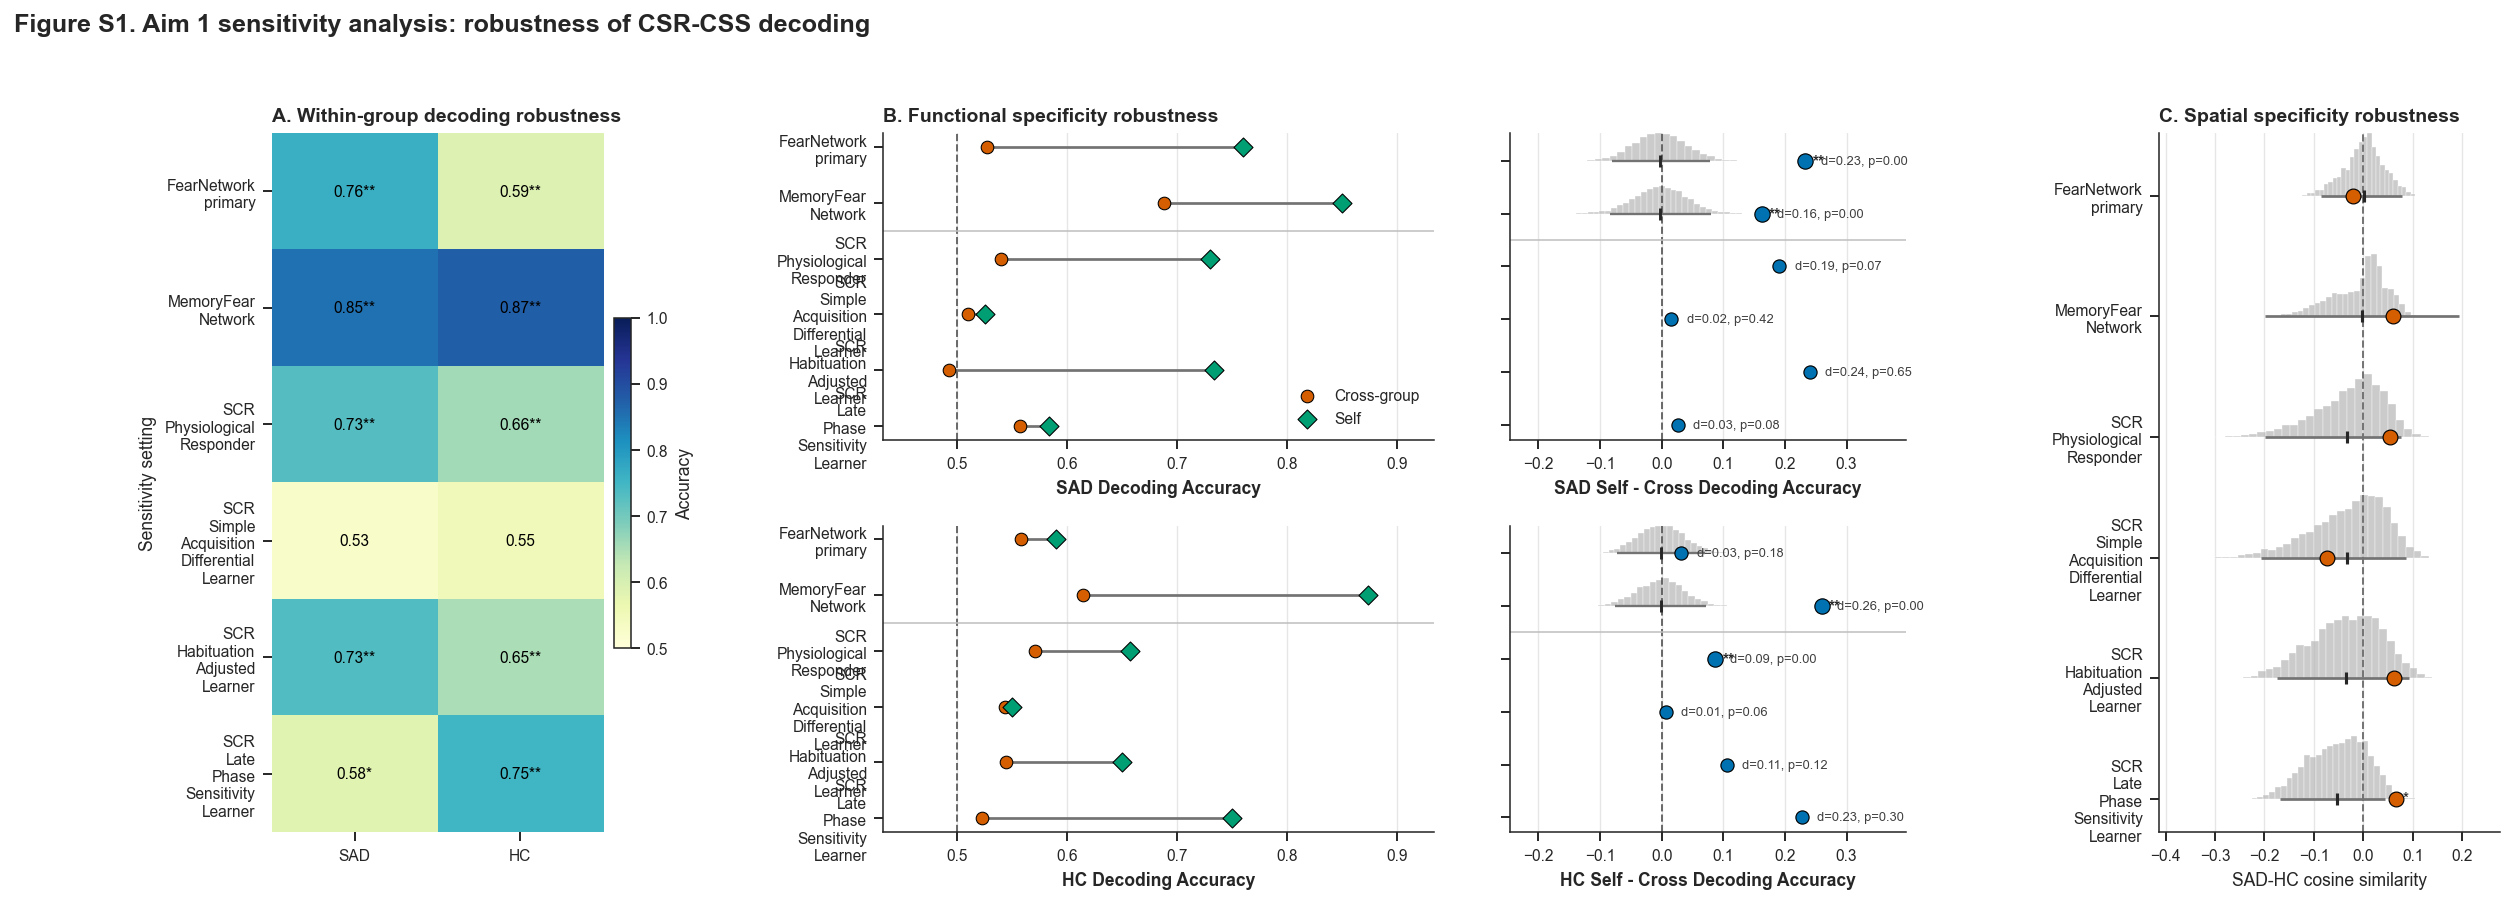

In [10]:
AIM1_SENSITIVITY_INPUTS = {
    'mask_feature': STATS_DIR / 'aim1_mask_feature_sensitivity.csv',
    'scr': STATS_DIR / 'aim1_scr_sensitivity.csv',
    'primary_functional_drop_tests': STATS_DIR / 'aim1_decoding_primary_functional_drop_tests.csv',
    'mask_feature_functional_drop_tests': STATS_DIR / 'aim1_mask_feature_sensitivity_functional_drop_tests.csv',
    'scr_functional_drop_tests': STATS_DIR / 'aim1_scr_sensitivity_functional_drop_tests.csv',
    'primary_functional_drop_nulls': STATS_DIR / 'aim1_decoding_primary_functional_drop_nulls.csv',
    'mask_feature_functional_drop_nulls': STATS_DIR / 'aim1_mask_feature_sensitivity_functional_drop_nulls.csv',
    'scr_functional_drop_nulls': STATS_DIR / 'aim1_scr_sensitivity_functional_drop_nulls.csv',
}
AIM1_SENSITIVITY_FEATURE_ORDER = [
    ('FearNetwork', 'FearNetwork primary'),
    ('MemoryFearNetwork', 'MemoryFearNetwork'),
    ('WholeBrain_Schaefer', 'Schaefer/Tian parcellation'),
    ('Schaefer', 'Schaefer/Tian parcellation'),
    ('WholeBrain', 'Whole brain'),
]
AIM1_SENSITIVITY_SCR_ORDER = SCR_FLAGS
AIM1_SENSITIVITY_TABLE_COLUMNS = [
    'analysis_family', 'sensitivity_set', 'group_or_test', 'target_group', 'feature_space', 'cohort',
    'n_subjects', 'n_trials', 'accuracy', 'accuracy_minus_chance', 'cross_group_accuracy',
    'within_group_accuracy', 'functional_drop', 'functional_drop_ci_low', 'functional_drop_ci_high',
    'cosine_similarity', 'null_mean', 'null_ci_low', 'null_ci_high', 'permutation_p', 'fdr_q', 'robust', 'interpretation',
]
AIM1_SENSITIVITY_FIGURE_TITLE = 'Figure S1. Aim 1 sensitivity analysis: robustness of CSR-CSS decoding'
AIM1_SENSITIVITY_CAPTION = (
    'Figure S1. Sensitivity analysis for Aim 1. Panel A shows robustness of within-group CSR-CSS decoding separately for SAD and HC across alternative feature spaces and SCR-defined responder/learner cohorts. '
    'Cell values represent 2AFC accuracy; stars indicate FDR-corrected significance when q-values are available, otherwise permutation p-values are used and noted as uncorrected sensitivity evidence. '
    'Panel B shows dumbbell plots comparing absolute cross-group and within-group/self-decoding accuracies, with adjacent upper histograms of the aggregate permutation null distribution for the self-minus-cross effect. The dashed accuracy reference marks chance-level 2AFC accuracy = 0.50, and the null-histogram reference marks self-minus-cross = 0. Significance markers refer to the aggregate self-minus-cross permutation test. '
    'Panel C shows spatial specificity by plotting the upper half of each permutation-null histogram with its null 95% interval and null mean, overlaid with the observed SAD-HC classifier/Haufe-map cosine similarity. '
    'SCR-defined cohort analyses are interpreted as sensitivity checks rather than confirmatory primary tests.'
)


def aim1_sensitivity_feature_label(feature_space):
    for candidate, label in AIM1_SENSITIVITY_FEATURE_ORDER:
        if str(feature_space) == candidate:
            return label
    return str(feature_space)


def aim1_sensitivity_numeric(value):
    if value is None:
        return np.nan
    return pd.to_numeric(pd.Series([value]), errors='coerce').iloc[0]


def aim1_sensitivity_p_or_q_stars(p_value=np.nan, q_value=np.nan):
    q_value = aim1_sensitivity_numeric(q_value)
    p_value = aim1_sensitivity_numeric(p_value)
    value = q_value if pd.notna(q_value) else p_value
    if pd.isna(value):
        return ''
    if value < 0.01:
        return '**'
    if value < 0.05:
        return '*'
    return ''


def aim1_sensitivity_trial_count(payload, group_key):
    if not isinstance(payload, dict):
        return np.nan
    subsets = payload.get('data_subsets')
    if not isinstance(subsets, dict) or group_key not in subsets:
        return np.nan
    n_trials = 0
    for phase in ['ext', 'rst']:
        phase_data = subsets[group_key].get(phase, {}) if isinstance(subsets[group_key], dict) else {}
        if isinstance(phase_data, dict) and 'y' in phase_data:
            n_trials += len(phase_data['y'])
    return n_trials if n_trials else np.nan


def aim1_sensitivity_empty_row(**updates):
    row = {col: np.nan for col in AIM1_SENSITIVITY_TABLE_COLUMNS}
    row.update(updates)
    return row


def aim1_sensitivity_read_export(path, label, required_columns=None):
    path = Path(path)
    if not path.exists():
        print(f'Missing optional Aim 1 sensitivity export: {path}')
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f'Loaded {label}: {df.shape[0]} rows x {df.shape[1]} columns')
    if required_columns:
        missing = [col for col in required_columns if col not in df.columns]
        if missing:
            raise ValueError(f'{label} is missing required columns: {missing}. Expected columns include {required_columns}.')
    return df


def aim1_sensitivity_cosine_from_vectors(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0 or not np.isfinite(denom):
        return np.nan
    return float(np.dot(a, b) / denom)


def aim1_sensitivity_spatial_null_distribution_from_weights(feature_space):
    checkpoint_dir = feature_space_dir(feature_space) / 'checkpoints'
    sad_path = checkpoint_dir / 'perm_results_SAD_fear_network_2way.joblib'
    hc_path = checkpoint_dir / 'perm_results_HC_fear_network_2way.joblib'
    sad_payload = load_joblib(sad_path, purpose=f'Aim 1 {feature_space} SAD spatial null')
    hc_payload = load_joblib(hc_path, purpose=f'Aim 1 {feature_space} HC spatial null')
    if not isinstance(sad_payload, dict) or not isinstance(hc_payload, dict):
        return np.array([], dtype=float)
    sad_null = sad_payload.get('null_weights')
    hc_null = hc_payload.get('null_weights')
    if sad_null is None or hc_null is None:
        return np.array([], dtype=float)
    sad_null = np.asarray(sad_null, dtype=float)
    hc_null = np.asarray(hc_null, dtype=float)
    n_draws = min(len(sad_null), len(hc_null))
    if n_draws == 0:
        return np.array([], dtype=float)
    sims = np.array([aim1_sensitivity_cosine_from_vectors(sad_null[i], hc_null[i]) for i in range(n_draws)])
    sims = sims[np.isfinite(sims)]
    return sims


def aim1_sensitivity_spatial_null_from_weights(feature_space):
    sims = aim1_sensitivity_spatial_null_distribution_from_weights(feature_space)
    if len(sims) == 0:
        return np.nan, np.nan
    low, high = np.percentile(sims, [2.5, 97.5])
    return float(low), float(high)


def aim1_sensitivity_result_spatial_null_distribution(result):
    if not isinstance(result, dict):
        return np.array([], dtype=float)
    for null_key in ['perm_sim', 'perm_dist_sim', 'spatial_perm_dist', 'perm_dist_spatial']:
        null_values = result.get(null_key)
        if null_values is None:
            continue
        null_values = pd.to_numeric(pd.Series(np.asarray(null_values).ravel()), errors='coerce').dropna().to_numpy()
        null_values = null_values[np.isfinite(null_values)]
        if len(null_values):
            return null_values
    return np.array([], dtype=float)


def aim1_sensitivity_null_interval(result, feature_space=None):
    if feature_space is not None:
        low, high = aim1_sensitivity_spatial_null_from_weights(feature_space)
        if pd.notna(low) and pd.notna(high):
            return low, high
    if not isinstance(result, dict):
        return np.nan, np.nan
    null_values = aim1_sensitivity_result_spatial_null_distribution(result)
    if len(null_values):
        low, high = np.percentile(null_values, [2.5, 97.5])
        return float(low), float(high)
    return np.nan, np.nan


def aim1_sensitivity_checkpoint_metadata(feature_space):
    result, path, payload = load_aim1_results(feature_space)
    if not isinstance(result, dict):
        return {}, None, None
    return result, path, payload


def aim1_sensitivity_feature_n(feature_space, group):
    _, _, payload = aim1_sensitivity_checkpoint_metadata(feature_space)
    group_key = f'{group}_Placebo'
    return aim1_unique_subject_count(payload, group_key), aim1_sensitivity_trial_count(payload, group_key)



def aim1_sensitivity_exported_spatial_null(feature_space, source_row=None):
    for col in ['null_mean', 'null_ci_low', 'null_ci_high']:
        if source_row is not None and col in source_row.index and pd.notna(source_row.get(col)):
            break
    if source_row is not None and 'null_ci_low' in source_row.index and 'null_ci_high' in source_row.index:
        low = aim1_sensitivity_numeric(source_row.get('null_ci_low'))
        high = aim1_sensitivity_numeric(source_row.get('null_ci_high'))
        mean = aim1_sensitivity_numeric(source_row.get('null_mean')) if 'null_mean' in source_row.index else np.nan
        if pd.notna(low) and pd.notna(high):
            return mean, low, high
    primary = globals().get('aim1_primary_df', pd.DataFrame())
    if isinstance(primary, pd.DataFrame) and not primary.empty:
        primary_labels = primary.get('test', pd.Series(index=primary.index, dtype=object)).astype(str)
        primary_feature = primary.get('feature_space', pd.Series(index=primary.index, dtype=object)).astype(str)
        match = primary[
            primary_feature.eq(str(feature_space))
            & primary_labels.str.contains('Haufe map cosine similarity|cosine similarity', case=False, regex=True, na=False)
        ].copy()
        if not match.empty and {'null_ci_low', 'null_ci_high'}.issubset(match.columns):
            row = match.iloc[0]
            low = aim1_sensitivity_numeric(row.get('null_ci_low'))
            high = aim1_sensitivity_numeric(row.get('null_ci_high'))
            mean = aim1_sensitivity_numeric(row.get('null_mean')) if 'null_mean' in row.index else np.nan
            if pd.notna(low) and pd.notna(high):
                return mean, low, high
    result, _, _ = aim1_sensitivity_checkpoint_metadata(feature_space)
    low, high = aim1_sensitivity_null_interval(result, feature_space)
    mean = np.nan if pd.isna(low) or pd.isna(high) else (low + high) / 2
    return mean, low, high


def aim1_sensitivity_collect_mask_feature_rows(mask_df):
    rows = []
    if mask_df is None or mask_df.empty:
        return pd.DataFrame(columns=AIM1_SENSITIVITY_TABLE_COLUMNS)
    expected = ['feature_space', 'test', 'estimate', 'p_value', 'status']
    missing = [col for col in expected if col not in mask_df.columns]
    if missing:
        raise ValueError(f'Aim 1 mask/feature sensitivity export is missing required current-project columns: {missing}. Expected columns include {expected}.')
    work = mask_df[mask_df['status'].astype(str).str.lower().eq('ok')].copy()
    for feature_space, feature_df in work.groupby('feature_space', dropna=True):
        feature_space = str(feature_space)
        sensitivity_set = aim1_sensitivity_feature_label(feature_space)
        labels = feature_df['test'].astype(str)
        for group in ['SAD', 'HC']:
            pattern = f'{group}-Placebo self-decoding'
            match = feature_df[labels.str.contains(pattern, case=False, regex=False, na=False)]
            if match.empty:
                continue
            source = match.iloc[0]
            accuracy = aim1_sensitivity_numeric(source.get('estimate'))
            n_subjects, n_trials = aim1_sensitivity_feature_n(feature_space, group)
            rows.append(aim1_sensitivity_empty_row(
                analysis_family='within_group_decoding', sensitivity_set=sensitivity_set, group_or_test=group,
                feature_space=feature_space, cohort='full_placebo', n_subjects=n_subjects, n_trials=n_trials,
                accuracy=accuracy, accuracy_minus_chance=accuracy - AIM1_CHANCE_LEVEL if pd.notna(accuracy) else np.nan,
                permutation_p=aim1_sensitivity_numeric(source.get('p_value')), fdr_q=np.nan,
            ))
        sad_self = feature_df[labels.str.contains('SAD-Placebo self-decoding', case=False, regex=False, na=False)]
        hc_self = feature_df[labels.str.contains('HC-Placebo self-decoding', case=False, regex=False, na=False)]
        sad_to_hc = feature_df[labels.str.contains('SAD-Placebo model tested on HC-Placebo', case=False, regex=False, na=False)]
        hc_to_sad = feature_df[labels.str.contains('HC-Placebo model tested on SAD-Placebo', case=False, regex=False, na=False)]
        if not sad_self.empty and not hc_to_sad.empty:
            within_accuracy = aim1_sensitivity_numeric(sad_self.iloc[0].get('estimate'))
            cross_accuracy = aim1_sensitivity_numeric(hc_to_sad.iloc[0].get('estimate'))
            n_subjects, n_trials = aim1_sensitivity_feature_n(feature_space, 'SAD')
            rows.append(aim1_sensitivity_empty_row(
                analysis_family='functional_specificity', sensitivity_set=sensitivity_set, group_or_test='SAD',
                feature_space=feature_space, cohort='full_placebo', n_subjects=n_subjects, n_trials=n_trials,
                cross_group_accuracy=cross_accuracy, within_group_accuracy=within_accuracy,
                functional_drop=within_accuracy - cross_accuracy if pd.notna(within_accuracy) and pd.notna(cross_accuracy) else np.nan,
                permutation_p=aim1_sensitivity_numeric(hc_to_sad.iloc[0].get('p_value')), fdr_q=np.nan,
            ))
        if not hc_self.empty and not sad_to_hc.empty:
            within_accuracy = aim1_sensitivity_numeric(hc_self.iloc[0].get('estimate'))
            cross_accuracy = aim1_sensitivity_numeric(sad_to_hc.iloc[0].get('estimate'))
            n_subjects, n_trials = aim1_sensitivity_feature_n(feature_space, 'HC')
            rows.append(aim1_sensitivity_empty_row(
                analysis_family='functional_specificity', sensitivity_set=sensitivity_set, group_or_test='HC',
                feature_space=feature_space, cohort='full_placebo', n_subjects=n_subjects, n_trials=n_trials,
                cross_group_accuracy=cross_accuracy, within_group_accuracy=within_accuracy,
                functional_drop=within_accuracy - cross_accuracy if pd.notna(within_accuracy) and pd.notna(cross_accuracy) else np.nan,
                permutation_p=aim1_sensitivity_numeric(sad_to_hc.iloc[0].get('p_value')), fdr_q=np.nan,
            ))
        spatial = feature_df[labels.str.contains('cosine similarity', case=False, na=False)]
        if not spatial.empty:
            result, _, payload = aim1_sensitivity_checkpoint_metadata(feature_space)
            sad_n, sad_trials = aim1_unique_subject_count(payload, 'SAD_Placebo'), aim1_sensitivity_trial_count(payload, 'SAD_Placebo')
            hc_n, hc_trials = aim1_unique_subject_count(payload, 'HC_Placebo'), aim1_sensitivity_trial_count(payload, 'HC_Placebo')
            source = spatial.iloc[0]
            null_mean, null_low, null_high = aim1_sensitivity_exported_spatial_null(feature_space, source)
            rows.append(aim1_sensitivity_empty_row(
                analysis_family='spatial_specificity', sensitivity_set=sensitivity_set, group_or_test='SAD_vs_HC_cosine',
                feature_space=feature_space, cohort='full_placebo', n_subjects=np.nansum([sad_n, hc_n]), n_trials=np.nansum([sad_trials, hc_trials]),
                cosine_similarity=aim1_sensitivity_numeric(source.get('estimate')), null_mean=null_mean, null_ci_low=null_low, null_ci_high=null_high,
                permutation_p=aim1_sensitivity_numeric(source.get('p_value')), fdr_q=np.nan,
            ))
    return pd.DataFrame(rows, columns=AIM1_SENSITIVITY_TABLE_COLUMNS)


def aim1_sensitivity_collect_feature_rows_from_checkpoints():
    rows = []
    feature_seen = set()
    for feature_space, feature_label in AIM1_SENSITIVITY_FEATURE_ORDER:
        if feature_space in feature_seen:
            continue
        feature_seen.add(feature_space)
        result, _, payload = aim1_sensitivity_checkpoint_metadata(feature_space)
        if not isinstance(result, dict):
            continue
        sad_acc = aim1_sensitivity_numeric(result.get('acc_sad_cv'))
        hc_acc = aim1_sensitivity_numeric(result.get('acc_hc_cv'))
        sad_p = aim1_sensitivity_numeric(result.get('p_sad'))
        hc_p = aim1_sensitivity_numeric(result.get('p_hc'))
        sad_n = aim1_unique_subject_count(payload, 'SAD_Placebo')
        hc_n = aim1_unique_subject_count(payload, 'HC_Placebo')
        sad_trials = aim1_sensitivity_trial_count(payload, 'SAD_Placebo')
        hc_trials = aim1_sensitivity_trial_count(payload, 'HC_Placebo')
        rows.append(aim1_sensitivity_empty_row(
            analysis_family='within_group_decoding', sensitivity_set=feature_label, group_or_test='SAD',
            feature_space=feature_space, cohort='full_placebo', n_subjects=sad_n, n_trials=sad_trials,
            accuracy=sad_acc, accuracy_minus_chance=sad_acc - AIM1_CHANCE_LEVEL if pd.notna(sad_acc) else np.nan,
            permutation_p=sad_p, fdr_q=np.nan,
        ))
        rows.append(aim1_sensitivity_empty_row(
            analysis_family='within_group_decoding', sensitivity_set=feature_label, group_or_test='HC',
            feature_space=feature_space, cohort='full_placebo', n_subjects=hc_n, n_trials=hc_trials,
            accuracy=hc_acc, accuracy_minus_chance=hc_acc - AIM1_CHANCE_LEVEL if pd.notna(hc_acc) else np.nan,
            permutation_p=hc_p, fdr_q=np.nan,
        ))
        func = result.get('func_matrix')
        if func is not None:
            func = np.asarray(func, dtype=float)
            if func.shape == (2, 2):
                rows.append(aim1_sensitivity_empty_row(
                    analysis_family='functional_specificity', sensitivity_set=feature_label, group_or_test='SAD',
                    feature_space=feature_space, cohort='full_placebo', n_subjects=sad_n, n_trials=sad_trials,
                    cross_group_accuracy=float(func[1, 0]), within_group_accuracy=sad_acc,
                    functional_drop=sad_acc - float(func[1, 0]) if pd.notna(sad_acc) and pd.notna(func[1, 0]) else np.nan,
                    permutation_p=np.nan, fdr_q=np.nan,
                ))
                rows.append(aim1_sensitivity_empty_row(
                    analysis_family='functional_specificity', sensitivity_set=feature_label, group_or_test='HC',
                    feature_space=feature_space, cohort='full_placebo', n_subjects=hc_n, n_trials=hc_trials,
                    cross_group_accuracy=float(func[0, 1]), within_group_accuracy=hc_acc,
                    functional_drop=hc_acc - float(func[0, 1]) if pd.notna(hc_acc) and pd.notna(func[0, 1]) else np.nan,
                    permutation_p=np.nan, fdr_q=np.nan,
                ))
        sim = aim1_sensitivity_numeric(result.get('sim_spatial'))
        p_sim = aim1_sensitivity_numeric(result.get('p_sim'))
        null_mean, null_low, null_high = aim1_sensitivity_exported_spatial_null(feature_space)
        rows.append(aim1_sensitivity_empty_row(
            analysis_family='spatial_specificity', sensitivity_set=feature_label, group_or_test='SAD_vs_HC_cosine',
            feature_space=feature_space, cohort='full_placebo', n_subjects=np.nansum([sad_n, hc_n]), n_trials=np.nansum([sad_trials, hc_trials]),
            cosine_similarity=sim, null_mean=null_mean, null_ci_low=null_low, null_ci_high=null_high, permutation_p=p_sim, fdr_q=np.nan,
        ))
    return pd.DataFrame(rows, columns=AIM1_SENSITIVITY_TABLE_COLUMNS)


def aim1_sensitivity_collect_scr_rows(scr_df):
    if scr_df is None or scr_df.empty:
        return pd.DataFrame(columns=AIM1_SENSITIVITY_TABLE_COLUMNS)
    expected = ['test', 'estimate', 'p_value', 'include_subjects_flag', 'feature_space', 'n_sad_subjects', 'n_hc_subjects', 'n_sad_trials', 'n_hc_trials']
    missing = [col for col in expected if col not in scr_df.columns]
    if missing:
        raise ValueError(f'Aim 1 SCR sensitivity export is missing required current-project columns: {missing}. Expected columns include {expected}.')
    work = scr_df.copy()
    rows = []
    labels = work['test'].astype(str)
    self_rows = work[labels.str.contains('self-decoding', case=False, na=False) & ~labels.str.contains('model tested', case=False, na=False)].copy()
    for _, row in self_rows.iterrows():
        label = str(row.get('test', ''))
        group = 'SAD' if 'SAD' in label.upper() else 'HC' if 'HC' in label.upper() else np.nan
        cohort = str(row.get('include_subjects_flag'))
        accuracy = aim1_sensitivity_numeric(row.get('estimate'))
        n_subjects = aim1_sensitivity_numeric(row.get('n_sad_subjects' if group == 'SAD' else 'n_hc_subjects'))
        n_trials = aim1_sensitivity_numeric(row.get('n_sad_trials' if group == 'SAD' else 'n_hc_trials'))
        rows.append(aim1_sensitivity_empty_row(
            analysis_family='within_group_decoding', sensitivity_set=cohort, group_or_test=group,
            feature_space=str(row.get('feature_space', 'FearNetwork')), cohort=cohort, n_subjects=n_subjects, n_trials=n_trials,
            accuracy=accuracy, accuracy_minus_chance=accuracy - AIM1_CHANCE_LEVEL if pd.notna(accuracy) else np.nan,
            permutation_p=aim1_sensitivity_numeric(row.get('p_value')), fdr_q=np.nan,
        ))
    for cohort, cohort_df in work.groupby('include_subjects_flag', dropna=True):
        cohort = str(cohort)
        cohort_labels = cohort_df['test'].astype(str)
        feature_space = str(cohort_df['feature_space'].dropna().iloc[0]) if cohort_df['feature_space'].notna().any() else 'FearNetwork'
        n_sad = aim1_sensitivity_numeric(cohort_df['n_sad_subjects'].dropna().iloc[0]) if cohort_df['n_sad_subjects'].notna().any() else np.nan
        n_hc = aim1_sensitivity_numeric(cohort_df['n_hc_subjects'].dropna().iloc[0]) if cohort_df['n_hc_subjects'].notna().any() else np.nan
        n_sad_trials = aim1_sensitivity_numeric(cohort_df['n_sad_trials'].dropna().iloc[0]) if cohort_df['n_sad_trials'].notna().any() else np.nan
        n_hc_trials = aim1_sensitivity_numeric(cohort_df['n_hc_trials'].dropna().iloc[0]) if cohort_df['n_hc_trials'].notna().any() else np.nan
        sad_self = cohort_df[cohort_labels.str.contains('SAD self-decoding', case=False, na=False)]
        hc_self = cohort_df[cohort_labels.str.contains('HC self-decoding', case=False, na=False)]
        sad_to_hc = cohort_df[cohort_labels.str.contains('SAD model tested on HC', case=False, na=False)]
        hc_to_sad = cohort_df[cohort_labels.str.contains('HC model tested on SAD', case=False, na=False)]
        if not sad_self.empty and not hc_to_sad.empty:
            within_accuracy = aim1_sensitivity_numeric(sad_self.iloc[0].get('estimate'))
            cross_accuracy = aim1_sensitivity_numeric(hc_to_sad.iloc[0].get('estimate'))
            rows.append(aim1_sensitivity_empty_row(
                analysis_family='functional_specificity', sensitivity_set=cohort, group_or_test='SAD',
                feature_space=feature_space, cohort=cohort, n_subjects=n_sad, n_trials=n_sad_trials,
                cross_group_accuracy=cross_accuracy, within_group_accuracy=within_accuracy,
                functional_drop=within_accuracy - cross_accuracy if pd.notna(within_accuracy) and pd.notna(cross_accuracy) else np.nan,
                permutation_p=aim1_sensitivity_numeric(hc_to_sad.iloc[0].get('p_value')), fdr_q=np.nan,
            ))
        if not hc_self.empty and not sad_to_hc.empty:
            within_accuracy = aim1_sensitivity_numeric(hc_self.iloc[0].get('estimate'))
            cross_accuracy = aim1_sensitivity_numeric(sad_to_hc.iloc[0].get('estimate'))
            rows.append(aim1_sensitivity_empty_row(
                analysis_family='functional_specificity', sensitivity_set=cohort, group_or_test='HC',
                feature_space=feature_space, cohort=cohort, n_subjects=n_hc, n_trials=n_hc_trials,
                cross_group_accuracy=cross_accuracy, within_group_accuracy=within_accuracy,
                functional_drop=within_accuracy - cross_accuracy if pd.notna(within_accuracy) and pd.notna(cross_accuracy) else np.nan,
                permutation_p=aim1_sensitivity_numeric(sad_to_hc.iloc[0].get('p_value')), fdr_q=np.nan,
            ))
        spatial_rows = cohort_df[cohort_labels.str.contains('cosine similarity', case=False, na=False)].copy()
        if not spatial_rows.empty:
            spatial_row = spatial_rows.iloc[0]
            rows.append(aim1_sensitivity_empty_row(
                analysis_family='spatial_specificity', sensitivity_set=cohort, group_or_test='SAD_vs_HC_cosine',
                feature_space=feature_space, cohort=cohort, n_subjects=np.nansum([n_sad, n_hc]), n_trials=np.nansum([n_sad_trials, n_hc_trials]),
                cosine_similarity=aim1_sensitivity_numeric(spatial_row.get('estimate')),
                null_mean=aim1_sensitivity_numeric(spatial_row.get('null_mean')),
                null_ci_low=aim1_sensitivity_numeric(spatial_row.get('null_ci_low')),
                null_ci_high=aim1_sensitivity_numeric(spatial_row.get('null_ci_high')),
                permutation_p=aim1_sensitivity_numeric(spatial_row.get('p_value')), fdr_q=np.nan,
            ))
    return pd.DataFrame(rows, columns=AIM1_SENSITIVITY_TABLE_COLUMNS)



def aim1_sensitivity_functional_drop_tests():
    paths = [
        AIM1_SENSITIVITY_INPUTS.get('primary_functional_drop_tests'),
        AIM1_SENSITIVITY_INPUTS.get('mask_feature_functional_drop_tests'),
        AIM1_SENSITIVITY_INPUTS.get('scr_functional_drop_tests'),
    ]
    frames = []
    required = ['sensitivity_set', 'target_group', 'within_group_accuracy', 'cross_group_accuracy', 'functional_drop']
    for path in paths:
        if path is None or not Path(path).exists():
            continue
        frame = pd.read_csv(path)
        missing = [col for col in required if col not in frame.columns]
        if missing:
            print(f'Skipped malformed Aim 1 functional-drop test export {path}: missing {missing}')
            continue
        frame = frame.copy()
        frame['drop_test_source'] = Path(path).name
        frames.append(frame)
    if not frames:
        return pd.DataFrame()
    tests = pd.concat(frames, ignore_index=True, sort=False)
    rename = {
        'drop_ci_low': 'functional_drop_ci_low',
        'drop_ci_high': 'functional_drop_ci_high',
        'functional_drop_p': 'permutation_p',
        'functional_drop_q': 'fdr_q',
    }
    tests = tests.rename(columns={key: value for key, value in rename.items() if key in tests.columns})
    return tests


def aim1_sensitivity_merge_functional_drop_tests(table):
    if table is None or table.empty:
        return table
    out = table.copy()
    tests = aim1_sensitivity_functional_drop_tests()
    if tests.empty:
        return out
    functional_mask = out['analysis_family'].eq('functional_specificity')
    for idx, row in out[functional_mask].iterrows():
        matches = tests[
            tests['sensitivity_set'].astype(str).eq(str(row.get('sensitivity_set')))
            & tests['target_group'].astype(str).eq(str(row.get('group_or_test')))
        ].copy()
        if 'feature_space' in tests.columns and pd.notna(row.get('feature_space')):
            feature_matches = matches[matches['feature_space'].astype(str).eq(str(row.get('feature_space')))]
            if not feature_matches.empty:
                matches = feature_matches
        if 'cohort' in tests.columns and pd.notna(row.get('cohort')):
            cohort_matches = matches[matches['cohort'].astype(str).eq(str(row.get('cohort')))]
            if not cohort_matches.empty:
                matches = cohort_matches
        if matches.empty:
            continue
        match = matches.iloc[0]
        # Keep Panel B absolute accuracy dumbbells anchored to the aggregate decoding
        # estimates; only the aggregate drop statistic, p/q, and interval come from this test.
        for col in ['functional_drop', 'functional_drop_ci_low', 'functional_drop_ci_high', 'permutation_p', 'fdr_q']:
            if col in match.index and pd.notna(match[col]):
                out.loc[idx, col] = match[col]
    return out

def aim1_sensitivity_apply_robust_labels(table):
    if table is None or table.empty:
        return pd.DataFrame(columns=AIM1_SENSITIVITY_TABLE_COLUMNS)
    out = table.copy()
    primary_func = out[(out['analysis_family'] == 'functional_specificity') & (out['sensitivity_set'] == 'FearNetwork primary')]
    primary_func_direction = True
    if not primary_func.empty:
        primary_func_direction = bool((pd.to_numeric(primary_func['functional_drop'], errors='coerce') > 0).all())
    primary_spatial = out[(out['analysis_family'] == 'spatial_specificity') & (out['sensitivity_set'] == 'FearNetwork primary')]
    primary_spatial_supports_specificity = True
    if not primary_spatial.empty:
        p_primary = aim1_sensitivity_numeric(primary_spatial['permutation_p'].iloc[0])
        sim_primary = aim1_sensitivity_numeric(primary_spatial['cosine_similarity'].iloc[0])
        primary_spatial_supports_specificity = (pd.notna(p_primary) and p_primary >= 0.05) or (pd.isna(p_primary) and pd.notna(sim_primary) and abs(sim_primary) <= 0.10)
    robust_values = []
    interpretations = []
    for _, row in out.iterrows():
        family = row['analysis_family']
        if family == 'within_group_decoding':
            acc = aim1_sensitivity_numeric(row['accuracy'])
            q_value = aim1_sensitivity_numeric(row['fdr_q'])
            p_value = aim1_sensitivity_numeric(row['permutation_p'])
            if pd.notna(acc) and acc > AIM1_CHANCE_LEVEL and pd.notna(q_value) and q_value < 0.05:
                robust_values.append('Yes')
                interpretations.append('Above chance after FDR correction.')
            elif pd.notna(acc) and acc > AIM1_CHANCE_LEVEL and pd.isna(q_value) and pd.notna(p_value) and p_value < 0.05:
                robust_values.append('Yes')
                interpretations.append('Above chance using permutation p because FDR q is unavailable; interpret as uncorrected sensitivity evidence.')
            elif pd.notna(acc) and acc > AIM1_CHANCE_LEVEL:
                robust_values.append('Directionally consistent')
                interpretations.append('Accuracy is above chance, but corrected or nominal significance is not available.')
            else:
                robust_values.append('No')
                interpretations.append('Accuracy is not above chance or the estimate is unavailable.')
        elif family == 'functional_specificity':
            drop = aim1_sensitivity_numeric(row['functional_drop'])
            within_accuracy = aim1_sensitivity_numeric(row['within_group_accuracy'])
            cross_accuracy = aim1_sensitivity_numeric(row['cross_group_accuracy'])
            ci_low = aim1_sensitivity_numeric(row.get('functional_drop_ci_low'))
            q_value = aim1_sensitivity_numeric(row['fdr_q'])
            p_value = aim1_sensitivity_numeric(row['permutation_p'])
            has_pair_interval = pd.notna(ci_low)
            supported = (has_pair_interval and pd.notna(q_value) and q_value < 0.05) or (has_pair_interval and pd.isna(q_value) and pd.notna(p_value) and p_value < 0.05) or (has_pair_interval and ci_low > 0)
            if pd.isna(within_accuracy) or pd.isna(cross_accuracy):
                robust_values.append('Not estimable')
                interpretations.append('Within-group or cross-group accuracy is unavailable for this sensitivity setting.')
            elif pd.notna(drop) and drop > 0 and primary_func_direction and supported:
                robust_values.append('Yes')
                interpretations.append('Within-group decoding exceeds cross-group decoding and the paired comparison supports the primary functional-specificity direction.')
            elif pd.notna(drop) and drop > 0:
                robust_values.append('Directionally consistent')
                interpretations.append('Within-group decoding exceeds cross-group decoding, but the interval overlaps zero or paired-test support is unavailable/not significant.')
            else:
                robust_values.append('No')
                interpretations.append('Within-group decoding does not exceed cross-group decoding.')
        elif family == 'spatial_specificity':
            p_value = aim1_sensitivity_numeric(row['permutation_p'])
            sim = aim1_sensitivity_numeric(row['cosine_similarity'])
            if pd.notna(p_value) and p_value >= 0.05 and primary_spatial_supports_specificity:
                robust_values.append('Yes')
                interpretations.append('Cosine similarity is low or nonsignificant, supporting spatial specificity in the same sense as the primary analysis.')
            elif pd.notna(sim) and abs(sim) <= 0.10:
                robust_values.append('Directionally consistent')
                interpretations.append('Observed cosine similarity is small, but permutation support is unavailable or not aligned with the primary criterion.')
            else:
                robust_values.append('No')
                interpretations.append('Spatial-similarity evidence does not support the primary spatial-specificity interpretation.')
        else:
            robust_values.append('No')
            interpretations.append('Unrecognized analysis family.')
    out['robust'] = robust_values
    out['interpretation'] = interpretations
    return out[AIM1_SENSITIVITY_TABLE_COLUMNS]


def aim1_sensitivity_build_table():
    mask_df = aim1_sensitivity_read_export(AIM1_SENSITIVITY_INPUTS['mask_feature'], 'aim1_mask_feature_sensitivity.csv', required_columns=['feature_space', 'test', 'estimate', 'p_value', 'status'])
    scr_export = aim1_sensitivity_read_export(AIM1_SENSITIVITY_INPUTS['scr'], 'aim1_scr_sensitivity.csv', required_columns=['test', 'estimate', 'p_value', 'include_subjects_flag', 'feature_space'])
    feature_rows = aim1_sensitivity_collect_mask_feature_rows(mask_df)
    if feature_rows.empty:
        feature_rows = aim1_sensitivity_collect_feature_rows_from_checkpoints()
    scr_rows = aim1_sensitivity_collect_scr_rows(scr_export)
    table = pd.concat([feature_rows, scr_rows], ignore_index=True)
    if table.empty:
        return table
    table = aim1_sensitivity_merge_functional_drop_tests(table)
    table['target_group'] = np.where(table['analysis_family'].eq('functional_specificity'), table['group_or_test'], np.nan)
    for col in ['n_subjects', 'n_trials']:
        table[col] = pd.to_numeric(table[col], errors='coerce').round(0).astype('Int64')
    numeric_cols = ['accuracy', 'accuracy_minus_chance', 'cross_group_accuracy', 'within_group_accuracy', 'functional_drop', 'functional_drop_ci_low', 'functional_drop_ci_high', 'cosine_similarity', 'null_mean', 'null_ci_low', 'null_ci_high', 'permutation_p', 'fdr_q']
    for col in numeric_cols:
        table[col] = pd.to_numeric(table[col], errors='coerce')
    functional_mask = table['analysis_family'].eq('functional_specificity')
    missing_drop = functional_mask & table['functional_drop'].isna()
    table.loc[missing_drop, 'functional_drop'] = table.loc[missing_drop, 'within_group_accuracy'] - table.loc[missing_drop, 'cross_group_accuracy']
    table = aim1_sensitivity_apply_robust_labels(table)
    feature_labels = [label for _, label in AIM1_SENSITIVITY_FEATURE_ORDER]
    order = feature_labels + AIM1_SENSITIVITY_SCR_ORDER
    family_order = {'within_group_decoding': 0, 'functional_specificity': 1, 'spatial_specificity': 2}
    group_order = {'SAD': 0, 'HC': 1, 'SAD_vs_HC_cosine': 2}
    table['_family_order'] = table['analysis_family'].map(family_order).fillna(99)
    table['_set_order'] = table['sensitivity_set'].map({name: i for i, name in enumerate(order)}).fillna(99)
    table['_group_order'] = table['group_or_test'].map(group_order).fillna(99)
    table = table.sort_values(['_family_order', '_set_order', '_group_order', 'sensitivity_set']).drop(columns=['_family_order', '_set_order', '_group_order'])
    return table[AIM1_SENSITIVITY_TABLE_COLUMNS]


def aim1_sensitivity_save_table(table):
    if table is None or table.empty:
        print('No Aim 1 sensitivity rows were available; Figure S1/Table S1 were not generated.')
        return {}
    csv_path = STATS_DIR / 'Table_S1_Aim1_sensitivity_statistics.csv'
    xlsx_path = STATS_DIR / 'Table_S1_Aim1_sensitivity_statistics.xlsx'
    table.to_csv(csv_path, index=False)
    paths = {'csv': csv_path}
    try:
        table.to_excel(xlsx_path, index=False)
        paths['xlsx'] = xlsx_path
    except (ImportError, ValueError, ModuleNotFoundError):
        print('openpyxl is not available; skipped Table_S1_Aim1_sensitivity_statistics.xlsx.')
    caption_path = FIG_DIR / 'Figure_S1_Aim1_sensitivity_caption.txt'
    caption_path.write_text(AIM1_SENSITIVITY_CAPTION + '\n')
    paths['caption'] = caption_path
    for label, out_path in paths.items():
        print(f'Saved {label}: {out_path}')
    return paths


def aim1_sensitivity_annotation(value, p_value=np.nan, q_value=np.nan):
    if pd.isna(value):
        return ''
    return f'{value:.2f}{aim1_sensitivity_p_or_q_stars(p_value, q_value)}'


def aim1_sensitivity_wrapped_label(label):
    label = str(label)
    replacements = {
        'FearNetwork primary': 'FearNetwork\nprimary',
        'MemoryFearNetwork': 'MemoryFear\nNetwork',
        'Schaefer/Tian parcellation': 'Schaefer/Tian\nparcellation',
        'Whole brain': 'Whole\nbrain',
    }
    if label in replacements:
        return replacements[label]
    if label.startswith('SCR_'):
        return label.replace('_', '\n')
    return label


def aim1_sensitivity_available_order(rows):
    values = rows.dropna().astype(str).unique().tolist()
    ordered = []
    for _, label in AIM1_SENSITIVITY_FEATURE_ORDER:
        if label in values and label not in ordered:
            ordered.append(label)
    for cohort in AIM1_SENSITIVITY_SCR_ORDER:
        if cohort in values and cohort not in ordered:
            ordered.append(cohort)
    ordered.extend([name for name in values if name not in ordered])
    return ordered


def aim1_sensitivity_panel_a(ax, table, fig):
    within = table[table['analysis_family'].eq('within_group_decoding')].copy()
    panel_order = aim1_sensitivity_available_order(within['sensitivity_set'])
    groups = ['SAD', 'HC']
    heat = np.full((len(panel_order), len(groups)), np.nan, dtype=float)
    annotations = np.full((len(panel_order), len(groups)), '', dtype=object)
    for i, set_name in enumerate(panel_order):
        for j, group in enumerate(groups):
            match = within[within['sensitivity_set'].astype(str).eq(set_name) & within['group_or_test'].astype(str).eq(group)]
            if match.empty:
                continue
            row = match.iloc[0]
            heat[i, j] = row['accuracy']
            annotations[i, j] = aim1_sensitivity_annotation(row['accuracy'], row['permutation_p'], row['fdr_q'])
    im = ax.imshow(heat, aspect='auto', cmap='YlGnBu', vmin=AIM1_CHANCE_LEVEL, vmax=1.0)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, annotations[i, j], ha='center', va='center', fontsize=8, color='black')
    ax.set_xticks(np.arange(len(groups)))
    ax.set_xticklabels(groups)
    ax.set_yticks(np.arange(len(panel_order)))
    ax.set_yticklabels([aim1_sensitivity_wrapped_label(label) for label in panel_order], fontsize=8)
    ax.set_title('A. Within-group decoding robustness', loc='left', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Sensitivity setting')
    for spine in ax.spines.values():
        spine.set_visible(False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label('Accuracy')
    #if within['fdr_q'].notna().any():
    #    note = 'Cell = 2AFC accuracy; stars indicate FDR-corrected significance.'
    #else:
    #    note = 'Cell = 2AFC accuracy; FDR q unavailable, so stars use permutation p.'
    #ax.text(0, -0.13, note, transform=ax.transAxes, ha='left', va='top', fontsize=7.5)
    return panel_order


def aim1_sensitivity_row_group_label(set_name):
    return 'SCR cohort sensitivity' if str(set_name).startswith('SCR_') else 'Feature-space robustness'



def aim1_sensitivity_functional_drop_nulls():
    paths = [
        AIM1_SENSITIVITY_INPUTS.get('primary_functional_drop_nulls'),
        AIM1_SENSITIVITY_INPUTS.get('mask_feature_functional_drop_nulls'),
        AIM1_SENSITIVITY_INPUTS.get('scr_functional_drop_nulls'),
    ]
    frames = []
    required = ['sensitivity_set', 'target_group', 'null_functional_drop']
    for path in paths:
        if path is None or not Path(path).exists():
            continue
        frame = pd.read_csv(path)
        missing = [col for col in required if col not in frame.columns]
        if missing:
            print(f'Skipped malformed Aim 1 functional-drop null export {path}: missing {missing}')
            continue
        frame = frame.copy()
        frame['drop_null_source'] = Path(path).name
        frames.append(frame)
    fallback = aim1_sensitivity_scr_functional_drop_nulls_from_checkpoints(frames)
    if not frames and fallback.empty:
        return pd.DataFrame(columns=required)
    out = pd.concat(frames + ([fallback] if not fallback.empty else []), ignore_index=True, sort=False)
    out['null_functional_drop'] = pd.to_numeric(out['null_functional_drop'], errors='coerce')
    out = out.dropna(subset=['sensitivity_set', 'target_group', 'null_functional_drop'])
    key_cols = [col for col in ['sensitivity_set', 'feature_space', 'cohort', 'target_group', 'permutation_id'] if col in out.columns]
    return out.drop_duplicates(subset=key_cols, keep='first') if key_cols else out


def aim1_sensitivity_finite_vector(values):
    if values is None:
        return np.array([], dtype=float)
    arr = pd.to_numeric(pd.Series(np.asarray(values).ravel()), errors='coerce').dropna().to_numpy(dtype=float)
    return arr[np.isfinite(arr)]


def aim1_sensitivity_safe_checkpoint_label(label):
    cleaned = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(label).strip())
    return cleaned.strip('_')


def aim1_sensitivity_scr_checkpoint_result(set_name):
    base = feature_space_dir('FearNetwork')
    cohort_label = str(set_name).lower()
    if cohort_label.startswith('scr_'):
        cohort_label = cohort_label[4:]
    label = aim1_sensitivity_safe_checkpoint_label(f'aim1_scr_{cohort_label}')
    for candidate in [base / 'checkpoints' / f'cell_06_{label}.joblib', base / 'checkpoints' / f'cell_06_{label}_plot.joblib']:
        payload = load_joblib(candidate, purpose=f'Aim 1 {set_name} functional-drop null fallback')
        if not isinstance(payload, dict):
            continue
        result = payload_value(payload, 'results_11') or payload
        if isinstance(result, dict):
            return result
    return {}


def aim1_sensitivity_scr_functional_drop_nulls_from_checkpoints(existing_frames=None):
    existing = pd.concat(existing_frames, ignore_index=True, sort=False) if existing_frames else pd.DataFrame()
    rows = []
    for set_name in AIM1_SENSITIVITY_SCR_ORDER:
        if not existing.empty:
            existing_match = existing[
                existing.get('sensitivity_set', pd.Series(index=existing.index, dtype=object)).astype(str).eq(str(set_name))
                & existing.get('target_group', pd.Series(index=existing.index, dtype=object)).astype(str).isin(['SAD', 'HC'])
            ]
            if not existing_match.empty:
                continue
        result = aim1_sensitivity_scr_checkpoint_result(set_name)
        specs = {
            'SAD': ('perm_dist_sad', 'perm_dist_hc2sad'),
            'HC': ('perm_dist_hc', 'perm_dist_sad2hc'),
        }
        for target_group, (within_key, cross_key) in specs.items():
            within_null = aim1_sensitivity_finite_vector(result.get(within_key))
            cross_null = aim1_sensitivity_finite_vector(result.get(cross_key))
            n_null = min(len(within_null), len(cross_null))
            if n_null == 0:
                continue
            null_values = within_null[:n_null] - cross_null[:n_null]
            for permutation_id, value in enumerate(null_values):
                if np.isfinite(value):
                    rows.append({
                        'sensitivity_set': set_name,
                        'feature_space': 'FearNetwork',
                        'cohort': set_name,
                        'target_group': target_group,
                        'permutation_id': permutation_id,
                        'null_functional_drop': float(value),
                        'null_source': 'checkpoint_aggregate_self_minus_cross_null',
                        'drop_null_source': 'checkpoint_fallback',
                    })
    return pd.DataFrame(rows)


def aim1_sensitivity_drop_null_values(nulls, set_name, target_group, feature_space=None, cohort=None):
    if nulls is None or nulls.empty:
        return np.array([], dtype=float)
    matches = nulls[
        nulls['sensitivity_set'].astype(str).eq(str(set_name))
        & nulls['target_group'].astype(str).eq(str(target_group))
    ].copy()
    if feature_space is not None and 'feature_space' in matches.columns and pd.notna(feature_space):
        feature_matches = matches[matches['feature_space'].astype(str).eq(str(feature_space))]
        if not feature_matches.empty:
            matches = feature_matches
    if cohort is not None and 'cohort' in matches.columns and pd.notna(cohort):
        cohort_matches = matches[matches['cohort'].astype(str).eq(str(cohort))]
        if not cohort_matches.empty:
            matches = cohort_matches
    return pd.to_numeric(matches['null_functional_drop'], errors='coerce').dropna().to_numpy(dtype=float)


def aim1_sensitivity_draw_upper_histogram(ax, values, y_position, color='0.72', max_height=0.52):
    values = pd.to_numeric(pd.Series(values), errors='coerce').dropna().to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 5:
        return False
    bins = min(28, max(10, int(np.sqrt(len(values)))))
    counts, edges = np.histogram(values, bins=bins)
    if counts.max() <= 0:
        return False
    heights = counts / counts.max() * max_height
    centers = (edges[:-1] + edges[1:]) / 2
    widths = np.diff(edges)
    ax.bar(
        centers,
        heights,
        width=widths,
        bottom=y_position - heights,
        align='center',
        color=color,
        edgecolor='white',
        linewidth=0.25,
        alpha=0.72,
        zorder=1,
    )
    return True


def aim1_sensitivity_panel_b(axes, table):
    axes = np.ravel(np.asarray(axes, dtype=object)).tolist()
    functional = table[table['analysis_family'].eq('functional_specificity')].copy()
    panel_order = aim1_sensitivity_available_order(functional['sensitivity_set'])
    drop_nulls = aim1_sensitivity_functional_drop_nulls()
    self_color = OKABE['green']
    cross_color = OKABE['vermillion']
    drop_color = OKABE['blue']
    if len(axes) < 4:
        for ax in axes:
            ax.text(0.5, 0.5, 'Panel B requires accuracy and drop-null axes for SAD and HC.', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
        return
    ax_sad_acc, ax_sad_drop, ax_hc_acc, ax_hc_drop = axes[:4]
    if not panel_order:
        for ax in axes[:4]:
            ax.text(0.5, 0.5, 'Functional specificity rows unavailable', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
        return
    y_positions = np.arange(len(panel_order), dtype=float)
    accuracy_values = []
    drop_values = []
    any_null_histogram = False
    group_transition = [idx for idx, name in enumerate(panel_order[:-1]) if aim1_sensitivity_row_group_label(name) != aim1_sensitivity_row_group_label(panel_order[idx + 1])]

    for row_index, (target_group, ax_acc, ax_drop) in enumerate([('SAD', ax_sad_acc, ax_sad_drop), ('HC', ax_hc_acc, ax_hc_drop)]):
        group_functional = functional[functional['group_or_test'].astype(str).eq(target_group)].copy()
        ax_acc.axvline(AIM1_CHANCE_LEVEL, color='0.35', linestyle='--', linewidth=1.0, alpha=0.9)
        ax_drop.axvline(0, color='0.35', linestyle='--', linewidth=1.0, alpha=0.9)
        legend_added = False
        for i, set_name in enumerate(panel_order):
            match = group_functional[group_functional['sensitivity_set'].astype(str).eq(str(set_name))]
            if match.empty:
                continue
            row = match.iloc[0]
            within_accuracy = aim1_sensitivity_numeric(row.get('within_group_accuracy'))
            cross_accuracy = aim1_sensitivity_numeric(row.get('cross_group_accuracy'))
            drop = aim1_sensitivity_numeric(row.get('functional_drop'))
            if pd.isna(within_accuracy) or pd.isna(cross_accuracy):
                ax_acc.text(AIM1_CHANCE_LEVEL, i, 'not estimable', ha='center', va='center', fontsize=7, color='0.45')
            else:
                accuracy_values.extend([within_accuracy, cross_accuracy])
                ax_acc.hlines(i, cross_accuracy, within_accuracy, color='0.45', linewidth=1.4, zorder=2)
                ax_acc.scatter(cross_accuracy, i, s=42, color=cross_color, edgecolor='black', linewidth=0.55, zorder=3, label='Cross-group' if not legend_added else None)
                ax_acc.scatter(within_accuracy, i, s=48, marker='D', color=self_color, edgecolor='black', linewidth=0.55, zorder=4, label='Self' if not legend_added else None)
                legend_added = True
            null_values = aim1_sensitivity_drop_null_values(drop_nulls, set_name, target_group, row.get('feature_space'), row.get('cohort'))
            if len(null_values):
                any_null_histogram = aim1_sensitivity_draw_upper_histogram(ax_drop, null_values, i) or any_null_histogram
                low, high = np.nanpercentile(null_values, [2.5, 97.5])
                null_mean = float(np.nanmean(null_values))
                ax_drop.hlines(i, low, high, color='0.45', linewidth=1.2, zorder=2)
                ax_drop.scatter(null_mean, i, s=34, marker='|', color='0.15', linewidth=1.5, zorder=3)
                drop_values.extend(pd.Series(null_values).dropna().tolist())
                drop_values.extend([low, high, null_mean])
            if pd.notna(drop):
                drop_values.append(drop)
                stars = aim1_sensitivity_p_or_q_stars(row.get('permutation_p'), row.get('fdr_q'))
                significant = bool(stars)
                ax_drop.scatter(drop, i, s=62 if significant else 46, color=drop_color, edgecolor='black', linewidth=0.6, zorder=4)
                if stars:
                    ax_drop.text(drop + 0.012, i, stars, va='center', ha='left', fontsize=8, fontweight='bold', color='0.15')
                p_value = aim1_sensitivity_numeric(row.get('permutation_p'))
                q_value = aim1_sensitivity_numeric(row.get('fdr_q'))
                if pd.notna(p_value):
                    label = f'd={drop:.2f}, p={p_value:.2f}'
                else:
                    label = f'd={drop:.2f}'
                ax_drop.text(drop + 0.025, i, label, va='center', ha='left', fontsize=6.6, color='0.25')
        for ax in [ax_acc, ax_drop]:
            ax.set_yticks(y_positions)
            ax.invert_yaxis()
            ax.grid(axis='x', color='0.9', linewidth=0.7)
            for idx in group_transition:
                ax.axhline(idx + 0.5, color='0.75', linewidth=0.8)
        ax_acc.set_yticklabels([aim1_sensitivity_wrapped_label(label) for label in panel_order], fontsize=8)
        ax_drop.set_yticklabels([])
        ax_acc.set_ylabel('')
        ax_acc.set_xlabel(f'{target_group} Decoding Accuracy', loc='center', fontweight='bold')
        ax_drop.set_xlabel(f'{target_group} Self - Cross Decoding Accuracy', loc='center', fontweight='bold')
        if row_index == 0:
            handles, labels = ax_acc.get_legend_handles_labels()
            if handles:
                ax_acc.legend(handles, labels, frameon=False, loc='lower right')

    ax_sad_acc.set_title(
        "B. Functional specificity robustness", 
        loc='left', 
        fontweight='bold'
    )

    if accuracy_values:
        x_min = min(AIM1_CHANCE_LEVEL, np.nanmin(accuracy_values)) - 0.06
        x_max = np.nanmax(accuracy_values) + 0.06
        for ax in [ax_sad_acc, ax_hc_acc]:
            ax.set_xlim(max(0.0, x_min), min(1.05, x_max))
    if drop_values:
        d_min = min(0, np.nanmin(drop_values))
        d_max = max(0, np.nanmax(drop_values))
        span = d_max - d_min if d_max > d_min else 0.05
        left_pad = max(0.04, 0.18 * span)
        right_pad = max(0.10, 0.32 * span)
        for ax in [ax_sad_drop, ax_hc_drop]:
            ax.set_xlim(d_min - left_pad, d_max + right_pad)
    #note = 'Dumbbells show absolute accuracies. Upper gray histograms show aggregate permutation nulls; gray line = null 95% interval; gray tick = null mean; blue dot = observed self-minus-cross.' if any_null_histogram else 'Dumbbells show absolute accuracies. Blue dots show observed self-minus-cross; null histograms were unavailable for these rows.'
    #ax_hc_acc.text(0.0, -0.24, note, transform=ax_hc_acc.transAxes, ha='left', va='top', fontsize=7.0)
    #ax_acc.text(0.0, 1.20, 'B. Functional specificity robustness', transform=ax_acc.transAxes, ha='left', va='bottom', fontweight='bold')

def aim1_sensitivity_safe_label(label):
    cleaned = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(label).strip())
    return cleaned.strip('_')


def aim1_sensitivity_checkpoint_for_spatial_set(set_name, feature_space):
    set_name = str(set_name)
    if set_name in AIM1_SENSITIVITY_SCR_ORDER:
        base = feature_space_dir('FearNetwork')
        cohort_label = set_name.lower()
        if cohort_label.startswith('scr_'):
            cohort_label = cohort_label[4:]
        label = aim1_sensitivity_safe_label(f'aim1_scr_{cohort_label}')
        candidates = [
            base / 'checkpoints' / f'cell_06_{label}.joblib',
            base / 'checkpoints' / f'cell_06_{label}_plot.joblib',
        ]
        for candidate in candidates:
            payload = load_joblib(candidate, purpose=f'Aim 1 {set_name} spatial null histogram')
            if not isinstance(payload, dict):
                continue
            result = payload_value(payload, 'results_11') or payload
            if isinstance(result, dict):
                return result
        return {}
    result, _, _ = aim1_sensitivity_checkpoint_metadata(str(feature_space))
    return result if isinstance(result, dict) else {}


def aim1_sensitivity_spatial_null_distribution(set_name, feature_space):
    result = aim1_sensitivity_checkpoint_for_spatial_set(set_name, feature_space)
    null_values = aim1_sensitivity_result_spatial_null_distribution(result)
    if len(null_values):
        return null_values
    if str(set_name) not in AIM1_SENSITIVITY_SCR_ORDER:
        return aim1_sensitivity_spatial_null_distribution_from_weights(str(feature_space))
    return np.array([], dtype=float)


def aim1_sensitivity_draw_null_histogram(ax, null_values, y_position, color='0.72'):
    null_values = pd.to_numeric(pd.Series(null_values), errors='coerce').dropna().to_numpy(dtype=float)
    null_values = null_values[np.isfinite(null_values)]
    if len(null_values) < 5:
        return False
    bins = min(28, max(10, int(np.sqrt(len(null_values)))))
    counts, edges = np.histogram(null_values, bins=bins)
    if counts.max() <= 0:
        return False
    heights = counts / counts.max() * 0.52
    centers = (edges[:-1] + edges[1:]) / 2
    widths = np.diff(edges)
    ax.bar(
        centers,
        heights,
        width=widths,
        bottom=y_position - heights,
        align='center',
        color=color,
        edgecolor='white',
        linewidth=0.25,
        alpha=0.72,
        zorder=1,
    )
    return True


def aim1_sensitivity_panel_c(ax, table):
    spatial = table[table['analysis_family'].eq('spatial_specificity')].copy()
    panel_order = aim1_sensitivity_available_order(spatial['sensitivity_set'])
    if not panel_order or spatial.empty:
        ax.text(0.5, 0.5, 'Spatial specificity rows unavailable', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return
    y = np.arange(len(panel_order))
    ax.axvline(0, color='0.45', linestyle='--', linewidth=1.0)
    plotted_values = []
    any_histogram = False
    for i, set_name in enumerate(panel_order):
        match = spatial[spatial['sensitivity_set'].astype(str).eq(set_name)]
        if match.empty:
            continue
        row = match.iloc[0]
        sim = aim1_sensitivity_numeric(row['cosine_similarity'])
        null_mean = aim1_sensitivity_numeric(row.get('null_mean'))
        low = aim1_sensitivity_numeric(row['null_ci_low'])
        high = aim1_sensitivity_numeric(row['null_ci_high'])
        null_values = aim1_sensitivity_spatial_null_distribution(set_name, row.get('feature_space'))
        if len(null_values):
            any_histogram = aim1_sensitivity_draw_null_histogram(ax, null_values, i) or any_histogram
            plotted_values.extend(pd.Series(null_values).dropna().tolist())
            if pd.isna(null_mean):
                null_mean = float(np.nanmean(null_values))
            if pd.isna(low) or pd.isna(high):
                low, high = np.nanpercentile(null_values, [2.5, 97.5])
        if pd.notna(low) and pd.notna(high):
            ax.hlines(i, low, high, color='0.45', linewidth=1.4 if len(null_values) else 2.0, zorder=2)
            plotted_values.extend([low, high])
        if pd.notna(null_mean):
            ax.scatter(null_mean, i, s=40, marker='|', color='0.15', linewidth=1.6, zorder=3)
            plotted_values.append(null_mean)
        if pd.notna(sim):
            ax.scatter(sim, i, s=58, color=OKABE['vermillion'], edgecolor='black', linewidth=0.6, zorder=4)
            plotted_values.append(sim)
            stars = aim1_sensitivity_p_or_q_stars(row['permutation_p'], row['fdr_q'])
            if stars:
                ax.text(sim + 0.012, i, stars, va='center', ha='left', fontsize=8, color='0.15')
    ax.set_yticks(y)
    ax.set_yticklabels([aim1_sensitivity_wrapped_label(label) for label in panel_order], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('SAD-HC cosine similarity')
    ax.set_ylabel('')
    ax.set_title('C. Spatial specificity robustness', loc='left', fontweight='bold')
    if plotted_values:
        low, high = np.nanmin(plotted_values), np.nanmax(plotted_values)
        pad = max(0.03, 0.16 * (high - low if high > low else 0.05))
        ax.set_xlim(low - pad, high + pad)
    ax.grid(axis='x', color='0.9', linewidth=0.7)
    #note = 'Upper gray histogram = permutation null; gray line = null 95% interval; gray tick = null mean; orange dot = observed similarity.' if any_histogram else 'Gray line = permutation null 95% interval; gray tick = null mean; orange dot = observed similarity.'
    #ax.text(0.0, -0.14, note, transform=ax.transAxes, ha='left', va='top', fontsize=7.0)


def aim1_sensitivity_plot(table):
    if table is None or table.empty:
        print('No Aim 1 sensitivity table available for Figure S1.')
        return None
    panel_a_order = aim1_sensitivity_available_order(table[table['analysis_family'].eq('within_group_decoding')]['sensitivity_set'])
    fig_height = max(7.8, 0.50 * len(panel_a_order) + 4.0)
    fig = plt.figure(figsize=(18.4, fig_height), constrained_layout=False)
    gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 2.85, 0.95], wspace=0.44)
    ax_a = fig.add_subplot(gs[0, 0])
    panel_b_grid = gs[0, 1].subgridspec(2, 2, width_ratios=[1.0, 0.72], hspace=0.28, wspace=0.16)
    ax_b_sad_acc = fig.add_subplot(panel_b_grid[0, 0])
    ax_b_sad_drop = fig.add_subplot(panel_b_grid[0, 1])
    ax_b_hc_acc = fig.add_subplot(panel_b_grid[1, 0])
    ax_b_hc_drop = fig.add_subplot(panel_b_grid[1, 1])
    ax_c = fig.add_subplot(gs[0, 2])
    aim1_sensitivity_panel_a(ax_a, table, fig)
    aim1_sensitivity_panel_b([ax_b_sad_acc, ax_b_sad_drop, ax_b_hc_acc, ax_b_hc_drop], table)
    aim1_sensitivity_panel_c(ax_c, table)
    fig.suptitle(AIM1_SENSITIVITY_FIGURE_TITLE, x=0.02, y=0.99, ha='left', fontsize=13, fontweight='bold')
    fig.subplots_adjust(left=0.12, right=0.985, top=0.88, bottom=0.24)
    png = FIG_DIR / 'Figure_S1_Aim1_sensitivity.png'
    svg = FIG_DIR / 'Figure_S1_Aim1_sensitivity.svg'
    fig.savefig(png, bbox_inches='tight', dpi=300)
    fig.savefig(svg, bbox_inches='tight')
    print(f'Saved {png}')
    print(f'Saved {svg}')
    return fig


aim1_sensitivity_table = aim1_sensitivity_build_table()
aim1_sensitivity_paths = aim1_sensitivity_save_table(aim1_sensitivity_table)
if aim1_sensitivity_table.empty:
    print('No Aim 1 sensitivity outputs were generated because no observed Aim 1 sensitivity rows were available.')
else:
    display(Markdown('**Table S1. Aim 1 sensitivity statistics**'))
    display(aim1_sensitivity_table)
    display(Markdown('**Figure S1 caption:**'))
    display(Markdown(AIM1_SENSITIVITY_CAPTION))
    show_figure_once(aim1_sensitivity_plot(aim1_sensitivity_table))


## Aim 2. SAD–HC neural-profile difference under placebo

Aim 2 is governed only by the three task whitelist files named below. Primary, secondary/supportive, and sensitivity outputs are kept visually and inferentially separate; missing outputs are labeled as missing or pending rather than interpreted as null results. Raw metric names are preserved in processing, with display labels applied only for figures and tables.

The output registry in this section is the notebook-level index for Aim 2 artifacts. Figure files are written under `FIG_DIR` and table files under `STATS_DIR`, except the sensitivity heatmap/table code preserves the exact filenames requested by `task_Visualization-Aim2-sensitivity.md` in the current working directory.




In [11]:
AIM2_ALLOWED_ITEM_AUDIT = [
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'allowed_item': 'Figure 2 Panel A: main SAD-HC summary for six primary neural metrics',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 primary visualization',
        'status': 'implemented',
        'notes': 'Uses only the two geometry, two decision-certainty, and two trajectory primary metrics; saves figure2_aim2.svg/pdf/png.',
    },
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'allowed_item': 'Figure 2 Panel B: representational geometry',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 primary visualization',
        'status': 'implemented',
        'notes': 'Uses primary geometry metrics and real geometry exports when available; missing observed geometry is shown as missing.',
    },
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'allowed_item': 'Figure 2 Panel C: decision certainty',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 primary visualization',
        'status': 'implemented',
        'notes': 'Uses Neural_SafetyEvidence and Neural_ThreatEvidence only.',
    },
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'allowed_item': 'Figure 2 Panel D: learning trajectories',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 primary visualization',
        'status': 'implemented',
        'notes': 'Uses primary safety and threat trajectory slopes; shock-anchor trajectories are not primary evidence.',
    },
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'allowed_item': 'Companion primary statistics table for Figure 2 SAD-HC model results',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 primary visualization',
        'status': 'implemented',
        'notes': 'Displays and saves the six primary Aim 2 model rows with per-group n, beta, SE, CI, t, residual df, p, q, and standardized effect size immediately after Figure 2.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'allowed_item': 'Figure S2 Panel A: forest plot of secondary metrics',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Includes threat-background distance, CSS/CSR entropy, shock-anchor slope, and residualized shock-anchor slope.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'allowed_item': 'Figure S2 Panel B: geometry triangle schematic and distance-profile plot',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Shows primary distances as context and highlights Neural_Dist_Threat_Background as secondary support.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'allowed_item': 'Figure S2 Panel C: decoder entropy dot plot for CSS and CSR',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Kept separate from the primary decision-certainty panel.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'allowed_item': 'Figure S2 Panel D: shock-anchor and residualized trajectory plot',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Implemented as supportive trajectory evidence only.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'allowed_item': 'Standalone secondary statistics table saved as CSV and XLSX',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Writes Table_S2_secondary_support.csv and Table_S2_secondary_support.xlsx; companion figure writes Figure_S2_secondary_support.png/svg.',
    },
    {
        'task_file': 'task_Visualization-Aim2-sensitivity.md',
        'allowed_item': 'Sensitivity Figure Panel A: heatmap across masks / feature spaces',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 sensitivity visualization',
        'status': 'implemented',
        'notes': 'Uses aim2_sensitivity_results.csv when available; if missing, shows an explicit missing-input status instead of drawing placeholder data.',
    },
    {
        'task_file': 'task_Visualization-Aim2-sensitivity.md',
        'allowed_item': 'Sensitivity Figure Panel B: heatmap across SCR-defined participant subgroups',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 sensitivity visualization',
        'status': 'implemented',
        'notes': 'Keeps subgroup sensitivity separate from primary and secondary/supportive displays.',
    },
    {
        'task_file': 'task_Visualization-Aim2-sensitivity.md',
        'allowed_item': 'Sensitivity statistics table with direction and robustness labels',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 2 sensitivity visualization',
        'status': 'implemented',
        'notes': 'Writes TableS2_Aim2_Sensitivity_Stats.csv.',
    },
]

AIM2_REMOVED_ITEM_AUDIT = [
    {
        'removed_item': 'Legacy Aim 2 metric-detection display',
        'reason': 'Not requested by the three Aim 2 visualization whitelist files.',
        'old_cell_or_section': 'old Aim 2 opening code cell',
    },
    {
        'removed_item': 'Standalone Aim 2 primary learning-dynamics block',
        'reason': 'The primary task requests learning trajectories as Figure 2 Panel D, not a separate Aim 2 output block.',
        'old_cell_or_section': 'old Aim 2 Primary, Question 3: Learning Dynamics',
    },
    {
        'removed_item': 'Haufe spatial-pattern secondary check',
        'reason': 'Haufe spatial-pattern output is not listed in the three Aim 2 whitelist task files.',
        'old_cell_or_section': 'old Aim 2 Secondary: Haufe Spatial Pattern Check',
    },
    {
        'removed_item': 'Haufe SCR-subgroup spatial-stability sensitivity',
        'reason': 'The sensitivity task requests mask/feature-space and SCR subgroup heatmaps, not Haufe map stability outputs.',
        'old_cell_or_section': 'old Aim 2 Sensitivity: Haufe Spatial Pattern Stability In SCR Subgroups',
    },
    {
        'removed_item': 'Standalone residualized shock-anchor reconstruction block',
        'reason': 'Residualized shock-anchor is allowed only inside the secondary/supportive Figure S2/Table S2 outputs.',
        'old_cell_or_section': 'old Aim 2 Secondary: Residualized Shock-Anchor Check',
    },
]


AIM2_OUTPUT_ARTIFACTS = [
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'output_family': 'primary Figure 2',
        'artifact': 'figure2_aim2.svg',
        'format': 'svg',
        'destination': str(FIG_DIR / 'figure2_aim2.svg') if 'FIG_DIR' in globals() else 'figure2_aim2.svg',
        'status': 'generated by Aim 2 primary visualization cell',
        'notes': 'Primary editable vector figure; SVG text remains editable via svg.fonttype = none.',
    },
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'output_family': 'primary Figure 2',
        'artifact': 'figure2_aim2.pdf',
        'format': 'pdf',
        'destination': str(FIG_DIR / 'figure2_aim2.pdf') if 'FIG_DIR' in globals() else 'figure2_aim2.pdf',
        'status': 'generated by Aim 2 primary visualization cell',
        'notes': 'Publication PDF export.',
    },
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'output_family': 'primary Figure 2',
        'artifact': 'figure2_aim2.png',
        'format': 'png',
        'destination': str(FIG_DIR / 'figure2_aim2.png') if 'FIG_DIR' in globals() else 'figure2_aim2.png',
        'status': 'generated by Aim 2 primary visualization cell',
        'notes': '600 dpi raster review/export copy.',
    },
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'output_family': 'primary statistics table',
        'artifact': 'Table2_Aim2_primary_statistics.csv',
        'format': 'csv',
        'destination': str(STATS_DIR / 'Table2_Aim2_primary_statistics.csv') if 'STATS_DIR' in globals() else 'Table2_Aim2_primary_statistics.csv',
        'status': 'generated by Aim 2 primary statistics table cell',
        'notes': 'Companion statistics table for the six primary Figure 2 SAD-HC model results with manuscript-grade inferential statistics.',
    },
    {
        'task_file': 'task_Visualization-Aim2-primary.md',
        'output_family': 'primary statistics table',
        'artifact': 'Table2_Aim2_primary_statistics.md',
        'format': 'markdown',
        'destination': str(STATS_DIR / 'Table2_Aim2_primary_statistics.md') if 'STATS_DIR' in globals() else 'Table2_Aim2_primary_statistics.md',
        'status': 'generated by Aim 2 primary statistics table cell',
        'notes': 'Markdown copy for manuscript review.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'output_family': 'secondary/supportive Figure S2',
        'artifact': 'Figure_S2_secondary_support.png',
        'format': 'png',
        'destination': str(FIG_DIR / 'Figure_S2_secondary_support.png') if 'FIG_DIR' in globals() else 'Figure_S2_secondary_support.png',
        'status': 'generated when at least one secondary metric is estimable',
        'notes': 'Secondary supportive multi-panel figure only; not primary evidence.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'output_family': 'secondary/supportive Figure S2',
        'artifact': 'Figure_S2_secondary_support.svg',
        'format': 'svg',
        'destination': str(FIG_DIR / 'Figure_S2_secondary_support.svg') if 'FIG_DIR' in globals() else 'Figure_S2_secondary_support.svg',
        'status': 'generated when at least one secondary metric is estimable',
        'notes': 'Editable vector version of the secondary/supportive figure.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'output_family': 'standalone secondary Table S2',
        'artifact': 'Table_S2_secondary_support.csv',
        'format': 'csv',
        'destination': str(STATS_DIR / 'Table_S2_secondary_support.csv') if 'STATS_DIR' in globals() else 'Table_S2_secondary_support.csv',
        'status': 'generated when at least one secondary metric is estimable',
        'notes': 'Compact statistics table for the five allowed secondary metrics.',
    },
    {
        'task_file': 'task_Visualization-Aim2-secondary.md',
        'output_family': 'standalone secondary Table S2',
        'artifact': 'Table_S2_secondary_support.xlsx',
        'format': 'xlsx',
        'destination': str(STATS_DIR / 'Table_S2_secondary_support.xlsx') if 'STATS_DIR' in globals() else 'Table_S2_secondary_support.xlsx',
        'status': 'generated when at least one secondary metric is estimable and Excel writer is available',
        'notes': 'Spreadsheet copy of the secondary/supportive statistics table.',
    },
    {
        'task_file': 'task_Visualization-Aim2-sensitivity.md',
        'output_family': 'sensitivity heatmap',
        'artifact': 'FigureS2_Aim2_Sensitivity_RobustnessHeatmap.png',
        'format': 'png',
        'destination': 'FigureS2_Aim2_Sensitivity_RobustnessHeatmap.png',
        'status': 'generated by Aim 2 sensitivity visualization cell',
        'notes': 'Uses observed aim2_sensitivity_results.csv when present; if missing, no heatmap is generated and missing-input status is shown.',
    },
    {
        'task_file': 'task_Visualization-Aim2-sensitivity.md',
        'output_family': 'sensitivity heatmap',
        'artifact': 'FigureS2_Aim2_Sensitivity_RobustnessHeatmap.svg',
        'format': 'svg',
        'destination': 'FigureS2_Aim2_Sensitivity_RobustnessHeatmap.svg',
        'status': 'generated by Aim 2 sensitivity visualization cell',
        'notes': 'Editable vector version of the sensitivity heatmap.',
    },
    {
        'task_file': 'task_Visualization-Aim2-sensitivity.md',
        'output_family': 'sensitivity statistics table',
        'artifact': 'TableS2_Aim2_Sensitivity_Stats.csv',
        'format': 'csv',
        'destination': 'TableS2_Aim2_Sensitivity_Stats.csv',
        'status': 'generated by Aim 2 sensitivity visualization cell',
        'notes': 'Includes direction and robustness_label columns requested by the sensitivity task.',
    },
]

print('Aim 2 allowed-item checklist')
display(pd.DataFrame(AIM2_ALLOWED_ITEM_AUDIT))
print('Aim 2 removed-items audit')
display(pd.DataFrame(AIM2_REMOVED_ITEM_AUDIT))
print('Aim 2 output artifact registry')
display(pd.DataFrame(AIM2_OUTPUT_ARTIFACTS))


Aim 2 allowed-item checklist


,task_file,allowed_item,implemented_in_mvpa_l2,cell_or_section,status,notes
0,task_Visualization-Aim2-primary.md,Figure 2 Panel A: main SAD-HC summary for six ...,True,Aim 2 primary visualization,implemented,"Uses only the two geometry, two decision-certa..."
1,task_Visualization-Aim2-primary.md,Figure 2 Panel B: representational geometry,True,Aim 2 primary visualization,implemented,Uses primary geometry metrics and real geometr...
2,task_Visualization-Aim2-primary.md,Figure 2 Panel C: decision certainty,True,Aim 2 primary visualization,implemented,Uses Neural_SafetyEvidence and Neural_ThreatEv...
3,task_Visualization-Aim2-primary.md,Figure 2 Panel D: learning trajectories,True,Aim 2 primary visualization,implemented,Uses primary safety and threat trajectory slop...
4,task_Visualization-Aim2-primary.md,Companion primary statistics table for Figure ...,True,Aim 2 primary visualization,implemented,Displays and saves the six primary Aim 2 model...
5,task_Visualization-Aim2-secondary.md,Figure S2 Panel A: forest plot of secondary me...,True,Aim 2 secondary/supportive visualization,implemented,"Includes threat-background distance, CSS/CSR e..."
6,task_Visualization-Aim2-secondary.md,Figure S2 Panel B: geometry triangle schematic...,True,Aim 2 secondary/supportive visualization,implemented,Shows primary distances as context and highlig...
7,task_Visualization-Aim2-secondary.md,Figure S2 Panel C: decoder entropy dot plot fo...,True,Aim 2 secondary/supportive visualization,implemented,Kept separate from the primary decision-certai...
8,task_Visualization-Aim2-secondary.md,Figure S2 Panel D: shock-anchor and residualiz...,True,Aim 2 secondary/supportive visualization,implemented,Implemented as supportive trajectory evidence ...
9,task_Visualization-Aim2-secondary.md,Standalone secondary statistics table saved as...,True,Aim 2 secondary/supportive visualization,implemented,Writes Table_S2_secondary_support.csv and Tabl...


Aim 2 removed-items audit


,removed_item,reason,old_cell_or_section
0,Legacy Aim 2 metric-detection display,Not requested by the three Aim 2 visualization...,old Aim 2 opening code cell
1,Standalone Aim 2 primary learning-dynamics block,The primary task requests learning trajectorie...,"old Aim 2 Primary, Question 3: Learning Dynamics"
2,Haufe spatial-pattern secondary check,Haufe spatial-pattern output is not listed in ...,old Aim 2 Secondary: Haufe Spatial Pattern Check
3,Haufe SCR-subgroup spatial-stability sensitivity,The sensitivity task requests mask/feature-spa...,old Aim 2 Sensitivity: Haufe Spatial Pattern S...
4,Standalone residualized shock-anchor reconstru...,Residualized shock-anchor is allowed only insi...,old Aim 2 Secondary: Residualized Shock-Anchor...


Aim 2 output artifact registry


,task_file,output_family,artifact,format,destination,status,notes
0,task_Visualization-Aim2-primary.md,primary Figure 2,figure2_aim2.svg,svg,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated by Aim 2 primary visualization cell,Primary editable vector figure; SVG text remai...
1,task_Visualization-Aim2-primary.md,primary Figure 2,figure2_aim2.pdf,pdf,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated by Aim 2 primary visualization cell,Publication PDF export.
2,task_Visualization-Aim2-primary.md,primary Figure 2,figure2_aim2.png,png,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated by Aim 2 primary visualization cell,600 dpi raster review/export copy.
3,task_Visualization-Aim2-primary.md,primary statistics table,Table2_Aim2_primary_statistics.csv,csv,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated by Aim 2 primary statistics table cell,Companion statistics table for the six primary...
4,task_Visualization-Aim2-primary.md,primary statistics table,Table2_Aim2_primary_statistics.md,markdown,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated by Aim 2 primary statistics table cell,Markdown copy for manuscript review.
5,task_Visualization-Aim2-secondary.md,secondary/supportive Figure S2,Figure_S2_secondary_support.png,png,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated when at least one secondary metric i...,Secondary supportive multi-panel figure only; ...
6,task_Visualization-Aim2-secondary.md,secondary/supportive Figure S2,Figure_S2_secondary_support.svg,svg,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated when at least one secondary metric i...,Editable vector version of the secondary/suppo...
7,task_Visualization-Aim2-secondary.md,standalone secondary Table S2,Table_S2_secondary_support.csv,csv,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated when at least one secondary metric i...,Compact statistics table for the five allowed ...
8,task_Visualization-Aim2-secondary.md,standalone secondary Table S2,Table_S2_secondary_support.xlsx,xlsx,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,generated when at least one secondary metric i...,Spreadsheet copy of the secondary/supportive s...
9,task_Visualization-Aim2-sensitivity.md,sensitivity heatmap,FigureS2_Aim2_Sensitivity_RobustnessHeatmap.png,png,FigureS2_Aim2_Sensitivity_RobustnessHeatmap.png,generated by Aim 2 sensitivity visualization cell,Uses observed aim2_sensitivity_results.csv whe...


### Aim 2 primary visualization

Controlled by `task_Visualization-Aim2-primary.md`. This subsection keeps only the requested Figure 2 outputs: Panel A main summary, Panel B representational geometry, Panel C decision certainty, and Panel D learning trajectories for placebo SAD-HC differences. It uses only the primary Aim 2 metrics named in that task file.


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/figure2_aim2.svg
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/figure2_aim2.pdf
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/figure2_aim2.png
Aim 2 figure data source - subject metrics: real subject-level metrics; geometry: geometry table: aim2_geometry_panel.csv; trajectories: trial-level table: aim2_trajectory_panel.csv


**Draft Figure 2 caption:** Figure 2. Characterization of SAD-HC differences in neural representations of vicarious learning. Panel A shows standardized SAD-HC group differences across the primary Aim 2 neural metrics. Positive values indicate higher values in SAD than HC. Panel B shows representational topology using a common distance scale: edge length represents pairwise representational distance, condition labels are shown inside identical nodes, and small offsets separate overlapping SAD and HC edges for visibility. Panel C shows distributions of decoder posterior probabilities for safety and threat certainty. The dashed vertical line at 0.50 indicates ambiguous or chance-level decoder evidence; values closer to 1.00 indicate stronger certainty for the corresponding target state. Panel D shows trial-wise normalized projection of CSS extinction trials along each subject's early-CSS-to-CS- safety axis and CSR extinction trials along each subject's early-CSR-to-reinstated-CSR threat axis; 0 marks the early-learning start centroid and 1 marks the target centroid.

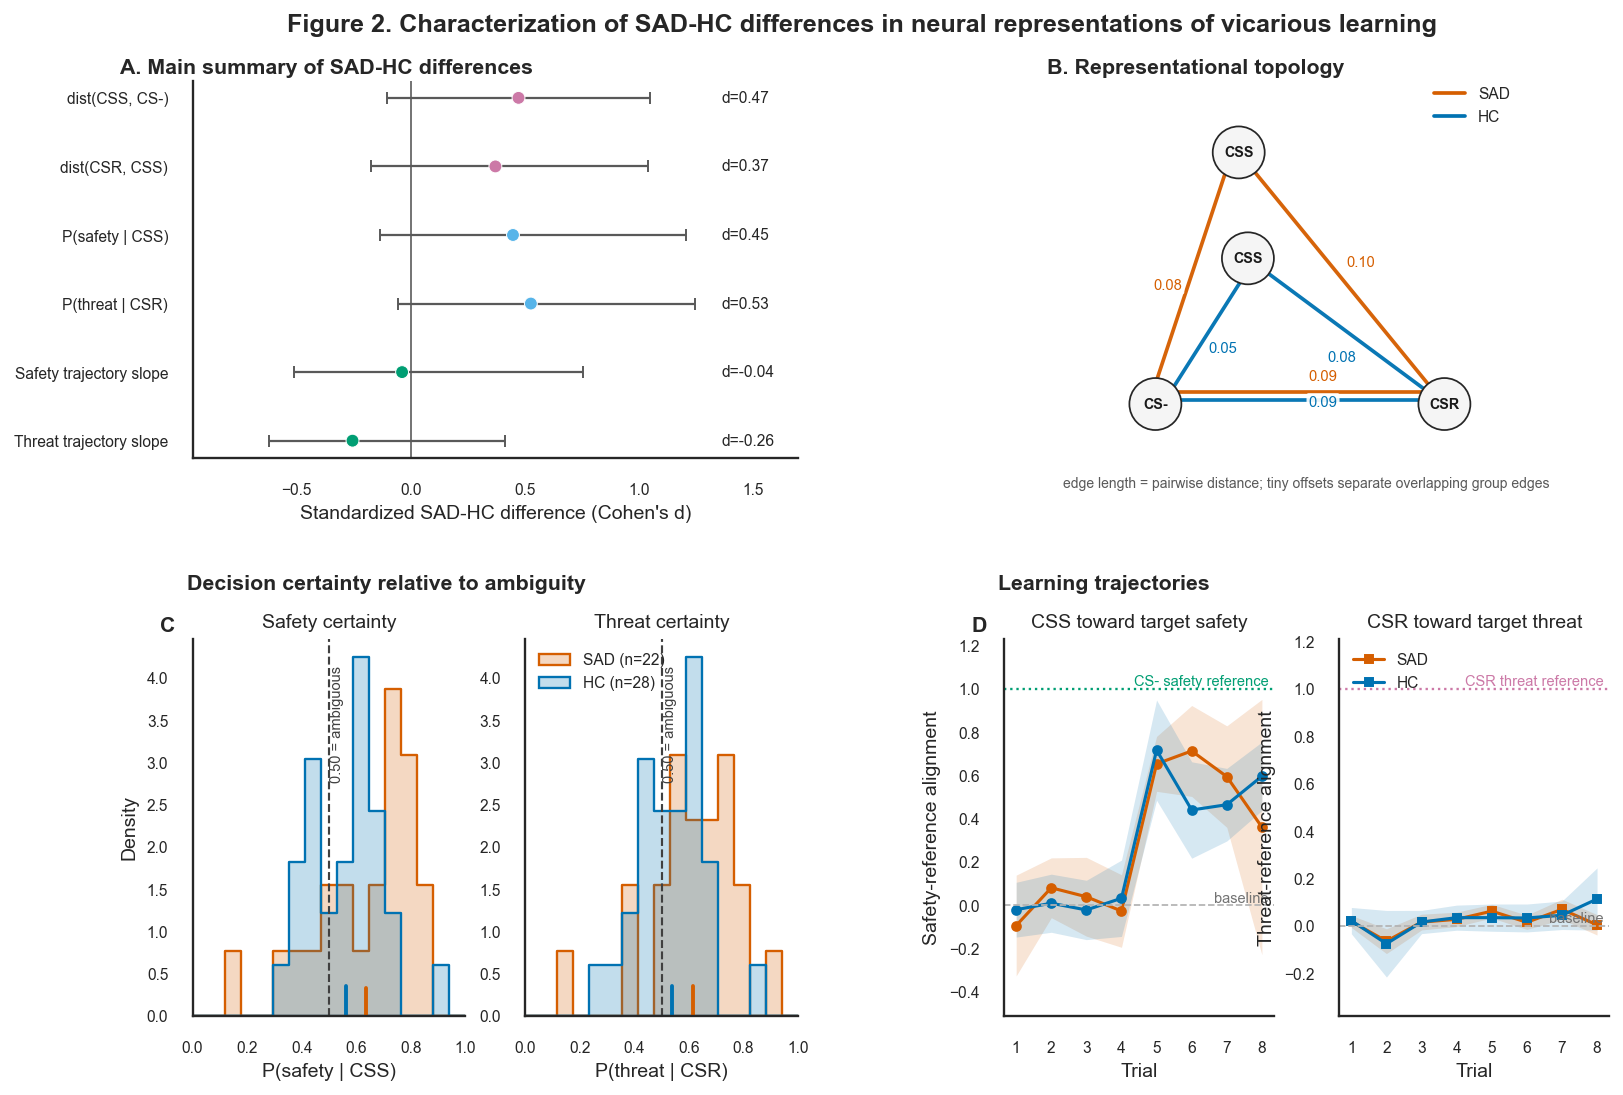

In [12]:
AIM2_FIGURE_SEED = 20260616
AIM2_FIGURE_BASENAME = 'figure2_aim2'
AIM2_EXPECTED_TRAJECTORY_METRIC = 'early_to_target_normalized_projection'
AIM2_GROUP_ORDER = ['SAD', 'HC']
AIM2_GROUP_COLORS = {'HC': OKABE['blue'], 'SAD': OKABE['vermillion']}
AIM2_FIGURE_METRICS = SHARED_AIM2_TO_AIM5_METRICS.copy()
AIM2_FIGURE_METRIC_FAMILIES = {
    metric: PRIMARY_NEURAL_METRIC_FAMILIES.get(metric, 'Secondary').lower()
    for metric in AIM2_FIGURE_METRICS
}
AIM2_FIGURE_FAMILY_COLORS = {
    'geometry': OKABE['purple'],
    'certainty': OKABE['sky'],
    'trajectory': OKABE['green'],
    'trajectories': OKABE['green'],
    'secondary': OKABE['gray'],
}
AIM2_FIGURE_COLUMN_MAP = {
    'subject_id': ['subject_id', 'Subject', 'sub_ID', 'sub'],
    'group': ['group', 'Group'],
    **PRIMARY_NEURAL_METRIC_COLUMN_CANDIDATES,
}
AIM2_FIGURE_METRIC_LABELS = {
    metric: PRIMARY_NEURAL_METRIC_LABELS.get(metric, metric)
    for metric in AIM2_FIGURE_METRICS
}
AIM2_PANEL_TITLE_PROPS = {'fontfamily': 'Arial', 'fontsize': 11, 'fontweight': 'bold'}
AIM2_SUBPLOT_TITLE_PROPS = {'fontfamily': 'Arial', 'fontsize': 10, 'fontweight': 'normal'}
AIM2_SUPTITLE_PROPS = {'fontfamily': 'Arial', 'fontsize': 13, 'fontweight': 'bold'}


def setup_publication_theme():
    sns.set_theme(
        context='talk',
        style='white',
        font='Arial',
        font_scale=1.0,
        rc={
            'axes.linewidth': 1.2,
            'axes.labelsize': 10,
            'axes.titlesize': 11,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 8,
            'figure.titlesize': 13,
            'pdf.fonttype': 42,
            'ps.fonttype': 42,
            'svg.fonttype': 'none',
        },
    )


def first_existing_column(df, candidates):
    return next((col for col in candidates if col in df.columns), None)


def load_data(subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    subject_df, subject_note = resolve_aim2_subject_data(
        subject_source_df if subject_source_df is not None else metrics_df,
        feature_space=feature_space,
        drug=drug,
    )
    missing_flags = {'subject': subject_df.empty}
    geometry_df, geometry_note = load_geometry_data()
    missing_flags['geometry'] = geometry_df.empty
    trajectory_df, trajectory_note = load_trajectory_data(feature_space=feature_space)
    missing_flags['trajectory'] = trajectory_df.empty
    return {
        'subject': subject_df,
        'geometry': geometry_df,
        'trajectory': trajectory_df,
        'notes': {'subject': subject_note, 'geometry': geometry_note, 'trajectory': trajectory_note},
        'missing_flags': missing_flags,
    }


def resolve_aim2_subject_data(df, feature_space='FearNetwork', drug='Placebo'):
    if df is None or df.empty:
        return pd.DataFrame(), 'demo: subject metrics table missing'
    sub = add_primary_neural_metric_columns(df, feature_space=feature_space, phase='phase2_extinction')
    if 'FeatureSpace' in sub.columns:
        sub = sub[sub['FeatureSpace'].astype(str).eq(feature_space)]
    if drug and 'Drug' in sub.columns:
        sub = sub[sub['Drug'].astype(str).eq(drug)]
    out = pd.DataFrame(index=sub.index)
    missing = []
    for canonical, candidates in AIM2_FIGURE_COLUMN_MAP.items():
        source = first_existing_column(sub, candidates)
        if source is None:
            missing.append(canonical)
            continue
        out[canonical] = sub[source]
    if missing or 'group' not in out.columns:
        return pd.DataFrame(), f'demo: missing required subject columns {missing}'
    out['group'] = out['group'].astype(str)
    out = out[out['group'].isin(AIM2_GROUP_ORDER)].copy()
    for metric in AIM2_FIGURE_METRICS:
        out[metric] = pd.to_numeric(out[metric], errors='coerce')
    out = out.dropna(subset=AIM2_FIGURE_METRICS)
    if out.empty or set(out['group']) != set(AIM2_GROUP_ORDER):
        return pd.DataFrame(), 'missing: complete HC and SAD subject rows unavailable'
    return out.reset_index(drop=True), 'real subject-level metrics'


def compute_cohens_d(values, groups):
    values = pd.to_numeric(pd.Series(values), errors='coerce')
    groups = pd.Series(groups).astype(str)
    sad = values[groups.eq('SAD')].dropna().to_numpy(dtype=float)
    hc = values[groups.eq('HC')].dropna().to_numpy(dtype=float)
    if sad.size < 2 or hc.size < 2:
        return np.nan
    pooled_num = (sad.size - 1) * np.nanvar(sad, ddof=1) + (hc.size - 1) * np.nanvar(hc, ddof=1)
    pooled_den = sad.size + hc.size - 2
    pooled_sd = np.sqrt(pooled_num / pooled_den) if pooled_den > 0 else np.nan
    if not np.isfinite(pooled_sd) or pooled_sd == 0:
        return np.nan
    return (np.nanmean(sad) - np.nanmean(hc)) / pooled_sd


def bootstrap_cohens_d_ci(df, metric, n_boot=5000, seed=AIM2_FIGURE_SEED):
    rng = np.random.default_rng(seed)
    sad = df.loc[df['group'].eq('SAD'), metric].dropna().to_numpy(dtype=float)
    hc = df.loc[df['group'].eq('HC'), metric].dropna().to_numpy(dtype=float)
    if sad.size < 2 or hc.size < 2:
        return np.nan, np.nan, np.nan
    observed = compute_cohens_d(df[metric], df['group'])
    boot = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sad_sample = rng.choice(sad, size=sad.size, replace=True)
        hc_sample = rng.choice(hc, size=hc.size, replace=True)
        boot[i] = compute_cohens_d(
            np.concatenate([sad_sample, hc_sample]),
            np.array(['SAD'] * sad.size + ['HC'] * hc.size),
        )
    ci_low, ci_high = np.nanpercentile(boot, [2.5, 97.5])
    return observed, ci_low, ci_high


def compute_effect_sizes(subject_df):
    rows = []
    for order, metric in enumerate(AIM2_FIGURE_METRICS, start=1):
        d_value, ci_low, ci_high = bootstrap_cohens_d_ci(subject_df, metric, seed=AIM2_FIGURE_SEED + order)
        rows.append({
            'metric': metric,
            'metric_family': AIM2_FIGURE_METRIC_FAMILIES[metric],
            'label': AIM2_FIGURE_METRIC_LABELS[metric],
            'cohens_d': d_value,
            'ci_low': ci_low,
            'ci_high': ci_high,
        })
    return pd.DataFrame(rows)


def load_geometry_data():
    needed = {'subject_id', 'group', 'condition', 'safety_alignment', 'threat_alignment'}
    if 'aim2_geometry_df' in globals():
        candidate = globals()['aim2_geometry_df']
        if isinstance(candidate, pd.DataFrame) and needed.issubset(candidate.columns):
            return candidate.copy(), 'real geometry table: aim2_geometry_df'
    csv_path = STATS_DIR / 'aim2_geometry_panel.csv'
    if csv_path.exists():
        candidate = pd.read_csv(csv_path)
        if needed.issubset(candidate.columns):
            return candidate.copy(), f'geometry table: {csv_path.name}'
    return pd.DataFrame(columns=sorted(needed)), 'missing geometry: real subject-level condition centroids unavailable'


def standardize_trajectory_frame(data, trajectory, trajectory_metric=AIM2_EXPECTED_TRAJECTORY_METRIC):
    subject_col = first_existing_column(data, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    trial_col = first_existing_column(data, ['trial', 'Trial', 'block', 'Block'])
    score_col = first_existing_column(data, ['score', 'Score', 'similarity', 'Similarity', 'value', 'evidence'])
    group_col = first_existing_column(data, ['group', 'Group'])
    if subject_col is None or trial_col is None or score_col is None or group_col is None:
        return pd.DataFrame()
    cols = [subject_col, trial_col, score_col, group_col]
    out = data[cols].copy()
    rename = {subject_col: 'subject_id', trial_col: 'trial', score_col: 'value', group_col: 'group'}
    out = out.rename(columns=rename)
    out['trajectory'] = trajectory
    out['trajectory_metric'] = trajectory_metric
    out['trial'] = pd.to_numeric(out['trial'], errors='coerce')
    out['value'] = pd.to_numeric(out['value'], errors='coerce')
    out['group'] = out['group'].astype(str)
    out = out[out['group'].isin(AIM2_GROUP_ORDER)].dropna(subset=['trial', 'value'])
    return out[['subject_id', 'group', 'trial', 'trajectory', 'trajectory_metric', 'value']]


def load_trajectory_data(feature_space='FearNetwork'):
    csv_path = STATS_DIR / 'aim2_trajectory_panel.csv'
    needed_csv = {'subject_id', 'group', 'trial', 'trajectory', 'trajectory_metric', 'value'}
    stale_note = ''
    if csv_path.exists():
        candidate = pd.read_csv(csv_path)
        if needed_csv.issubset(candidate.columns) and candidate['trajectory_metric'].astype(str).eq(AIM2_EXPECTED_TRAJECTORY_METRIC).all():
            return candidate.copy(), f'trial-level table: {csv_path.name}'
        stale_note = f'stale trajectory table without {AIM2_EXPECTED_TRAJECTORY_METRIC}: {csv_path.name}; '
    if 'aim2_trial_df' in globals():
        candidate = globals()['aim2_trial_df']
        needed = {'subject_id', 'group', 'trial', 'condition'}
        if isinstance(candidate, pd.DataFrame) and needed.issubset(candidate.columns):
            rows = []
            if 'safety_alignment' in candidate.columns:
                safety = candidate[candidate['condition'].astype(str).eq('CSS')].copy()
                safety = safety.rename(columns={'safety_alignment': 'value'})
                safety['trajectory'] = 'safety'
                safety['trajectory_metric'] = AIM2_EXPECTED_TRAJECTORY_METRIC
                rows.append(safety[['subject_id', 'group', 'trial', 'trajectory', 'trajectory_metric', 'value']])
            if 'threat_evidence' in candidate.columns:
                threat = candidate[candidate['condition'].astype(str).eq('CSR')].copy()
                threat = threat.rename(columns={'threat_evidence': 'value'})
                threat['trajectory'] = 'threat'
                threat['trajectory_metric'] = AIM2_EXPECTED_TRAJECTORY_METRIC
                rows.append(threat[['subject_id', 'group', 'trial', 'trajectory', 'trajectory_metric', 'value']])
            if rows:
                return pd.concat(rows, ignore_index=True), 'real trial-level table: aim2_trial_df'
    if 'find_trajectory_payload' in globals():
        results, path = find_trajectory_payload(feature_space)
        if isinstance(results, dict) and results.get('trajectory_metric') == AIM2_EXPECTED_TRAJECTORY_METRIC:
            frames = []
            for trajectory, key in [('safety', 'data_safe'), ('threat', 'data_threat')]:
                data = results.get(key)
                if isinstance(data, pd.DataFrame) and not data.empty:
                    frames.append(standardize_trajectory_frame(data, trajectory, results.get('trajectory_metric')))
            frames = [frame for frame in frames if not frame.empty]
            if frames:
                return pd.concat(frames, ignore_index=True), f'real trajectory payload: {path}'
        elif isinstance(results, dict):
            stale_note += f'stale trajectory payload without {AIM2_EXPECTED_TRAJECTORY_METRIC}: {path}; '
    return pd.DataFrame(columns=['subject_id', 'group', 'trial', 'trajectory', 'trajectory_metric', 'value']), stale_note + 'missing trajectory: rerun Stage 14 and post-Hyak export for early-to-target normalized-projection trajectories'


def summarize_trajectory_subject_ci(trajectory_df, trajectory):
    summary_cols = ['group', 'trial', 'mean', 'ci_low', 'ci_high', 'n_subjects']
    sub = trajectory_df[trajectory_df['trajectory'].eq(trajectory)].copy()
    if sub.empty:
        return pd.DataFrame(columns=summary_cols)
    subject_trial = sub.groupby(['subject_id', 'group', 'trial'], dropna=False)['value'].mean().reset_index()
    rows = []
    for (group, trial), chunk in subject_trial.groupby(['group', 'trial'], dropna=False):
        values = chunk['value'].dropna().to_numpy(dtype=float)
        n = len(values)
        mean = float(np.nanmean(values)) if n else np.nan
        sem = float(np.nanstd(values, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
        rows.append({'group': group, 'trial': trial, 'mean': mean, 'ci_low': mean - 1.96 * sem, 'ci_high': mean + 1.96 * sem, 'n_subjects': n})
    if not rows:
        return pd.DataFrame(columns=summary_cols)
    return pd.DataFrame(rows, columns=summary_cols).sort_values(['group', 'trial'])


def add_aim2_panel_title(ax, title, y=1.12):
    ax.text(-0.02, y, title, transform=ax.transAxes, ha='left', va='bottom', **AIM2_PANEL_TITLE_PROPS)


def set_aim2_subplot_title(ax, title):
    ax.set_title(title, fontdict=AIM2_SUBPLOT_TITLE_PROPS)


def show_missing_panel(ax, title, detail='Required observed data unavailable'):
    ax.set_axis_off()
    ax.text(0.5, 0.54, 'Missing', transform=ax.transAxes, ha='center', va='center', fontsize=12, fontweight='bold', color='0.25')
    ax.text(0.5, 0.42, detail, transform=ax.transAxes, ha='center', va='center', fontsize=8.5, color='0.35', wrap=True)
    set_aim2_subplot_title(ax, title)


def plot_panel_a_summary(ax, effect_df):
    required = {'metric_family', 'cohens_d', 'ci_low', 'ci_high', 'label'}
    if effect_df is None or effect_df.empty or not required.issubset(effect_df.columns):
        show_missing_panel(ax, 'Main summary of SAD-HC differences', 'Subject-level Aim 2 metrics are missing')
        return
    plot_df = effect_df.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_df))
    colors = [AIM2_FIGURE_FAMILY_COLORS.get(fam, OKABE['gray']) for fam in plot_df['metric_family']]
    ax.axvline(0, color='0.45', linewidth=1.0)
    ax.errorbar(
        plot_df['cohens_d'],
        y,
        xerr=[plot_df['cohens_d'] - plot_df['ci_low'], plot_df['ci_high'] - plot_df['cohens_d']],
        fmt='none',
        ecolor='0.35',
        elinewidth=1.15,
        capsize=3.0,
    )
    ax.scatter(plot_df['cohens_d'], y, c=colors, s=44, zorder=3, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df['label'])
    x_min = min(-0.05, float(np.nanmin(plot_df['ci_low'])))
    x_max = max(0.05, float(np.nanmax(plot_df['ci_high'])))
    pad = max((x_max - x_min) * 0.18, 0.20)
    ax.set_xlim(x_min - pad, x_max + 1.35 * pad)
    text_x = x_max + 0.35 * pad
    for pos, row in plot_df.iterrows():
        ax.text(text_x, pos, f"d={row['cohens_d']:.2f}", va='center', ha='left', fontsize=8)
    #ax.text(0.00, -0.19, 'Positive values indicate higher values in SAD', transform=ax.transAxes, ha='left', va='top', fontsize=8, color='0.35')
    ax.set_xlabel("Standardized SAD-HC difference (Cohen's d)")
    #add_aim2_panel_title(ax, 'Main summary of SAD-HC differences', y=1.04)
    #ax.set_title('A. Main summary of SAD-HC differences', loc='left', fontweight='bold')
    sns.despine(ax=ax)


def summarize_geometry_topology(geometry_df):
    pairs = [
        ('CS-', 'CSS', 'Safety integration'),
        ('CSS', 'CSR', 'Threat-safety separation'),
        ('CS-', 'CSR', 'Threat-background separation'),
    ]
    needed = {'subject_id', 'group', 'condition', 'safety_alignment', 'threat_alignment'}
    if geometry_df is None or geometry_df.empty or not needed.issubset(geometry_df.columns):
        return pd.DataFrame(columns=['group', 'condition_a', 'condition_b', 'relationship', 'mean_distance', 'sem_distance', 'n_subjects'])
    work = geometry_df[list(needed)].copy()
    work['group'] = work['group'].astype(str)
    work['condition'] = work['condition'].astype(str)
    work['safety_alignment'] = pd.to_numeric(work['safety_alignment'], errors='coerce')
    work['threat_alignment'] = pd.to_numeric(work['threat_alignment'], errors='coerce')
    work = work.dropna(subset=['subject_id', 'group', 'condition', 'safety_alignment', 'threat_alignment'])
    rows = []
    for group, group_df in work.groupby('group'):
        for condition_a, condition_b, relationship in pairs:
            distances = []
            for _, subject_df in group_df.groupby('subject_id'):
                centers = subject_df.groupby('condition')[['safety_alignment', 'threat_alignment']].mean()
                if condition_a not in centers.index or condition_b not in centers.index:
                    continue
                delta = centers.loc[condition_a].to_numpy(dtype=float) - centers.loc[condition_b].to_numpy(dtype=float)
                distances.append(float(np.linalg.norm(delta)))
            distances = np.asarray(distances, dtype=float)
            distances = distances[np.isfinite(distances)]
            n_subjects = int(distances.size)
            mean_distance = float(np.mean(distances)) if n_subjects else np.nan
            sem_distance = float(np.std(distances, ddof=1) / np.sqrt(n_subjects)) if n_subjects > 1 else 0.0
            rows.append({
                'group': group,
                'condition_a': condition_a,
                'condition_b': condition_b,
                'relationship': relationship,
                'mean_distance': mean_distance,
                'sem_distance': sem_distance,
                'n_subjects': n_subjects,
            })
    return pd.DataFrame(rows)


def _aim2_geometry_edge_value(topology_df, group, condition_a, condition_b):
    group_edges = topology_df[topology_df['group'].astype(str).eq(group)]
    edge = group_edges[(group_edges['condition_a'].eq(condition_a)) & (group_edges['condition_b'].eq(condition_b))]
    if edge.empty or not np.isfinite(edge['mean_distance'].iloc[0]):
        return np.nan
    return float(edge['mean_distance'].iloc[0])


def _aim2_triangle_from_distances(distances, unit_scale):
    cs_minus = np.array([0.0, 0.0])
    csr = np.array([distances[('CS-', 'CSR')] * unit_scale, 0.0])
    cs_css = distances[('CS-', 'CSS')] * unit_scale
    css_csr = distances[('CSS', 'CSR')] * unit_scale
    base = np.linalg.norm(csr - cs_minus)
    if not np.isfinite(base) or base <= 0:
        return None
    x = (cs_css ** 2 + base ** 2 - css_csr ** 2) / (2 * base)
    y_sq = max(cs_css ** 2 - x ** 2, 0.0)
    return {'CS-': cs_minus, 'CSR': csr, 'CSS': np.array([x, np.sqrt(y_sq)])}


def _aim2_offset_segment(p1, p2, offset):
    vector = p2 - p1
    normal = np.array([-vector[1], vector[0]])
    norm = np.linalg.norm(normal)
    if norm > 0:
        normal = normal / norm
    return p1 + normal * offset, p2 + normal * offset


def _aim2_edge_label(ax, p1, p2, label, color, offset=0.055, along=0.50):
    midpoint = p1 + along * (p2 - p1)
    vector = p2 - p1
    normal = np.array([-vector[1], vector[0]])
    norm = np.linalg.norm(normal)
    if norm > 0:
        normal = normal / norm
    if abs(vector[1]) < 1e-8:
        normal = np.array([0.0, 1.0])
    position = midpoint + normal * offset
    ax.text(
        position[0], position[1], label,
        ha='center', va='center', fontsize=7.6, color=color,
        bbox={'boxstyle': 'round,pad=0.14', 'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.92},
        zorder=10,
    )


def _aim2_condition_dot(ax, position, label, radius=0.058):
    from matplotlib.patches import Circle
    dot = Circle(position, radius=radius, facecolor='0.96', edgecolor='0.15', linewidth=0.9, zorder=8)
    ax.add_patch(dot)
    ax.text(position[0], position[1], label, ha='center', va='center', fontsize=7.4, color='0.10', fontweight='bold', zorder=9)


def plot_panel_b_geometry(ax, geometry_df):
    needed = {'subject_id', 'group', 'condition', 'safety_alignment', 'threat_alignment'}
    if geometry_df is None or geometry_df.empty or not needed.issubset(geometry_df.columns):
        show_missing_panel(ax, 'Representational topology', 'Geometry export is missing')
        #add_aim2_panel_title(ax, 'Representational topology')
        return
    topology_df = summarize_geometry_topology(geometry_df)
    if topology_df.empty:
        show_missing_panel(ax, 'Representational topology', 'Pairwise geometry cannot be computed')
        #add_aim2_panel_title(ax, 'Representational topology')
        return

    group_distances = {}
    for group in AIM2_GROUP_ORDER:
        values = {
            ('CS-', 'CSS'): _aim2_geometry_edge_value(topology_df, group, 'CS-', 'CSS'),
            ('CSS', 'CSR'): _aim2_geometry_edge_value(topology_df, group, 'CSS', 'CSR'),
            ('CS-', 'CSR'): _aim2_geometry_edge_value(topology_df, group, 'CS-', 'CSR'),
        }
        if all(np.isfinite(value) and value > 0 for value in values.values()):
            group_distances[group] = values
    if not {'SAD', 'HC'}.issubset(group_distances):
        show_missing_panel(ax, 'Representational topology', 'Complete SAD and HC pairwise distances are unavailable')
        #add_aim2_panel_title(ax, 'Representational topology')
        return

    max_distance = max(max(values.values()) for values in group_distances.values())
    unit_scale = 0.72 / max_distance if np.isfinite(max_distance) and max_distance > 0 else 1.0
    coords = {group: _aim2_triangle_from_distances(values, unit_scale) for group, values in group_distances.items()}
    coords = {group: value for group, value in coords.items() if value is not None}
    if not {'SAD', 'HC'}.issubset(coords):
        show_missing_panel(ax, 'Representational topology', 'Pairwise distances do not form a valid topology')
        #add_aim2_panel_title(ax, 'Representational topology')
        return

    # Use a single shared CS-/CSR anchor pair. The group-specific base edges are
    # drawn as tiny parallel offsets so the two equal-length distances remain visible.
    shared_base = np.mean([group_distances['SAD'][('CS-', 'CSR')], group_distances['HC'][('CS-', 'CSR')]]) * unit_scale
    shared_cs_minus = np.array([0.0, 0.0])
    shared_csr = np.array([shared_base, 0.0])
    for group in coords:
        coords[group]['CS-'] = shared_cs_minus
        coords[group]['CSR'] = shared_csr

    group_specs = [
        ('SAD', AIM2_GROUP_COLORS['SAD'], 0.014, 0.026),
        ('HC', AIM2_GROUP_COLORS['HC'], -0.014, 0.010),
    ]
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    for group, color, cs_css_offset, _ in group_specs:
        p1, p2 = _aim2_offset_segment(coords[group]['CS-'], coords[group]['CSS'], cs_css_offset)
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=1.9, alpha=0.96, solid_capstyle='round', zorder=2)
        p1, p2 = coords[group]['CSS'], coords[group]['CSR']
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=1.9, alpha=0.96, solid_capstyle='round', zorder=2)

    for group, color, _, base_offset in group_specs:
        p1, p2 = _aim2_offset_segment(coords[group]['CS-'], coords[group]['CSR'], base_offset)
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=1.9, alpha=0.96, solid_capstyle='round', zorder=3)
        _aim2_edge_label(ax, p1, p2, f"{group_distances[group][('CS-', 'CSR')]:.2f}", color, offset=0.035 if group == 'SAD' else -0.006, along=0.58)

    p1, p2 = _aim2_offset_segment(coords['SAD']['CS-'], coords['SAD']['CSS'], 0.014)
    _aim2_edge_label(ax, p1, p2, f"{group_distances['SAD'][('CS-', 'CSS')]:.2f}", AIM2_GROUP_COLORS['SAD'], offset=0.043, along=0.44)
    p1, p2 = _aim2_offset_segment(coords['HC']['CS-'], coords['HC']['CSS'], -0.014)
    _aim2_edge_label(ax, p1, p2, f"{group_distances['HC'][('CS-', 'CSS')]:.2f}", AIM2_GROUP_COLORS['HC'], offset=-0.046, along=0.48)
    _aim2_edge_label(ax, coords['SAD']['CSS'], coords['SAD']['CSR'], f"{group_distances['SAD'][('CSS', 'CSR')]:.2f}", AIM2_GROUP_COLORS['SAD'], offset=0.054, along=0.50)
    _aim2_edge_label(ax, coords['HC']['CSS'], coords['HC']['CSR'], f"{group_distances['HC'][('CSS', 'CSR')]:.2f}", AIM2_GROUP_COLORS['HC'], offset=-0.054, along=0.55)

    _aim2_condition_dot(ax, shared_cs_minus, 'CS-')
    _aim2_condition_dot(ax, shared_csr, 'CSR')
    _aim2_condition_dot(ax, coords['SAD']['CSS'], 'CSS')
    _aim2_condition_dot(ax, coords['HC']['CSS'], 'CSS')

    ax.plot([], [], color=AIM2_GROUP_COLORS['SAD'], linewidth=1.9, label='SAD')
    ax.plot([], [], color=AIM2_GROUP_COLORS['HC'], linewidth=1.9, label='HC')
    ax.legend(frameon=False, loc='upper right', borderaxespad=0.0)

    all_points = [shared_cs_minus, shared_csr, coords['SAD']['CSS'], coords['HC']['CSS']]
    xs = [point[0] for point in all_points]
    ys = [point[1] for point in all_points]
    ax.set_xlim(min(xs) - 0.13, max(xs) + 0.16)
    ax.set_ylim(min(ys) - 0.12, max(ys) + 0.16)
    ax.text(
        0.5, -0.05,
        'edge length = pairwise distance; tiny offsets separate overlapping group edges',
        transform=ax.transAxes, ha='center', va='top', fontsize=7.2, color='0.35',
    )
    #add_aim2_panel_title(ax, 'Representational topology')


def plot_panel_c_certainty(axes, subject_df):
    specs = [
        ('Neural_SafetyEvidence', 'Safety certainty', 'P(safety | CSS)'),
        ('Neural_ThreatEvidence', 'Threat certainty', 'P(threat | CSR)'),
    ]
    if subject_df is None or subject_df.empty or 'group' not in subject_df.columns:
        for ax, (_, title, _) in zip(axes, specs):
            show_missing_panel(ax, title, 'Subject-level certainty metrics are missing')
        add_aim2_panel_title(axes[0], 'Decision certainty relative to ambiguity')
        return
    for ax, (metric, title, xlabel) in zip(axes, specs):
        if metric not in subject_df.columns:
            show_missing_panel(ax, title, f'{metric} is missing')
            continue
        plot_df = subject_df[['group', metric]].dropna().copy()
        plot_df[metric] = pd.to_numeric(plot_df[metric], errors='coerce').clip(0, 1)
        for group in AIM2_GROUP_ORDER:
            sub = plot_df[plot_df['group'].eq(group)]
            if sub.empty:
                continue
            sns.histplot(
                data=sub,
                x=metric,
                bins=np.linspace(0, 1, 18),
                stat='density',
                element='step',
                fill=True,
                alpha=0.24,
                color=AIM2_GROUP_COLORS[group],
                linewidth=1.2,
                ax=ax,
                label=f'{group} (n={len(sub)})',
            )
            mean_value = sub[metric].mean()
            ax.plot([mean_value, mean_value], [0, ax.get_ylim()[1] * 0.08], color=AIM2_GROUP_COLORS[group], linewidth=2.0, solid_capstyle='round')
        ax.axvline(0.50, color='0.25', linestyle='--', linewidth=1.1)
        ax.text(0.505, 0.93, '0.50 = ambiguous', transform=ax.get_xaxis_transform(), rotation=90, va='top', ha='left', fontsize=7.5, color='0.25')
        ax.set_xlim(0, 1)
        set_aim2_subplot_title(ax, title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density' if metric == 'Neural_SafetyEvidence' else '')
        sns.despine(ax=ax)
    add_aim2_panel_title(axes[0], 'Decision certainty relative to ambiguity')
    axes[1].legend(frameon=False, loc='upper left')


def plot_panel_d_trajectories(axes, trajectory_df):
    specs = [
        ('safety', 'CSS toward target safety', 'Safety-reference alignment', 'o', OKABE['green'], 'CS- safety reference'),
        ('threat', 'CSR toward target threat', 'Threat-reference alignment', 's', OKABE['purple'], 'CSR threat reference'),
    ]
    needed = {'subject_id', 'group', 'trial', 'trajectory', 'value'}
    if trajectory_df is None or trajectory_df.empty or not needed.issubset(trajectory_df.columns):
        for ax, (_, title, _, _, _, _) in zip(axes, specs):
            show_missing_panel(ax, title, 'Trial-level trajectory export is missing')
        add_aim2_panel_title(axes[0], 'Learning trajectories')
        return
    for ax, (trajectory, title, ylabel, marker, target_color, target_label) in zip(axes, specs):
        summary = summarize_trajectory_subject_ci(trajectory_df, trajectory)
        if summary.empty:
            show_missing_panel(ax, title, f'{trajectory.capitalize()} trial-level trajectory export is missing')
            continue
        y_values = []
        for group in AIM2_GROUP_ORDER:
            sub = summary[summary['group'].astype(str).eq(group)]
            if sub.empty:
                continue
            color = AIM2_GROUP_COLORS[group]
            x = sub['trial'].to_numpy(dtype=float)
            mean = sub['mean'].to_numpy(dtype=float)
            ci_low = sub['ci_low'].to_numpy(dtype=float)
            ci_high = sub['ci_high'].to_numpy(dtype=float)
            y_values.extend(mean[np.isfinite(mean)].tolist())
            y_values.extend(ci_low[np.isfinite(ci_low)].tolist())
            y_values.extend(ci_high[np.isfinite(ci_high)].tolist())
            ax.plot(x, mean, color=color, marker=marker, markersize=4.5, linewidth=1.6, label=group)
            ax.fill_between(x, ci_low, ci_high, color=color, alpha=0.16, linewidth=0)
        if y_values:
            y_low, y_high = np.nanpercentile(np.asarray(y_values, dtype=float), [1, 99])
            y_low = min(y_low, 0.0)
            y_high = max(y_high, 1.0)
            pad = max((y_high - y_low) * 0.18, 0.05)
            ax.set_ylim(y_low - pad, y_high + pad)
        ax.axhline(0, color='0.70', linestyle='--', linewidth=0.9)
        ax.axhline(1, color=target_color, linestyle=':', linewidth=1.2)
        ax.text(0.98, 0, 'baseline', transform=ax.get_yaxis_transform(), ha='right', va='bottom', fontsize=7.5, color='0.45')
        ax.text(0.98, 1, target_label, transform=ax.get_yaxis_transform(), ha='right', va='bottom', fontsize=7.5, color=target_color)
        set_aim2_subplot_title(ax, title)
        ax.set_xlabel('Trial')
        ax.set_ylabel(ylabel)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        sns.despine(ax=ax)
    add_aim2_panel_title(axes[0], 'Learning trajectories')
    axes[1].legend(frameon=False, loc='upper left')


def save_figure2(fig):
    svg = FIG_DIR / f'{AIM2_FIGURE_BASENAME}.svg'
    pdf = FIG_DIR / f'{AIM2_FIGURE_BASENAME}.pdf'
    png = FIG_DIR / f'{AIM2_FIGURE_BASENAME}.png'
    fig.savefig(svg, bbox_inches='tight')
    fig.savefig(pdf, bbox_inches='tight')
    fig.savefig(png, dpi=600, bbox_inches='tight')
    print(f'Saved {svg}')
    print(f'Saved {pdf}')
    print(f'Saved {png}')


def make_figure2(subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    setup_publication_theme()
    data = load_data(subject_source_df=subject_source_df, feature_space=feature_space, drug=drug)
    effect_df = compute_effect_sizes(data['subject'])

    fig = plt.figure(figsize=(11.0, 8.0), constrained_layout=False)
    gs = fig.add_gridspec(2, 2, left=0.065, right=0.985, top=0.925, bottom=0.09, wspace=0.34, hspace=0.48)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    certainty_gs = gs[1, 0].subgridspec(1, 2, wspace=0.22)
    ax_c1 = fig.add_subplot(certainty_gs[0, 0])
    ax_c2 = fig.add_subplot(certainty_gs[0, 1], sharey=ax_c1)
    trajectory_gs = gs[1, 1].subgridspec(1, 2, wspace=0.24)
    ax_d1 = fig.add_subplot(trajectory_gs[0, 0])
    ax_d2 = fig.add_subplot(trajectory_gs[0, 1])

    plot_panel_a_summary(ax_a, effect_df)
    plot_panel_b_geometry(ax_b, data['geometry'])
    plot_panel_c_certainty([ax_c1, ax_c2], data['subject'])
    plot_panel_d_trajectories([ax_d1, ax_d2], data['trajectory'])
    add_panel_label(ax_a, 'A. Main summary of SAD-HC differences')
    add_panel_label(ax_b, 'B. Representational topology')
    add_panel_label(ax_c1, 'C')
    add_panel_label(ax_d1, 'D')
    fig.suptitle('Figure 2. Characterization of SAD-HC differences in neural representations of vicarious learning', y=0.985, **AIM2_SUPTITLE_PROPS)

    caption_extra = ' Panels labeled Missing indicate required observed exports were unavailable.' if any(data['missing_flags'].values()) else ''
    figure2_aim2_caption = (
        'Figure 2. Characterization of SAD-HC differences in neural representations of vicarious learning. '
        'Panel A shows standardized SAD-HC group differences across the primary Aim 2 neural metrics. Positive values indicate higher values in SAD than HC. '
        'Panel B shows representational topology using a common distance scale: edge length represents pairwise representational distance, condition labels are shown inside identical nodes, and small offsets separate overlapping SAD and HC edges for visibility. '
        'Panel C shows distributions of decoder posterior probabilities for safety and threat certainty. The dashed vertical line at 0.50 indicates ambiguous or chance-level decoder evidence; values closer to 1.00 indicate stronger certainty for the corresponding target state. '
        "Panel D shows trial-wise normalized projection of CSS extinction trials along each subject\'s early-CSS-to-CS- safety axis and CSR extinction trials along each subject\'s early-CSR-to-reinstated-CSR threat axis; 0 marks the early-learning start centroid and 1 marks the target centroid."
        f'{caption_extra}'
    )
    save_figure2(fig)
    print(f"Aim 2 figure data source - subject metrics: {data['notes']['subject']}; geometry: {data['notes']['geometry']}; trajectories: {data['notes']['trajectory']}")
    display(Markdown(f'**Draft Figure 2 caption:** {figure2_aim2_caption}'))
    return fig, effect_df, data, figure2_aim2_caption


figure2_aim2, figure2_aim2_effects, figure2_aim2_data, figure2_aim2_caption = make_figure2(metrics_df)
show_figure_once(figure2_aim2)


In [ ]:
from scipy import stats

AIM2_PRIMARY_TABLE_STEM = 'Table2_Aim2_primary_statistics'
AIM2_PRIMARY_TABLE_CSV = STATS_DIR / f'{AIM2_PRIMARY_TABLE_STEM}.csv'
AIM2_PRIMARY_TABLE_MD = STATS_DIR / f'{AIM2_PRIMARY_TABLE_STEM}.md'
AIM2_PRIMARY_TABLE_COLUMNS = [
    'scientific_question',
    'metric',
    'effect_label',
    'n_sad',
    'n_hc',
    'n',
    'estimate',
    'std_error',
    'ci_low',
    'ci_high',
    't',
    'df_resid',
    'model_family_p',
    'model_family_q',
    'whole_dataset_p',
    'whole_dataset_q',
    'standardized_effect',
    'standardized_effect_type',
    'correction_family',
    'formula',
    'status',
]


def _aim2_complete_case_subjects(metric, subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    source = metrics_df if subject_source_df is None else subject_source_df
    if source is None or source.empty:
        return pd.DataFrame()
    sub = source.copy()
    if 'FeatureSpace' in sub.columns:
        sub = sub[sub['FeatureSpace'].astype(str).eq(feature_space)]
    if drug and 'Drug' in sub.columns:
        sub = sub[sub['Drug'].astype(str).eq(drug)]
    group_col = first_existing_column(sub, AIM2_FIGURE_COLUMN_MAP.get('group', ['Group', 'group']))
    metric_col = first_existing_column(sub, AIM2_FIGURE_COLUMN_MAP.get(metric, [metric]))
    needed = [col for col in [group_col, metric_col, 'demo_age', 'Gender'] if col is not None and col in sub.columns]
    if group_col is None or metric_col is None:
        return pd.DataFrame()
    complete = sub[needed].copy()
    complete = complete.rename(columns={group_col: 'group', metric_col: 'value'})
    complete['group'] = complete['group'].astype(str)
    complete['value'] = pd.to_numeric(complete['value'], errors='coerce')
    if 'demo_age' in complete.columns:
        complete['demo_age'] = pd.to_numeric(complete['demo_age'], errors='coerce')
    complete = complete[complete['group'].isin(AIM2_GROUP_ORDER)].copy()
    complete = complete.dropna(subset=[col for col in ['group', 'value', 'demo_age', 'Gender'] if col in complete.columns])
    return complete


def _aim2_design_residual_df(complete_cases):
    if complete_cases is None or complete_cases.empty:
        return np.nan
    design = pd.DataFrame({'intercept': 1.0, 'group_sad': complete_cases['group'].astype(str).eq('SAD').astype(float)})
    if 'demo_age' in complete_cases.columns:
        design['demo_age'] = pd.to_numeric(complete_cases['demo_age'], errors='coerce')
    if 'Gender' in complete_cases.columns:
        gender_dummies = pd.get_dummies(complete_cases['Gender'].astype(str), prefix='Gender', drop_first=True, dtype=float)
        design = pd.concat([design, gender_dummies], axis=1)
    design = design.apply(pd.to_numeric, errors='coerce').dropna(axis=0)
    if design.empty:
        return np.nan
    rank = np.linalg.matrix_rank(design.to_numpy(dtype=float))
    return int(design.shape[0] - rank)


def _aim2_group_counts_and_effect(metric, subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    complete = _aim2_complete_case_subjects(metric, subject_source_df=subject_source_df, feature_space=feature_space, drug=drug)
    if complete.empty:
        return {'n_sad': pd.NA, 'n_hc': pd.NA, 'df_resid': np.nan, 'standardized_effect': np.nan}
    counts = complete.groupby('group')['value'].count()
    n_sad = int(counts.get('SAD', 0))
    n_hc = int(counts.get('HC', 0))
    standardized = compute_cohens_d(complete['value'], complete['group']) if n_sad >= 2 and n_hc >= 2 else np.nan
    return {'n_sad': n_sad, 'n_hc': n_hc, 'df_resid': _aim2_design_residual_df(complete), 'standardized_effect': standardized}




def _aim2_design_matrix_for_whole_dataset(data):
    parts = [pd.Series(1.0, index=data.index, name='Intercept')]
    parts.append(data['group'].astype(str).eq('SAD').astype(float).rename('group_sad'))
    if 'Drug' in data.columns:
        drug_dummies = pd.get_dummies(data['Drug'].astype('string').str.strip(), prefix='Drug', drop_first=True, dtype=float)
        drug_dummies = drug_dummies.loc[:, drug_dummies.nunique(dropna=False) > 1]
        if not drug_dummies.empty:
            parts.append(drug_dummies)
    if 'demo_age' in data.columns:
        age = pd.to_numeric(data['demo_age'], errors='coerce')
        age_sd = age.std(ddof=1)
        if pd.notna(age_sd) and age_sd > 0:
            parts.append(((age - age.mean()) / age_sd).rename('z_demo_age'))
    if 'Gender' in data.columns:
        gender_dummies = pd.get_dummies(data['Gender'].astype('string').str.strip(), prefix='Gender', drop_first=True, dtype=float)
        gender_dummies = gender_dummies.loc[:, gender_dummies.nunique(dropna=False) > 1]
        if not gender_dummies.empty:
            parts.append(gender_dummies)
    return pd.concat(parts, axis=1).astype(float)


def _aim2_fit_ols_term(y, X, term):
    y = pd.to_numeric(y, errors='coerce').astype(float)
    valid = y.notna() & X.notna().all(axis=1)
    y = y.loc[valid]
    X = X.loc[valid]
    n = int(len(y))
    p = int(X.shape[1])
    if n <= p or term not in X.columns:
        return {'estimate': np.nan, 'p': np.nan, 'n': n}
    x_values = X.to_numpy(dtype=float)
    y_values = y.to_numpy(dtype=float)
    beta, _, _, _ = np.linalg.lstsq(x_values, y_values, rcond=None)
    fitted = x_values @ beta
    resid = y_values - fitted
    df_resid = n - p
    if df_resid <= 0:
        return {'estimate': np.nan, 'p': np.nan, 'n': n}
    sigma2 = float((resid @ resid) / df_resid)
    cov_beta = sigma2 * np.linalg.pinv(x_values.T @ x_values)
    se = np.sqrt(np.diag(cov_beta))
    params = pd.Series(beta, index=X.columns)
    se_series = pd.Series(se, index=X.columns)
    t_value = params[term] / se_series[term] if se_series[term] > 0 else np.nan
    p_value = float(2 * stats.t.sf(abs(t_value), df_resid)) if np.isfinite(t_value) else np.nan
    return {'estimate': float(params[term]), 'p': p_value, 'n': n}


def _aim2_whole_dataset_group_p_values(subject_source_df=None, feature_space='FearNetwork'):
    source = metrics_df if subject_source_df is None else subject_source_df
    if source is None or source.empty:
        return pd.DataFrame(columns=['metric', 'whole_dataset_p', 'whole_dataset_q'])
    data = add_primary_neural_metric_columns(source, feature_space=feature_space, phase='phase2_extinction')
    if 'FeatureSpace' in data.columns:
        data = data[data['FeatureSpace'].astype(str).eq(feature_space)].copy()
    group_col = first_existing_column(data, AIM2_FIGURE_COLUMN_MAP.get('group', ['Group', 'group']))
    if group_col is None:
        return pd.DataFrame(columns=['metric', 'whole_dataset_p', 'whole_dataset_q'])
    data = data.rename(columns={group_col: 'group'}).copy()
    data['group'] = data['group'].astype(str)
    data = data[data['group'].isin(AIM2_GROUP_ORDER)].copy()
    rows = []
    for metric in AIM2_FIGURE_METRICS:
        metric_col = first_existing_column(data, AIM2_FIGURE_COLUMN_MAP.get(metric, [metric]))
        if metric_col is None:
            rows.append({'metric': metric, 'whole_dataset_p': np.nan})
            continue
        model_data = data[['group', metric_col] + [col for col in ['Drug', 'demo_age', 'Gender'] if col in data.columns]].copy()
        model_data = model_data.rename(columns={metric_col: 'value'})
        model_data['value'] = pd.to_numeric(model_data['value'], errors='coerce')
        model_data = model_data.dropna(subset=['group', 'value']).copy()
        if model_data['group'].nunique(dropna=True) < 2:
            rows.append({'metric': metric, 'whole_dataset_p': np.nan})
            continue
        X = _aim2_design_matrix_for_whole_dataset(model_data)
        fit = _aim2_fit_ols_term(model_data['value'], X, 'group_sad')
        rows.append({'metric': metric, 'whole_dataset_p': fit['p']})
    out = pd.DataFrame(rows)
    out['whole_dataset_q'] = bh_fdr(out['whole_dataset_p']).values if not out.empty else []
    return out


def _aim2_attach_whole_dataset_inference(table, subject_source_df=None):
    whole = _aim2_whole_dataset_group_p_values(subject_source_df=subject_source_df)
    if table is None or table.empty or whole.empty:
        out = table.copy() if table is not None else pd.DataFrame()
        out['whole_dataset_p'] = np.nan
        out['whole_dataset_q'] = np.nan
        return out
    out = table.drop(columns=[col for col in ['whole_dataset_p', 'whole_dataset_q'] if col in table.columns]).copy()
    return out.merge(whole, on='metric', how='left')

def make_aim2_primary_statistics_table(model_df=None, subject_source_df=None):
    source = aim2_df if model_df is None else model_df
    prepared = prepare_aim2_questions(source)
    if prepared.empty:
        return pd.DataFrame(columns=AIM2_PRIMARY_TABLE_COLUMNS)
    table = prepared[
        prepared['metric'].isin(AIM2_FIGURE_METRICS)
        & prepared['metric_role'].astype(str).eq('primary')
    ].copy()
    if table.empty:
        return pd.DataFrame(columns=AIM2_PRIMARY_TABLE_COLUMNS)
    table['scientific_question'] = table.get('aim2_question_label', pd.Series(index=table.index, dtype=object))
    table['effect_label'] = 'SAD minus HC'
    for col in ['estimate', 'std_error', 'ci_low', 'ci_high', 't', 'p', 'q']:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors='coerce')
    table['model_family_p'] = pd.to_numeric(table['p'], errors='coerce') if 'p' in table.columns else np.nan
    table['model_family_q'] = pd.to_numeric(table['q'], errors='coerce') if 'q' in table.columns else np.nan
    if 'n' in table.columns:
        table['n'] = pd.to_numeric(table['n'], errors='coerce').astype('Int64')
    metric_summaries = table['metric'].apply(lambda metric: pd.Series(_aim2_group_counts_and_effect(metric, subject_source_df=subject_source_df)))
    table = pd.concat([table.reset_index(drop=True), metric_summaries.reset_index(drop=True)], axis=1)
    for col in ['n_sad', 'n_hc', 'df_resid']:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors='coerce').astype('Int64')
    table['standardized_effect'] = pd.to_numeric(table['standardized_effect'], errors='coerce')
    table['standardized_effect_type'] = "Cohen's d, raw SAD-HC pooled SD"
    metric_order = {metric: order for order, metric in enumerate(AIM2_FIGURE_METRICS, start=1)}
    table['_metric_order'] = table['metric'].map(metric_order)
    table = table.sort_values(['aim2_question_order', '_metric_order'], na_position='last')
    table = _aim2_attach_whole_dataset_inference(table, subject_source_df=subject_source_df)
    cols = [col for col in AIM2_PRIMARY_TABLE_COLUMNS if col in table.columns]
    return table[cols].reset_index(drop=True)


aim2_primary_statistics_table = make_aim2_primary_statistics_table(aim2_df, metrics_df)
if aim2_primary_statistics_table.empty:
    print('No Aim 2 primary statistics table available yet.')
else:
    AIM2_PRIMARY_TABLE_CSV.parent.mkdir(parents=True, exist_ok=True)
    aim2_primary_statistics_table.to_csv(AIM2_PRIMARY_TABLE_CSV, index=False)
    AIM2_PRIMARY_TABLE_MD.write_text(aim2_primary_statistics_table.to_markdown(index=False))
    display(Markdown('**Table 2. Aim 2 primary SAD-HC statistics:** inferential columns are reported as model-family p/q plus whole-dataset p/q.'))
    display(aim2_primary_statistics_table)
    print(f'Saved {AIM2_PRIMARY_TABLE_CSV}')
    print(f'Saved {AIM2_PRIMARY_TABLE_MD}')


In [14]:
AIM2_TRAJECTORY_TABLE_STEM = 'Table2_Aim2_trialwise_trajectory_statistics'
AIM2_TRAJECTORY_TABLE_CSV = STATS_DIR / f'{AIM2_TRAJECTORY_TABLE_STEM}.csv'
AIM2_TRAJECTORY_TABLE_MD = STATS_DIR / f'{AIM2_TRAJECTORY_TABLE_STEM}.md'
AIM2_TRAJECTORY_LABELS = {
    'safety': 'CSS toward target safety',
    'threat': 'CSR toward target threat',
}
AIM2_TRAJECTORY_TABLE_COLUMNS = [
    'trajectory',
    'trajectory_label',
    'trial',
    'n_sad',
    'n_hc',
    'mean_sad',
    'mean_hc',
    'estimate',
    'std_error',
    'ci_low',
    'ci_high',
    't',
    'df',
    'p',
    'q',
    'standardized_effect',
    'standardized_effect_type',
    'correction_family',
    'trajectory_metric',
    'status',
]


def _bh_adjust(p_values):
    p = pd.to_numeric(pd.Series(p_values), errors='coerce')
    q = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna()
    if valid.empty:
        return q
    order = valid.sort_values().index.to_list()
    ranked = valid.loc[order].to_numpy(dtype=float)
    m = ranked.size
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    q.loc[order] = np.clip(adjusted, 0, 1)
    return q


def _welch_group_difference(sad_values, hc_values):
    sad = pd.to_numeric(pd.Series(sad_values), errors='coerce').dropna().to_numpy(dtype=float)
    hc = pd.to_numeric(pd.Series(hc_values), errors='coerce').dropna().to_numpy(dtype=float)
    out = {
        'n_sad': sad.size,
        'n_hc': hc.size,
        'mean_sad': np.nan,
        'mean_hc': np.nan,
        'estimate': np.nan,
        'std_error': np.nan,
        'ci_low': np.nan,
        'ci_high': np.nan,
        't': np.nan,
        'df': np.nan,
        'p': np.nan,
        'standardized_effect': np.nan,
        'status': 'insufficient data',
    }
    if sad.size:
        out['mean_sad'] = float(np.nanmean(sad))
    if hc.size:
        out['mean_hc'] = float(np.nanmean(hc))
    if sad.size < 2 or hc.size < 2:
        return out
    sad_var = float(np.nanvar(sad, ddof=1))
    hc_var = float(np.nanvar(hc, ddof=1))
    sad_component = sad_var / sad.size
    hc_component = hc_var / hc.size
    se = float(np.sqrt(sad_component + hc_component))
    estimate = float(np.nanmean(sad) - np.nanmean(hc))
    if se > 0 and np.isfinite(se):
        df_num = (sad_component + hc_component) ** 2
        df_den = (sad_component ** 2 / (sad.size - 1)) + (hc_component ** 2 / (hc.size - 1))
        df = float(df_num / df_den) if df_den > 0 else np.nan
        t_value = estimate / se
        p_value = float(2 * stats.t.sf(abs(t_value), df)) if np.isfinite(df) else np.nan
        ci_delta = float(stats.t.ppf(0.975, df) * se) if np.isfinite(df) else np.nan
    else:
        df = np.nan
        t_value = np.nan
        p_value = np.nan
        ci_delta = np.nan
    pooled_num = (sad.size - 1) * sad_var + (hc.size - 1) * hc_var
    pooled_den = sad.size + hc.size - 2
    pooled_sd = float(np.sqrt(pooled_num / pooled_den)) if pooled_den > 0 else np.nan
    out.update({
        'estimate': estimate,
        'std_error': se,
        'ci_low': estimate - ci_delta if np.isfinite(ci_delta) else np.nan,
        'ci_high': estimate + ci_delta if np.isfinite(ci_delta) else np.nan,
        't': float(t_value) if np.isfinite(t_value) else np.nan,
        'df': df,
        'p': p_value,
        'standardized_effect': estimate / pooled_sd if np.isfinite(pooled_sd) and pooled_sd > 0 else np.nan,
        'status': 'ok',
    })
    return out


def make_aim2_trialwise_trajectory_statistics_table(feature_space='FearNetwork'):
    try:
        trajectory_df = load_data(feature_space=feature_space)['trajectory']
    except TypeError:
        trajectory_df = load_data()['trajectory']
    except Exception as exc:
        print(f'Unable to load Aim 2 trajectory data: {exc}')
        trajectory_df = pd.DataFrame()
    if trajectory_df is None or trajectory_df.empty:
        return pd.DataFrame(columns=AIM2_TRAJECTORY_TABLE_COLUMNS)
    sub = trajectory_df.copy()
    needed = {'subject_id', 'group', 'trial', 'trajectory', 'value'}
    if not needed.issubset(sub.columns):
        missing = sorted(needed.difference(sub.columns))
        print(f'Aim 2 trajectory table missing required columns: {missing}')
        return pd.DataFrame(columns=AIM2_TRAJECTORY_TABLE_COLUMNS)
    if 'trajectory_metric' not in sub.columns:
        sub['trajectory_metric'] = AIM2_EXPECTED_TRAJECTORY_METRIC
    sub['group'] = sub['group'].astype(str)
    sub['trajectory'] = sub['trajectory'].astype(str)
    sub['trial'] = pd.to_numeric(sub['trial'], errors='coerce')
    sub['value'] = pd.to_numeric(sub['value'], errors='coerce')
    sub = sub[
        sub['group'].isin(AIM2_GROUP_ORDER)
        & sub['trajectory'].isin(['safety', 'threat'])
        & sub['trial'].notna()
        & sub['value'].notna()
    ].copy()
    if sub.empty:
        return pd.DataFrame(columns=AIM2_TRAJECTORY_TABLE_COLUMNS)
    subject_trial = (
        sub.groupby(['subject_id', 'group', 'trajectory', 'trajectory_metric', 'trial'], dropna=False)['value']
        .mean()
        .reset_index()
    )
    rows = []
    for (trajectory, trajectory_metric, trial), chunk in subject_trial.groupby(['trajectory', 'trajectory_metric', 'trial'], dropna=False):
        sad_values = chunk.loc[chunk['group'].eq('SAD'), 'value']
        hc_values = chunk.loc[chunk['group'].eq('HC'), 'value']
        row = _welch_group_difference(sad_values, hc_values)
        row.update({
            'trajectory': trajectory,
            'trajectory_label': AIM2_TRAJECTORY_LABELS.get(trajectory, trajectory),
            'trial': trial,
            'trajectory_metric': trajectory_metric,
            'standardized_effect_type': "Cohen's d, raw SAD-HC pooled SD",
            'correction_family': 'Aim 2 trial-wise safety and threat trajectory contrasts',
        })
        rows.append(row)
    table = pd.DataFrame(rows)
    if table.empty:
        return pd.DataFrame(columns=AIM2_TRAJECTORY_TABLE_COLUMNS)
    table['q'] = _bh_adjust(table['p'])
    table['_trajectory_order'] = table['trajectory'].map({'safety': 1, 'threat': 2}).fillna(99)
    table = table.sort_values(['_trajectory_order', 'trial']).drop(columns=['_trajectory_order'])
    int_cols = ['trial', 'n_sad', 'n_hc']
    for col in int_cols:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors='coerce').astype('Int64')
    cols = [col for col in AIM2_TRAJECTORY_TABLE_COLUMNS if col in table.columns]
    return table[cols].reset_index(drop=True)


from scipy import stats

aim2_trialwise_trajectory_statistics_table = make_aim2_trialwise_trajectory_statistics_table()
if aim2_trialwise_trajectory_statistics_table.empty:
    print('No Aim 2 trial-wise trajectory statistics table available yet.')
else:
    AIM2_TRAJECTORY_TABLE_CSV.parent.mkdir(parents=True, exist_ok=True)
    aim2_trialwise_trajectory_statistics_table.to_csv(AIM2_TRAJECTORY_TABLE_CSV, index=False)
    AIM2_TRAJECTORY_TABLE_MD.write_text(aim2_trialwise_trajectory_statistics_table.to_markdown(index=False))
    display(Markdown('**Table 2 supplement. Trial-wise SAD-HC group differences in safety and threat trajectories**'))
    display(aim2_trialwise_trajectory_statistics_table)
    print(f'Saved {AIM2_TRAJECTORY_TABLE_CSV}')
    print(f'Saved {AIM2_TRAJECTORY_TABLE_MD}')



**Table 2 supplement. Trial-wise SAD-HC group differences in safety and threat trajectories**

,trajectory,trajectory_label,trial,n_sad,n_hc,mean_sad,mean_hc,estimate,std_error,ci_low,ci_high,t,df,p,q,standardized_effect,standardized_effect_type,correction_family,trajectory_metric,status
0,safety,CSS toward target safety,1,23,28,-0.093578,-0.020338,-0.073240,0.135104,-0.347667,0.201188,-0.542098,34.467726,0.591239,0.853860,-0.159925,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
1,safety,CSS toward target safety,2,23,28,0.080816,0.009501,0.071315,0.098248,-0.126209,0.268839,0.725866,48.170390,0.471433,0.853860,0.202847,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
2,safety,CSS toward target safety,3,23,28,0.039351,-0.021621,0.060971,0.116180,-0.173355,0.295297,0.524800,42.829553,0.602428,0.853860,0.150406,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
3,safety,CSS toward target safety,4,23,28,-0.026589,0.032458,-0.059047,0.124081,-0.308414,0.190320,-0.475870,48.875841,0.636287,0.853860,-0.131932,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
4,safety,CSS toward target safety,5,23,28,0.652991,0.716383,-0.063392,0.134695,-0.335400,0.208617,-0.470630,41.069559,0.640395,0.853860,-0.124660,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
5,safety,CSS toward target safety,6,23,28,0.712650,0.439996,0.272653,0.156090,-0.041037,0.586343,1.746766,48.907156,0.086956,0.853860,0.483958,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
6,safety,CSS toward target safety,7,23,28,0.594194,0.464471,0.129723,0.147018,-0.167094,0.426540,0.882364,41.417159,0.382673,0.853860,0.254166,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
7,safety,CSS toward target safety,8,23,28,0.360959,0.595962,-0.235003,0.311514,-0.876354,0.406349,-0.754389,25.173216,0.457615,0.853860,-0.230959,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
8,threat,CSR toward target threat,1,22,28,0.019234,0.022720,-0.003486,0.031129,-0.066536,0.059564,-0.111999,37.411176,0.911423,0.972185,-0.029225,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok
9,threat,CSR toward target threat,2,22,28,-0.063918,-0.074737,0.010819,0.076385,-0.144388,0.166027,0.141642,34.151085,0.888195,0.972185,0.036565,"Cohen's d, raw SAD-HC pooled SD",Aim 2 trial-wise safety and threat trajectory ...,early_to_target_normalized_projection,ok


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table2_Aim2_trialwise_trajectory_statistics.csv
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table2_Aim2_trialwise_trajectory_statistics.md


### Aim 2 secondary/supportive visualization

Controlled by `task_Visualization-Aim2-secondary.md`. This subsection keeps only the requested secondary/supportive Figure S2 panels and standalone Table S2. These outputs are shown as support for interpretation, not promoted to primary Aim 2 evidence.


**Figure S2 / Table S2 Aim 2 secondary supportive evidence:** secondary geometry, entropy, and shock-anchor metrics are summarized separately from the primary Aim 2 family.

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_S2_secondary_support.xlsx
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_S2_secondary_support.csv
Metrics found: ['Neural_Dist_Threat_Background', 'Neural_Decoder_Entropy_CSS', 'Neural_Decoder_Entropy_CSR', 'Shock_Anchor_Trajectory_Slope', 'Residualized_Shock_Anchor_Trajectory_Slope']
Metrics missing: []
Sample sizes in subject table: SAD=23; HC=29
Figure outputs: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_S2_secondary_support.png; /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_S2_secondary_support.svg
Table outputs: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_S2_secondary_support.csv; /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_S2_secondary_support.xlsx


**Table S2. Secondary supportive evidence for Aim 2**

,Metric,Raw_metric,Source_column,Domain,N_SAD,N_HC,SAD_mean,SAD_SD,HC_mean,HC_SD,Mean_difference_SAD_minus_HC,Effect_size,CI_lower,CI_upper,Test_statistic,p_value,q_value,Interpretation
0,Threat-background distance,Neural_Dist_Threat_Background,Neural_Dist_Threat_Background,Geometry,23,28,0.128555,0.092648,0.126784,0.096982,0.001771,0.018346,-0.533233,0.569925,0.066516,0.947244,0.947244,Higher in SAD
1,Entropy (CSS),Neural_Decoder_Entropy_CSS,Neural_Decoder_Entropy_CSS,Certainty,23,28,0.322561,0.122488,0.339131,0.135882,-0.016570,-0.125465,-0.677592,0.426661,-0.457517,0.649341,0.947244,Lower in SAD; directionally consistent with al...
2,Entropy (CSR),Neural_Decoder_Entropy_CSR,Neural_Decoder_Entropy_CSR,Certainty,23,28,0.356479,0.134477,0.295293,0.120581,0.061187,0.474343,-0.085162,1.033848,1.693410,0.097328,0.486642,Higher in SAD; directionally consistent with a...
3,Shock-anchor slope,Shock_Anchor_Trajectory_Slope,Shock_Anchor_Trajectory_Slope,Trajectory,22,28,0.000277,0.001801,0.000459,0.002509,-0.000183,-0.080731,-0.639371,0.477909,-0.299382,0.765950,0.947244,Lower in SAD; supportive trajectory difference
4,Residualized shock-anchor slope,Residualized_Shock_Anchor_Trajectory_Slope,Residualized_Shock_Anchor_Trajectory_Slope,Trajectory,22,28,0.022126,0.347628,-0.020870,0.185970,0.042996,0.157367,-0.401927,0.716660,0.524181,0.603964,0.947244,Higher in SAD; supportive trajectory difference


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_S2_secondary_support.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure_S2_secondary_support.svg


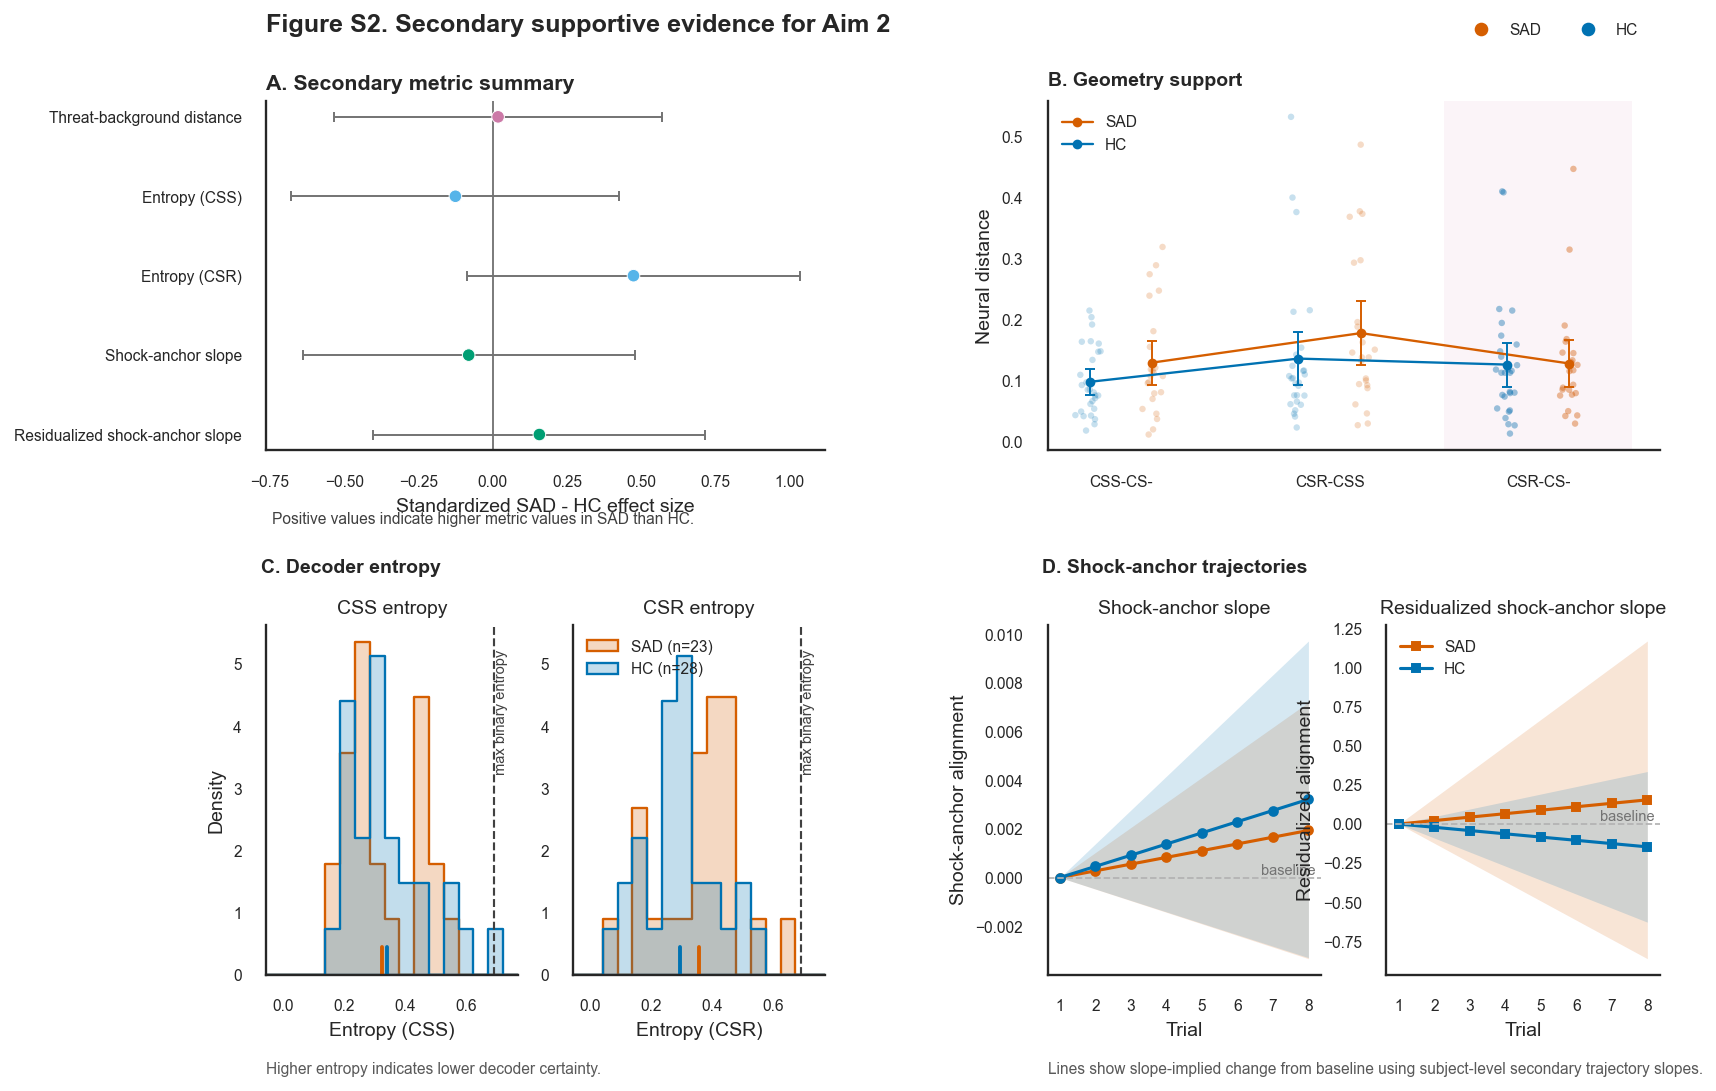

In [15]:
display(Markdown('**Figure S2 / Table S2 Aim 2 supportive evidence:** secondary views reuse the five primary neural metrics; component geometry panels remain diagnostic only.'))

AIM2_SECONDARY_OUTPUT_METRICS = SHARED_AIM2_TO_AIM5_METRICS.copy()
AIM2_SECONDARY_OUTPUT_DOMAINS = {
    metric: PRIMARY_NEURAL_METRIC_FAMILIES.get(metric, 'Primary')
    for metric in AIM2_SECONDARY_OUTPUT_METRICS
}
AIM2_SECONDARY_OUTPUT_LABELS = {
    metric: PRIMARY_NEURAL_METRIC_LABELS.get(metric, metric.replace('_', ' '))
    for metric in AIM2_SECONDARY_OUTPUT_METRICS
}
AIM2_SECONDARY_COLUMN_ALIASES = {
    metric: PRIMARY_NEURAL_METRIC_COLUMN_CANDIDATES.get(metric, [metric])
    for metric in AIM2_SECONDARY_OUTPUT_METRICS
}
AIM2_SECONDARY_GEOMETRY_PROFILE_METRICS = [
    'Neural_Dist_Safety_Background',
    'Neural_Dist_Threat_Safety',
    'Neural_Dist_Threat_Background',
]
AIM2_SECONDARY_GEOMETRY_PROFILE_LABELS = {
    'Neural_Dist_Safety_Background': 'CSS-CS-',
    'Neural_Dist_Threat_Safety': 'CSR-CSS',
    'Neural_Dist_Threat_Background': 'CSR-CS-',
}
AIM2_SECONDARY_GEOMETRY_COLUMN_ALIASES = {
    'Neural_Dist_Safety_Background': ['Neural_Dist_Safety_Background', 'Neural_Dist_Safety_Backgr', 'Neural_Dist_CSS_Background', 'Neural_Dist_CSS_CSminus'],
    'Neural_Dist_Threat_Safety': ['Neural_Dist_Threat_Safety', 'Neural_Dist_CSR_CSS', 'Neural_Dist_Threat_CSS'],
    'Neural_Dist_Threat_Background': AIM2_SECONDARY_COLUMN_ALIASES['Neural_Dist_Threat_Background'],
}
AIM2_SECONDARY_DOMAIN_ORDER = {'Geometry': 0, 'Certainty': 1, 'Trajectory': 2}
AIM2_SECONDARY_SOURCE_COLUMNS = {}
AIM2_GEOMETRY_COLORS = {
    'CS-': OKABE['gray'],
    'CSS': OKABE['green'],
    'CSR': OKABE['purple'],
}


if 'first_existing_column' not in globals():
    def first_existing_column(df, candidates):
        return next((col for col in candidates if col in df.columns), None)


def normalize_aim2_group(value):
    text = str(value).strip().upper()
    if text in {'SAD', 'SOCIAL ANXIETY', 'SOCIAL_ANXIETY', 'PATIENT', 'PATIENTS'}:
        return 'SAD'
    if text in {'HC', 'CONTROL', 'CONTROLS', 'HEALTHY CONTROL', 'HEALTHY_CONTROLS'}:
        return 'HC'
    return str(value).strip()


def aim2_secondary_base_subjects(subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    df = subject_source_df if subject_source_df is not None else metrics_df
    if df is None or df.empty:
        return pd.DataFrame()
    sub = df.copy()
    if 'FeatureSpace' in sub.columns:
        sub = sub[sub['FeatureSpace'].astype(str).eq(feature_space)]
    if drug and 'Drug' in sub.columns:
        sub = sub[sub['Drug'].astype(str).eq(drug)]
    subject_col = first_existing_column(sub, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    group_col = first_existing_column(sub, ['group', 'Group'])
    if subject_col is None or group_col is None:
        return pd.DataFrame()
    out = pd.DataFrame({'subject_id': sub[subject_col].astype(str), 'group': sub[group_col].map(normalize_aim2_group)}, index=sub.index)
    out = out[out['group'].isin(['SAD', 'HC'])].copy()
    source_columns = {}
    metric_aliases = {**AIM2_SECONDARY_GEOMETRY_COLUMN_ALIASES, **AIM2_SECONDARY_COLUMN_ALIASES}
    for canonical, aliases in metric_aliases.items():
        source = first_existing_column(sub, aliases)
        if source is not None:
            out[canonical] = pd.to_numeric(sub.loc[out.index, source], errors='coerce')
            if canonical in AIM2_SECONDARY_OUTPUT_METRICS:
                source_columns[canonical] = source
    AIM2_SECONDARY_SOURCE_COLUMNS.clear()
    AIM2_SECONDARY_SOURCE_COLUMNS.update(source_columns)
    return out.reset_index(drop=True)


def add_shock_anchor_secondary_metrics(out):
    if out is None or out.empty:
        out = pd.DataFrame(columns=['subject_id', 'group'])
    result = out.copy()
    if 'shock_anchor_trial_slope_df' in globals() and isinstance(shock_anchor_trial_slope_df, pd.DataFrame) and not shock_anchor_trial_slope_df.empty:
        source = shock_anchor_trial_slope_df.copy()
        subject_col = first_existing_column(source, ['subject_id', 'Subject', 'sub_ID', 'sub'])
        group_col = first_existing_column(source, ['group', 'Group'])
        slope_col = first_existing_column(source, AIM2_SECONDARY_COLUMN_ALIASES['Residualized_Shock_Anchor_Trajectory_Slope'])
        if subject_col is not None and group_col is not None and slope_col is not None:
            shock = pd.DataFrame({
                'subject_id': source[subject_col].astype(str),
                'group': source[group_col].map(normalize_aim2_group),
                'Residualized_Shock_Anchor_Trajectory_Slope': pd.to_numeric(source[slope_col], errors='coerce'),
            })
            shock = shock[shock['group'].isin(['SAD', 'HC'])].dropna(subset=['Residualized_Shock_Anchor_Trajectory_Slope'])
            if not shock.empty:
                AIM2_SECONDARY_SOURCE_COLUMNS['Residualized_Shock_Anchor_Trajectory_Slope'] = slope_col
                result = result.merge(shock, on=['subject_id', 'group'], how='outer', suffixes=('', '_shock'))
                if 'Residualized_Shock_Anchor_Trajectory_Slope_shock' in result.columns:
                    result['Residualized_Shock_Anchor_Trajectory_Slope'] = result['Residualized_Shock_Anchor_Trajectory_Slope'].combine_first(result['Residualized_Shock_Anchor_Trajectory_Slope_shock']) if 'Residualized_Shock_Anchor_Trajectory_Slope' in result.columns else result['Residualized_Shock_Anchor_Trajectory_Slope_shock']
                    result = result.drop(columns=['Residualized_Shock_Anchor_Trajectory_Slope_shock'])
    if 'shock_anchor_df' in globals() and isinstance(shock_anchor_df, pd.DataFrame) and not shock_anchor_df.empty:
        source = shock_anchor_df.copy()
        subject_col = first_existing_column(source, ['subject_id', 'Subject', 'sub_ID', 'sub'])
        group_col = first_existing_column(source, ['group', 'Group'])
        value_col = first_existing_column(source, AIM2_SECONDARY_COLUMN_ALIASES['Shock_Anchor_Trajectory_Slope'])
        if subject_col is not None and group_col is not None and value_col is not None:
            shock = pd.DataFrame({
                'subject_id': source[subject_col].astype(str),
                'group': source[group_col].map(normalize_aim2_group),
                'Shock_Anchor_Trajectory_Slope': pd.to_numeric(source[value_col], errors='coerce'),
            })
            shock = shock[shock['group'].isin(['SAD', 'HC'])].dropna(subset=['Shock_Anchor_Trajectory_Slope'])
            if not shock.empty:
                AIM2_SECONDARY_SOURCE_COLUMNS['Shock_Anchor_Trajectory_Slope'] = value_col
                result = result.merge(shock, on=['subject_id', 'group'], how='outer', suffixes=('', '_shock'))
                if 'Shock_Anchor_Trajectory_Slope_shock' in result.columns:
                    result['Shock_Anchor_Trajectory_Slope'] = result['Shock_Anchor_Trajectory_Slope'].combine_first(result['Shock_Anchor_Trajectory_Slope_shock']) if 'Shock_Anchor_Trajectory_Slope' in result.columns else result['Shock_Anchor_Trajectory_Slope_shock']
                    result = result.drop(columns=['Shock_Anchor_Trajectory_Slope_shock'])
    return result


def aim2_secondary_subject_table(subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    out = aim2_secondary_base_subjects(subject_source_df=subject_source_df, feature_space=feature_space, drug=drug)
    out = add_shock_anchor_secondary_metrics(out)
    for metric in AIM2_SECONDARY_OUTPUT_METRICS + AIM2_SECONDARY_GEOMETRY_PROFILE_METRICS:
        if metric in out.columns:
            out[metric] = pd.to_numeric(out[metric], errors='coerce')
    if 'group' in out.columns:
        out = out[out['group'].isin(['SAD', 'HC'])].copy()
    return out


def pooled_cohens_d_and_ci(sad, hc):
    sad = pd.to_numeric(pd.Series(sad), errors='coerce').dropna().to_numpy(dtype=float)
    hc = pd.to_numeric(pd.Series(hc), errors='coerce').dropna().to_numpy(dtype=float)
    if sad.size < 2 or hc.size < 2:
        return np.nan, np.nan, np.nan
    n_sad = sad.size
    n_hc = hc.size
    var_sad = np.nanvar(sad, ddof=1)
    var_hc = np.nanvar(hc, ddof=1)
    pooled_sd = np.sqrt(((n_sad - 1) * var_sad + (n_hc - 1) * var_hc) / (n_sad + n_hc - 2))
    if not np.isfinite(pooled_sd) or pooled_sd == 0:
        return np.nan, np.nan, np.nan
    d_value = (np.nanmean(sad) - np.nanmean(hc)) / pooled_sd
    correction = 1 - (3 / (4 * (n_sad + n_hc) - 9)) if (n_sad + n_hc) > 2 else 1
    g_value = d_value * correction
    se_g = np.sqrt((n_sad + n_hc) / (n_sad * n_hc) + (g_value ** 2) / (2 * (n_sad + n_hc - 2)))
    return g_value, g_value - 1.96 * se_g, g_value + 1.96 * se_g


def aim2_secondary_interpretation(mean_diff, metric, q_value):
    if not np.isfinite(mean_diff) or abs(mean_diff) < 1e-8:
        return 'Minimal group difference'
    direction = 'Higher in SAD' if mean_diff > 0 else 'Lower in SAD'
    if metric in {'Neural_Decoder_Entropy_CSS', 'Neural_Decoder_Entropy_CSR'}:
        return f'{direction}; directionally consistent with altered certainty'
    if 'Shock_Anchor' in metric:
        return f'{direction}; supportive trajectory difference'
    return direction


def build_aim2_secondary_stats(subject_df):
    rows = []
    try:
        from scipy import stats
    except Exception:
        stats = None
    for metric in AIM2_SECONDARY_OUTPUT_METRICS:
        if metric not in subject_df.columns:
            continue
        sad = pd.to_numeric(subject_df.loc[subject_df['group'].eq('SAD'), metric], errors='coerce').dropna()
        hc = pd.to_numeric(subject_df.loc[subject_df['group'].eq('HC'), metric], errors='coerce').dropna()
        if sad.size < 2 or hc.size < 2:
            continue
        if stats is not None:
            test = stats.ttest_ind(sad.to_numpy(dtype=float), hc.to_numpy(dtype=float), equal_var=False, nan_policy='omit')
            t_value = float(test.statistic) if np.isfinite(test.statistic) else np.nan
            p_value = float(test.pvalue) if np.isfinite(test.pvalue) else np.nan
        else:
            t_value = np.nan
            p_value = np.nan
        effect, ci_low, ci_high = pooled_cohens_d_and_ci(sad, hc)
        rows.append({
            'Metric': AIM2_SECONDARY_OUTPUT_LABELS[metric],
            'Raw_metric': metric,
            'Source_column': AIM2_SECONDARY_SOURCE_COLUMNS.get(metric, metric),
            'Domain': AIM2_SECONDARY_OUTPUT_DOMAINS[metric],
            'N_SAD': int(sad.size),
            'N_HC': int(hc.size),
            'SAD_mean': float(sad.mean()),
            'SAD_SD': float(sad.std(ddof=1)),
            'HC_mean': float(hc.mean()),
            'HC_SD': float(hc.std(ddof=1)),
            'Mean_difference_SAD_minus_HC': float(sad.mean() - hc.mean()),
            'Effect_size': effect,
            'CI_lower': ci_low,
            'CI_upper': ci_high,
            'Test_statistic': t_value,
            'p_value': p_value,
        })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out['q_value'] = bh_fdr(out['p_value']).values
    out['Interpretation'] = [aim2_secondary_interpretation(row['Mean_difference_SAD_minus_HC'], row['Raw_metric'], row['q_value']) for _, row in out.iterrows()]
    out['_domain_order'] = out['Domain'].map(AIM2_SECONDARY_DOMAIN_ORDER)
    out['_metric_order'] = out['Raw_metric'].map({metric: i for i, metric in enumerate(AIM2_SECONDARY_OUTPUT_METRICS)})
    out = out.sort_values(['_domain_order', '_metric_order']).drop(columns=['_domain_order', '_metric_order']).reset_index(drop=True)
    return out


def format_mean_sd(mean, sd):
    return f'{mean:.3f} +/- {sd:.3f}' if np.isfinite(mean) and np.isfinite(sd) else 'NA'


def format_p(value):
    if not np.isfinite(value):
        return 'NA'
    return '<.001' if value < 0.001 else f'{value:.3f}'


def compact_aim2_secondary_table(stats_df):
    if stats_df is None or stats_df.empty:
        return pd.DataFrame()
    out = stats_df.copy()
    return pd.DataFrame({
        'Metric': out['Metric'],
        'Domain': out['Domain'],
        'SAD mean +/- SD': [format_mean_sd(m, s) for m, s in zip(out['SAD_mean'], out['SAD_SD'])],
        'HC mean +/- SD': [format_mean_sd(m, s) for m, s in zip(out['HC_mean'], out['HC_SD'])],
        'Effect': [f'{x:.2f}' if np.isfinite(x) else 'NA' for x in out['Effect_size']],
        '95% CI': [f'[{lo:.2f}, {hi:.2f}]' if np.isfinite(lo) and np.isfinite(hi) else 'NA' for lo, hi in zip(out['CI_lower'], out['CI_upper'])],
        'p': [format_p(x) for x in out['p_value']],
        'q': [format_p(x) for x in out['q_value']],
    })


def entropy_axis_limits(subject_df, metrics):
    values = []
    for metric in metrics:
        if metric in subject_df.columns:
            values.extend(pd.to_numeric(subject_df[metric], errors='coerce').dropna().tolist())
    if not values:
        return 0.0, 1.0
    upper = max(np.nanmax(values), np.log(2))
    lower = min(0.0, np.nanmin(values))
    pad = max((upper - lower) * 0.08, 0.02)
    return lower - pad, upper + pad


def plot_secondary_entropy_histograms(axes, subject_df):
    specs = [
        ('Neural_Decoder_Entropy_CSS', 'CSS entropy', 'Entropy (CSS)'),
        ('Neural_Decoder_Entropy_CSR', 'CSR entropy', 'Entropy (CSR)'),
    ]
    x_low, x_high = entropy_axis_limits(subject_df, [metric for metric, _, _ in specs])
    bins = np.linspace(x_low, x_high, 18)
    any_plotted = False
    for ax, (metric, title, xlabel) in zip(axes, specs):
        if metric not in subject_df.columns or not subject_df[metric].notna().any():
            ax.text(0.5, 0.5, 'Metric unavailable', transform=ax.transAxes, ha='center', va='center', fontsize=9)
            ax.set_axis_off()
            continue
        plot_df = subject_df[['group', metric]].dropna().copy()
        plot_df[metric] = pd.to_numeric(plot_df[metric], errors='coerce')
        for group in ['SAD', 'HC']:
            sub = plot_df[plot_df['group'].eq(group)]
            if sub.empty:
                continue
            any_plotted = True
            sns.histplot(
                data=sub,
                x=metric,
                bins=bins,
                stat='density',
                element='step',
                fill=True,
                alpha=0.24,
                color=GROUP_COLORS[group],
                linewidth=1.2,
                ax=ax,
                label=f'{group} (n={len(sub)})',
            )
            mean_value = sub[metric].mean()
            ax.plot([mean_value, mean_value], [0, ax.get_ylim()[1] * 0.08], color=GROUP_COLORS[group], linewidth=2.0, solid_capstyle='round')
        if x_low <= np.log(2) <= x_high:
            ax.axvline(np.log(2), color='0.25', linestyle='--', linewidth=1.1)
            ax.text(np.log(2), 0.93, 'max binary entropy', transform=ax.get_xaxis_transform(), rotation=90, va='top', ha='left', fontsize=7.5, color='0.25')
        ax.set_xlim(x_low, x_high)
        ax.set_title(title, fontsize=10, fontweight='normal')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density' if metric == 'Neural_Decoder_Entropy_CSS' else '')
        sns.despine(ax=ax)
    axes[0].text(-0.02, 1.14, 'C. Decoder entropy', transform=axes[0].transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold')
    axes[0].text(0.00, -0.25, 'Higher entropy indicates lower decoder certainty.', transform=axes[0].transAxes, ha='left', va='top', fontsize=8, color='0.35')
    if any_plotted:
        axes[-1].legend(frameon=False, loc='upper left')


def summarize_slope_implied_ci(subject_df, metric, n_trials=8):
    if metric not in subject_df.columns:
        return pd.DataFrame()
    rows = []
    for group in ['SAD', 'HC']:
        slopes = pd.to_numeric(subject_df.loc[subject_df['group'].eq(group), metric], errors='coerce').dropna().to_numpy(dtype=float)
        if slopes.size == 0:
            continue
        for trial in range(1, n_trials + 1):
            values = slopes * (trial - 1)
            mean = float(np.nanmean(values))
            sem = float(np.nanstd(values, ddof=1) / np.sqrt(values.size)) if values.size > 1 else 0.0
            rows.append({'group': group, 'trial': trial, 'mean': mean, 'ci_low': mean - 1.96 * sem, 'ci_high': mean + 1.96 * sem, 'n_subjects': int(values.size)})
    return pd.DataFrame(rows)


def plot_secondary_shock_anchor_trajectories(axes, subject_df):
    specs = [
        ('Shock_Anchor_Trajectory_Slope', 'Shock-anchor slope', 'Shock-anchor alignment', 'o', OKABE['green']),
        ('Residualized_Shock_Anchor_Trajectory_Slope', 'Residualized shock-anchor slope', 'Residualized alignment', 's', OKABE['purple']),
    ]
    any_plotted = False
    for ax, (metric, title, ylabel, marker, reference_color) in zip(axes, specs):
        summary = summarize_slope_implied_ci(subject_df, metric)
        if summary.empty:
            ax.text(0.5, 0.5, 'Metric unavailable', transform=ax.transAxes, ha='center', va='center', fontsize=9)
            ax.set_axis_off()
            continue
        any_plotted = True
        for group in ['SAD', 'HC']:
            sub = summary[summary['group'].eq(group)]
            if sub.empty:
                continue
            x = sub['trial'].to_numpy(dtype=float)
            mean = sub['mean'].to_numpy(dtype=float)
            ci_low = sub['ci_low'].to_numpy(dtype=float)
            ci_high = sub['ci_high'].to_numpy(dtype=float)
            ax.plot(x, mean, color=GROUP_COLORS[group], marker=marker, markersize=4.5, linewidth=1.6, label=group)
            ax.fill_between(x, ci_low, ci_high, color=GROUP_COLORS[group], alpha=0.16, linewidth=0)
        ax.axhline(0, color='0.70', linestyle='--', linewidth=0.9)
        ax.text(0.98, 0, 'baseline', transform=ax.get_yaxis_transform(), ha='right', va='bottom', fontsize=7.5, color='0.45')
        ax.set_title(title, fontsize=10, fontweight='normal')
        ax.set_xlabel('Trial')
        ax.set_ylabel(ylabel)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        sns.despine(ax=ax)
    axes[0].text(-0.02, 1.14, 'D. Shock-anchor trajectories', transform=axes[0].transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold')
    axes[0].text(0.00, -0.25, 'Lines show slope-implied change from baseline using subject-level secondary trajectory slopes.', transform=axes[0].transAxes, ha='left', va='top', fontsize=8, color='0.35')
    if any_plotted:
        axes[-1].legend(frameon=False, loc='upper left')



def plot_secondary_geometry_triangle(ax):
    coords = {'CS-': (0.15, 0.18), 'CSS': (0.75, 0.22), 'CSR': (0.46, 0.80)}
    for condition, (x, y) in coords.items():
        ax.scatter(x, y, s=72, color=AIM2_GEOMETRY_COLORS.get(condition, '0.35'), edgecolor='black', linewidth=0.6, zorder=3)
        ax.text(x, y + 0.075, condition, ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xlim(0, 0.90)
    ax.set_ylim(0, 0.95)
    ax.set_aspect('equal', adjustable='box')
    ax.set_axis_off()


def plot_secondary_geometry_profile(ax, subject_df):
    available = [metric for metric in AIM2_SECONDARY_GEOMETRY_PROFILE_METRICS if metric in subject_df.columns and subject_df[metric].notna().any()]
    if not available:
        ax.text(0.5, 0.5, 'No available geometry distances', transform=ax.transAxes, ha='center', va='center', fontsize=9)
        ax.set_axis_off()
        return
    rng = np.random.default_rng(20260617)
    x_positions = np.arange(len(available), dtype=float)
    offsets = {'HC': -0.15, 'SAD': 0.15}
    for group in ['SAD', 'HC']:
        means = []
        lows = []
        highs = []
        xs = []
        for x, metric in zip(x_positions, available):
            values = pd.to_numeric(subject_df.loc[subject_df['group'].eq(group), metric], errors='coerce').dropna().to_numpy(dtype=float)
            if values.size == 0:
                means.append(np.nan)
                lows.append(np.nan)
                highs.append(np.nan)
                xs.append(x + offsets[group])
                continue
            jitter = rng.normal(0, 0.025, size=values.size)
            alpha = 0.42 if metric == 'Neural_Dist_Threat_Background' else 0.22
            ax.scatter(np.full(values.size, x + offsets[group]) + jitter, values, s=11, alpha=alpha, color=GROUP_COLORS[group], edgecolors='none')
            mean = float(np.nanmean(values))
            sem = float(np.nanstd(values, ddof=1) / np.sqrt(values.size)) if values.size > 1 else 0.0
            means.append(mean)
            lows.append(mean - 1.96 * sem)
            highs.append(mean + 1.96 * sem)
            xs.append(x + offsets[group])
        ax.plot(xs, means, color=GROUP_COLORS[group], linewidth=1.2, marker='o', markersize=4.0, label=group)
        ax.errorbar(xs, means, yerr=[np.asarray(means) - np.asarray(lows), np.asarray(highs) - np.asarray(means)], fmt='none', color=GROUP_COLORS[group], capsize=2.5, linewidth=1.0)
    if 'Neural_Dist_Threat_Background' in available:
        idx = available.index('Neural_Dist_Threat_Background')
        ax.axvspan(idx - 0.45, idx + 0.45, color=OKABE['purple'], alpha=0.08, linewidth=0)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([AIM2_SECONDARY_GEOMETRY_PROFILE_LABELS[metric] for metric in available], rotation=0)
    ax.set_ylabel('Neural distance')
    ax.legend(frameon=False, loc='best')
    sns.despine(ax=ax)


def plot_aim2_secondary_support(subject_df, stats_df, filename='Figure_S2_secondary_support'):
    if stats_df is None or stats_df.empty:
        print('No Figure S2 secondary support plot available because no secondary metrics were estimable.')
        return None
    fig = plt.figure(figsize=(11.0, 7.8), facecolor='white')
    gs = fig.add_gridspec(2, 2, width_ratios=[1.05, 1.15], height_ratios=[1.0, 1.0], left=0.08, right=0.985, top=0.90, bottom=0.10, wspace=0.38, hspace=0.50)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b2 = fig.add_subplot(gs[0, 1])
    panel_c = gs[1, 0].subgridspec(1, 2, wspace=0.22)
    ax_c1 = fig.add_subplot(panel_c[0, 0])
    ax_c2 = fig.add_subplot(panel_c[0, 1], sharey=ax_c1)
    panel_d = gs[1, 1].subgridspec(1, 2, wspace=0.24)
    ax_d1 = fig.add_subplot(panel_d[0, 0])
    ax_d2 = fig.add_subplot(panel_d[0, 1])

    forest = stats_df.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(forest))
    colors = forest['Domain'].map({'Geometry': OKABE['purple'], 'Certainty': OKABE['sky'], 'Trajectory': OKABE['green']}).fillna(OKABE['gray'])
    ax_a.axvline(0, color='0.35', linewidth=0.8)
    ax_a.errorbar(forest['Effect_size'], y, xerr=[forest['Effect_size'] - forest['CI_lower'], forest['CI_upper'] - forest['Effect_size']], fmt='none', ecolor='0.45', elinewidth=1.0, capsize=2.5)
    ax_a.scatter(forest['Effect_size'], y, s=42, c=colors, zorder=3, edgecolor='white', linewidth=0.5)
    ax_a.set_yticks(y)
    ax_a.set_yticklabels(forest['Metric'])
    ax_a.set_xlabel('Standardized SAD - HC effect size')
    ax_a.set_title('A. Secondary metric summary', loc='left', fontweight='bold')
    ax_a.text(0.01, -0.21, 'Positive values indicate higher metric values in SAD than HC.', transform=ax_a.transAxes, fontsize=8, color='0.25')
    sns.despine(ax=ax_a)

    plot_secondary_geometry_profile(ax_b2, subject_df)
    ax_b2.set_title('B. Geometry support', loc='left', fontweight='bold', fontsize=10, pad=8)

    plot_secondary_entropy_histograms([ax_c1, ax_c2], subject_df)
    plot_secondary_shock_anchor_trajectories([ax_d1, ax_d2], subject_df)


    handles = [plt.Line2D([0], [0], marker='o', linestyle='none', color=GROUP_COLORS[group], label=group, markersize=6) for group in ['SAD', 'HC']]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.985), frameon=False, ncol=2)
    fig.suptitle('Figure S2. Secondary supportive evidence for Aim 2', x=0.08, ha='left', fontsize=13, fontweight='bold')
    png = FIG_DIR / f'{filename}.png'
    svg = FIG_DIR / f'{filename}.svg'
    fig.savefig(png, bbox_inches='tight', dpi=300, facecolor='white')
    fig.savefig(svg, bbox_inches='tight', facecolor='white')
    print(f'Saved {png}')
    print(f'Saved {svg}')
    return fig


aim2_secondary_subject_df = aim2_secondary_subject_table(feature_space='FearNetwork', drug='Placebo')
aim2_secondary_found = [metric for metric in AIM2_SECONDARY_OUTPUT_METRICS if metric in aim2_secondary_subject_df.columns and aim2_secondary_subject_df[metric].notna().any()]
aim2_secondary_missing = [metric for metric in AIM2_SECONDARY_OUTPUT_METRICS if metric not in aim2_secondary_found]
aim2_secondary_stats_df = build_aim2_secondary_stats(aim2_secondary_subject_df)
aim2_secondary_compact_stats_df = compact_aim2_secondary_table(aim2_secondary_stats_df)

if aim2_secondary_stats_df.empty:
    print('No Aim 2 secondary metrics were estimable for Figure S2/Table S2.')
else:
    table_csv = STATS_DIR / 'Table_S2_secondary_support.csv'
    table_xlsx = STATS_DIR / 'Table_S2_secondary_support.xlsx'
    aim2_secondary_stats_df.to_csv(table_csv, index=False)
    try:
        aim2_secondary_stats_df.to_excel(table_xlsx, index=False)
        print(f'Saved {table_xlsx}')
    except Exception as exc:
        print(f'Could not write {table_xlsx}: {exc}')
    print(f'Saved {table_csv}')
    print(f'Metrics found: {aim2_secondary_found}')
    print(f'Metrics missing: {aim2_secondary_missing}')
    n_sad = int(aim2_secondary_subject_df.loc[aim2_secondary_subject_df["group"].eq("SAD"), "subject_id"].nunique()) if {'group', 'subject_id'}.issubset(aim2_secondary_subject_df.columns) else 0
    n_hc = int(aim2_secondary_subject_df.loc[aim2_secondary_subject_df["group"].eq("HC"), "subject_id"].nunique()) if {'group', 'subject_id'}.issubset(aim2_secondary_subject_df.columns) else 0
    print(f'Sample sizes in subject table: SAD={n_sad}; HC={n_hc}')
    print(f'Figure outputs: {FIG_DIR / "Figure_S2_secondary_support.png"}; {FIG_DIR / "Figure_S2_secondary_support.svg"}')
    print(f'Table outputs: {table_csv}; {table_xlsx}')

display(Markdown('**Table S2. Secondary supportive evidence for Aim 2**'))
display(aim2_secondary_stats_df)
show_figure_once(plot_aim2_secondary_support(aim2_secondary_subject_df, aim2_secondary_stats_df))


### Aim 2 sensitivity visualization

Controlled by `task_Visualization-Aim2-sensitivity.md`. This subsection keeps only the requested sensitivity heatmap across masks / feature spaces and SCR-defined participant subgroups, plus the matching sensitivity statistics table. Sensitivity outputs remain separate from primary and secondary/supportive outputs.


**Figure S2 uses observed data from `aim2_sensitivity_results.csv`.**

,metric_family,metric_name,sensitivity_type,specification,n_sad,n_hc,effect_size,ci_low,ci_high,p_value,q_value,direction,robustness_label
10,Geometry,Neural_Dist_Safety_Background,Mask,MemoryFearNetwork,NaN,NaN,0.009215,-0.018255,0.036685,0.503081,0.680146,Near zero,Weak / inconsistent
13,Geometry,Neural_Dist_Safety_Background,Subgroup,SCR_Physiological_Responder,NaN,NaN,0.028225,-0.010018,0.066468,0.144701,0.321009,Near zero,Weak / inconsistent
14,Geometry,Neural_Dist_Safety_Background,Subgroup,SCR_Simple_Acquisition_Differential_Learner,NaN,NaN,0.018829,-0.029975,0.067634,0.438758,0.652255,Near zero,Weak / inconsistent
11,Geometry,Neural_Dist_Safety_Background,Subgroup,SCR_Habituation_Adjusted_Learner,NaN,NaN,0.021168,-0.042361,0.084697,0.499461,0.908981,Near zero,Weak / inconsistent
12,Geometry,Neural_Dist_Safety_Background,Subgroup,SCR_Late_Phase_Sensitivity_Learner,NaN,NaN,0.052210,-0.039766,0.144185,0.247495,0.947873,Near zero,Weak / inconsistent
15,Geometry,Neural_Dist_Threat_Safety,Mask,MemoryFearNetwork,NaN,NaN,-0.017968,-0.064033,0.028097,0.436569,0.680146,Near zero,Weak / inconsistent
18,Geometry,Neural_Dist_Threat_Safety,Subgroup,SCR_Physiological_Responder,NaN,NaN,0.023638,-0.024301,0.071576,0.327153,0.490729,Near zero,Weak / inconsistent
19,Geometry,Neural_Dist_Threat_Safety,Subgroup,SCR_Simple_Acquisition_Differential_Learner,NaN,NaN,0.019758,-0.045627,0.085142,0.543545,0.652255,Near zero,Weak / inconsistent
16,Geometry,Neural_Dist_Threat_Safety,Subgroup,SCR_Habituation_Adjusted_Learner,NaN,NaN,0.004550,-0.076472,0.085573,0.908981,0.908981,Near zero,Weak / inconsistent
17,Geometry,Neural_Dist_Threat_Safety,Subgroup,SCR_Late_Phase_Sensitivity_Learner,NaN,NaN,-0.015437,-0.098759,0.067884,0.700729,0.947873,Near zero,Weak / inconsistent


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS2_Aim2_Sensitivity_RobustnessHeatmap.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS2_Aim2_Sensitivity_RobustnessHeatmap.svg
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/TableS2_Aim2_Sensitivity_Stats.csv


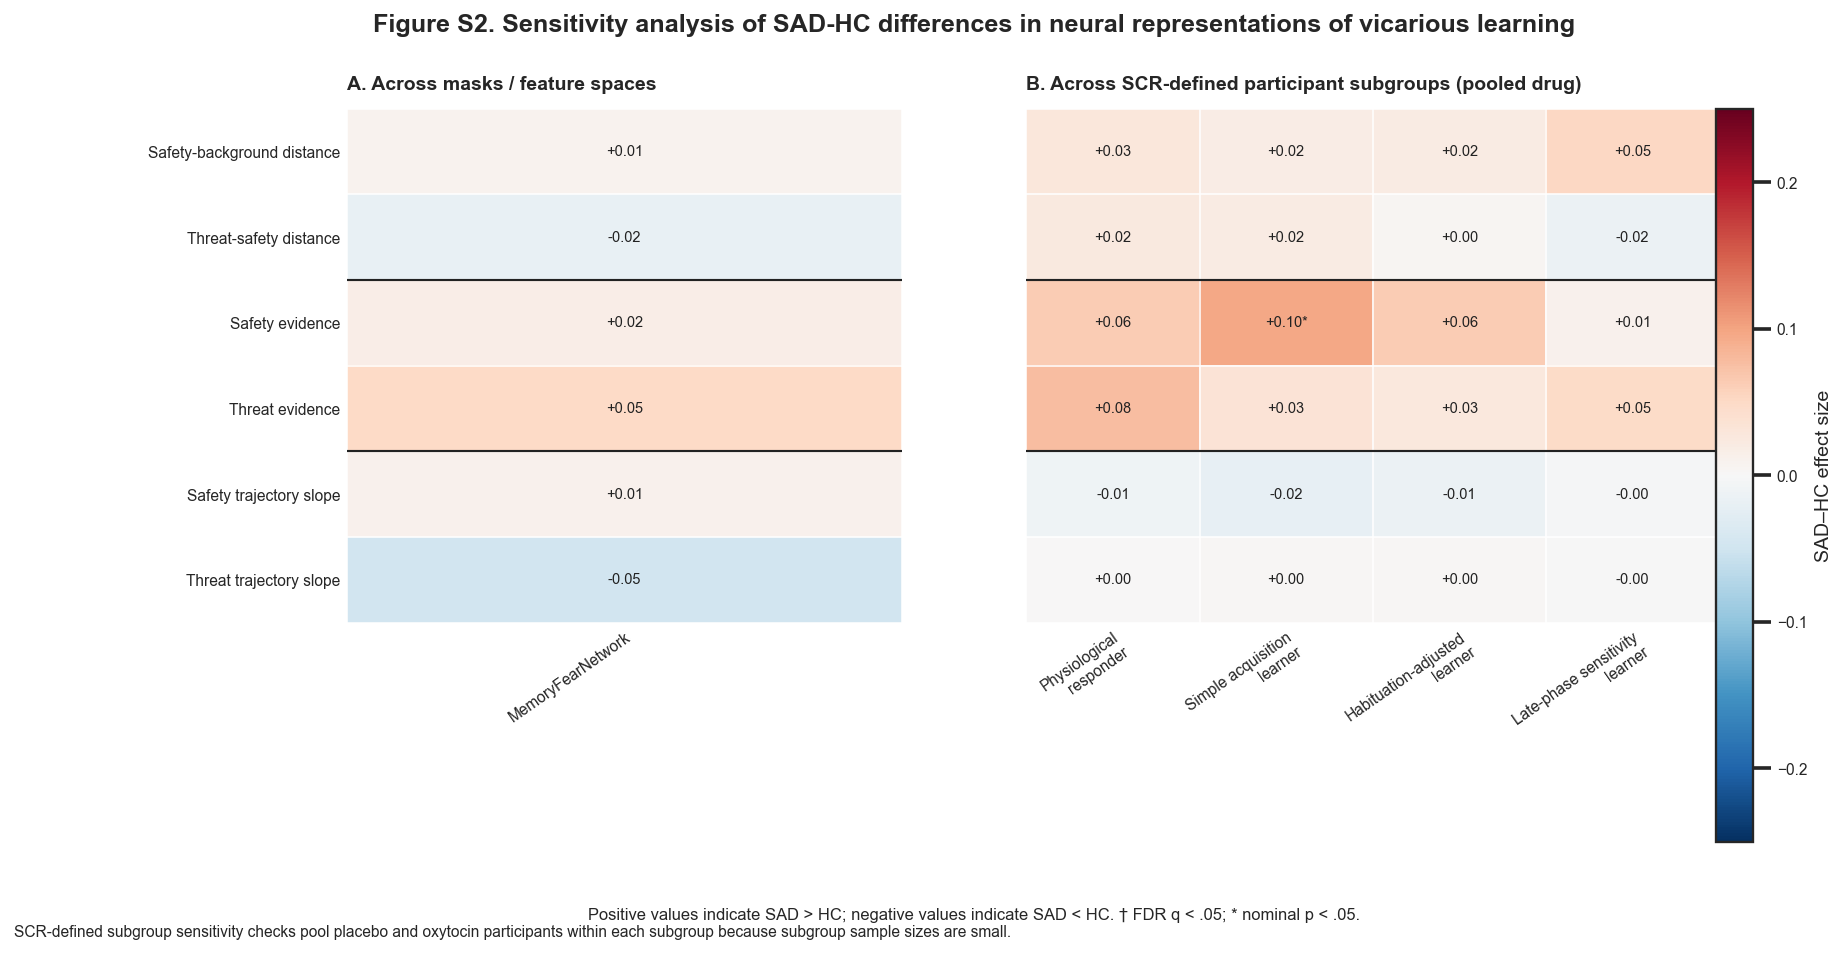

In [16]:

from matplotlib.colors import TwoSlopeNorm

AIM2_SENSITIVITY_INPUT = PATHS.get('sensitivity_all', STATS_DIR / 'sensitivity_models_all.csv') if 'PATHS' in globals() else Path('outputs/mvpa_l2/stats/sensitivity_models_all.csv')
AIM2_SENSITIVITY_FIGURE_PNG = FIG_DIR / 'FigureS2_Aim2_Sensitivity_RobustnessHeatmap.png' if 'FIG_DIR' in globals() else Path('FigureS2_Aim2_Sensitivity_RobustnessHeatmap.png')
AIM2_SENSITIVITY_FIGURE_SVG = FIG_DIR / 'FigureS2_Aim2_Sensitivity_RobustnessHeatmap.svg' if 'FIG_DIR' in globals() else Path('FigureS2_Aim2_Sensitivity_RobustnessHeatmap.svg')
AIM2_SENSITIVITY_TABLE = STATS_DIR / 'TableS2_Aim2_Sensitivity_Stats.csv' if 'STATS_DIR' in globals() else Path('TableS2_Aim2_Sensitivity_Stats.csv')

AIM2_SENSITIVITY_MASK_ORDER = ['FearNetwork', 'MemoryFearNetwork', 'Schaefer', 'Tian', 'WholeBrain']
AIM2_SENSITIVITY_SUBGROUP_ORDER = [
    'AllPlacebo',
    'SCR_Physiological_Responder',
    'SCR_Simple_Acquisition_Differential_Learner',
    'SCR_Habituation_Adjusted_Learner',
    'SCR_Late_Phase_Sensitivity_Learner',
]
AIM2_SENSITIVITY_METRIC_ORDER = SHARED_AIM2_TO_AIM5_METRICS.copy()
AIM2_SENSITIVITY_METRIC_FAMILY = {
    metric: PRIMARY_NEURAL_METRIC_FAMILIES.get(metric, 'Primary')
    for metric in AIM2_SENSITIVITY_METRIC_ORDER
}
AIM2_SENSITIVITY_FAMILY_ORDER = ['Geometry', 'Certainty', 'Trajectory']
AIM2_SENSITIVITY_METRIC_LABELS = {
    metric: PRIMARY_NEURAL_METRIC_LABELS.get(metric, metric.replace('_', ' ')).replace('\n', ' ')
    for metric in AIM2_SENSITIVITY_METRIC_ORDER
}
AIM2_SENSITIVITY_REQUIRED_COLUMNS = [
    'metric_family', 'metric_name', 'sensitivity_type', 'specification', 'n_sad', 'n_hc',
    'effect_size', 'ci_low', 'ci_high', 'p_value', 'q_value',
]
AIM2_SENSITIVITY_SPEC_LABELS = {
    'FearNetwork': 'FearNetwork',
    'MemoryFearNetwork': 'MemoryFearNetwork',
    'Schaefer': 'Schaefer',
    'Tian': 'Tian',
    'WholeBrain': 'WholeBrain',
    'AllPlacebo': 'All placebo',
    'SCR_Physiological_Responder': 'Physiological\nresponder',
    'SCR_Simple_Acquisition_Differential_Learner': 'Simple acquisition\nlearner',
    'SCR_Habituation_Adjusted_Learner': 'Habituation-adjusted\nlearner',
    'SCR_Late_Phase_Sensitivity_Learner': 'Late-phase sensitivity\nlearner',
}


def _ordered_existing(values, preferred):
    values = [str(value) for value in values if pd.notna(value)]
    ordered = [value for value in preferred if value in values]
    ordered.extend(sorted(value for value in values if value not in set(ordered)))
    return ordered


def _metric_family(metric_name):
    return AIM2_SENSITIVITY_METRIC_FAMILY.get(str(metric_name), 'Secondary')


def _prepare_row_order(df):
    observed = set(df['metric_name'].dropna().astype(str)) if 'metric_name' in df.columns else set()
    ordered = [metric for metric in AIM2_SENSITIVITY_METRIC_ORDER if metric in observed]
    extras = sorted(observed.difference(ordered), key=lambda metric: (AIM2_SENSITIVITY_FAMILY_ORDER.index(_metric_family(metric)) if _metric_family(metric) in AIM2_SENSITIVITY_FAMILY_ORDER else 99, metric))
    return ordered + extras


def _is_figure_s2_summary_format(data):
    return all(col in data.columns for col in AIM2_SENSITIVITY_REQUIRED_COLUMNS)


def _is_pipeline_sensitivity_format(data):
    required = {'analysis', 'sensitivity', 'metric', 'estimate', 'ci_low', 'ci_high', 'p', 'q'}
    return required.issubset(data.columns)


def _convert_pipeline_sensitivity(data, source_path):
    aim2 = data[data['analysis'].astype(str).eq('Sensitivity_Aim2_Group')].copy()
    if aim2.empty:
        raise ValueError(f'{source_path} contains no Sensitivity_Aim2_Group rows')
    sensitivity = aim2['sensitivity'].astype(str)
    aim2['sensitivity_type'] = np.select(
        [sensitivity.str.startswith('FeatureSpace:'), sensitivity.str.startswith('SCRCohort:')],
        ['Mask', 'Subgroup'],
        default=None,
    )
    aim2['specification'] = sensitivity.str.replace(r'^(FeatureSpace|SCRCohort):', '', regex=True)
    aim2 = aim2[aim2['sensitivity_type'].notna()].copy()
    if aim2.empty:
        raise ValueError(f'{source_path} has Aim 2 rows, but no FeatureSpace: or SCRCohort: sensitivity labels')
    out = pd.DataFrame({
        'metric_family': aim2['metric'].map(_metric_family),
        'metric_name': aim2['metric'],
        'sensitivity_type': aim2['sensitivity_type'],
        'specification': aim2['specification'],
        'n_sad': np.nan,
        'n_hc': np.nan,
        'effect_size': aim2['estimate'],
        'ci_low': aim2['ci_low'],
        'ci_high': aim2['ci_high'],
        'p_value': aim2['p'],
        'q_value': aim2['q'],
    })
    out['metric_family'] = out['metric_family'].fillna(out['metric_name'].map(_metric_family))
    return out[AIM2_SENSITIVITY_REQUIRED_COLUMNS]


def _normalize_aim2_sensitivity_input(data, source_path):
    if _is_figure_s2_summary_format(data):
        return data[AIM2_SENSITIVITY_REQUIRED_COLUMNS].copy()
    if _is_pipeline_sensitivity_format(data):
        return _convert_pipeline_sensitivity(data, source_path)
    missing = [col for col in AIM2_SENSITIVITY_REQUIRED_COLUMNS if col not in data.columns]
    raise ValueError(f'{source_path} is missing required columns: {missing}')


def load_or_create_data(input_path=AIM2_SENSITIVITY_INPUT):
    input_path = Path(input_path)
    fallback_paths = [
        input_path.with_name('sensitivity_models_all.csv'),
        input_path.with_name('aim2_sensitivity_results.csv'),
        input_path.with_name('TableS2_Aim2_Sensitivity_Stats.csv'),
        Path('aim2_sensitivity_results.csv'),
        Path('TableS2_Aim2_Sensitivity_Stats.csv'),
        Path('code/TableS2_Aim2_Sensitivity_Stats.csv'),
    ]
    for candidate in [input_path, *fallback_paths]:
        if candidate.exists() and candidate.stat().st_size > 0:
            data = pd.read_csv(candidate)
            if data.empty:
                continue
            data = _normalize_aim2_sensitivity_input(data, candidate)
            data['data_source'] = str(candidate)
            return data, False
    return pd.DataFrame(columns=AIM2_SENSITIVITY_REQUIRED_COLUMNS), True

def _summarize_sensitivity_rows(df):
    work = df.copy()
    for col in ['n_sad', 'n_hc', 'effect_size', 'ci_low', 'ci_high', 'p_value', 'q_value']:
        work[col] = pd.to_numeric(work[col], errors='coerce')
    work['metric_family'] = work['metric_family'].fillna(work['metric_name'].map(_metric_family))
    grouped = work.groupby(['metric_family', 'metric_name', 'sensitivity_type', 'specification'], dropna=False, as_index=False).agg(
        n_sad=('n_sad', 'max'),
        n_hc=('n_hc', 'max'),
        effect_size=('effect_size', 'mean'),
        ci_low=('ci_low', 'mean'),
        ci_high=('ci_high', 'mean'),
        p_value=('p_value', 'min'),
        q_value=('q_value', 'min'),
    )
    return grouped


def prepare_heatmap_matrix(df, sensitivity_type, row_order=None, column_order=None):
    work = _summarize_sensitivity_rows(df)
    work = work[work['sensitivity_type'].astype(str).str.casefold().eq(str(sensitivity_type).casefold())].copy()
    if row_order is None:
        row_order = _prepare_row_order(work)
    if column_order is None:
        column_order = _ordered_existing(work['specification'].dropna().unique(), [])
    matrix = work.pivot_table(index='metric_name', columns='specification', values='effect_size', aggfunc='mean')
    matrix = matrix.reindex(index=row_order, columns=column_order)
    return matrix


def make_annotation_matrix(df, sensitivity_type, row_order=None, column_order=None):
    work = _summarize_sensitivity_rows(df)
    work = work[work['sensitivity_type'].astype(str).str.casefold().eq(str(sensitivity_type).casefold())].copy()
    if row_order is None:
        row_order = _prepare_row_order(work)
    if column_order is None:
        column_order = _ordered_existing(work['specification'].dropna().unique(), [])
    annotations = pd.DataFrame('', index=row_order, columns=column_order, dtype=object)
    for _, row in work.iterrows():
        metric = row['metric_name']
        spec = row['specification']
        if metric not in annotations.index or spec not in annotations.columns:
            continue
        effect = row['effect_size']
        if pd.isna(effect):
            annotations.loc[metric, spec] = 'NA'
            continue
        q_value = row['q_value']
        p_value = row['p_value']
        symbol = ''
        if pd.notna(q_value) and q_value < 0.05:
            symbol = '†'
        elif pd.notna(p_value) and p_value < 0.05 and (pd.isna(q_value) or q_value >= 0.05):
            symbol = '*'
        annotations.loc[metric, spec] = f'{effect:+.2f}{symbol}'
    return annotations


def plot_heatmap_panel(ax, matrix, annotations, title, vmin, vmax, show_y_labels=True):
    cmap = plt.get_cmap('RdBu_r').copy()
    cmap.set_bad('#F2F2F2')
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    image = ax.imshow(np.ma.masked_invalid(matrix.to_numpy(dtype=float)), cmap=cmap, norm=norm, aspect='auto')
    ax.set_title(title, loc='left', fontsize=10, fontweight='bold', pad=10)
    ax.set_xticks(np.arange(matrix.shape[1]))
    x_labels = [AIM2_SENSITIVITY_SPEC_LABELS.get(str(col), str(col).replace('_', ' ')) for col in matrix.columns]
    ax.set_xticklabels(x_labels, rotation=35, ha='right', rotation_mode='anchor')
    ax.set_yticks(np.arange(matrix.shape[0]))
    if show_y_labels:
        ax.set_yticklabels([AIM2_SENSITIVITY_METRIC_LABELS.get(metric, str(metric).replace('_', ' ')) for metric in matrix.index])
    else:
        ax.set_yticklabels([])
    ax.tick_params(length=0)
    ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.8)
    ax.tick_params(which='minor', bottom=False, left=False)
    for i, metric in enumerate(matrix.index):
        for j, spec in enumerate(matrix.columns):
            value = matrix.loc[metric, spec]
            label = annotations.loc[metric, spec]
            if pd.isna(value):
                label = 'NA'
                color = '#777777'
            else:
                color = 'white' if abs(float(value)) > max(abs(vmin), abs(vmax)) * 0.55 else '#222222'
            ax.text(j, i, label, ha='center', va='center', fontsize=7.5, color=color)
    families = [AIM2_SENSITIVITY_METRIC_FAMILY.get(metric, 'Secondary') for metric in matrix.index]
    for i in range(1, len(families)):
        if families[i] != families[i - 1]:
            ax.axhline(i - 0.5, color='#222222', linewidth=1.1)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return image


def make_figure(df, output_png=AIM2_SENSITIVITY_FIGURE_PNG, output_svg=AIM2_SENSITIVITY_FIGURE_SVG):
    row_order = _prepare_row_order(df)
    mask_columns = _ordered_existing(df.loc[df['sensitivity_type'].astype(str).str.casefold().eq('mask'), 'specification'].unique(), AIM2_SENSITIVITY_MASK_ORDER)
    subgroup_columns = _ordered_existing(df.loc[df['sensitivity_type'].astype(str).str.casefold().eq('subgroup'), 'specification'].unique(), AIM2_SENSITIVITY_SUBGROUP_ORDER)
    mask_matrix = prepare_heatmap_matrix(df, 'Mask', row_order=row_order, column_order=mask_columns)
    subgroup_matrix = prepare_heatmap_matrix(df, 'Subgroup', row_order=row_order, column_order=subgroup_columns)
    mask_annotations = make_annotation_matrix(df, 'Mask', row_order=row_order, column_order=mask_columns)
    subgroup_annotations = make_annotation_matrix(df, 'Subgroup', row_order=row_order, column_order=subgroup_columns)
    combined_values = np.concatenate([mask_matrix.to_numpy(dtype=float).ravel(), subgroup_matrix.to_numpy(dtype=float).ravel()])
    finite_values = combined_values[np.isfinite(combined_values)]
    max_abs = float(np.nanmax(np.abs(finite_values))) if finite_values.size else 0.5
    max_abs = max(max_abs, 0.25)
    fig, axes = plt.subplots(1, 2, figsize=(14.0, max(6.8, 0.46 * len(row_order) + 2.8)), gridspec_kw={'width_ratios': [1.0, 1.25]})
    image = plot_heatmap_panel(axes[0], mask_matrix, mask_annotations, 'A. Across masks / feature spaces', -max_abs, max_abs, show_y_labels=True)
    plot_heatmap_panel(axes[1], subgroup_matrix, subgroup_annotations, 'B. Across SCR-defined participant subgroups (pooled drug)', -max_abs, max_abs, show_y_labels=False)
    fig.suptitle('Figure S2. Sensitivity analysis of SAD-HC differences in neural representations of vicarious learning', fontsize=13, fontweight='bold', y=0.98)
    fig.text(0.01, 0.01, 'SCR-defined subgroup sensitivity checks pool placebo and oxytocin participants within each subgroup because subgroup sample sizes are small.', fontsize=8)
    colorbar = fig.colorbar(image, ax=axes, fraction=0.028, pad=0.02)
    colorbar.set_label('SAD–HC effect size')
    note = 'Positive values indicate SAD > HC; negative values indicate SAD < HC. † FDR q < .05; * nominal p < .05.'
    fig.text(0.5, 0.025, note, ha='center', va='bottom', fontsize=8.5)
    fig.subplots_adjust(left=0.18, right=0.88, bottom=0.34, top=0.88, wspace=0.20)
    fig.savefig(output_png, bbox_inches='tight', dpi=300)
    fig.savefig(output_svg, bbox_inches='tight')
    return fig, {'png': Path(output_png), 'svg': Path(output_svg), 'mask_matrix': mask_matrix, 'subgroup_matrix': subgroup_matrix}


def write_summary_table(df, output_csv=AIM2_SENSITIVITY_TABLE, near_zero_threshold=0.10):
    out = _summarize_sensitivity_rows(df)
    effect = pd.to_numeric(out['effect_size'], errors='coerce')
    p_value = pd.to_numeric(out['p_value'], errors='coerce')
    q_value = pd.to_numeric(out['q_value'], errors='coerce')
    out['direction'] = np.select(
        [effect > near_zero_threshold, effect < -near_zero_threshold],
        ['SAD > HC', 'SAD < HC'],
        default='Near zero',
    )
    out['robustness_label'] = np.select(
        [q_value < 0.05, (p_value < 0.05) & ((q_value >= 0.05) | q_value.isna()), effect.abs() >= near_zero_threshold],
        ['FDR significant', 'Nominal', 'Direction only'],
        default='Weak / inconsistent',
    )
    out = out[AIM2_SENSITIVITY_REQUIRED_COLUMNS + ['direction', 'robustness_label']]
    family_rank = {family: i for i, family in enumerate(AIM2_SENSITIVITY_FAMILY_ORDER)}
    metric_rank = {metric: i for i, metric in enumerate(AIM2_SENSITIVITY_METRIC_ORDER)}
    type_rank = {'Mask': 0, 'Subgroup': 1}
    spec_rank = {spec: i for i, spec in enumerate(AIM2_SENSITIVITY_MASK_ORDER + AIM2_SENSITIVITY_SUBGROUP_ORDER)}
    out['_family_rank'] = out['metric_family'].map(family_rank).fillna(99)
    out['_metric_rank'] = out['metric_name'].map(metric_rank).fillna(999)
    out['_type_rank'] = out['sensitivity_type'].map(type_rank).fillna(99)
    out['_spec_rank'] = out['specification'].map(spec_rank).fillna(999)
    out = out.sort_values(['_family_rank', '_metric_rank', '_type_rank', '_spec_rank', 'specification']).drop(columns=['_family_rank', '_metric_rank', '_type_rank', '_spec_rank'])
    out.to_csv(output_csv, index=False)
    return out


figure_s2_data, figure_s2_missing = load_or_create_data()
if figure_s2_missing or figure_s2_data.empty:
    display(Markdown('**Figure S2 was not generated because `aim2_sensitivity_results.csv` is missing or empty.**'))
    display(pd.DataFrame({'missing_requirement': ['observed aim2_sensitivity_results.csv']}))
else:
    display(Markdown('**Figure S2 uses observed data from `aim2_sensitivity_results.csv`.**'))
    figure_s2_table = write_summary_table(figure_s2_data)
    figure_s2, figure_s2_outputs = make_figure(figure_s2_data)
    display(figure_s2_table.head(30))
    print(f"Saved {figure_s2_outputs['png']}")
    print(f"Saved {figure_s2_outputs['svg']}")
    print(f"Saved {AIM2_SENSITIVITY_TABLE}")
    display(figure_s2)
    plt.close(figure_s2)


## Aim 3. Clinical relevance of neural profiles under placebo

Aim 3 is controlled by the three task-file whitelists: `task_Visualization-Aim3-primary.md`, `task_Visualization-Aim3-secondary.md`, and `task_Visualization-Aim3-sensitivity.md`. The section is restricted to placebo-condition clinical-neural association outputs that are explicitly requested in those files.

Primary, secondary/supportive, and sensitivity results are kept visually and inferentially separate. Missing output files or unavailable columns are reported as missing/pending and are not interpreted as null findings.


### Aim 3 primary visualization

Controlled by `task_Visualization-Aim3-primary.md`. Figure 3 and `Table_Aim3_primary_statistics` test the primary clinical outcomes (`dass_anxiety`, `lsas_total`) against the six primary neural metrics, separately within SAD-placebo and HC-placebo participants. The figure uses a regression-annotated association heatmap plus SAD- and HC-specific forest plots; FDR correction is applied across the 24 primary Aim 3 tests by default.


In [ ]:
from matplotlib import gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

AIM3_PRIMARY_GROUPS = ['SAD', 'HC']
AIM3_PRIMARY_OUTCOMES = ['dass_anxiety', 'lsas_total']
AIM3_PRIMARY_METRICS = SHARED_AIM2_TO_AIM5_METRICS.copy()
AIM3_PRIMARY_METRIC_LABELS = {
    metric: PRIMARY_NEURAL_METRIC_LABELS.get(metric, metric)
    for metric in AIM3_PRIMARY_METRICS
}
AIM3_PRIMARY_FDR_SCOPE = 'all_primary_tests'
AIM3_PRIMARY_COVARIATE_CANDIDATES = ['demo_age', 'Gender']
AIM3_PRIMARY_FIGURE_STEM = 'Figure3_Aim3_primary_clinical_relevance'
AIM3_PRIMARY_TABLE_STEM = 'Table_Aim3_primary_statistics'


def _aim3_normalize_group(value):
    text = str(value).strip().upper()
    if text in {'SAD', 'SOCIAL ANXIETY', 'SOCIAL_ANXIETY', 'PATIENT', 'PATIENTS'}:
        return 'SAD'
    if text in {'HC', 'CONTROL', 'CONTROLS', 'HEALTHY CONTROL', 'HEALTHY_CONTROLS'}:
        return 'HC'
    return str(value).strip()


def _aim3_first_existing(df, candidates):
    return next((col for col in candidates if col in df.columns), None)


def _aim3_zscore(series):
    values = pd.to_numeric(series, errors='coerce').astype(float)
    sd = values.std(ddof=1)
    if not np.isfinite(sd) or sd == 0:
        return pd.Series(np.nan, index=values.index, dtype=float)
    return (values - values.mean()) / sd


def _aim3_add_canonical_neural_metrics(df, feature_space='FearNetwork'):
    return add_primary_neural_metric_columns(df, feature_space=feature_space, phase='phase2_extinction')

def _aim3_design_matrix(data, covariates):
    parts = [pd.Series(1.0, index=data.index, name='Intercept')]
    used = []
    if 'demo_age' in covariates and 'demo_age' in data.columns:
        age = _aim3_zscore(data['demo_age'])
        if age.notna().any():
            parts.append(age.rename('z_demo_age'))
            used.append('demo_age')
    if 'Gender' in covariates and 'Gender' in data.columns:
        gender = data['Gender'].astype('string').str.strip()
        dummies = pd.get_dummies(gender, prefix='Gender', drop_first=True, dtype=float)
        dummies = dummies.loc[:, dummies.nunique(dropna=False) > 1]
        if not dummies.empty:
            parts.append(dummies)
            used.append('Gender')
    if 'Drug' in covariates and 'Drug' in data.columns:
        drug = data['Drug'].astype('string').str.strip()
        dummies = pd.get_dummies(drug, prefix='Drug', drop_first=True, dtype=float)
        dummies = dummies.loc[:, dummies.nunique(dropna=False) > 1]
        if not dummies.empty:
            parts.append(dummies)
            used.append('Drug')
    X = pd.concat(parts, axis=1).astype(float)
    return X, used


def _aim3_fit_ols(y, X):
    y = pd.to_numeric(y, errors='coerce').astype(float)
    X = X.astype(float)
    valid = y.notna() & X.notna().all(axis=1)
    y = y.loc[valid]
    X = X.loc[valid]
    n = int(len(y))
    p = int(X.shape[1])
    if n <= p:
        return None
    x_values = X.to_numpy(dtype=float)
    y_values = y.to_numpy(dtype=float)
    beta, _, _, _ = np.linalg.lstsq(x_values, y_values, rcond=None)
    fitted = x_values @ beta
    resid = y_values - fitted
    df_resid = n - p
    sigma2 = float((resid @ resid) / df_resid)
    cov_beta = sigma2 * np.linalg.pinv(x_values.T @ x_values)
    se = np.sqrt(np.diag(cov_beta))
    t_values = beta / se
    p_values = 2 * stats.t.sf(np.abs(t_values), df_resid)
    ci_delta = stats.t.ppf(0.975, df_resid) * se
    ss_total = float(((y_values - y_values.mean()) ** 2).sum())
    r2 = float(1 - (resid @ resid) / ss_total) if ss_total > 0 else np.nan
    return {
        'params': pd.Series(beta, index=X.columns),
        'se': pd.Series(se, index=X.columns),
        't': pd.Series(t_values, index=X.columns),
        'p': pd.Series(p_values, index=X.columns),
        'ci_low': pd.Series(beta - ci_delta, index=X.columns),
        'ci_high': pd.Series(beta + ci_delta, index=X.columns),
        'n': n,
        'df_resid': df_resid,
        'r2': r2,
        'index': y.index,
    }


def _aim3_residualize(values, covariate_design):
    values = pd.to_numeric(values, errors='coerce').astype(float)
    if covariate_design is None or covariate_design.shape[1] <= 1:
        return values - values.mean()
    fit = _aim3_fit_ols(values, covariate_design)
    if fit is None:
        return values - values.mean()
    aligned = values.loc[fit['index']]
    X = covariate_design.loc[fit['index']]
    fitted = X.to_numpy(dtype=float) @ fit['params'].to_numpy(dtype=float)
    return pd.Series(aligned.to_numpy(dtype=float) - fitted, index=aligned.index)


def prepare_aim3_data(subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    df = subject_source_df if subject_source_df is not None else metrics_df
    if df is None or df.empty:
        print('Aim 3 primary outputs cannot be generated because metrics_df is empty.')
        return pd.DataFrame(), []
    data = _aim3_add_canonical_neural_metrics(df, feature_space=feature_space)
    if 'FeatureSpace' in data.columns:
        data = data[data['FeatureSpace'].astype(str).eq(feature_space)].copy()
    if 'Drug' in data.columns:
        data = data[data['Drug'].astype(str).eq(drug)].copy()
    group_col = _aim3_first_existing(data, ['Group', 'group'])
    subject_col = _aim3_first_existing(data, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    required = [group_col, subject_col] + AIM3_PRIMARY_OUTCOMES + AIM3_PRIMARY_METRICS
    missing = [col for col in required if col is None or col not in data.columns]
    if missing:
        print('Aim 3 primary outputs cannot be generated because required columns are missing:')
        for col in missing:
            print(f'- {col}')
        return pd.DataFrame(), missing
    keep_cols = [subject_col, group_col] + AIM3_PRIMARY_OUTCOMES + AIM3_PRIMARY_METRICS + [col for col in AIM3_PRIMARY_COVARIATE_CANDIDATES if col in data.columns]
    out = data[keep_cols].copy()
    out = out.rename(columns={subject_col: 'subject_id', group_col: 'group'})
    out['group'] = out['group'].map(_aim3_normalize_group)
    out = out[out['group'].isin(AIM3_PRIMARY_GROUPS)].copy()
    for col in AIM3_PRIMARY_OUTCOMES + AIM3_PRIMARY_METRICS + ['demo_age']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.reset_index(drop=True), []


def run_ols_model(data, group, clinical_outcome, neural_metric, covariates=None):
    covariates = covariates or AIM3_PRIMARY_COVARIATE_CANDIDATES
    model_data = data[data['group'].eq(group)].copy()
    model_data = model_data[[clinical_outcome, neural_metric] + [c for c in covariates if c in model_data.columns]].dropna(subset=[clinical_outcome, neural_metric])
    model_data = model_data.copy()
    model_data['z_clinical'] = _aim3_zscore(model_data[clinical_outcome])
    model_data['z_neural'] = _aim3_zscore(model_data[neural_metric])
    model_data = model_data.dropna(subset=['z_clinical', 'z_neural'])
    X_cov, used_covariates = _aim3_design_matrix(model_data, covariates)
    X = pd.concat([model_data['z_neural'].rename('z_neural'), X_cov.drop(columns=['Intercept'], errors='ignore')], axis=1)
    X.insert(0, 'Intercept', 1.0)
    fit = _aim3_fit_ols(model_data['z_clinical'], X)
    if fit is None or 'z_neural' not in fit['params'].index:
        return None, pd.DataFrame()
    covariate_design = X.drop(columns=['z_neural'])
    x_resid = _aim3_residualize(model_data['z_neural'], covariate_design)
    y_resid = _aim3_residualize(model_data['z_clinical'], covariate_design)
    plot_data = pd.DataFrame({'group': group, 'clinical_outcome': clinical_outcome, 'neural_metric': neural_metric, 'x_resid': x_resid, 'y_resid': y_resid}).dropna()
    row = {
        'group': group,
        'clinical_outcome': clinical_outcome,
        'neural_metric': neural_metric,
        'beta_standardized': float(fit['params']['z_neural']),
        'ci_low': float(fit['ci_low']['z_neural']),
        'ci_high': float(fit['ci_high']['z_neural']),
        't': float(fit['t']['z_neural']),
        'p': float(fit['p']['z_neural']),
        'q_fdr': np.nan,
        'n': int(fit['n']),
        'covariates': ', '.join(used_covariates) if used_covariates else 'none',
        'r2': float(fit['r2']),
        'fdr_scope': AIM3_PRIMARY_FDR_SCOPE,
    }
    return row, plot_data




def run_aim3_whole_dataset_model(data, clinical_outcome, neural_metric, covariates=None):
    covariates = covariates or AIM3_PRIMARY_COVARIATE_CANDIDATES
    needed = ['group', clinical_outcome, neural_metric]
    model_data = data[needed + [c for c in covariates if c in data.columns]].copy()
    model_data['z_clinical'] = _aim3_zscore(model_data[clinical_outcome])
    model_data['z_neural'] = _aim3_zscore(model_data[neural_metric])
    model_data['group_sad'] = model_data['group'].astype(str).eq('SAD').astype(float)
    model_data = model_data.dropna(subset=['z_clinical', 'z_neural', 'group_sad'])
    if model_data.empty or model_data['group_sad'].nunique(dropna=True) < 2:
        return {'clinical_outcome': clinical_outcome, 'neural_metric': neural_metric, 'whole_dataset_p': np.nan}
    X_cov, _ = _aim3_design_matrix(model_data, covariates)
    X = pd.concat([model_data['z_neural'].rename('z_neural'), model_data['group_sad'].rename('group_sad'), X_cov.drop(columns=['Intercept'], errors='ignore')], axis=1)
    X.insert(0, 'Intercept', 1.0)
    fit = _aim3_fit_ols(model_data['z_clinical'], X)
    p_value = float(fit['p']['z_neural']) if fit is not None and 'z_neural' in fit['p'].index else np.nan
    return {'clinical_outcome': clinical_outcome, 'neural_metric': neural_metric, 'whole_dataset_p': p_value}


def aim3_whole_dataset_inference_table(data):
    rows = []
    if data is None or data.empty:
        return pd.DataFrame(columns=['clinical_outcome', 'neural_metric', 'whole_dataset_p', 'whole_dataset_q'])
    for outcome in AIM3_PRIMARY_OUTCOMES:
        for metric in AIM3_PRIMARY_METRICS:
            rows.append(run_aim3_whole_dataset_model(data, outcome, metric))
    out = pd.DataFrame(rows)
    out['whole_dataset_q'] = bh_fdr(out['whole_dataset_p']).values if not out.empty else []
    return out

def fdr_correct_results(results_df, scope=AIM3_PRIMARY_FDR_SCOPE):
    out = results_df.copy()
    out['q_fdr'] = np.nan
    if out.empty:
        return out
    if scope == 'all_primary_tests':
        out['q_fdr'] = bh_fdr(out['p']).values
    elif scope == 'within_group':
        for _, idx in out.groupby('group', dropna=False).groups.items():
            out.loc[idx, 'q_fdr'] = bh_fdr(out.loc[idx, 'p']).values
    elif scope == 'within_group_outcome':
        for _, idx in out.groupby(['group', 'clinical_outcome'], dropna=False).groups.items():
            out.loc[idx, 'q_fdr'] = bh_fdr(out.loc[idx, 'p']).values
    else:
        raise ValueError(f'Unsupported Aim 3 FDR scope: {scope}')
    return out


def _aim3_sig_text(p_value, q_value):
    if pd.notna(q_value) and q_value < 0.05:
        return '*'
    if pd.notna(p_value) and p_value < 0.05:
        return '†'
    return ''


def make_panel_a_regression_heatmap(results_df, plot_df, fig, subplot_spec):
    columns = [(group, outcome) for group in AIM3_PRIMARY_GROUPS for outcome in AIM3_PRIMARY_OUTCOMES]
    gs = gridspec.GridSpecFromSubplotSpec(len(AIM3_PRIMARY_METRICS), len(columns), subplot_spec=subplot_spec, wspace=0.05, hspace=0.05)
    beta_abs = np.nanmax(np.abs(results_df['beta_standardized'].to_numpy(dtype=float))) if not results_df.empty else 1.0
    beta_abs = 1.0 if not np.isfinite(beta_abs) or beta_abs == 0 else beta_abs
    norm = TwoSlopeNorm(vmin=-beta_abs, vcenter=0.0, vmax=beta_abs)
    cmap = plt.get_cmap('RdBu_r')
    all_x = plot_df['x_resid'].to_numpy(dtype=float) if not plot_df.empty else np.array([-1, 1])
    all_y = plot_df['y_resid'].to_numpy(dtype=float) if not plot_df.empty else np.array([-1, 1])
    finite = np.isfinite(all_x) & np.isfinite(all_y)
    lim = float(np.nanmax(np.abs(np.r_[all_x[finite], all_y[finite]]))) if finite.any() else 1.0
    lim = max(lim * 1.08, 1.0)
    axes = []
    for r, metric in enumerate(AIM3_PRIMARY_METRICS):
        row_axes = []
        for c, (group, outcome) in enumerate(columns):
            ax = fig.add_subplot(gs[r, c])
            row_axes.append(ax)
            match = results_df[(results_df['group'].eq(group)) & (results_df['clinical_outcome'].eq(outcome)) & (results_df['neural_metric'].eq(metric))]
            beta = float(match['beta_standardized'].iloc[0]) if not match.empty else np.nan
            p_value = float(match['p'].iloc[0]) if not match.empty else np.nan
            q_value = float(match['q_fdr'].iloc[0]) if not match.empty else np.nan
            ax.set_facecolor(cmap(norm(beta)) if np.isfinite(beta) else 'white')
            cell = plot_df[(plot_df['group'].eq(group)) & (plot_df['clinical_outcome'].eq(outcome)) & (plot_df['neural_metric'].eq(metric))]
            color = GROUP_COLORS.get(group, '0.25')
            if not cell.empty:
                ax.scatter(cell['x_resid'], cell['y_resid'], s=8, alpha=0.32, color=color, edgecolor='none', zorder=2)
                xx = np.array([-lim, lim])
                ax.plot(xx, beta * xx, color='black', linewidth=1.1, zorder=3)
            label = f'β = {beta:.2f}\np = {p_value:.3f}{_aim3_sig_text(p_value, q_value)}' if np.isfinite(beta) else 'missing'
            ax.text(0.04, 0.95, label, transform=ax.transAxes, va='top', ha='left', fontsize=6.6, color='black')
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.axhline(0, color='white', linewidth=0.5, alpha=0.75, zorder=1)
            ax.axvline(0, color='white', linewidth=0.5, alpha=0.75, zorder=1)
            if r == 0:
                ax.set_title(AIM3_PRIMARY_COLUMN_LABELS[(group, outcome)], fontsize=8)
            if c == 0:
                ax.set_ylabel(AIM3_PRIMARY_METRIC_LABELS[metric], fontsize=7)
            else:
                ax.set_yticklabels([])
            if r == len(AIM3_PRIMARY_METRICS) - 1:
                ax.set_xlabel('Residual z(neural)', fontsize=7)
            else:
                ax.set_xticklabels([])
            ax.tick_params(length=2, labelsize=6)
        axes.append(row_axes)
    axes[0][0].text(-0.55, 1.25, 'A', transform=axes[0][0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=[ax for row in axes for ax in row], fraction=0.025, pad=0.012)
    cbar.set_label('Standardized β', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    return axes


def make_forest_plot(results_df, group, ax, xlim=None):
    offsets = {'dass_anxiety': -0.12, 'lsas_total': 0.12}
    markers = {'dass_anxiety': 'o', 'lsas_total': 's'}
    colors = {'dass_anxiety': OKABE['vermillion'], 'lsas_total': OKABE['blue']}
    labels = {'dass_anxiety': 'DASS anxiety', 'lsas_total': 'LSAS total'}
    sub = results_df[results_df['group'].eq(group)].copy()
    y_base = np.arange(len(AIM3_PRIMARY_METRICS))
    ax.axvline(0, color='0.45', linewidth=0.8)
    for outcome in AIM3_PRIMARY_OUTCOMES:
        current = sub[sub['clinical_outcome'].eq(outcome)].set_index('neural_metric').reindex(AIM3_PRIMARY_METRICS)
        y = y_base + offsets[outcome]
        est = pd.to_numeric(current['beta_standardized'], errors='coerce')
        lo = pd.to_numeric(current['ci_low'], errors='coerce')
        hi = pd.to_numeric(current['ci_high'], errors='coerce')
        valid = est.notna() & lo.notna() & hi.notna()
        ax.errorbar(est[valid], y[valid], xerr=[est[valid] - lo[valid], hi[valid] - est[valid]], fmt='none', ecolor='0.55', elinewidth=0.9, capsize=2, zorder=1)
        ax.scatter(est[valid], y[valid], marker=markers[outcome], s=28, color=colors[outcome], edgecolor='white', linewidth=0.4, label=labels[outcome], zorder=3)
    ax.set_yticks(y_base)
    ax.set_yticklabels([AIM3_PRIMARY_METRIC_LABELS[m].replace('\n', ' ') for m in AIM3_PRIMARY_METRICS], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Standardized β ± 95% CI')
    ax.set_title(f'{group} placebo')
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.legend(frameon=False, loc='lower right')
    sns.despine(ax=ax)
    return ax



def aim3_model_family_report_table(table_df, columns, whole_dataset_df=None):
    out = table_df[columns].copy()
    out = out.rename(columns={'p': 'model_family_p', 'q_fdr': 'model_family_q'})
    if whole_dataset_df is None or whole_dataset_df.empty:
        out['whole_dataset_p'] = np.nan
        out['whole_dataset_q'] = np.nan
        return out
    return out.merge(whole_dataset_df, on=['clinical_outcome', 'neural_metric'], how='left')

def save_outputs(fig, table_df, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    png_path = fig_dir / f'{AIM3_PRIMARY_FIGURE_STEM}.png'
    svg_path = fig_dir / f'{AIM3_PRIMARY_FIGURE_STEM}.svg'
    csv_path = stats_dir / f'{AIM3_PRIMARY_TABLE_STEM}.csv'
    xlsx_path = stats_dir / f'{AIM3_PRIMARY_TABLE_STEM}.xlsx'
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(svg_path, bbox_inches='tight')
    table_df.to_csv(csv_path, index=False)
    try:
        table_df.to_excel(xlsx_path, index=False)
    except Exception as exc:
        print(f'Could not save Excel table {xlsx_path}: {exc}')
        xlsx_path = None
    print(f'Saved {png_path}')
    print(f'Saved {svg_path}')
    print(f'Saved {csv_path}')
    if xlsx_path is not None:
        print(f'Saved {xlsx_path}')
    return {'png': png_path, 'svg': svg_path, 'csv': csv_path, 'xlsx': xlsx_path}


# Generate Aim 3 primary outputs.
aim3_primary_data, aim3_missing_columns = prepare_aim3_data(metrics_df)
aim3_primary_rows = []
aim3_primary_plot_frames = []
if not aim3_primary_data.empty:
    for group in AIM3_PRIMARY_GROUPS:
        for outcome in AIM3_PRIMARY_OUTCOMES:
            for metric in AIM3_PRIMARY_METRICS:
                row, plot_data = run_ols_model(aim3_primary_data, group, outcome, metric)
                if row is not None:
                    aim3_primary_rows.append(row)
                if plot_data is not None and not plot_data.empty:
                    aim3_primary_plot_frames.append(plot_data)

aim3_primary_statistics = fdr_correct_results(pd.DataFrame(aim3_primary_rows), scope=AIM3_PRIMARY_FDR_SCOPE)
aim3_primary_plot_data = pd.concat(aim3_primary_plot_frames, ignore_index=True, sort=False) if aim3_primary_plot_frames else pd.DataFrame(columns=['group', 'clinical_outcome', 'neural_metric', 'x_resid', 'y_resid'])
if aim3_primary_statistics.empty:
    print('No Aim 3 primary models could be fit from the available data.')
else:
    table_columns = ['group', 'clinical_outcome', 'neural_metric', 'beta_standardized', 'ci_low', 'ci_high', 't', 'p', 'q_fdr', 'n', 'covariates']
    aim3_primary_statistics = aim3_primary_statistics.sort_values(['group', 'clinical_outcome', 'neural_metric'], key=lambda s: s.map({**{g: i for i, g in enumerate(AIM3_PRIMARY_GROUPS)}, **{o: i for i, o in enumerate(AIM3_PRIMARY_OUTCOMES)}, **{m: i for i, m in enumerate(AIM3_PRIMARY_METRICS)}}).fillna(999) if s.dtype == object else s)
    aim3_whole_dataset_statistics = aim3_whole_dataset_inference_table(aim3_primary_data)
    aim3_primary_report_table = aim3_model_family_report_table(aim3_primary_statistics, table_columns, aim3_whole_dataset_statistics)
    display(Markdown('**Aim 3 primary clinical relevance statistics:** FDR correction is applied across all 24 primary tests by default; inferential columns are reported as model-family p/q plus whole-dataset p/q.'))
    display(aim3_primary_report_table)
    forest_xlim = (
        float(min(-0.05, aim3_primary_statistics['ci_low'].min() - 0.05)),
        float(max(0.05, aim3_primary_statistics['ci_high'].max() + 0.05)),
    )
    fig = plt.figure(figsize=(13.8, 8.4), constrained_layout=False)
    outer = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[2.85, 1.05, 1.05], wspace=0.28)
    make_panel_a_regression_heatmap(aim3_primary_statistics, aim3_primary_plot_data, fig, outer[0])
    ax_b = fig.add_subplot(outer[1])
    ax_c = fig.add_subplot(outer[2], sharex=ax_b)
    make_forest_plot(aim3_primary_statistics, 'SAD', ax_b, xlim=forest_xlim)
    make_forest_plot(aim3_primary_statistics, 'HC', ax_c, xlim=forest_xlim)
    ax_b.text(-0.28, 1.04, 'B', transform=ax_b.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    ax_c.text(-0.28, 1.04, 'C', transform=ax_c.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    fig.suptitle('Figure 3. Clinical relevance of neural vicarious learning profiles', y=0.995, fontsize=12, fontweight='bold')
    fig.text(0.01, 0.006, 'Panel A shows group-specific residualized clinical-neural associations. Each cell includes only the corresponding group; tile color encodes standardized beta. Panels B-C show standardized beta estimates with 95% confidence intervals.', fontsize=8)
    aim3_primary_output_paths = save_outputs(fig, aim3_primary_report_table)
    display(fig)
    plt.close(fig)


### Aim 3 secondary/supportive visualization

Controlled by `task_Visualization-Aim3-secondary.md`. Figure S3 and `Table_Aim3_secondary_statistics` evaluate supportive clinical outcomes (`lsas_fear`, `lsas_avoid`, `dass_stress`, `dass_depression`, `ecr_total`) against the same six primary neural metrics, separately within SAD-placebo and HC-placebo participants. These outputs are labeled as supportive/exploratory and are not promoted to primary evidence.


**Figure S3 / Table Aim 3 secondary supportive clinical evidence:** exploratory secondary clinical-neural associations are modeled within SAD-placebo and HC-placebo participants.

**Aim 3 secondary clinical support statistics:** FDR correction is applied across all 60 exploratory/supportive secondary tests by default.

,group,clinical_outcome,neural_metric,beta_standardized,ci_low,ci_high,t,p,q_fdr,n,covariates
0,SAD,lsas_fear,Neural_Dist_Safety_Background,0.290082,-0.227140,0.807303,1.173864,0.254954,0.860286,23,"demo_age, Gender"
1,SAD,lsas_fear,Neural_Dist_Threat_Safety,0.011013,-0.479215,0.501240,0.047019,0.962989,0.995416,23,"demo_age, Gender"
2,SAD,lsas_fear,Neural_SafetyEvidence,-0.301480,-0.771090,0.168130,-1.343677,0.194881,0.860286,23,"demo_age, Gender"
3,SAD,lsas_fear,Neural_ThreatEvidence,0.031496,-0.481376,0.544367,0.128534,0.899077,0.995416,23,"demo_age, Gender"
4,SAD,lsas_fear,Neural_Safety_Trajectory_Slope,0.108889,-0.381964,0.599742,0.464308,0.647703,0.995416,23,"demo_age, Gender"
5,SAD,lsas_fear,Neural_Threat_Trajectory_Slope,-0.557385,-0.962794,-0.151975,-2.888491,0.009786,0.587132,22,"demo_age, Gender"
6,SAD,lsas_avoid,Neural_Dist_Safety_Background,-0.004614,-0.526667,0.517440,-0.018497,0.985435,0.995416,23,"demo_age, Gender"
7,SAD,lsas_avoid,Neural_Dist_Threat_Safety,-0.192834,-0.661594,0.275925,-0.861010,0.399968,0.874752,23,"demo_age, Gender"
8,SAD,lsas_avoid,Neural_SafetyEvidence,-0.310439,-0.765599,0.144721,-1.427534,0.169656,0.860286,23,"demo_age, Gender"
9,SAD,lsas_avoid,Neural_ThreatEvidence,-0.267656,-0.750934,0.215623,-1.159186,0.260742,0.860286,23,"demo_age, Gender"


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_secondary_clinical_support.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_secondary_clinical_support.svg
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_Aim3_secondary_statistics.csv
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_Aim3_secondary_statistics.xlsx


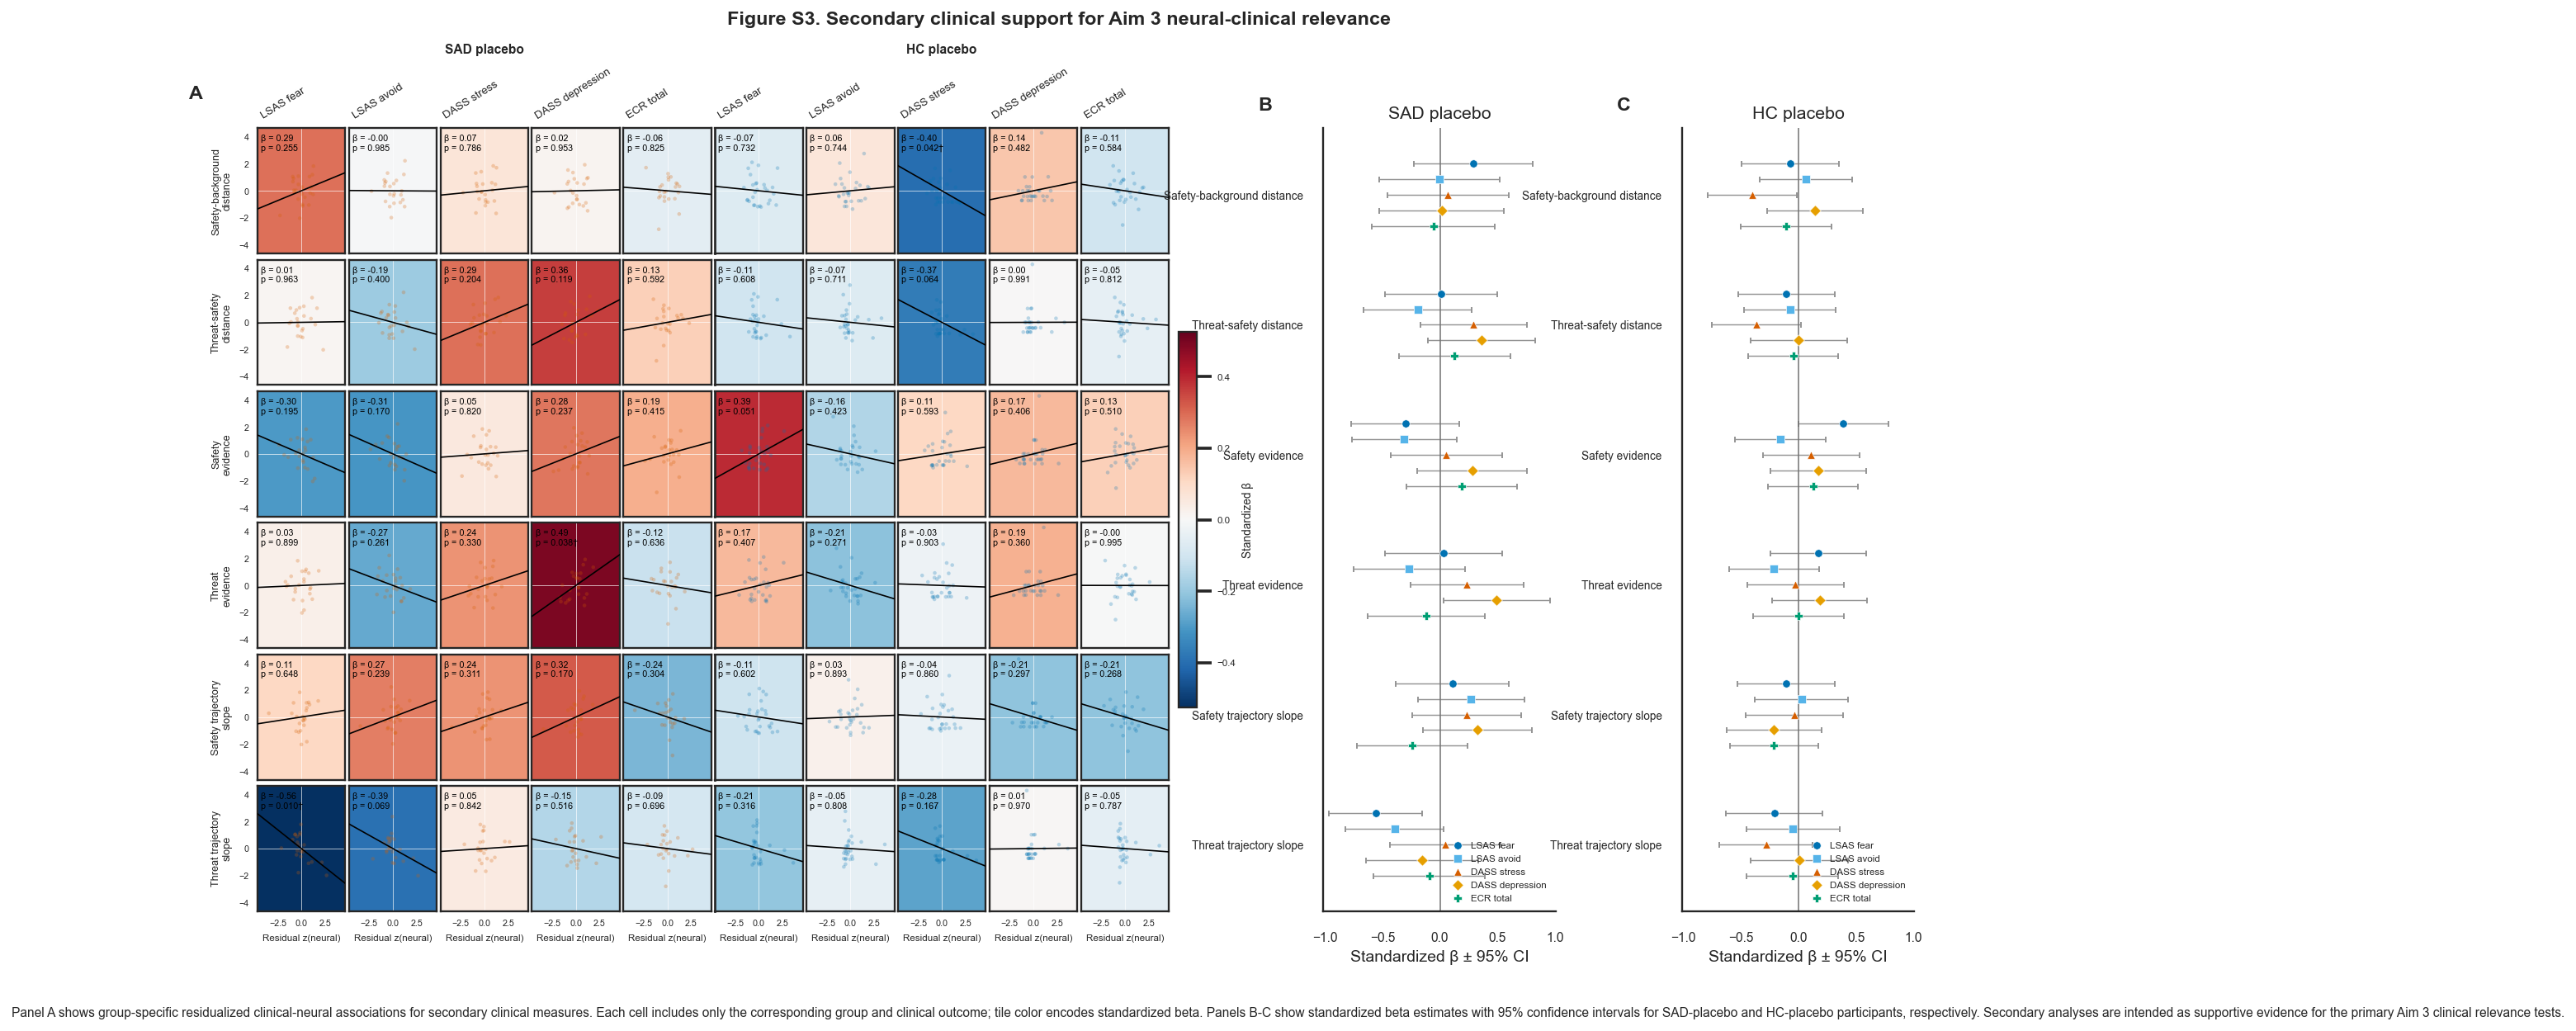

In [18]:
display(Markdown('**Figure S3 / Table Aim 3 secondary supportive clinical evidence:** exploratory secondary clinical-neural associations are modeled within SAD-placebo and HC-placebo participants.'))

AIM3_SECONDARY_GROUPS = AIM3_PRIMARY_GROUPS
AIM3_SECONDARY_OUTCOMES = ['lsas_fear', 'lsas_avoid', 'dass_stress', 'dass_depression', 'ecr_total']
AIM3_SECONDARY_METRICS = AIM3_PRIMARY_METRICS
AIM3_SECONDARY_FDR_SCOPE = 'all_secondary_tests'
AIM3_SECONDARY_FIGURE_STEM = 'FigureS3_Aim3_secondary_clinical_support'
AIM3_SECONDARY_TABLE_STEM = 'Table_Aim3_secondary_statistics'
AIM3_SECONDARY_OUTCOME_LABELS = {
    'lsas_fear': 'LSAS fear',
    'lsas_avoid': 'LSAS avoid',
    'dass_stress': 'DASS stress',
    'dass_depression': 'DASS depression',
    'ecr_total': 'ECR total',
}
AIM3_SECONDARY_MARKERS = {
    'lsas_fear': 'o',
    'lsas_avoid': 's',
    'dass_stress': '^',
    'dass_depression': 'D',
    'ecr_total': 'P',
}
AIM3_SECONDARY_COLORS = {
    'lsas_fear': OKABE['blue'],
    'lsas_avoid': OKABE['sky'],
    'dass_stress': OKABE['vermillion'],
    'dass_depression': OKABE['orange'],
    'ecr_total': OKABE['green'],
}
AIM3_SECONDARY_OFFSETS = {
    'lsas_fear': -0.24,
    'lsas_avoid': -0.12,
    'dass_stress': 0.0,
    'dass_depression': 0.12,
    'ecr_total': 0.24,
}


def prepare_aim3_secondary_data(subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    df = subject_source_df if subject_source_df is not None else metrics_df
    if df is None or df.empty:
        print('Aim 3 secondary outputs cannot be generated because metrics_df is empty.')
        return pd.DataFrame(), []
    data = _aim3_add_canonical_neural_metrics(df)
    if 'FeatureSpace' in data.columns:
        data = data[data['FeatureSpace'].astype(str).eq(feature_space)].copy()
    if 'Drug' in data.columns:
        data = data[data['Drug'].astype(str).eq(drug)].copy()
    group_col = _aim3_first_existing(data, ['Group', 'group'])
    subject_col = _aim3_first_existing(data, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    required = [group_col, subject_col] + AIM3_SECONDARY_OUTCOMES + AIM3_SECONDARY_METRICS
    missing = [col for col in required if col is None or col not in data.columns]
    if missing:
        print('Aim 3 secondary outputs cannot be generated because required columns are missing:')
        for col in missing:
            print(f'- {col}')
        return pd.DataFrame(), missing
    keep_cols = [subject_col, group_col] + AIM3_SECONDARY_OUTCOMES + AIM3_SECONDARY_METRICS + [col for col in AIM3_PRIMARY_COVARIATE_CANDIDATES if col in data.columns]
    out = data[keep_cols].copy()
    out = out.rename(columns={subject_col: 'subject_id', group_col: 'group'})
    out['group'] = out['group'].map(_aim3_normalize_group)
    out = out[out['group'].isin(AIM3_SECONDARY_GROUPS)].copy()
    for col in AIM3_SECONDARY_OUTCOMES + AIM3_SECONDARY_METRICS + ['demo_age']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.reset_index(drop=True), []


def fdr_correct_aim3_secondary(results_df, scope=AIM3_SECONDARY_FDR_SCOPE):
    out = results_df.copy()
    out['q_fdr'] = np.nan
    if out.empty:
        return out
    if scope == 'all_secondary_tests':
        out['q_fdr'] = bh_fdr(out['p']).values
    elif scope == 'within_group':
        for _, idx in out.groupby('group', dropna=False).groups.items():
            out.loc[idx, 'q_fdr'] = bh_fdr(out.loc[idx, 'p']).values
    elif scope == 'within_clinical_outcome':
        for _, idx in out.groupby('clinical_outcome', dropna=False).groups.items():
            out.loc[idx, 'q_fdr'] = bh_fdr(out.loc[idx, 'p']).values
    elif scope == 'within_group_outcome':
        for _, idx in out.groupby(['group', 'clinical_outcome'], dropna=False).groups.items():
            out.loc[idx, 'q_fdr'] = bh_fdr(out.loc[idx, 'p']).values
    else:
        raise ValueError(f'Unsupported Aim 3 secondary FDR scope: {scope}')
    out['fdr_scope'] = scope
    return out


def _aim3_format_q(value):
    return f'{value:.2f}' if pd.notna(value) and np.isfinite(value) else 'NA'


def _aim3_secondary_beta_abs(results_df):
    primary = globals().get('aim3_primary_statistics', pd.DataFrame())
    if isinstance(primary, pd.DataFrame) and not primary.empty and 'beta_standardized' in primary.columns:
        beta_abs = np.nanmax(np.abs(primary['beta_standardized'].to_numpy(dtype=float)))
    else:
        beta_abs = np.nanmax(np.abs(results_df['beta_standardized'].to_numpy(dtype=float))) if not results_df.empty else 1.0
    return 1.0 if not np.isfinite(beta_abs) or beta_abs == 0 else float(beta_abs)


def make_aim3_secondary_regression_heatmap(results_df, plot_df, fig, subplot_spec):
    columns = [(group, outcome) for group in AIM3_SECONDARY_GROUPS for outcome in AIM3_SECONDARY_OUTCOMES]
    gs = gridspec.GridSpecFromSubplotSpec(len(AIM3_SECONDARY_METRICS), len(columns), subplot_spec=subplot_spec, wspace=0.04, hspace=0.05)
    beta_abs = _aim3_secondary_beta_abs(results_df)
    norm = TwoSlopeNorm(vmin=-beta_abs, vcenter=0.0, vmax=beta_abs)
    cmap = plt.get_cmap('RdBu_r')
    all_x = plot_df['x_resid'].to_numpy(dtype=float) if not plot_df.empty else np.array([-1, 1])
    all_y = plot_df['y_resid'].to_numpy(dtype=float) if not plot_df.empty else np.array([-1, 1])
    finite = np.isfinite(all_x) & np.isfinite(all_y)
    lim = float(np.nanmax(np.abs(np.r_[all_x[finite], all_y[finite]]))) if finite.any() else 1.0
    lim = max(lim * 1.08, 1.0)
    axes = []
    for r, metric in enumerate(AIM3_SECONDARY_METRICS):
        row_axes = []
        for c, (group, outcome) in enumerate(columns):
            ax = fig.add_subplot(gs[r, c])
            row_axes.append(ax)
            match = results_df[(results_df['group'].eq(group)) & (results_df['clinical_outcome'].eq(outcome)) & (results_df['neural_metric'].eq(metric))]
            beta = float(match['beta_standardized'].iloc[0]) if not match.empty else np.nan
            p_value = float(match['p'].iloc[0]) if not match.empty else np.nan
            q_value = float(match['q_fdr'].iloc[0]) if not match.empty else np.nan
            ax.set_facecolor(cmap(norm(beta)) if np.isfinite(beta) else 'white')
            cell = plot_df[(plot_df['group'].eq(group)) & (plot_df['clinical_outcome'].eq(outcome)) & (plot_df['neural_metric'].eq(metric))]
            color = GROUP_COLORS.get(group, '0.25')
            if not cell.empty and np.isfinite(beta):
                ax.scatter(cell['x_resid'], cell['y_resid'], s=5.5, alpha=0.25, color=color, edgecolor='none', zorder=2)
                xx = np.array([-lim, lim])
                ax.plot(xx, beta * xx, color='black', linewidth=0.85, zorder=3)
            label = f'β = {beta:.2f}\np = {p_value:.3f}{_aim3_sig_text(p_value, q_value)}' if np.isfinite(beta) else 'missing'
            ax.text(0.04, 0.95, label, transform=ax.transAxes, va='top', ha='left', fontsize=5.5, color='black')
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.axhline(0, color='white', linewidth=0.45, alpha=0.75, zorder=1)
            ax.axvline(0, color='white', linewidth=0.45, alpha=0.75, zorder=1)
            if r == 0:
                title = AIM3_SECONDARY_OUTCOME_LABELS.get(outcome, outcome)
                ax.set_title(title, fontsize=6.8, rotation=32, ha='left', x=0.02)
            if c == 0:
                ax.set_ylabel(AIM3_PRIMARY_METRIC_LABELS[metric], fontsize=6.5)
            else:
                ax.set_yticklabels([])
            if r == len(AIM3_SECONDARY_METRICS) - 1:
                ax.set_xlabel('Residual z(neural)', fontsize=6)
            else:
                ax.set_xticklabels([])
            if c == len(AIM3_SECONDARY_OUTCOMES):
                ax.spines['left'].set_linewidth(1.4)
                ax.spines['left'].set_color('0.15')
            ax.tick_params(length=1.6, labelsize=5.5)
        axes.append(row_axes)
    axes[0][0].text(-0.78, 1.34, 'A', transform=axes[0][0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    axes[0][2].text(0.5, 1.58, 'SAD placebo', transform=axes[0][2].transAxes, ha='center', va='bottom', fontsize=8, fontweight='bold')
    axes[0][7].text(0.5, 1.58, 'HC placebo', transform=axes[0][7].transAxes, ha='center', va='bottom', fontsize=8, fontweight='bold')
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=[ax for row in axes for ax in row], fraction=0.02, pad=0.01)
    cbar.set_label('Standardized β', fontsize=7)
    cbar.ax.tick_params(labelsize=6)
    return axes


def make_aim3_secondary_forest_plot(results_df, group, ax, xlim=None):
    sub = results_df[results_df['group'].eq(group)].copy()
    y_base = np.arange(len(AIM3_SECONDARY_METRICS))
    ax.axvline(0, color='0.45', linewidth=0.8)
    for outcome in AIM3_SECONDARY_OUTCOMES:
        current = sub[sub['clinical_outcome'].eq(outcome)].set_index('neural_metric').reindex(AIM3_SECONDARY_METRICS)
        y = y_base + AIM3_SECONDARY_OFFSETS[outcome]
        est = pd.to_numeric(current['beta_standardized'], errors='coerce')
        lo = pd.to_numeric(current['ci_low'], errors='coerce')
        hi = pd.to_numeric(current['ci_high'], errors='coerce')
        valid = est.notna() & lo.notna() & hi.notna()
        ax.errorbar(est[valid], y[valid], xerr=[est[valid] - lo[valid], hi[valid] - est[valid]], fmt='none', ecolor='0.58', elinewidth=0.75, capsize=1.8, zorder=1)
        ax.scatter(est[valid], y[valid], marker=AIM3_SECONDARY_MARKERS[outcome], s=24, color=AIM3_SECONDARY_COLORS[outcome], edgecolor='white', linewidth=0.35, label=AIM3_SECONDARY_OUTCOME_LABELS[outcome], zorder=3)
    ax.set_yticks(y_base)
    ax.set_yticklabels([AIM3_PRIMARY_METRIC_LABELS[m].replace('\n', ' ') for m in AIM3_SECONDARY_METRICS], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Standardized β ± 95% CI')
    ax.set_title(f'{group} placebo')
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.legend(frameon=False, loc='lower right', fontsize=6, handletextpad=0.4)
    sns.despine(ax=ax)
    return ax


def save_aim3_secondary_outputs(fig, table_df, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    png_path = fig_dir / f'{AIM3_SECONDARY_FIGURE_STEM}.png'
    svg_path = fig_dir / f'{AIM3_SECONDARY_FIGURE_STEM}.svg'
    csv_path = stats_dir / f'{AIM3_SECONDARY_TABLE_STEM}.csv'
    xlsx_path = stats_dir / f'{AIM3_SECONDARY_TABLE_STEM}.xlsx'
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(svg_path, bbox_inches='tight')
    table_df.to_csv(csv_path, index=False)
    try:
        table_df.to_excel(xlsx_path, index=False)
    except Exception as exc:
        print(f'Could not save Excel table {xlsx_path}: {exc}')
        xlsx_path = None
    print(f'Saved {png_path}')
    print(f'Saved {svg_path}')
    print(f'Saved {csv_path}')
    if xlsx_path is not None:
        print(f'Saved {xlsx_path}')
    return {'png': png_path, 'svg': svg_path, 'csv': csv_path, 'xlsx': xlsx_path}


# Generate Aim 3 secondary supportive outputs.
aim3_secondary_data, aim3_secondary_missing_columns = prepare_aim3_secondary_data(metrics_df)
aim3_secondary_rows = []
aim3_secondary_plot_frames = []
if not aim3_secondary_data.empty:
    for group in AIM3_SECONDARY_GROUPS:
        for outcome in AIM3_SECONDARY_OUTCOMES:
            for metric in AIM3_SECONDARY_METRICS:
                row, plot_data = run_ols_model(aim3_secondary_data, group, outcome, metric)
                if row is not None:
                    row['fdr_scope'] = AIM3_SECONDARY_FDR_SCOPE
                    aim3_secondary_rows.append(row)
                if plot_data is not None and not plot_data.empty:
                    aim3_secondary_plot_frames.append(plot_data)

aim3_secondary_statistics = fdr_correct_aim3_secondary(pd.DataFrame(aim3_secondary_rows), scope=AIM3_SECONDARY_FDR_SCOPE)
aim3_secondary_plot_data = pd.concat(aim3_secondary_plot_frames, ignore_index=True, sort=False) if aim3_secondary_plot_frames else pd.DataFrame(columns=['group', 'clinical_outcome', 'neural_metric', 'x_resid', 'y_resid'])
if aim3_secondary_statistics.empty:
    print('No Aim 3 secondary models could be fit from the available data.')
else:
    table_columns = ['group', 'clinical_outcome', 'neural_metric', 'beta_standardized', 'ci_low', 'ci_high', 't', 'p', 'q_fdr', 'n', 'covariates']
    group_order = {group: i for i, group in enumerate(AIM3_SECONDARY_GROUPS)}
    outcome_order = {outcome: i for i, outcome in enumerate(AIM3_SECONDARY_OUTCOMES)}
    metric_order = {metric: i for i, metric in enumerate(AIM3_SECONDARY_METRICS)}
    aim3_secondary_statistics = aim3_secondary_statistics.assign(
        _group_order=aim3_secondary_statistics['group'].map(group_order),
        _outcome_order=aim3_secondary_statistics['clinical_outcome'].map(outcome_order),
        _metric_order=aim3_secondary_statistics['neural_metric'].map(metric_order),
    ).sort_values(['_group_order', '_outcome_order', '_metric_order']).drop(columns=['_group_order', '_outcome_order', '_metric_order'])
    display(Markdown('**Aim 3 secondary clinical support statistics:** FDR correction is applied across all 60 exploratory/supportive secondary tests by default.'))
    display(aim3_secondary_statistics[table_columns])
    forest_xlim = (
        float(min(-0.05, aim3_secondary_statistics['ci_low'].min() - 0.05)),
        float(max(0.05, aim3_secondary_statistics['ci_high'].max() + 0.05)),
    )
    fig = plt.figure(figsize=(18.5, 8.8), constrained_layout=False)
    outer = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[4.25, 1.05, 1.05], wspace=0.27)
    make_aim3_secondary_regression_heatmap(aim3_secondary_statistics, aim3_secondary_plot_data, fig, outer[0])
    ax_b = fig.add_subplot(outer[1])
    ax_c = fig.add_subplot(outer[2], sharex=ax_b)
    make_aim3_secondary_forest_plot(aim3_secondary_statistics, 'SAD', ax_b, xlim=forest_xlim)
    make_aim3_secondary_forest_plot(aim3_secondary_statistics, 'HC', ax_c, xlim=forest_xlim)
    ax_b.text(-0.28, 1.04, 'B', transform=ax_b.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    ax_c.text(-0.28, 1.04, 'C', transform=ax_c.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    fig.suptitle('Figure S3. Secondary clinical support for Aim 3 neural-clinical relevance', y=0.995, fontsize=12, fontweight='bold')
    fig.text(0.01, 0.006, 'Panel A shows group-specific residualized clinical-neural associations for secondary clinical measures. Each cell includes only the corresponding group and clinical outcome; tile color encodes standardized beta. Panels B-C show standardized beta estimates with 95% confidence intervals for SAD-placebo and HC-placebo participants, respectively. Secondary analyses are intended as supportive evidence for the primary Aim 3 clinical relevance tests.', fontsize=8)
    aim3_secondary_output_paths = save_aim3_secondary_outputs(fig, aim3_secondary_statistics[table_columns])
    display(fig)
    plt.close(fig)


### Aim 3 sensitivity visualization

Controlled by `task_Visualization-Aim3-sensitivity.md`. The sensitivity outputs repeat the primary Aim 3 model family for available alternative feature-space and SCR-defined cohort specifications, while preserving group-specific placebo-condition analyses unless a skipped specification records otherwise. One figure is saved per available sensitivity specification, and `Table_Aim3_sensitivity_statistics` records within-specification and global sensitivity FDR values.


**Figure S3 / Table Aim 3 sensitivity clinical relevance:** feature-space specifications repeat the primary SAD-placebo and HC-placebo model family; SCR-defined cohort specifications pool placebo and oxytocin participants within subgroup and include Drug as a covariate.

**Aim 3 sensitivity statistics:** FDR correction is applied within each available 24-model sensitivity specification, with an additional global FDR across all sensitivity rows.

,sensitivity_type,sensitivity_spec,feature_space,cohort_flag,group,clinical_outcome,neural_metric,beta_standardized,ci_low,ci_high,t,p,q_fdr_within_spec,q_fdr_all_sensitivity,n,covariates,drug_filter,model_formula,notes
0,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,dass_anxiety,Neural_Dist_Safety_Background,0.031547,-0.437424,0.500519,0.140795,0.889514,0.980657,0.999809,23,"demo_age, Gender",Placebo,z(dass_anxiety) ~ z(Neural_Dist_Safety_Backgro...,alternative feature space: MemoryFearNetwork
1,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,dass_anxiety,Neural_Dist_Threat_Safety,0.006135,-0.452369,0.464640,0.028007,0.977949,0.980657,0.999809,23,"demo_age, Gender",Placebo,z(dass_anxiety) ~ z(Neural_Dist_Threat_Safety)...,alternative feature space: MemoryFearNetwork
2,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,dass_anxiety,Neural_SafetyEvidence,0.167528,-0.356410,0.691465,0.669239,0.511394,0.980657,0.999809,23,"demo_age, Gender",Placebo,z(dass_anxiety) ~ z(Neural_SafetyEvidence) + d...,alternative feature space: MemoryFearNetwork
3,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,dass_anxiety,Neural_ThreatEvidence,0.422130,-0.042204,0.886465,1.902787,0.072334,0.868007,0.462937,23,"demo_age, Gender",Placebo,z(dass_anxiety) ~ z(Neural_ThreatEvidence) + d...,alternative feature space: MemoryFearNetwork
4,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,dass_anxiety,Neural_Safety_Trajectory_Slope,0.044669,-0.411499,0.500837,0.204955,0.839787,0.980657,0.999809,23,"demo_age, Gender",Placebo,z(dass_anxiety) ~ z(Neural_Safety_Trajectory_S...,alternative feature space: MemoryFearNetwork
5,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,dass_anxiety,Neural_Threat_Trajectory_Slope,0.009465,-0.552913,0.571844,0.035360,0.972182,0.980657,0.999809,22,"demo_age, Gender",Placebo,z(dass_anxiety) ~ z(Neural_Threat_Trajectory_S...,alternative feature space: MemoryFearNetwork
6,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,lsas_total,Neural_Dist_Safety_Background,0.087096,-0.391155,0.565347,0.381167,0.707308,0.980657,0.999809,23,"demo_age, Gender",Placebo,z(lsas_total) ~ z(Neural_Dist_Safety_Backgroun...,alternative feature space: MemoryFearNetwork
7,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,lsas_total,Neural_Dist_Threat_Safety,0.027305,-0.441638,0.496249,0.121872,0.904280,0.980657,0.999809,23,"demo_age, Gender",Placebo,z(lsas_total) ~ z(Neural_Dist_Threat_Safety) +...,alternative feature space: MemoryFearNetwork
8,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,lsas_total,Neural_SafetyEvidence,-0.392426,-0.900984,0.116133,-1.615068,0.122780,0.980657,0.614716,23,"demo_age, Gender",Placebo,z(lsas_total) ~ z(Neural_SafetyEvidence) + dem...,alternative feature space: MemoryFearNetwork
9,alternative_feature_space,MemoryFearNetwork,MemoryFearNetwork,,SAD,lsas_total,Neural_ThreatEvidence,-0.006084,-0.524450,0.512282,-0.024566,0.980657,0.980657,0.999809,23,"demo_age, Gender",Placebo,z(lsas_total) ~ z(Neural_ThreatEvidence) + dem...,alternative feature space: MemoryFearNetwork


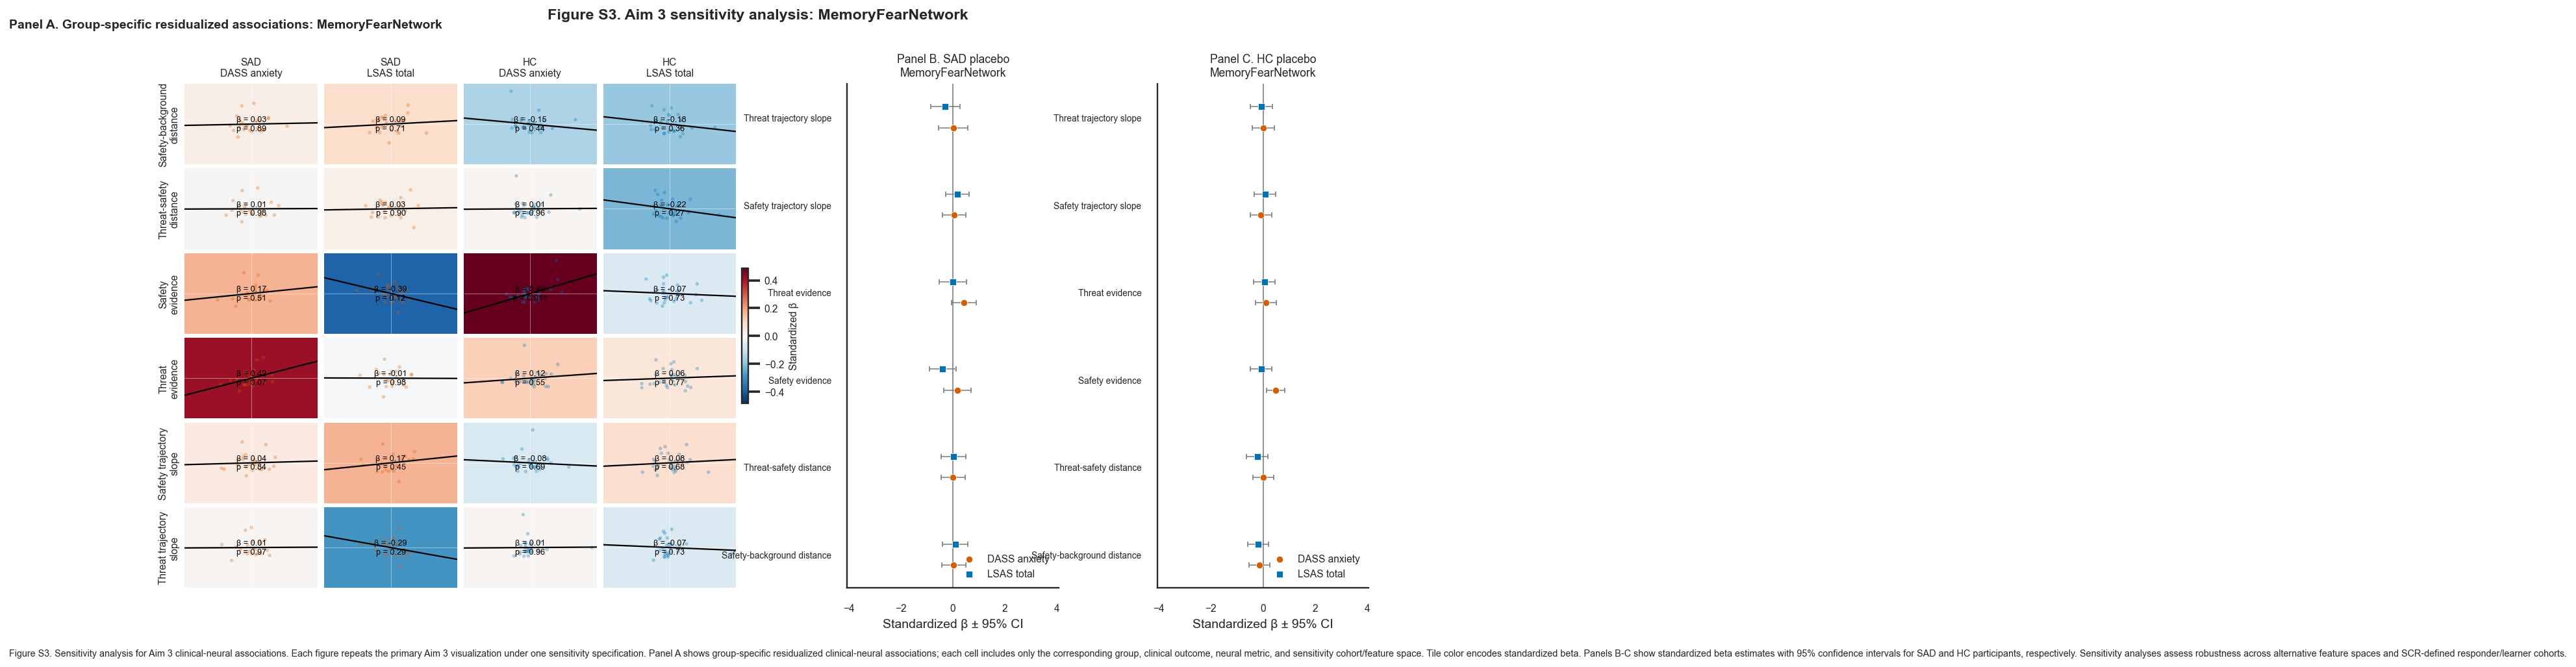

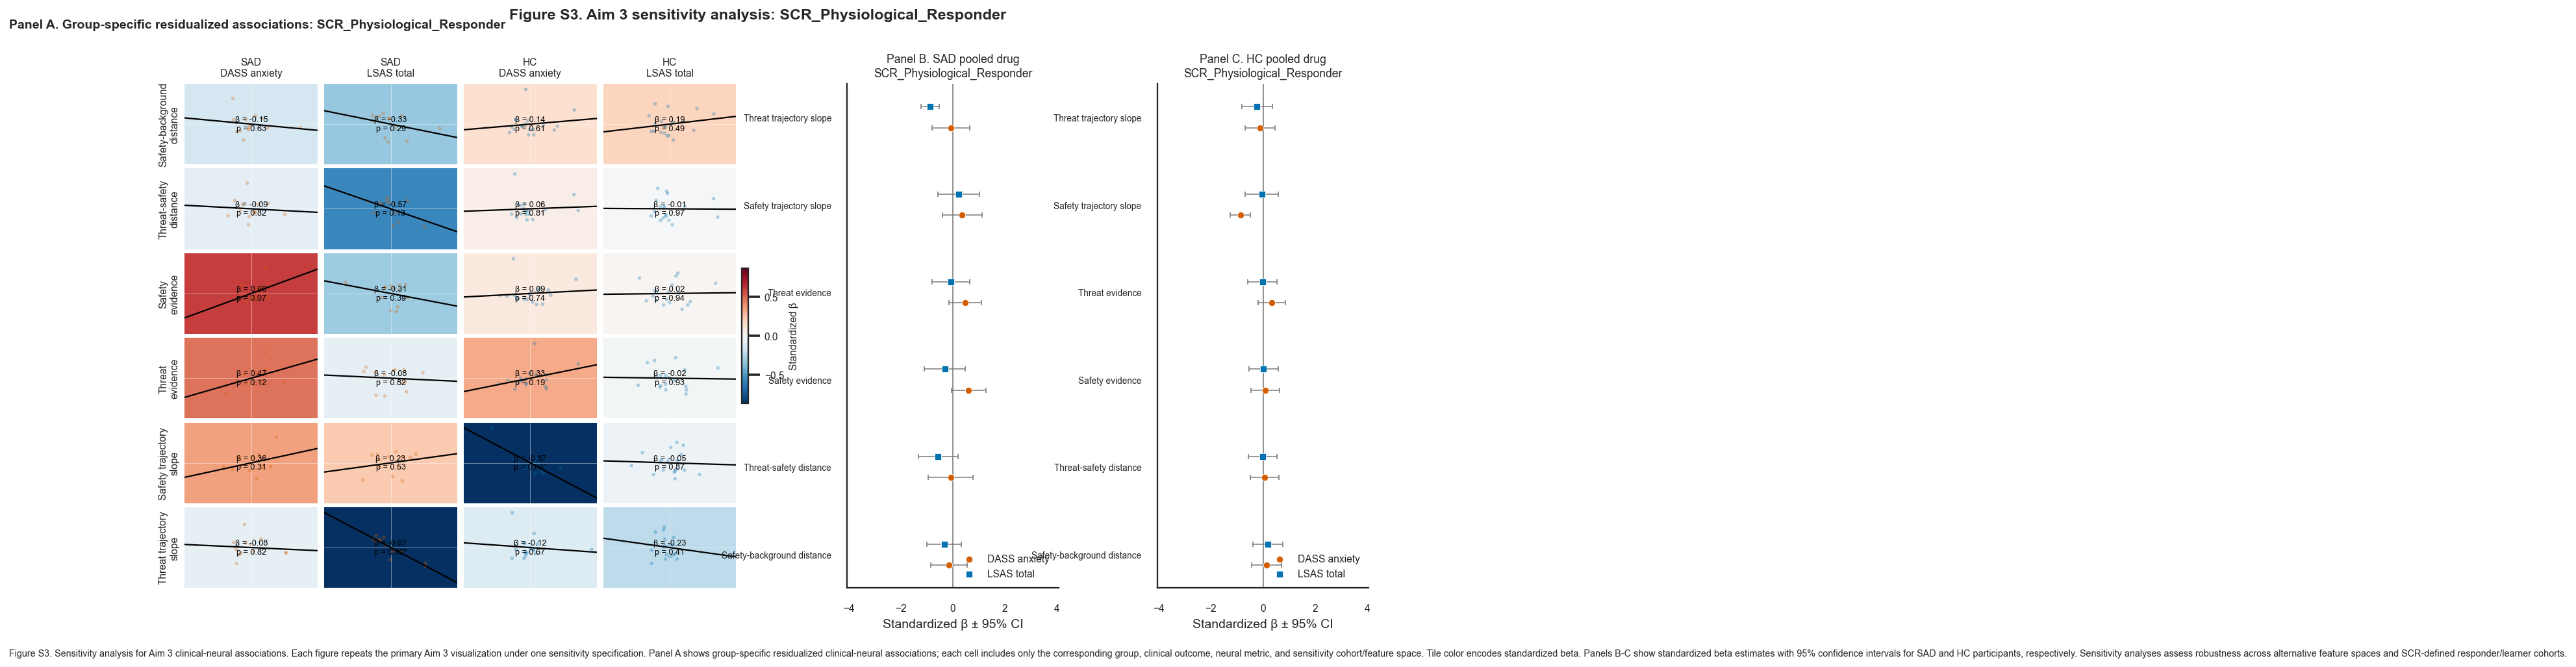

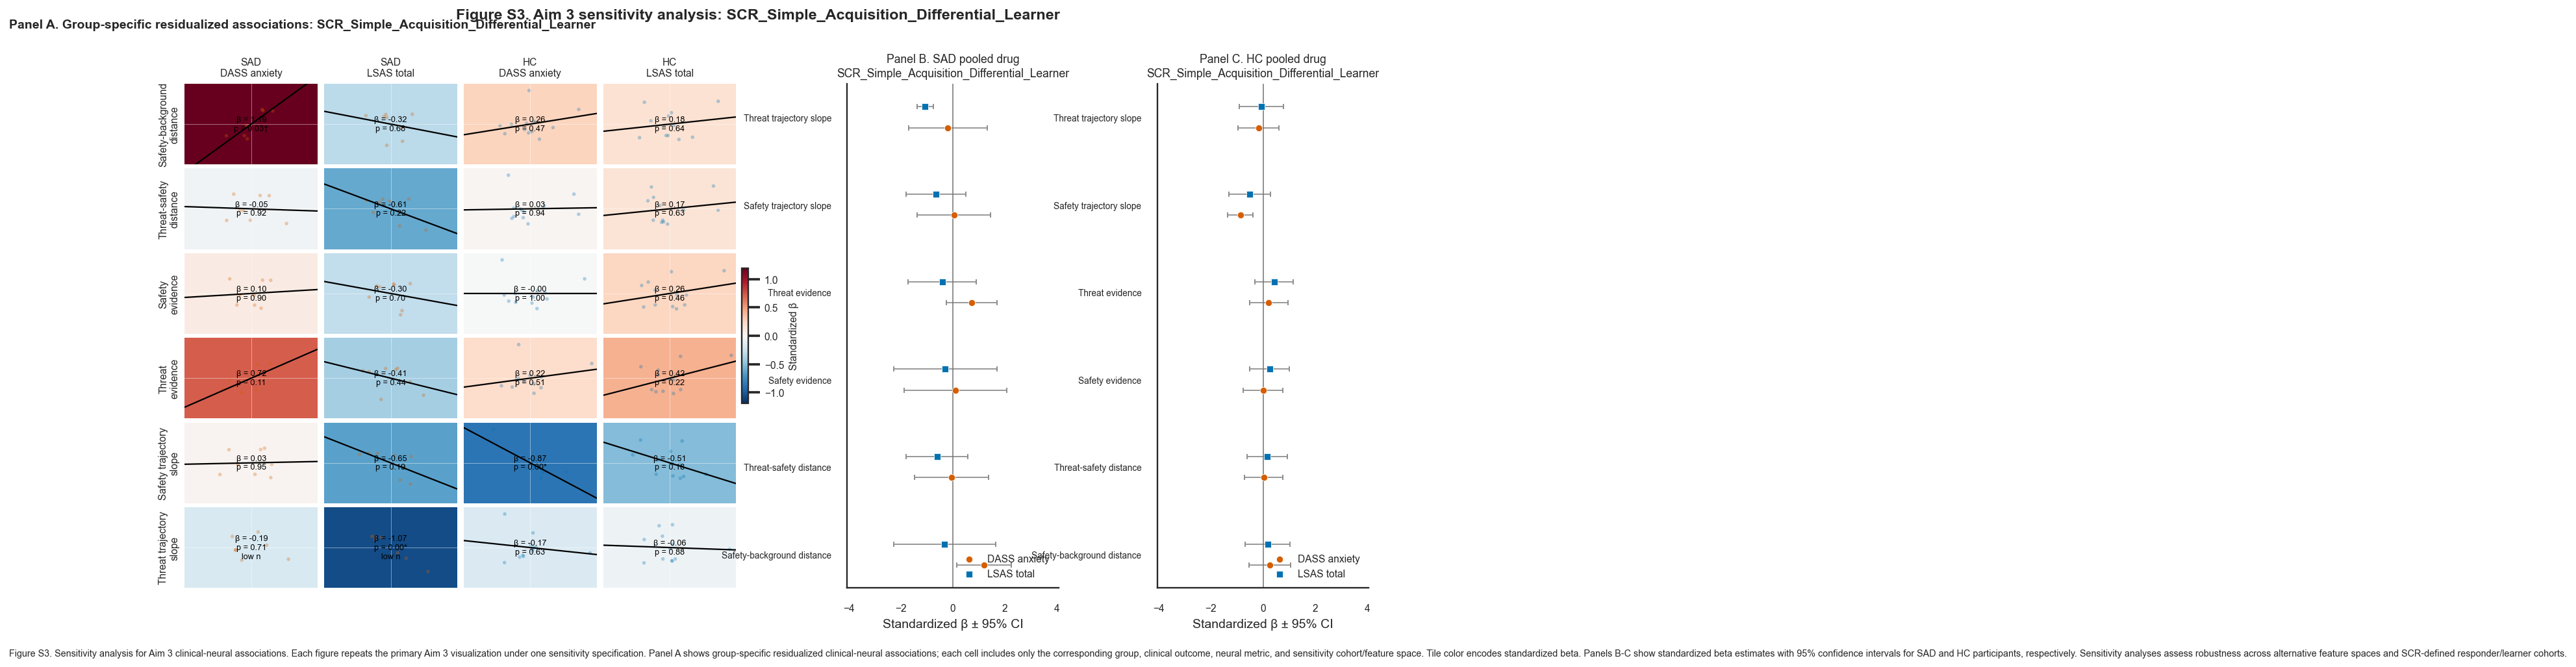

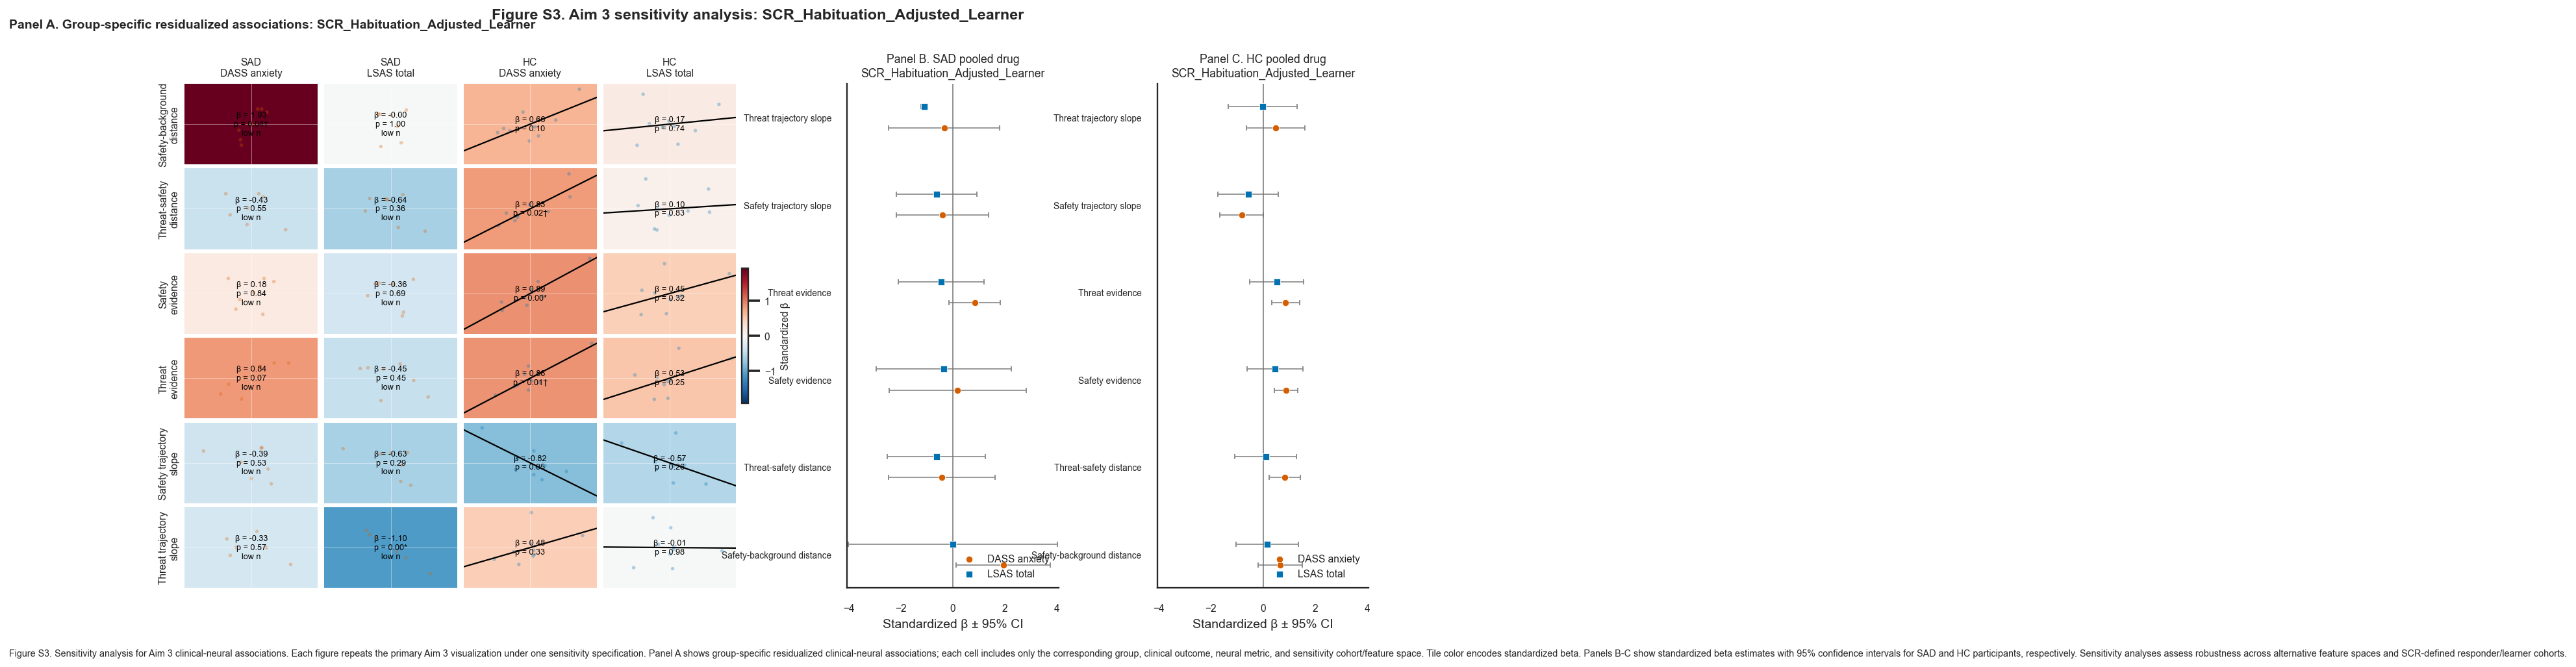

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_MemoryFearNetwork.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_MemoryFearNetwork.svg


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_SCR_Physiological_Responder.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_SCR_Physiological_Responder.svg


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_SCR_Simple_Acquisition_Differential_Learner.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_SCR_Simple_Acquisition_Differential_Learner.svg


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_SCR_Habituation_Adjusted_Learner.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_SCR_Habituation_Adjusted_Learner.svg
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_Aim3_sensitivity_statistics.csv
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_Aim3_sensitivity_statistics.xlsx
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/FigureS3_Aim3_sensitivity_clinical_relevance_caption.txt


In [19]:
display(Markdown('**Figure S3 / Table Aim 3 sensitivity clinical relevance:** feature-space specifications repeat the primary SAD-placebo and HC-placebo model family; SCR-defined cohort specifications pool placebo and oxytocin participants within subgroup and include Drug as a covariate.'))

AIM3_SENSITIVITY_GROUPS = AIM3_PRIMARY_GROUPS
AIM3_SENSITIVITY_OUTCOMES = AIM3_PRIMARY_OUTCOMES
AIM3_SENSITIVITY_METRICS = AIM3_PRIMARY_METRICS
AIM3_SENSITIVITY_FDR_SCOPE = 'within_sensitivity_spec'
AIM3_SENSITIVITY_GLOBAL_FDR = True
AIM3_SENSITIVITY_PRIMARY_FEATURE_SPACE = 'FearNetwork'
AIM3_SENSITIVITY_DRUG_FILTER = 'Placebo'
AIM3_SCR_COHORT_DRUG_FILTER = None
AIM3_SCR_COHORT_COVARIATES = AIM3_PRIMARY_COVARIATE_CANDIDATES + ['Drug']
AIM3_SENSITIVITY_LOW_N_THRESHOLD = 8
AIM3_SENSITIVITY_FEATURE_SPACE_ORDER = ['MemoryFearNetwork', 'Schaefer', 'Tian', 'WholeBrain', 'WholeBrain_Parcellation', 'WholeBrain_Schaefer', 'Schaefer_Tian']
AIM3_SENSITIVITY_SCR_FLAGS = [
    'SCR_Physiological_Responder',
    'SCR_Simple_Acquisition_Differential_Learner',
    'SCR_Habituation_Adjusted_Learner',
    'SCR_Late_Phase_Sensitivity_Learner',
]
AIM3_SENSITIVITY_TABLE_STEM = 'Table_Aim3_sensitivity_statistics'
AIM3_SENSITIVITY_FIGURE_STEM = 'FigureS3_Aim3_sensitivity_clinical_relevance'
AIM3_SENSITIVITY_REQUIRED_TABLE_COLUMNS = [
    'sensitivity_type', 'sensitivity_spec', 'feature_space', 'cohort_flag', 'group', 'clinical_outcome', 'neural_metric',
    'beta_standardized', 'ci_low', 'ci_high', 't', 'p', 'q_fdr_within_spec', 'q_fdr_all_sensitivity', 'n',
    'covariates', 'drug_filter', 'model_formula', 'notes',
]
AIM3_SENSITIVITY_CAPTION = 'Figure S3. Sensitivity analysis for Aim 3 clinical-neural associations. Each figure repeats the primary Aim 3 visualization under one sensitivity specification. Panel A shows group-specific residualized clinical-neural associations; each cell includes only the corresponding group, clinical outcome, neural metric, and sensitivity cohort/feature space. Tile color encodes standardized beta. Panels B-C show standardized beta estimates with 95% confidence intervals for SAD and HC participants, respectively. Sensitivity analyses assess robustness across alternative feature spaces and SCR-defined responder/learner cohorts.'


def _aim3_sensitivity_subject_col(df):
    return _aim3_first_existing(df, ['subject_id', 'Subject', 'sub_ID', 'sub'])


def _aim3_sensitivity_slug(value):
    text = str(value).strip()
    cleaned = ''.join(ch if ch.isalnum() else '_' for ch in text)
    while '__' in cleaned:
        cleaned = cleaned.replace('__', '_')
    return cleaned.strip('_') or 'unspecified'


def _aim3_sensitivity_format_q(value):
    return f'{value:.2f}' if pd.notna(value) and np.isfinite(value) else 'NA'


def _aim3_sensitivity_ordered_feature_spaces(df):
    if df is None or df.empty or 'FeatureSpace' not in df.columns:
        return []
    observed = [str(value) for value in df['FeatureSpace'].dropna().unique()]
    primary_lower = AIM3_SENSITIVITY_PRIMARY_FEATURE_SPACE.casefold()
    observed = [value for value in observed if value.casefold() != primary_lower]
    ordered = [value for value in AIM3_SENSITIVITY_FEATURE_SPACE_ORDER if value in observed]
    ordered.extend(sorted(value for value in observed if value not in ordered))
    return ordered


def define_aim3_sensitivity_specs(subject_source_df=None, scr_source_df=None):
    subject_source_df = subject_source_df if subject_source_df is not None else metrics_df
    scr_source_df = scr_source_df if scr_source_df is not None else scr_flags_df
    specs = []
    skipped = []
    for feature_space in _aim3_sensitivity_ordered_feature_spaces(subject_source_df):
        specs.append({
            'sensitivity_type': 'alternative_feature_space',
            'sensitivity_spec': feature_space,
            'feature_space': feature_space,
            'cohort_flag': '',
            'drug_filter': AIM3_SENSITIVITY_DRUG_FILTER,
            'covariates': AIM3_PRIMARY_COVARIATE_CANDIDATES,
        })
    if not any(spec['sensitivity_type'] == 'alternative_feature_space' for spec in specs):
        skipped.append({'sensitivity_type': 'alternative_feature_space', 'sensitivity_spec': 'available_alternative_feature_spaces', 'reason': 'No alternative FeatureSpace values were present in subject metrics.'})
    available_flags = [flag for flag in AIM3_SENSITIVITY_SCR_FLAGS if scr_source_df is not None and not scr_source_df.empty and flag in scr_source_df.columns]
    for flag in available_flags:
        specs.append({
            'sensitivity_type': 'scr_defined_cohort',
            'sensitivity_spec': flag,
            'feature_space': AIM3_SENSITIVITY_PRIMARY_FEATURE_SPACE,
            'cohort_flag': flag,
            'drug_filter': AIM3_SCR_COHORT_DRUG_FILTER,
            'covariates': AIM3_SCR_COHORT_COVARIATES,
        })
    for flag in AIM3_SENSITIVITY_SCR_FLAGS:
        if flag not in available_flags:
            skipped.append({'sensitivity_type': 'scr_defined_cohort', 'sensitivity_spec': flag, 'reason': 'SCR sensitivity flag was not available.'})
    return specs, pd.DataFrame(skipped)


def prepare_aim3_sensitivity_data(spec, subject_source_df=None, scr_source_df=None):
    subject_source_df = subject_source_df if subject_source_df is not None else metrics_df
    scr_source_df = scr_source_df if scr_source_df is not None else scr_flags_df
    if subject_source_df is None or subject_source_df.empty:
        return pd.DataFrame(), ['metrics_df'], 'Subject-level metrics are empty.'
    data = _aim3_add_canonical_neural_metrics(subject_source_df)
    feature_space = spec.get('feature_space') or AIM3_SENSITIVITY_PRIMARY_FEATURE_SPACE
    if 'FeatureSpace' in data.columns:
        data = data[data['FeatureSpace'].astype(str).eq(str(feature_space))].copy()
    elif spec.get('sensitivity_type') == 'alternative_feature_space':
        return pd.DataFrame(), ['FeatureSpace'], 'FeatureSpace column is missing, so alternative feature spaces cannot be selected.'
    drug_filter = spec.get('drug_filter', AIM3_SENSITIVITY_DRUG_FILTER)
    if drug_filter and 'Drug' in data.columns:
        data = data[data['Drug'].astype(str).eq(str(drug_filter))].copy()
    group_col = _aim3_first_existing(data, ['Group', 'group'])
    subject_col = _aim3_sensitivity_subject_col(data)
    required = [group_col, subject_col] + AIM3_SENSITIVITY_OUTCOMES + AIM3_SENSITIVITY_METRICS
    missing = [col for col in required if col is None or col not in data.columns]
    if missing:
        return pd.DataFrame(), missing, 'Required subject metric columns are missing.'
    spec_covariates = spec.get('covariates') or AIM3_PRIMARY_COVARIATE_CANDIDATES
    keep_cols = [subject_col, group_col] + AIM3_SENSITIVITY_OUTCOMES + AIM3_SENSITIVITY_METRICS + [col for col in spec_covariates if col in data.columns]
    out = data[keep_cols].copy().rename(columns={subject_col: 'subject_id', group_col: 'group'})
    out['group'] = out['group'].map(_aim3_normalize_group)
    out = out[out['group'].isin(AIM3_SENSITIVITY_GROUPS)].copy()
    cohort_flag = spec.get('cohort_flag') or ''
    if cohort_flag:
        if scr_source_df is None or scr_source_df.empty:
            return pd.DataFrame(), [cohort_flag], 'SCR sensitivity table is empty.'
        scr_subject_col = _aim3_sensitivity_subject_col(scr_source_df)
        if scr_subject_col is None or cohort_flag not in scr_source_df.columns:
            return pd.DataFrame(), [cohort_flag], 'SCR sensitivity flag or subject identifier is missing.'
        scr_keep = scr_source_df[[scr_subject_col, cohort_flag]].copy().rename(columns={scr_subject_col: 'subject_id'})
        scr_keep['subject_id'] = scr_keep['subject_id'].astype(str)
        scr_keep[cohort_flag] = pd.to_numeric(scr_keep[cohort_flag], errors='coerce')
        out['subject_id'] = out['subject_id'].astype(str)
        out = out.merge(scr_keep, on='subject_id', how='left')
        out = out[out[cohort_flag].eq(1)].copy()
    for col in AIM3_SENSITIVITY_OUTCOMES + AIM3_SENSITIVITY_METRICS + ['demo_age']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    if out.empty:
        filter_label = 'feature-space and cohort filters' if cohort_flag and drug_filter is None else 'feature-space, placebo, and cohort filters'
        return out, [], f'No participants remained after applying {filter_label}.'
    return out.reset_index(drop=True), [], ''


def fdr_correct_aim3_sensitivity(results_df, scope=AIM3_SENSITIVITY_FDR_SCOPE, global_fdr=AIM3_SENSITIVITY_GLOBAL_FDR):
    out = results_df.copy()
    out['q_fdr_within_spec'] = np.nan
    out['q_fdr_all_sensitivity'] = np.nan
    if out.empty:
        return out
    if scope == 'within_sensitivity_spec':
        for _, idx in out.groupby('sensitivity_spec', dropna=False).groups.items():
            out.loc[idx, 'q_fdr_within_spec'] = bh_fdr(out.loc[idx, 'p']).values
    elif scope == 'within_spec_group':
        for _, idx in out.groupby(['sensitivity_spec', 'group'], dropna=False).groups.items():
            out.loc[idx, 'q_fdr_within_spec'] = bh_fdr(out.loc[idx, 'p']).values
    else:
        raise ValueError(f'Unsupported Aim 3 sensitivity FDR scope: {scope}')
    if global_fdr:
        out['q_fdr_all_sensitivity'] = bh_fdr(out['p']).values
    out['fdr_scope'] = scope
    return out


def _aim3_sensitivity_plot_limits(plot_df):
    if plot_df.empty:
        return 1.0
    all_x = pd.to_numeric(plot_df['x_resid'], errors='coerce').to_numpy(dtype=float)
    all_y = pd.to_numeric(plot_df['y_resid'], errors='coerce').to_numpy(dtype=float)
    finite = np.isfinite(all_x) & np.isfinite(all_y)
    lim = float(np.nanmax(np.abs(np.r_[all_x[finite], all_y[finite]]))) if finite.any() else 1.0
    return max(lim * 1.08, 1.0)


def make_panel_a_regression_heatmap(results_df, plot_df, fig, subplot_spec, sensitivity_spec=None, q_column='q_fdr_within_spec'):
    columns = [(group, outcome) for group in AIM3_SENSITIVITY_GROUPS for outcome in AIM3_SENSITIVITY_OUTCOMES]
    gs = gridspec.GridSpecFromSubplotSpec(len(AIM3_SENSITIVITY_METRICS), len(columns), subplot_spec=subplot_spec, wspace=0.05, hspace=0.05)
    beta_abs = np.nanmax(np.abs(results_df['beta_standardized'].to_numpy(dtype=float))) if not results_df.empty else 1.0
    beta_abs = 1.0 if not np.isfinite(beta_abs) or beta_abs == 0 else beta_abs
    norm = TwoSlopeNorm(vmin=-beta_abs, vcenter=0.0, vmax=beta_abs)
    cmap = plt.get_cmap('RdBu_r')
    lim = _aim3_sensitivity_plot_limits(plot_df)
    axes = []
    for r, metric in enumerate(AIM3_SENSITIVITY_METRICS):
        row_axes = []
        for c, (group, outcome) in enumerate(columns):
            ax = fig.add_subplot(gs[r, c])
            row_axes.append(ax)
            match = results_df[(results_df['group'].eq(group)) & (results_df['clinical_outcome'].eq(outcome)) & (results_df['neural_metric'].eq(metric))]
            beta = float(match['beta_standardized'].iloc[0]) if not match.empty else np.nan
            p_value = float(match['p'].iloc[0]) if not match.empty else np.nan
            q_value = float(match[q_column].iloc[0]) if not match.empty and q_column in match.columns else np.nan
            n_value = int(match['n'].iloc[0]) if not match.empty and pd.notna(match['n'].iloc[0]) else 0
            low_n = bool(match['notes'].astype(str).str.contains('low n', case=False, na=False).any()) if not match.empty and 'notes' in match.columns else n_value < AIM3_SENSITIVITY_LOW_N_THRESHOLD
            ax.set_facecolor(cmap(norm(beta)) if np.isfinite(beta) else 'white')
            cell = plot_df[(plot_df['group'].eq(group)) & (plot_df['clinical_outcome'].eq(outcome)) & (plot_df['neural_metric'].eq(metric))]
            color = GROUP_COLORS.get(group, '0.25')
            if not cell.empty:
                ax.scatter(cell['x_resid'], cell['y_resid'], s=8, alpha=0.30, color=color, edgecolor='none', zorder=2)
                if np.isfinite(beta) and not low_n:
                    xx = np.array([-lim, lim])
                    ax.plot(xx, beta * xx, color='black', linewidth=1.15, zorder=3)
            if np.isfinite(beta):
                label = f'β = {beta:.2f}\np = {_aim3_sensitivity_format_q(p_value)}{_aim3_sig_text(p_value, q_value)}'
                if low_n:
                    label = f'{label}\nlow n'
            else:
                label = 'missing'
            ax.text(0.5, 0.5, label, transform=ax.transAxes, ha='center', va='center', fontsize=6.5, color='black')
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.axhline(0, color='white', linewidth=0.5, alpha=0.45)
            ax.axvline(0, color='white', linewidth=0.5, alpha=0.45)
            if r == 0:
                ax.set_title(AIM3_PRIMARY_COLUMN_LABELS[(group, outcome)], fontsize=8)
            if c == 0:
                ax.set_ylabel(AIM3_PRIMARY_METRIC_LABELS[metric], fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
        axes.extend(row_axes)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=axes, fraction=0.012, pad=0.01)
    cbar.set_label('Standardized β', fontsize=8)
    title = 'Panel A. Group-specific residualized associations'
    if sensitivity_spec:
        title = f'{title}: {sensitivity_spec}'
    fig.text(0.01, 0.965, title, fontsize=10, fontweight='bold')
    return axes


def make_forest_plot(results_df, group, ax, xlim=None, sensitivity_spec=None):
    offsets = {'dass_anxiety': -0.12, 'lsas_total': 0.12}
    markers = {'dass_anxiety': 'o', 'lsas_total': 's'}
    colors = {'dass_anxiety': OKABE['vermillion'], 'lsas_total': OKABE['blue']}
    labels = {'dass_anxiety': 'DASS anxiety', 'lsas_total': 'LSAS total'}
    sub = results_df[results_df['group'].eq(group)].copy()
    y_base = np.arange(len(AIM3_SENSITIVITY_METRICS))
    ax.axvline(0, color='0.45', linewidth=0.8)
    for outcome in AIM3_SENSITIVITY_OUTCOMES:
        current = sub[sub['clinical_outcome'].eq(outcome)].set_index('neural_metric').reindex(AIM3_SENSITIVITY_METRICS)
        y = y_base + offsets[outcome]
        est = pd.to_numeric(current['beta_standardized'], errors='coerce')
        lo = pd.to_numeric(current['ci_low'], errors='coerce')
        hi = pd.to_numeric(current['ci_high'], errors='coerce')
        valid = est.notna() & lo.notna() & hi.notna()
        ax.errorbar(est[valid], y[valid], xerr=[est[valid] - lo[valid], hi[valid] - est[valid]], fmt='none', ecolor='0.55', elinewidth=0.9, capsize=2, zorder=1)
        ax.scatter(est[valid], y[valid], marker=markers[outcome], s=28, color=colors[outcome], edgecolor='white', linewidth=0.4, label=labels[outcome], zorder=3)
    ax.set_yticks(y_base)
    ax.set_yticklabels([AIM3_PRIMARY_METRIC_LABELS[m].replace('\n', ' ') for m in AIM3_SENSITIVITY_METRICS], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Standardized β ± 95% CI')
    spec_text = f'\n{sensitivity_spec}' if sensitivity_spec else ''
    session_label = 'pooled drug' if str(sensitivity_spec).startswith('SCR_') else 'placebo'
    ax.set_title(f'{group} {session_label}{spec_text}', fontsize=9)
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.legend(frameon=False, loc='lower right')
    sns.despine(ax=ax)
    return ax


def save_sensitivity_outputs(figures_by_spec, table_df, skipped_df=None, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for spec, fig in figures_by_spec.items():
        slug = _aim3_sensitivity_slug(spec)
        png_path = fig_dir / f'{AIM3_SENSITIVITY_FIGURE_STEM}_{slug}.png'
        svg_path = fig_dir / f'{AIM3_SENSITIVITY_FIGURE_STEM}_{slug}.svg'
        fig.savefig(png_path, bbox_inches='tight', dpi=300)
        fig.savefig(svg_path, bbox_inches='tight')
        paths.append({'sensitivity_spec': spec, 'png': png_path, 'svg': svg_path})
        print(f'Saved {png_path}')
        print(f'Saved {svg_path}')
    csv_path = stats_dir / f'{AIM3_SENSITIVITY_TABLE_STEM}.csv'
    xlsx_path = stats_dir / f'{AIM3_SENSITIVITY_TABLE_STEM}.xlsx'
    table_df.to_csv(csv_path, index=False)
    try:
        table_df.to_excel(xlsx_path, index=False)
    except Exception as exc:
        print(f'Could not save Excel table {xlsx_path}: {exc}')
        xlsx_path = None
    caption_path = fig_dir / f'{AIM3_SENSITIVITY_FIGURE_STEM}_caption.txt'
    caption_path.write_text(AIM3_SENSITIVITY_CAPTION)
    if skipped_df is not None and not skipped_df.empty:
        skipped_path = stats_dir / f'{AIM3_SENSITIVITY_TABLE_STEM}_skipped.csv'
        skipped_df.to_csv(skipped_path, index=False)
        print(f'Saved {skipped_path}')
    print(f'Saved {csv_path}')
    if xlsx_path is not None:
        print(f'Saved {xlsx_path}')
    print(f'Saved {caption_path}')
    return {'figures': paths, 'csv': csv_path, 'xlsx': xlsx_path, 'caption': caption_path}


# Generate Aim 3 sensitivity outputs.
aim3_sensitivity_specs, aim3_sensitivity_skipped = define_aim3_sensitivity_specs(metrics_df, scr_flags_df)
aim3_sensitivity_rows = []
aim3_sensitivity_plot_frames = []
for spec in aim3_sensitivity_specs:
    spec_data, missing_columns, skipped_reason = prepare_aim3_sensitivity_data(spec, metrics_df, scr_flags_df)
    if missing_columns or spec_data.empty:
        reason = skipped_reason or 'No estimable rows for this sensitivity specification.'
        missing_text = ', '.join([str(col) for col in missing_columns]) if missing_columns else 'none'
        print(f"Skipping Aim 3 sensitivity spec {spec['sensitivity_spec']}: {reason} Missing columns: {missing_text}")
        aim3_sensitivity_skipped = pd.concat([aim3_sensitivity_skipped, pd.DataFrame([{**spec, 'reason': reason, 'missing_columns': missing_text}])], ignore_index=True, sort=False)
        continue
    for group in AIM3_SENSITIVITY_GROUPS:
        for outcome in AIM3_SENSITIVITY_OUTCOMES:
            for metric in AIM3_SENSITIVITY_METRICS:
                row, plot_data = run_ols_model(spec_data, group, outcome, metric)
                if row is not None:
                    note_parts = []
                    if row['n'] < AIM3_SENSITIVITY_LOW_N_THRESHOLD:
                        note_parts.append('low n')
                    if spec.get('cohort_flag'):
                        note_parts.append(f"restricted to {spec['cohort_flag']} == 1 and pooled across Drug")
                    if spec.get('sensitivity_type') == 'alternative_feature_space':
                        note_parts.append(f"alternative feature space: {spec['feature_space']}")
                    row.update({
                        'sensitivity_type': spec['sensitivity_type'],
                        'sensitivity_spec': spec['sensitivity_spec'],
                        'feature_space': spec.get('feature_space') or '',
                        'cohort_flag': spec.get('cohort_flag') or '',
                        'drug_filter': spec.get('drug_filter') or 'none',
                        'model_formula': f'z({outcome}) ~ z({metric}) + {row["covariates"]}',
                        'notes': '; '.join(note_parts) if note_parts else '',
                    })
                    aim3_sensitivity_rows.append(row)
                if plot_data is not None and not plot_data.empty:
                    plot_data = plot_data.copy()
                    plot_data['sensitivity_type'] = spec['sensitivity_type']
                    plot_data['sensitivity_spec'] = spec['sensitivity_spec']
                    plot_data['feature_space'] = spec.get('feature_space') or ''
                    plot_data['cohort_flag'] = spec.get('cohort_flag') or ''
                    aim3_sensitivity_plot_frames.append(plot_data)

aim3_sensitivity_statistics = fdr_correct_aim3_sensitivity(pd.DataFrame(aim3_sensitivity_rows), scope=AIM3_SENSITIVITY_FDR_SCOPE)
aim3_sensitivity_plot_data = pd.concat(aim3_sensitivity_plot_frames, ignore_index=True, sort=False) if aim3_sensitivity_plot_frames else pd.DataFrame(columns=['sensitivity_spec', 'group', 'clinical_outcome', 'neural_metric', 'x_resid', 'y_resid'])
if aim3_sensitivity_statistics.empty:
    print('No Aim 3 sensitivity models could be fit from the available data.')
    if not aim3_sensitivity_skipped.empty:
        display(Markdown('**Skipped Aim 3 sensitivity specifications:**'))
        display(aim3_sensitivity_skipped.drop_duplicates())
else:
    group_order = {group: i for i, group in enumerate(AIM3_SENSITIVITY_GROUPS)}
    outcome_order = {outcome: i for i, outcome in enumerate(AIM3_SENSITIVITY_OUTCOMES)}
    metric_order = {metric: i for i, metric in enumerate(AIM3_SENSITIVITY_METRICS)}
    spec_order = {spec['sensitivity_spec']: i for i, spec in enumerate(aim3_sensitivity_specs)}
    aim3_sensitivity_statistics = aim3_sensitivity_statistics.assign(
        _spec_order=aim3_sensitivity_statistics['sensitivity_spec'].map(spec_order).fillna(999),
        _group_order=aim3_sensitivity_statistics['group'].map(group_order).fillna(999),
        _outcome_order=aim3_sensitivity_statistics['clinical_outcome'].map(outcome_order).fillna(999),
        _metric_order=aim3_sensitivity_statistics['neural_metric'].map(metric_order).fillna(999),
    ).sort_values(['_spec_order', '_group_order', '_outcome_order', '_metric_order']).drop(columns=['_spec_order', '_group_order', '_outcome_order', '_metric_order'])
    for col in AIM3_SENSITIVITY_REQUIRED_TABLE_COLUMNS:
        if col not in aim3_sensitivity_statistics.columns:
            aim3_sensitivity_statistics[col] = np.nan
    display(Markdown('**Aim 3 sensitivity statistics:** FDR correction is applied within each available 24-model sensitivity specification, with an additional global FDR across all sensitivity rows.'))
    display(aim3_sensitivity_statistics[AIM3_SENSITIVITY_REQUIRED_TABLE_COLUMNS])
    if not aim3_sensitivity_skipped.empty:
        display(Markdown('**Skipped Aim 3 sensitivity specifications:**'))
        display(aim3_sensitivity_skipped.drop_duplicates())
    forest_xlim = (
        float(min(-0.05, aim3_sensitivity_statistics['ci_low'].min() - 0.05)),
        float(max(0.05, aim3_sensitivity_statistics['ci_high'].max() + 0.05)),
    )
    aim3_sensitivity_figures = {}
    for spec_name, spec_stats in aim3_sensitivity_statistics.groupby('sensitivity_spec', sort=False):
        spec_plot = aim3_sensitivity_plot_data[aim3_sensitivity_plot_data['sensitivity_spec'].eq(spec_name)].copy()
        fig = plt.figure(figsize=(16.8, 7.2), constrained_layout=False)
        outer = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[2.8, 1.05, 1.05], wspace=0.30)
        make_panel_a_regression_heatmap(spec_stats, spec_plot, fig, outer[0], sensitivity_spec=spec_name, q_column='q_fdr_within_spec')
        ax_b = fig.add_subplot(outer[1])
        ax_c = fig.add_subplot(outer[2], sharey=ax_b)
        make_forest_plot(spec_stats, 'SAD', ax_b, xlim=forest_xlim, sensitivity_spec=spec_name)
        make_forest_plot(spec_stats, 'HC', ax_c, xlim=forest_xlim, sensitivity_spec=spec_name)
        session_label = 'pooled drug' if str(spec_name).startswith('SCR_') else 'placebo'
        ax_b.set_title(f'Panel B. SAD {session_label}\n{spec_name}', fontsize=9)
        ax_c.set_title(f'Panel C. HC {session_label}\n{spec_name}', fontsize=9)
        fig.suptitle(f'Figure S3. Aim 3 sensitivity analysis: {spec_name}', y=0.995, fontsize=12, fontweight='bold')
        fig.text(0.01, 0.006, AIM3_SENSITIVITY_CAPTION, fontsize=7.4)
        aim3_sensitivity_figures[spec_name] = fig
        show_figure_once(fig)
        plt.close(fig)
    aim3_sensitivity_output_paths = save_sensitivity_outputs(aim3_sensitivity_figures, aim3_sensitivity_statistics[AIM3_SENSITIVITY_REQUIRED_TABLE_COLUMNS], aim3_sensitivity_skipped)


## Aim 4. Physiological relevance of neural profiles under placebo

This section is controlled only by the three Aim 4 visualization task files. Primary, secondary/supportive, and sensitivity outputs are kept visually and inferentially separate; placebo-session filtering is explicit in each subsection, and missing required outputs are labeled as missing or pending rather than interpreted as null results.


### Aim 4 primary visualization

Controlled by `task_Visualization-Aim4-primary.md`. Figure 4 and Table 4 test whether the six primary neural metrics align with primary SCR trajectory slopes in SAD-placebo and HC-placebo participants after Stage-29 z-score outlier removal. The figure contains Panel A, a group-specific association heatmap for all primary neural × SCR models, Panel B, the key safety trajectory convergence scatter plot, and Panel C, the key threat trajectory convergence scatter plot. The statistics table preserves raw `SCR_outcome` and `Neural_predictor` variable names.


In [ ]:
AIM4_PRIMARY_GROUPS = ['SAD', 'HC']
AIM4_PRIMARY_SCR_OUTCOMES = ['SCR_Safety_Trajectory_Slope', 'SCR_Threat_Trajectory_Slope']
AIM4_PRIMARY_NEURAL_PREDICTORS = SHARED_AIM2_TO_AIM5_METRICS.copy()
AIM4_PRIMARY_COVARIATE_CANDIDATES = ['demo_age', 'Gender']
AIM4_OUTLIER_Z_THRESHOLD = 3.0
AIM4_PRIMARY_FDR_SCOPE = 'all_primary_tests'
AIM4_PRIMARY_FIGURE_STEM = 'Figure4_Aim4_primary_neural_SCR_convergence'
AIM4_PRIMARY_TABLE_STEM = 'Table4_Aim4_primary_neural_SCR_convergence'
AIM4_PRIMARY_METRIC_LABELS = {
    metric: PRIMARY_NEURAL_METRIC_LABELS.get(metric, metric)
    for metric in AIM4_PRIMARY_NEURAL_PREDICTORS
}
AIM4_PRIMARY_SCR_LABELS = {
    'SCR_Safety_Trajectory_Slope': 'SCR safety\ntrajectory slope',
    'SCR_Threat_Trajectory_Slope': 'SCR threat\ntrajectory slope',
}
AIM4_PRIMARY_FAMILY_LABELS = [PRIMARY_NEURAL_METRIC_FAMILIES.get(metric, '') for metric in AIM4_PRIMARY_NEURAL_PREDICTORS]


def _aim4_format_p(value):
    if pd.isna(value):
        return 'NA'
    value = float(value)
    return '<.001' if value < 0.001 else f'{value:.3f}'


def _aim4_clean_group(value):
    return _aim3_normalize_group(value)


def _aim4_stage29_zscore_remove_outliers(series, threshold=AIM4_OUTLIER_Z_THRESHOLD):
    values = pd.to_numeric(series, errors='coerce')
    non_missing = values.notna()
    z = pd.Series(np.nan, index=series.index, dtype=float)
    if int(non_missing.sum()) < 4:
        return z, 0
    sd = values.std(skipna=True, ddof=0)
    if pd.isna(sd) or sd == 0:
        return z, 0
    initial_z = (values - values.mean(skipna=True)) / sd
    outlier_mask = non_missing & (initial_z.abs() > threshold)
    values_clean = values.mask(outlier_mask)
    sd_clean = values_clean.std(skipna=True, ddof=0)
    if pd.isna(sd_clean) or sd_clean == 0:
        return z, int(outlier_mask.sum())
    z.loc[:] = (values_clean - values_clean.mean(skipna=True)) / sd_clean
    return z, int(outlier_mask.sum())


def prepare_aim4_primary_data(subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    df = subject_source_df if subject_source_df is not None else metrics_df
    if df is None or df.empty:
        raise ValueError('Aim 4 primary outputs cannot be generated because metrics_df is empty.')
    data = _aim3_add_canonical_neural_metrics(df, feature_space=feature_space)
    if 'FeatureSpace' in data.columns:
        data = data[data['FeatureSpace'].astype(str).eq(feature_space)].copy()
    if 'Drug' in data.columns:
        data = data[data['Drug'].astype(str).eq(drug)].copy()
    group_col = _aim3_first_existing(data, ['Group', 'group'])
    subject_col = _aim3_first_existing(data, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    required = [group_col, subject_col] + AIM4_PRIMARY_SCR_OUTCOMES + AIM4_PRIMARY_NEURAL_PREDICTORS
    missing = [col for col in required if col is None or col not in data.columns]
    if missing:
        missing_text = ', '.join(str(col) for col in missing)
        raise ValueError(f'Aim 4 primary outputs cannot be generated because required columns are missing: {missing_text}')
    keep_cols = [subject_col, group_col] + AIM4_PRIMARY_SCR_OUTCOMES + AIM4_PRIMARY_NEURAL_PREDICTORS + [col for col in AIM4_PRIMARY_COVARIATE_CANDIDATES if col in data.columns]
    out = data[keep_cols].copy()
    out = out.rename(columns={subject_col: 'subject_id', group_col: 'Group'})
    out['Group'] = out['Group'].map(_aim4_clean_group)
    out = out[out['Group'].isin(AIM4_PRIMARY_GROUPS)].copy()
    for col in AIM4_PRIMARY_SCR_OUTCOMES + AIM4_PRIMARY_NEURAL_PREDICTORS + ['demo_age']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.reset_index(drop=True)


def run_aim4_primary_model(data, group, scr_outcome, neural_predictor, covariates=None):
    covariates = covariates or AIM4_PRIMARY_COVARIATE_CANDIDATES
    model_data = data[data['Group'].eq(group)].copy()
    model_cols = [scr_outcome, neural_predictor] + [c for c in covariates if c in model_data.columns]
    model_data = model_data[model_cols].dropna(subset=[scr_outcome, neural_predictor]).copy()
    model_data['z_scr'], n_scr_outliers = _aim4_stage29_zscore_remove_outliers(model_data[scr_outcome])
    model_data['z_neural'], n_neural_outliers = _aim4_stage29_zscore_remove_outliers(model_data[neural_predictor])
    model_data = model_data.dropna(subset=['z_scr', 'z_neural'])
    X_cov, used_covariates = _aim3_design_matrix(model_data, covariates)
    X = pd.concat([model_data['z_neural'].rename('z_neural'), X_cov.drop(columns=['Intercept'], errors='ignore')], axis=1)
    X.insert(0, 'Intercept', 1.0)
    fit = _aim3_fit_ols(model_data['z_scr'], X)
    if fit is None or 'z_neural' not in fit['params'].index:
        return None, pd.DataFrame()
    covariate_design = X.drop(columns=['z_neural'])
    x_resid = _aim3_residualize(model_data['z_neural'], covariate_design)
    y_resid = _aim3_residualize(model_data['z_scr'], covariate_design)
    plot_data = pd.DataFrame({
        'Group': group,
        'SCR_outcome': scr_outcome,
        'Neural_predictor': neural_predictor,
        'x_resid': x_resid,
        'y_resid': y_resid,
    }).dropna()
    row = {
        'Group': group,
        'SCR_outcome': scr_outcome,
        'Neural_predictor': neural_predictor,
        'beta_std': float(fit['params']['z_neural']),
        'ci_low': float(fit['ci_low']['z_neural']),
        'ci_high': float(fit['ci_high']['z_neural']),
        't': float(fit['t']['z_neural']),
        'p': float(fit['p']['z_neural']),
        'q_FDR': np.nan,
        'N': int(fit['n']),
        'n_scr_outliers_removed': n_scr_outliers,
        'n_neural_outliers_removed': n_neural_outliers,
        'outlier_rule': f'abs(z) > {AIM4_OUTLIER_Z_THRESHOLD:g}',
        'covariates': ', '.join(used_covariates) if used_covariates else 'none',
        'r2': float(fit['r2']),
        'fdr_scope': AIM4_PRIMARY_FDR_SCOPE,
    }
    return row, plot_data




def run_aim4_whole_dataset_model(data, scr_outcome, neural_predictor, covariates=None):
    covariates = covariates or AIM4_PRIMARY_COVARIATE_CANDIDATES
    model_data = data[['Group', scr_outcome, neural_predictor] + [c for c in covariates if c in data.columns]].copy()
    model_data['z_scr'], _ = _aim4_stage29_zscore_remove_outliers(model_data[scr_outcome])
    model_data['z_neural'], _ = _aim4_stage29_zscore_remove_outliers(model_data[neural_predictor])
    model_data['group_sad'] = model_data['Group'].astype(str).eq('SAD').astype(float)
    model_data = model_data.dropna(subset=['z_scr', 'z_neural', 'group_sad'])
    if model_data.empty or model_data['group_sad'].nunique(dropna=True) < 2:
        return {'SCR_outcome': scr_outcome, 'Neural_predictor': neural_predictor, 'whole_dataset_p': np.nan}
    X_cov, _ = _aim3_design_matrix(model_data, covariates)
    X = pd.concat([model_data['z_neural'].rename('z_neural'), model_data['group_sad'].rename('group_sad'), X_cov.drop(columns=['Intercept'], errors='ignore')], axis=1)
    X.insert(0, 'Intercept', 1.0)
    fit = _aim3_fit_ols(model_data['z_scr'], X)
    p_value = float(fit['p']['z_neural']) if fit is not None and 'z_neural' in fit['p'].index else np.nan
    return {'SCR_outcome': scr_outcome, 'Neural_predictor': neural_predictor, 'whole_dataset_p': p_value}


def aim4_whole_dataset_inference_table(data):
    rows = []
    if data is None or data.empty:
        return pd.DataFrame(columns=['SCR_outcome', 'Neural_predictor', 'whole_dataset_p', 'whole_dataset_q'])
    for scr_outcome in AIM4_PRIMARY_SCR_OUTCOMES:
        for neural_predictor in AIM4_PRIMARY_NEURAL_PREDICTORS:
            rows.append(run_aim4_whole_dataset_model(data, scr_outcome, neural_predictor))
    out = pd.DataFrame(rows)
    out['whole_dataset_q'] = bh_fdr(out['whole_dataset_p']).values if not out.empty else []
    return out

def fdr_correct_aim4_primary(results_df, scope=AIM4_PRIMARY_FDR_SCOPE):
    out = results_df.copy()
    out['q_FDR'] = np.nan
    if out.empty:
        return out
    if scope == 'all_primary_tests':
        out['q_FDR'] = bh_fdr(out['p']).values
    elif scope == 'within_group':
        for _, idx in out.groupby('Group', dropna=False).groups.items():
            out.loc[idx, 'q_FDR'] = bh_fdr(out.loc[idx, 'p']).values
    else:
        raise ValueError(f'Unsupported Aim 4 FDR scope: {scope}')
    return out


def _aim4_cell_text(beta, q_value):
    if not np.isfinite(beta):
        return 'missing'
    marker = '*' if pd.notna(q_value) and q_value < 0.05 else ''
    return f'{beta:.2f}{marker}'


def _aim4_panel_a_heatmaps(results_df, fig, subplot_spec):
    gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_spec, wspace=0.12)
    beta_abs = np.nanmax(np.abs(results_df['beta_std'].to_numpy(dtype=float))) if not results_df.empty else 1.0
    beta_abs = 1.0 if not np.isfinite(beta_abs) or beta_abs == 0 else max(beta_abs, 0.25)
    norm = TwoSlopeNorm(vmin=-beta_abs, vcenter=0.0, vmax=beta_abs)
    cmap = plt.get_cmap('RdBu_r')
    axes = []
    for i, group in enumerate(AIM4_PRIMARY_GROUPS):
        ax = fig.add_subplot(gs[0, i])
        mat = results_df[results_df['Group'].eq(group)].pivot(index='Neural_predictor', columns='SCR_outcome', values='beta_std').reindex(index=AIM4_PRIMARY_NEURAL_PREDICTORS, columns=AIM4_PRIMARY_SCR_OUTCOMES)
        qmat = results_df[results_df['Group'].eq(group)].pivot(index='Neural_predictor', columns='SCR_outcome', values='q_FDR').reindex(index=AIM4_PRIMARY_NEURAL_PREDICTORS, columns=AIM4_PRIMARY_SCR_OUTCOMES)
        labels = mat.copy().astype(object)
        for r in range(labels.shape[0]):
            for c in range(labels.shape[1]):
                labels.iloc[r, c] = _aim4_cell_text(float(mat.iloc[r, c]) if pd.notna(mat.iloc[r, c]) else np.nan, qmat.iloc[r, c])
        sns.heatmap(
            mat,
            ax=ax,
            cmap=cmap,
            norm=norm,
            annot=labels,
            fmt='',
            cbar=False,
            linewidths=0.5,
            linecolor='white',
            square=False,
            xticklabels=[AIM4_PRIMARY_SCR_LABELS[col] for col in AIM4_PRIMARY_SCR_OUTCOMES],
            yticklabels=[AIM4_PRIMARY_METRIC_LABELS[row] for row in AIM4_PRIMARY_NEURAL_PREDICTORS],
            annot_kws={'fontsize': 8},
        )
        ax.set_title(f'{group} placebo', fontsize=9, pad=8)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=0, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=7)
        if i == 1:
            ax.set_yticklabels([])
        for boundary in [2, 4]:
            ax.hlines(boundary, *ax.get_xlim(), colors='0.15', linewidth=1.2)
        if i == 0:
            for y, label in zip([1, 3, 5], ['Geometry', 'Certainty', 'Trajectory']):
                ax.text(-0.42, y, label, transform=ax.get_yaxis_transform(), ha='right', va='center', fontsize=7, fontweight='bold', rotation=90)
        axes.append(ax)
    axes[0].text(-0.52, 1.12, 'A', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=axes, fraction=0.055, pad=0.025)
    cbar.set_label('Standardized beta', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    return axes


def _aim4_scatter_panel(results_df, plot_df, scr_outcome, neural_predictor, ax, panel_label, title):
    ax.axhline(0, color='0.78', linewidth=0.7, zorder=0)
    ax.axvline(0, color='0.78', linewidth=0.7, zorder=0)
    markers = {'SAD': 'o', 'HC': 's'}
    linestyles = {'SAD': '-', 'HC': '--'}
    annotation_lines = []
    for group in AIM4_PRIMARY_GROUPS:
        current = plot_df[(plot_df['Group'].eq(group)) & (plot_df['SCR_outcome'].eq(scr_outcome)) & (plot_df['Neural_predictor'].eq(neural_predictor))]
        color = GROUP_COLORS.get(group, '0.25')
        if current.empty:
            continue
        sns.regplot(
            data=current,
            x='x_resid',
            y='y_resid',
            ax=ax,
            ci=95,
            truncate=False,
            scatter_kws={'s': 28, 'alpha': 0.72, 'marker': markers.get(group, 'o'), 'edgecolor': 'white', 'color': color},
            line_kws={'color': color, 'linewidth': 1.6, 'linestyle': linestyles.get(group, '-')},
        )
        match = results_df[(results_df['Group'].eq(group)) & (results_df['SCR_outcome'].eq(scr_outcome)) & (results_df['Neural_predictor'].eq(neural_predictor))]
        if not match.empty:
            beta = float(match['beta_std'].iloc[0])
            p_value = float(match['p'].iloc[0])
            annotation_lines.append(f'{group}: beta = {beta:.2f}, p = {_aim4_format_p(p_value)}')
    handles = [plt.Line2D([0], [0], marker=markers[group], linestyle=linestyles[group], color=GROUP_COLORS[group], markerfacecolor=GROUP_COLORS[group], markeredgecolor='white', linewidth=1.4, label=f'{group} placebo') for group in AIM4_PRIMARY_GROUPS]
    ax.legend(handles=handles, frameon=False, loc='lower right')
    if annotation_lines:
        ax.text(0.03, 0.97, '\n'.join(annotation_lines), transform=ax.transAxes, ha='left', va='top', fontsize=8, bbox={'boxstyle': 'round,pad=0.25', 'facecolor': 'white', 'edgecolor': '0.85', 'alpha': 0.9})
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(AIM4_PRIMARY_METRIC_LABELS[neural_predictor].replace('\n', ' ') + ' (covariate-adjusted z)')
    ax.set_ylabel(AIM4_PRIMARY_SCR_LABELS[scr_outcome].replace('\n', ' ') + ' (covariate-adjusted z)')
    ax.text(-0.18, 1.06, panel_label, transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    sns.despine(ax=ax)
    return ax


def save_aim4_primary_outputs(fig, table_df, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    png_path = fig_dir / f'{AIM4_PRIMARY_FIGURE_STEM}.png'
    svg_path = fig_dir / f'{AIM4_PRIMARY_FIGURE_STEM}.svg'
    csv_path = stats_dir / f'{AIM4_PRIMARY_TABLE_STEM}.csv'
    md_path = stats_dir / f'{AIM4_PRIMARY_TABLE_STEM}.md'
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(svg_path, bbox_inches='tight')
    table_df.to_csv(csv_path, index=False)
    md_path.write_text('# Table 4. Primary neural-SCR convergence models\n\n' + table_df.to_markdown(index=False) + '\n')
    print(f'Saved {png_path}')
    print(f'Saved {svg_path}')
    print(f'Saved {csv_path}')
    print(f'Saved {md_path}')
    return {'png': png_path, 'svg': svg_path, 'csv': csv_path, 'md': md_path}


aim4_primary_data = prepare_aim4_primary_data(metrics_df)
aim4_primary_rows = []
aim4_primary_plot_frames = []
for group in AIM4_PRIMARY_GROUPS:
    for scr_outcome in AIM4_PRIMARY_SCR_OUTCOMES:
        for neural_predictor in AIM4_PRIMARY_NEURAL_PREDICTORS:
            row, plot_data = run_aim4_primary_model(aim4_primary_data, group, scr_outcome, neural_predictor)
            if row is not None:
                aim4_primary_rows.append(row)
            if plot_data is not None and not plot_data.empty:
                aim4_primary_plot_frames.append(plot_data)

aim4_primary_statistics = fdr_correct_aim4_primary(pd.DataFrame(aim4_primary_rows), scope=AIM4_PRIMARY_FDR_SCOPE)
aim4_primary_plot_data = pd.concat(aim4_primary_plot_frames, ignore_index=True, sort=False) if aim4_primary_plot_frames else pd.DataFrame(columns=['Group', 'SCR_outcome', 'Neural_predictor', 'x_resid', 'y_resid'])
if aim4_primary_statistics.empty:
    raise ValueError('No Aim 4 primary models could be fit from the available data.')
expected_n = len(AIM4_PRIMARY_GROUPS) * len(AIM4_PRIMARY_SCR_OUTCOMES) * len(AIM4_PRIMARY_NEURAL_PREDICTORS)
if len(aim4_primary_statistics) != expected_n:
    raise ValueError(f'Aim 4 primary table has {len(aim4_primary_statistics)} rows; expected {expected_n}.')
order_maps = {
    'Group': {group: i for i, group in enumerate(AIM4_PRIMARY_GROUPS)},
    'SCR_outcome': {scr: i for i, scr in enumerate(AIM4_PRIMARY_SCR_OUTCOMES)},
    'Neural_predictor': {metric: i for i, metric in enumerate(AIM4_PRIMARY_NEURAL_PREDICTORS)},
}
aim4_primary_statistics = aim4_primary_statistics.sort_values(['Group', 'SCR_outcome', 'Neural_predictor'], key=lambda s: s.map(order_maps.get(s.name, {})).fillna(999) if s.name in order_maps else s).reset_index(drop=True)
aim4_primary_statistics['CI_95'] = aim4_primary_statistics.apply(lambda row: f'[{row["ci_low"]:.2f}, {row["ci_high"]:.2f}]', axis=1)
aim4_primary_table4 = aim4_primary_statistics[['Group', 'SCR_outcome', 'Neural_predictor', 'beta_std', 'CI_95', 't', 'p', 'q_FDR', 'N', 'n_scr_outliers_removed', 'n_neural_outliers_removed', 'outlier_rule']].copy()
aim4_primary_table4 = aim4_primary_table4.rename(columns={'p': 'model_family_p', 'q_FDR': 'model_family_q'})
aim4_whole_dataset_statistics = aim4_whole_dataset_inference_table(aim4_primary_data)
aim4_primary_table4 = aim4_primary_table4.merge(aim4_whole_dataset_statistics, on=['SCR_outcome', 'Neural_predictor'], how='left')
display(Markdown('**Table 4. Primary neural-SCR convergence models:** standardized OLS coefficients are estimated separately within SAD-placebo and HC-placebo participants after Stage-29 z-score outlier removal; inferential columns are reported as model-family p/q plus whole-dataset p/q.'))
display(aim4_primary_table4)
fig = plt.figure(figsize=(14.4, 5.2), constrained_layout=False)
outer = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.45, 1.0, 1.0], wspace=0.34)
_aim4_panel_a_heatmaps(aim4_primary_statistics, fig, outer[0])
ax_b = fig.add_subplot(outer[1])
ax_c = fig.add_subplot(outer[2])
_aim4_scatter_panel(aim4_primary_statistics, aim4_primary_plot_data, 'SCR_Safety_Trajectory_Slope', 'Neural_Safety_Trajectory_Slope', ax_b, 'B', 'Safety convergence')
_aim4_scatter_panel(aim4_primary_statistics, aim4_primary_plot_data, 'SCR_Threat_Trajectory_Slope', 'Neural_Threat_Trajectory_Slope', ax_c, 'C', 'Threat convergence')
fig.suptitle('Figure 4. Neural-SCR convergence during vicarious safety and threat learning', y=1.03, fontsize=12, fontweight='bold')
fig.text(0.01, 0.005, 'Panel A summarizes all confirmatory primary neural-SCR associations within each diagnostic group; colors encode standardized beta and asterisks mark FDR-adjusted p < .05. Panels B-C show the key trajectory-convergence associations using covariate-adjusted standardized residuals with group-specific linear fits and 95% CI bands.', fontsize=8)
aim4_primary_output_paths = save_aim4_primary_outputs(fig, aim4_primary_table4)
display(fig)
plt.close(fig)


### Aim 4 secondary/supportive visualization

Controlled by `task_Visualization-Aim4-secondary.md`. Figure 4-S1 and Table S4 evaluate only the secondary/supportive SCR contrast outcomes `SCR_SafetyMinusBackground` and `SCR_ThreatMinusSafety` against the same six primary neural metrics in SAD-placebo and HC-placebo participants. These outputs use the same heatmap-plus-scatter structure as the primary Aim 4 figure but remain supportive evidence and are not mixed with primary trajectory-slope inference.


**Figure 4-S1 / Table S4 Aim 4 secondary supportive SCR evidence:** secondary SCR contrast outcomes are modeled within SAD-placebo and HC-placebo participants and kept separate from primary trajectory-slope convergence.

**Table S4. Secondary neural-SCR convergence models:** standardized OLS coefficients are estimated separately within SAD-placebo and HC-placebo participants; q-values use FDR correction across the 24 secondary Aim 4 tests.

,Group,SCR_outcome,Neural_predictor,beta_std,CI_95,t,p,q_FDR,N
0,SAD,SCR_SafetyMinusBackground,Neural_Dist_Safety_Background,0.07,"[-0.46, 0.60]",0.28,0.781,0.889,22
1,SAD,SCR_SafetyMinusBackground,Neural_Dist_Threat_Safety,0.41,"[-0.03, 0.84]",1.94,0.068,0.411,22
2,SAD,SCR_SafetyMinusBackground,Neural_SafetyEvidence,0.10,"[-0.38, 0.59]",0.44,0.662,0.882,22
3,SAD,SCR_SafetyMinusBackground,Neural_ThreatEvidence,0.34,"[-0.15, 0.83]",1.44,0.167,0.802,22
4,SAD,SCR_SafetyMinusBackground,Neural_Safety_Trajectory_Slope,-0.14,"[-0.70, 0.42]",-0.53,0.601,0.882,21
5,SAD,SCR_SafetyMinusBackground,Neural_Threat_Trajectory_Slope,-0.10,"[-0.57, 0.36]",-0.46,0.648,0.882,22
6,SAD,SCR_ThreatMinusSafety,Neural_Dist_Safety_Background,-0.03,"[-0.58, 0.53]",-0.10,0.924,0.964,21
7,SAD,SCR_ThreatMinusSafety,Neural_Dist_Threat_Safety,-0.19,"[-0.72, 0.34]",-0.77,0.452,0.882,21
8,SAD,SCR_ThreatMinusSafety,Neural_SafetyEvidence,-0.14,"[-0.65, 0.37]",-0.59,0.564,0.882,21
9,SAD,SCR_ThreatMinusSafety,Neural_ThreatEvidence,-0.21,"[-0.73, 0.32]",-0.83,0.419,0.882,21


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure4S1_Aim4_secondary_neural_SCR_convergence.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure4S1_Aim4_secondary_neural_SCR_convergence.svg
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/TableS4_Aim4_secondary_neural_SCR_convergence.csv
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/TableS4_Aim4_secondary_neural_SCR_convergence.md


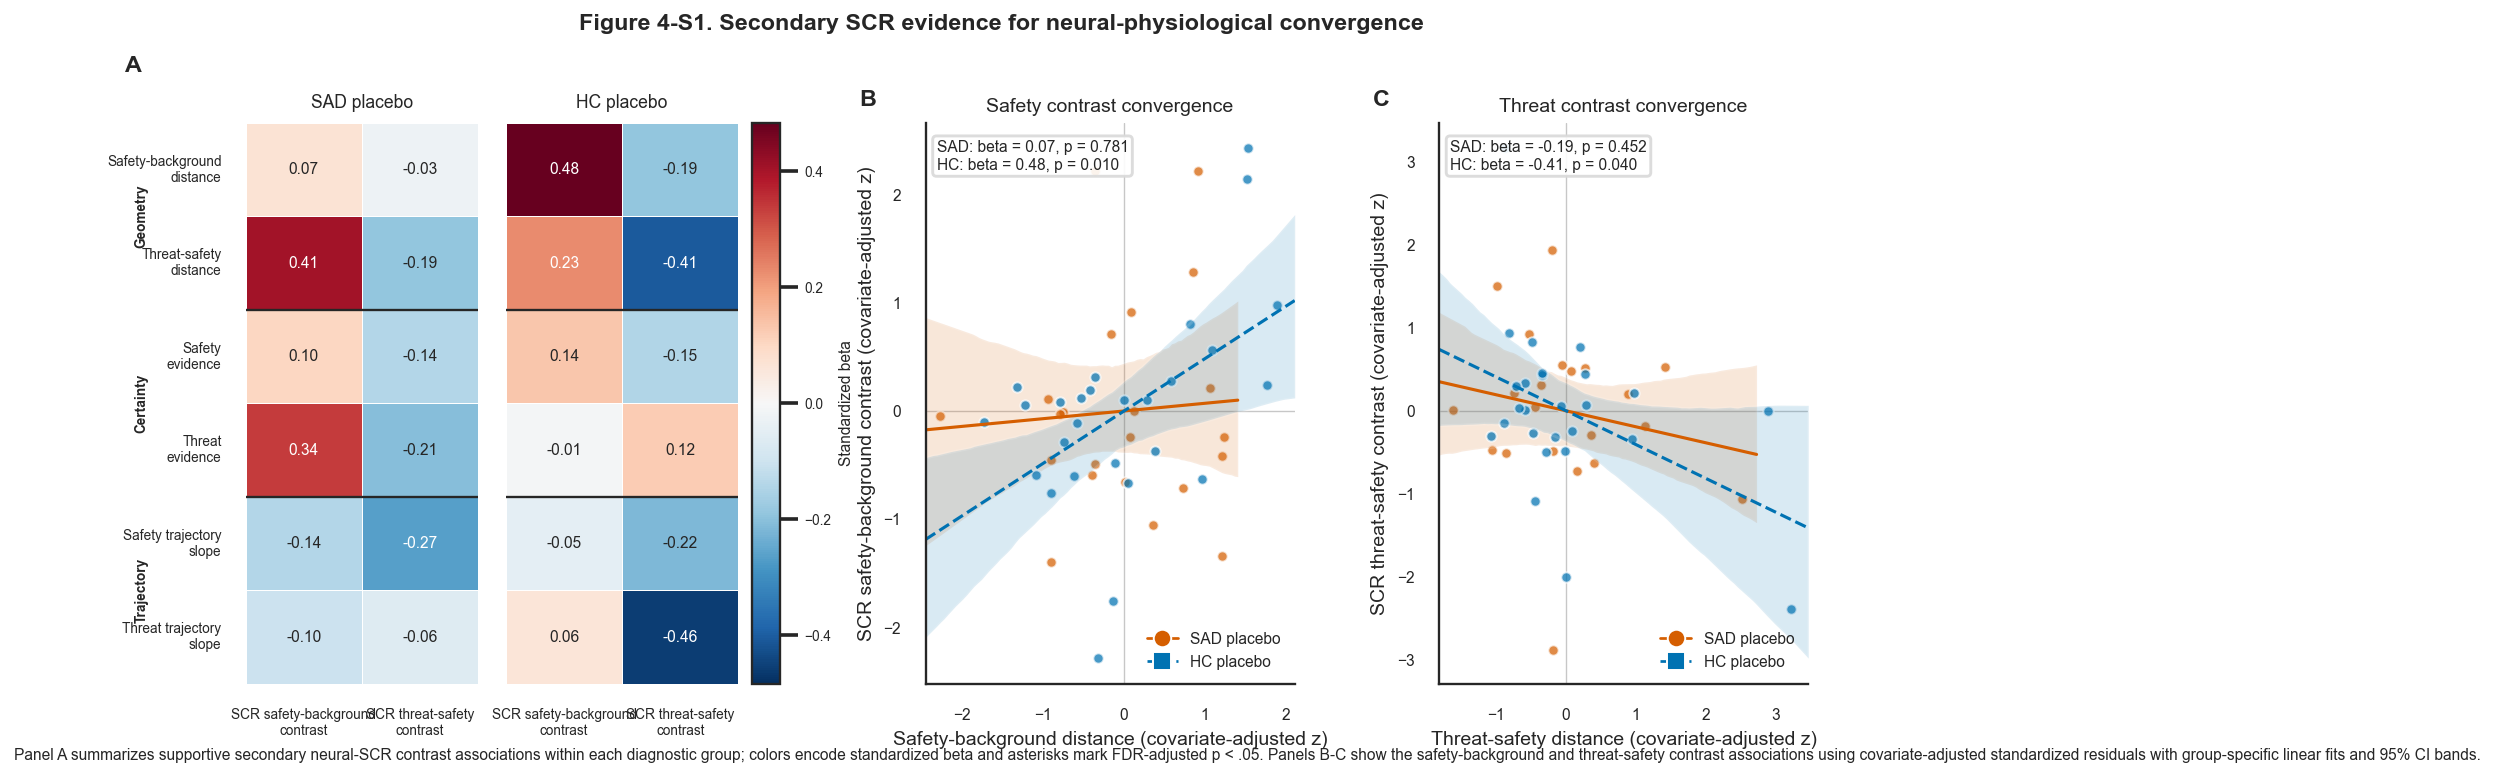

In [21]:
display(Markdown('**Figure 4-S1 / Table S4 Aim 4 secondary supportive SCR evidence:** secondary SCR contrast outcomes are modeled within SAD-placebo and HC-placebo participants and kept separate from primary trajectory-slope convergence.'))

AIM4_SECONDARY_GROUPS = AIM4_PRIMARY_GROUPS
AIM4_SECONDARY_SCR_OUTCOMES = ['SCR_SafetyMinusBackground', 'SCR_ThreatMinusSafety']
AIM4_SECONDARY_NEURAL_PREDICTORS = AIM4_PRIMARY_NEURAL_PREDICTORS
AIM4_SECONDARY_COVARIATE_CANDIDATES = AIM4_PRIMARY_COVARIATE_CANDIDATES
AIM4_SECONDARY_FDR_SCOPE = 'all_secondary_tests'
AIM4_SECONDARY_FIGURE_STEM = 'Figure4S1_Aim4_secondary_neural_SCR_convergence'
AIM4_SECONDARY_TABLE_STEM = 'TableS4_Aim4_secondary_neural_SCR_convergence'
AIM4_SECONDARY_FIGURE_PNG = 'Figure4S1_Aim4_secondary_neural_SCR_convergence.png'
AIM4_SECONDARY_FIGURE_SVG = 'Figure4S1_Aim4_secondary_neural_SCR_convergence.svg'
AIM4_SECONDARY_TABLE_CSV = 'TableS4_Aim4_secondary_neural_SCR_convergence.csv'
AIM4_SECONDARY_TABLE_MD = 'TableS4_Aim4_secondary_neural_SCR_convergence.md'
AIM4_SECONDARY_SCR_LABELS = {
    'SCR_SafetyMinusBackground': 'SCR safety-background\ncontrast',
    'SCR_ThreatMinusSafety': 'SCR threat-safety\ncontrast',
}
AIM4_SECONDARY_METRIC_LABELS = AIM4_PRIMARY_METRIC_LABELS
AIM4_SECONDARY_FAMILY_LABELS = AIM4_PRIMARY_FAMILY_LABELS
AIM4_SECONDARY_FAMILY_ORDER = {'Geometry': 0, 'Certainty': 1, 'Trajectory': 2}
AIM4_SECONDARY_METRIC_FAMILY = dict(zip(AIM4_SECONDARY_NEURAL_PREDICTORS, AIM4_SECONDARY_FAMILY_LABELS))


def prepare_aim4_secondary_data(subject_source_df=None, feature_space='FearNetwork', drug='Placebo'):
    df = subject_source_df if subject_source_df is not None else metrics_df
    if df is None or df.empty:
        raise ValueError('Aim 4 secondary outputs cannot be generated because metrics_df is empty.')
    data = _aim3_add_canonical_neural_metrics(df)
    if 'FeatureSpace' in data.columns:
        data = data[data['FeatureSpace'].astype(str).eq(feature_space)].copy()
    if 'Drug' in data.columns:
        data = data[data['Drug'].astype(str).eq(drug)].copy()
    group_col = _aim3_first_existing(data, ['Group', 'group'])
    subject_col = _aim3_first_existing(data, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    required = [group_col, subject_col] + AIM4_SECONDARY_SCR_OUTCOMES + AIM4_SECONDARY_NEURAL_PREDICTORS
    missing = [col for col in required if col is None or col not in data.columns]
    if missing:
        missing_text = ', '.join(str(col) for col in missing)
        raise ValueError(f'Aim 4 secondary outputs cannot be generated because required columns are missing: {missing_text}')
    keep_cols = [subject_col, group_col] + AIM4_SECONDARY_SCR_OUTCOMES + AIM4_SECONDARY_NEURAL_PREDICTORS + [col for col in AIM4_SECONDARY_COVARIATE_CANDIDATES if col in data.columns]
    out = data[keep_cols].copy()
    out = out.rename(columns={subject_col: 'subject_id', group_col: 'Group'})
    out['Group'] = out['Group'].map(_aim4_clean_group)
    out = out[out['Group'].isin(AIM4_SECONDARY_GROUPS)].copy()
    for col in AIM4_SECONDARY_SCR_OUTCOMES + AIM4_SECONDARY_NEURAL_PREDICTORS + ['demo_age']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.reset_index(drop=True)


def run_aim4_secondary_model(data, group, scr_outcome, neural_predictor, covariates=None):
    covariates = covariates or AIM4_SECONDARY_COVARIATE_CANDIDATES
    model_data = data[data['Group'].eq(group)].copy()
    model_cols = [scr_outcome, neural_predictor] + [c for c in covariates if c in model_data.columns]
    model_data = model_data[model_cols].copy()
    # Missing SCR or neural values are excluded separately for each group/outcome/predictor model.
    model_data = model_data.dropna(subset=[scr_outcome, neural_predictor]).copy()
    model_data['z_scr'], n_scr_outliers = _aim4_stage29_zscore_remove_outliers(model_data[scr_outcome])
    model_data['z_neural'], n_neural_outliers = _aim4_stage29_zscore_remove_outliers(model_data[neural_predictor])
    model_data = model_data.dropna(subset=['z_scr', 'z_neural']).copy()
    X_cov, used_covariates = _aim3_design_matrix(model_data, covariates)
    X = pd.concat([model_data['z_neural'].rename('z_neural'), X_cov.drop(columns=['Intercept'], errors='ignore')], axis=1)
    X.insert(0, 'Intercept', 1.0)
    fit = _aim3_fit_ols(model_data['z_scr'], X)
    if fit is None or 'z_neural' not in fit['params'].index:
        return None, pd.DataFrame()
    covariate_design = X.drop(columns=['z_neural'])
    x_resid = _aim3_residualize(model_data['z_neural'], covariate_design)
    y_resid = _aim3_residualize(model_data['z_scr'], covariate_design)
    plot_data = pd.DataFrame({
        'Group': group,
        'SCR_outcome': scr_outcome,
        'Neural_predictor': neural_predictor,
        'x_resid': x_resid,
        'y_resid': y_resid,
    }).dropna()
    row = {
        'Group': group,
        'SCR_outcome': scr_outcome,
        'Neural_predictor': neural_predictor,
        'neural_metric_category': AIM4_SECONDARY_METRIC_FAMILY.get(neural_predictor, ''),
        'beta_std': float(fit['params']['z_neural']),
        'ci_low': float(fit['ci_low']['z_neural']),
        'ci_high': float(fit['ci_high']['z_neural']),
        't': float(fit['t']['z_neural']),
        'p': float(fit['p']['z_neural']),
        'q_FDR': np.nan,
        'N': int(fit['n']),
        'n_scr_outliers_removed': n_scr_outliers,
        'n_neural_outliers_removed': n_neural_outliers,
        'outlier_rule': f'abs(z) > {AIM4_OUTLIER_Z_THRESHOLD:g}',
        'covariates': ', '.join(used_covariates) if used_covariates else 'none',
        'r2': float(fit['r2']),
        'fdr_scope': AIM4_SECONDARY_FDR_SCOPE,
    }
    return row, plot_data


def fdr_correct_aim4_secondary(results_df, scope=AIM4_SECONDARY_FDR_SCOPE):
    out = results_df.copy()
    out['q_FDR'] = np.nan
    if out.empty:
        return out
    if scope == 'all_secondary_tests':
        out['q_FDR'] = bh_fdr(out['p']).values
    elif scope == 'within_group':
        for _, idx in out.groupby('Group', dropna=False).groups.items():
            out.loc[idx, 'q_FDR'] = bh_fdr(out.loc[idx, 'p']).values
    else:
        raise ValueError(f'Unsupported Aim 4 secondary FDR scope: {scope}')
    return out


def _aim4_secondary_panel_a_heatmaps(results_df, fig, subplot_spec):
    gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_spec, wspace=0.12)
    beta_abs = np.nanmax(np.abs(results_df['beta_std'].to_numpy(dtype=float))) if not results_df.empty else 1.0
    beta_abs = 1.0 if not np.isfinite(beta_abs) or beta_abs == 0 else max(beta_abs, 0.25)
    norm = TwoSlopeNorm(vmin=-beta_abs, vcenter=0.0, vmax=beta_abs)
    cmap = plt.get_cmap('RdBu_r')
    axes = []
    for i, group in enumerate(AIM4_SECONDARY_GROUPS):
        ax = fig.add_subplot(gs[0, i])
        group_results = results_df[results_df['Group'].eq(group)]
        mat = group_results.pivot(index='Neural_predictor', columns='SCR_outcome', values='beta_std').reindex(index=AIM4_SECONDARY_NEURAL_PREDICTORS, columns=AIM4_SECONDARY_SCR_OUTCOMES)
        qmat = group_results.pivot(index='Neural_predictor', columns='SCR_outcome', values='q_FDR').reindex(index=AIM4_SECONDARY_NEURAL_PREDICTORS, columns=AIM4_SECONDARY_SCR_OUTCOMES)
        labels = mat.copy().astype(object)
        for r in range(labels.shape[0]):
            for c in range(labels.shape[1]):
                labels.iloc[r, c] = _aim4_cell_text(float(mat.iloc[r, c]) if pd.notna(mat.iloc[r, c]) else np.nan, qmat.iloc[r, c])
        sns.heatmap(
            mat,
            ax=ax,
            cmap=cmap,
            norm=norm,
            annot=labels,
            fmt='',
            cbar=False,
            linewidths=0.5,
            linecolor='white',
            square=False,
            xticklabels=[AIM4_SECONDARY_SCR_LABELS[col] for col in AIM4_SECONDARY_SCR_OUTCOMES],
            yticklabels=[AIM4_SECONDARY_METRIC_LABELS[row] for row in AIM4_SECONDARY_NEURAL_PREDICTORS],
            annot_kws={'fontsize': 8},
        )
        ax.set_title(f'{group} placebo', fontsize=9, pad=8)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=0, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=7)
        if i == 1:
            ax.set_yticklabels([])
        for boundary in [2, 4]:
            ax.hlines(boundary, *ax.get_xlim(), colors='0.15', linewidth=1.2)
        if i == 0:
            for y, label in zip([1, 3, 5], ['Geometry', 'Certainty', 'Trajectory']):
                ax.text(-0.42, y, label, transform=ax.get_yaxis_transform(), ha='right', va='center', fontsize=7, fontweight='bold', rotation=90)
        axes.append(ax)
    axes[0].text(-0.52, 1.12, 'A', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=axes, fraction=0.055, pad=0.025)
    cbar.set_label('Standardized beta', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    return axes


def _aim4_secondary_scatter_panel(results_df, plot_df, scr_outcome, neural_predictor, ax, panel_label, title):
    ax.axhline(0, color='0.78', linewidth=0.7, zorder=0)
    ax.axvline(0, color='0.78', linewidth=0.7, zorder=0)
    markers = {'SAD': 'o', 'HC': 's'}
    linestyles = {'SAD': '-', 'HC': '--'}
    annotation_lines = []
    for group in AIM4_SECONDARY_GROUPS:
        current = plot_df[(plot_df['Group'].eq(group)) & (plot_df['SCR_outcome'].eq(scr_outcome)) & (plot_df['Neural_predictor'].eq(neural_predictor))]
        color = GROUP_COLORS.get(group, '0.25')
        if current.empty:
            continue
        sns.regplot(
            data=current,
            x='x_resid',
            y='y_resid',
            ax=ax,
            ci=95,
            truncate=False,
            scatter_kws={'s': 28, 'alpha': 0.72, 'marker': markers.get(group, 'o'), 'edgecolor': 'white', 'color': color},
            line_kws={'color': color, 'linewidth': 1.6, 'linestyle': linestyles.get(group, '-')},
        )
        match = results_df[(results_df['Group'].eq(group)) & (results_df['SCR_outcome'].eq(scr_outcome)) & (results_df['Neural_predictor'].eq(neural_predictor))]
        if not match.empty:
            beta = float(match['beta_std'].iloc[0])
            p_value = float(match['p'].iloc[0])
            annotation_lines.append(f'{group}: beta = {beta:.2f}, p = {_aim4_format_p(p_value)}')
    handles = [plt.Line2D([0], [0], marker=markers[group], linestyle=linestyles[group], color=GROUP_COLORS[group], markerfacecolor=GROUP_COLORS[group], markeredgecolor='white', linewidth=1.4, label=f'{group} placebo') for group in AIM4_SECONDARY_GROUPS]
    ax.legend(handles=handles, frameon=False, loc='lower right')
    if annotation_lines:
        ax.text(0.03, 0.97, '\n'.join(annotation_lines), transform=ax.transAxes, ha='left', va='top', fontsize=8, bbox={'boxstyle': 'round,pad=0.25', 'facecolor': 'white', 'edgecolor': '0.85', 'alpha': 0.9})
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(AIM4_SECONDARY_METRIC_LABELS[neural_predictor].replace('\n', ' ') + ' (covariate-adjusted z)')
    ax.set_ylabel(AIM4_SECONDARY_SCR_LABELS[scr_outcome].replace('\n', ' ') + ' (covariate-adjusted z)')
    ax.text(-0.18, 1.06, panel_label, transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    sns.despine(ax=ax)
    return ax


def _aim4_secondary_format_table(stats_df):
    table = stats_df[['Group', 'SCR_outcome', 'Neural_predictor', 'beta_std', 'ci_low', 'ci_high', 't', 'p', 'q_FDR', 'N']].copy()
    table['CI_95'] = table.apply(lambda row: f'[{row["ci_low"]:.2f}, {row["ci_high"]:.2f}]', axis=1)
    table['beta_std'] = table['beta_std'].map(lambda value: f'{value:.2f}')
    table['t'] = table['t'].map(lambda value: f'{value:.2f}')
    table['p'] = table['p'].map(_aim4_format_p)
    table['q_FDR'] = table['q_FDR'].map(_aim4_format_p)
    return table[['Group', 'SCR_outcome', 'Neural_predictor', 'beta_std', 'CI_95', 't', 'p', 'q_FDR', 'N']]


def save_aim4_secondary_outputs(fig, table_df, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    png_path = fig_dir / AIM4_SECONDARY_FIGURE_PNG
    svg_path = fig_dir / AIM4_SECONDARY_FIGURE_SVG
    csv_path = stats_dir / AIM4_SECONDARY_TABLE_CSV
    md_path = stats_dir / AIM4_SECONDARY_TABLE_MD
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(svg_path, bbox_inches='tight')
    table_df.to_csv(csv_path, index=False)
    md_path.write_text('# Table S4. Secondary neural-SCR convergence models\n\n' + table_df.to_markdown(index=False) + '\n')
    print(f'Saved {png_path}')
    print(f'Saved {svg_path}')
    print(f'Saved {csv_path}')
    print(f'Saved {md_path}')
    return {'png': png_path, 'svg': svg_path, 'csv': csv_path, 'md': md_path}


aim4_secondary_data = prepare_aim4_secondary_data(metrics_df)
aim4_secondary_rows = []
aim4_secondary_plot_frames = []
for group in AIM4_SECONDARY_GROUPS:
    for scr_outcome in AIM4_SECONDARY_SCR_OUTCOMES:
        for neural_predictor in AIM4_SECONDARY_NEURAL_PREDICTORS:
            row, plot_data = run_aim4_secondary_model(aim4_secondary_data, group, scr_outcome, neural_predictor)
            if row is not None:
                aim4_secondary_rows.append(row)
            if plot_data is not None and not plot_data.empty:
                aim4_secondary_plot_frames.append(plot_data)

aim4_secondary_statistics = fdr_correct_aim4_secondary(pd.DataFrame(aim4_secondary_rows), scope=AIM4_SECONDARY_FDR_SCOPE)
aim4_secondary_plot_data = pd.concat(aim4_secondary_plot_frames, ignore_index=True, sort=False) if aim4_secondary_plot_frames else pd.DataFrame(columns=['Group', 'SCR_outcome', 'Neural_predictor', 'x_resid', 'y_resid'])
if aim4_secondary_statistics.empty:
    raise ValueError('No Aim 4 secondary models could be fit from the available data.')
expected_n = len(AIM4_SECONDARY_GROUPS) * len(AIM4_SECONDARY_SCR_OUTCOMES) * len(AIM4_SECONDARY_NEURAL_PREDICTORS)
if len(aim4_secondary_statistics) != expected_n:
    raise ValueError(f'Aim 4 secondary table has {len(aim4_secondary_statistics)} rows; expected {expected_n}.')
order_maps = {
    'Group': {group: i for i, group in enumerate(AIM4_SECONDARY_GROUPS)},
    'SCR_outcome': {scr: i for i, scr in enumerate(AIM4_SECONDARY_SCR_OUTCOMES)},
    'neural_metric_category': AIM4_SECONDARY_FAMILY_ORDER,
    'Neural_predictor': {metric: i for i, metric in enumerate(AIM4_SECONDARY_NEURAL_PREDICTORS)},
}
aim4_secondary_statistics = aim4_secondary_statistics.sort_values(['Group', 'SCR_outcome', 'neural_metric_category', 'Neural_predictor'], key=lambda s: s.map(order_maps.get(s.name, {})).fillna(999) if s.name in order_maps else s).reset_index(drop=True)
aim4_secondary_table_s4 = _aim4_secondary_format_table(aim4_secondary_statistics)
display(Markdown('**Table S4. Secondary neural-SCR convergence models:** standardized OLS coefficients are estimated separately within SAD-placebo and HC-placebo participants; q-values use FDR correction across the 24 secondary Aim 4 tests.'))
display(aim4_secondary_table_s4)
fig = plt.figure(figsize=(14.4, 5.2), constrained_layout=False)
outer = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.45, 1.0, 1.0], wspace=0.34)
_aim4_secondary_panel_a_heatmaps(aim4_secondary_statistics, fig, outer[0])
ax_b = fig.add_subplot(outer[1])
ax_c = fig.add_subplot(outer[2])
_aim4_secondary_scatter_panel(aim4_secondary_statistics, aim4_secondary_plot_data, 'SCR_SafetyMinusBackground', 'Neural_Dist_Safety_Background', ax_b, 'B', 'Safety contrast convergence')
_aim4_secondary_scatter_panel(aim4_secondary_statistics, aim4_secondary_plot_data, 'SCR_ThreatMinusSafety', 'Neural_Dist_Threat_Safety', ax_c, 'C', 'Threat contrast convergence')
fig.suptitle('Figure 4-S1. Secondary SCR evidence for neural-physiological convergence', y=1.03, fontsize=12, fontweight='bold')
fig.text(0.01, 0.005, 'Panel A summarizes supportive secondary neural-SCR contrast associations within each diagnostic group; colors encode standardized beta and asterisks mark FDR-adjusted p < .05. Panels B-C show the safety-background and threat-safety contrast associations using covariate-adjusted standardized residuals with group-specific linear fits and 95% CI bands.', fontsize=8)
aim4_secondary_output_paths = save_aim4_secondary_outputs(fig, aim4_secondary_table_s4)
display(fig)
plt.close(fig)


### Aim 4 sensitivity visualization

Controlled by `task_Visualization-Aim4-sensitivity.md`. Figure 4-S2 and Table S5 evaluate robustness of the primary Aim 4 neural-SCR convergence model family after Stage-29 z-score outlier removal across available feature spaces and SCR-defined responder/learner cohorts. Sensitivity outputs use primary SCR trajectory slopes and primary neural metrics only; missing feature spaces, unavailable cohort flags, and insufficient group-specific sample sizes are marked explicitly.


**Figure 4-S2 / Table S5 Aim 4 sensitivity neural-SCR convergence:** feature-space robustness uses the placebo-session model family; SCR-defined responder/learner cohort robustness pools placebo and oxytocin participants within subgroup and includes Drug as a covariate.

**Table S5. Sensitivity analysis of Aim 4 neural-SCR convergence:** q-values are FDR-corrected separately for feature-space and SCR-cohort sensitivity families after Stage-29 z-score outlier removal; SCR-cohort rows pool placebo and oxytocin participants and include Drug as a covariate when available; non-estimated rows record missing variables or insufficient group-specific N.

,Sensitivity_type,Group,Feature_space,SCR_cohort,SCR_outcome,Neural_predictor,Model_label,beta_std,CI_95,t,p,q_FDR,N,n_scr_outliers_removed,n_neural_outliers_removed,outlier_rule,Covariates,Status
0,Feature_space,SAD,FearNetwork,All,SCR_Safety_Trajectory_Slope,Neural_Dist_Safety_Background,Safety geometry,-0.050290,"[-0.61, 0.51]",-0.188891,0.852415,0.948117,21,1,0,abs(z) > 3,"demo_age, Gender",estimated
1,Feature_space,SAD,FearNetwork,All,SCR_Safety_Trajectory_Slope,Neural_Dist_Threat_Safety,Neural_Dist_Threat_Safety -> SCR_Safety_Trajec...,0.292235,"[-0.20, 0.79]",1.249586,0.228382,0.910237,21,1,0,abs(z) > 3,"demo_age, Gender",estimated
2,Feature_space,SAD,FearNetwork,All,SCR_Safety_Trajectory_Slope,Neural_SafetyEvidence,Safety certainty,-0.331335,"[-0.82, 0.16]",-1.422686,0.172918,0.910237,21,1,0,abs(z) > 3,"demo_age, Gender",estimated
3,Feature_space,SAD,FearNetwork,All,SCR_Safety_Trajectory_Slope,Neural_ThreatEvidence,Neural_ThreatEvidence -> SCR_Safety_Trajectory...,0.030520,"[-0.52, 0.58]",0.116512,0.908612,0.948117,21,1,0,abs(z) > 3,"demo_age, Gender",estimated
4,Feature_space,SAD,FearNetwork,All,SCR_Safety_Trajectory_Slope,Neural_Safety_Trajectory_Slope,Safety trajectory,-0.120646,"[-0.74, 0.50]",-0.410300,0.687027,0.910237,20,1,1,abs(z) > 3,"demo_age, Gender",estimated
5,Feature_space,SAD,FearNetwork,All,SCR_Safety_Trajectory_Slope,Neural_Threat_Trajectory_Slope,Neural_Threat_Trajectory_Slope -> SCR_Safety_T...,-0.116227,"[-0.61, 0.38]",-0.493234,0.628158,0.910237,21,1,0,abs(z) > 3,"demo_age, Gender",estimated
6,Feature_space,SAD,FearNetwork,All,SCR_Threat_Trajectory_Slope,Neural_Dist_Safety_Background,Neural_Dist_Safety_Background -> SCR_Threat_Tr...,0.160352,"[-0.35, 0.67]",0.659998,0.518098,0.910237,21,1,0,abs(z) > 3,"demo_age, Gender",estimated
7,Feature_space,SAD,FearNetwork,All,SCR_Threat_Trajectory_Slope,Neural_Dist_Threat_Safety,Threat geometry,0.222877,"[-0.25, 0.70]",0.989685,0.336206,0.910237,21,1,0,abs(z) > 3,"demo_age, Gender",estimated
8,Feature_space,SAD,FearNetwork,All,SCR_Threat_Trajectory_Slope,Neural_SafetyEvidence,Neural_SafetyEvidence -> SCR_Threat_Trajectory...,0.187896,"[-0.27, 0.64]",0.870266,0.396278,0.910237,21,1,0,abs(z) > 3,"demo_age, Gender",estimated
9,Feature_space,SAD,FearNetwork,All,SCR_Threat_Trajectory_Slope,Neural_ThreatEvidence,Threat certainty,0.056434,"[-0.45, 0.57]",0.234062,0.817732,0.934551,21,1,0,abs(z) > 3,"demo_age, Gender",estimated


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure4S2_Aim4_sensitivity_neural_SCR_convergence.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure4S2_Aim4_sensitivity_neural_SCR_convergence.svg
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/TableS5_Aim4_sensitivity_neural_SCR_convergence.csv
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/TableS5_Aim4_sensitivity_neural_SCR_convergence.md


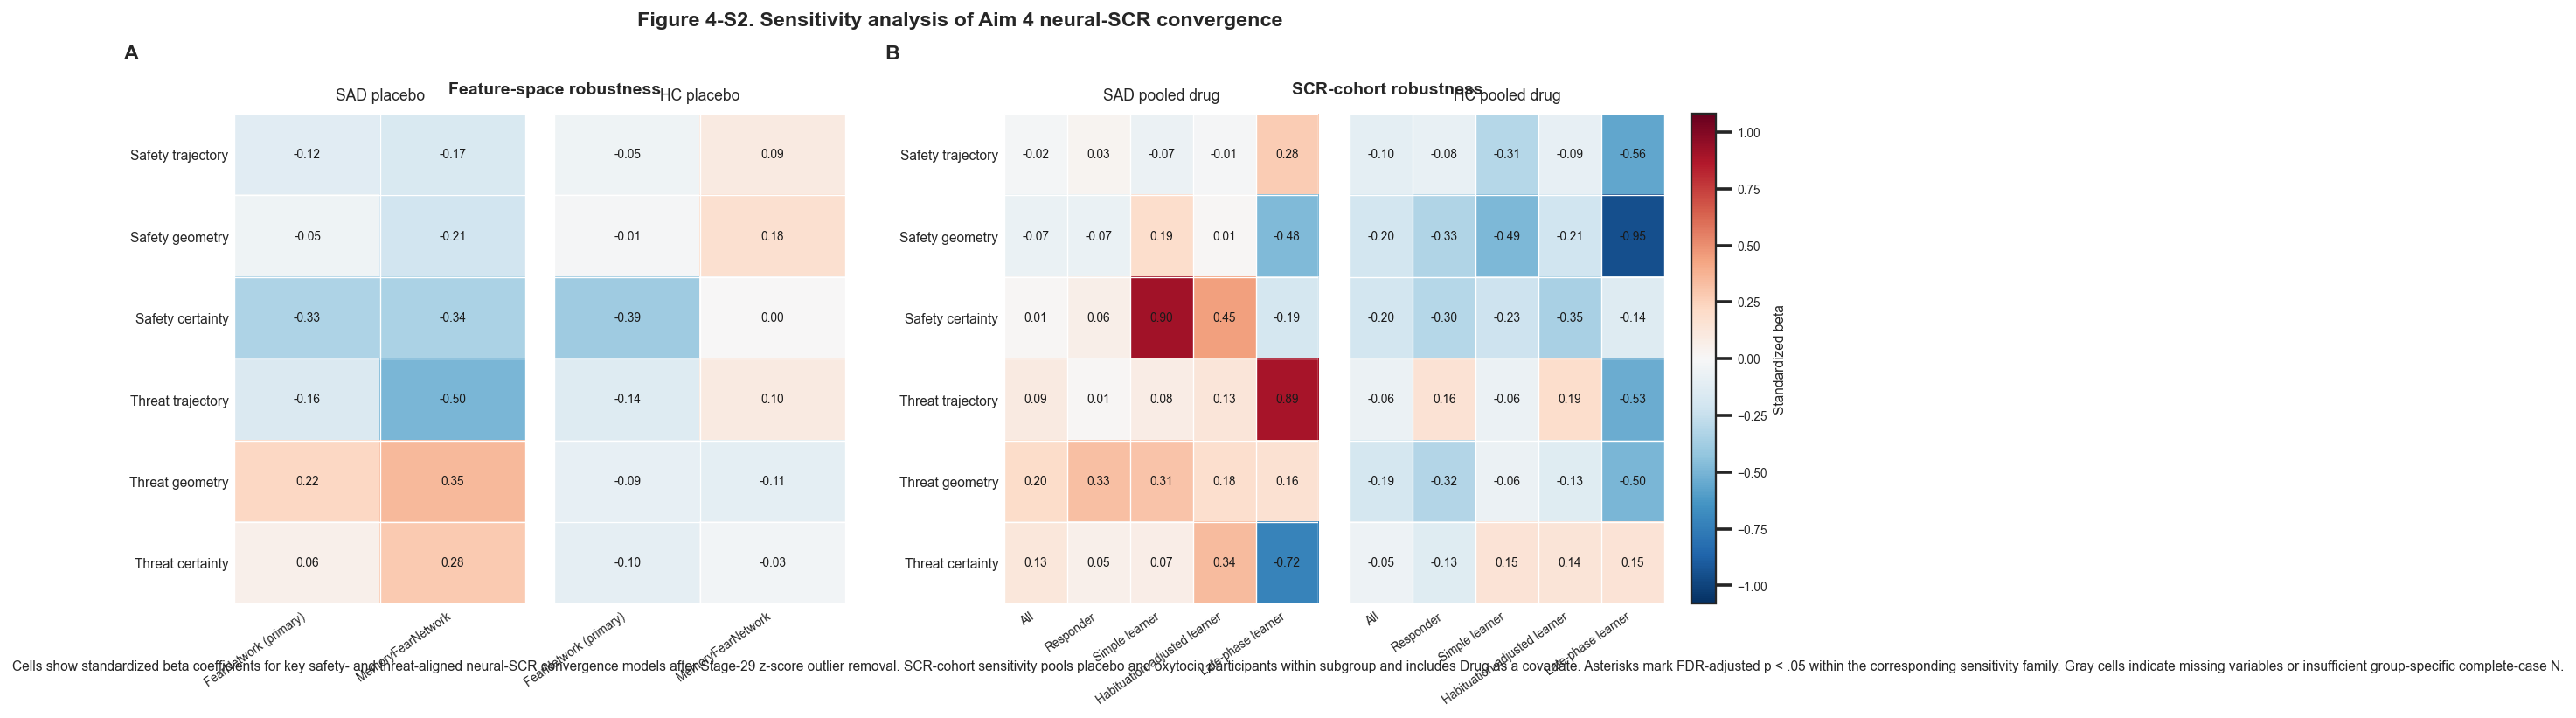

In [22]:
display(Markdown('**Figure 4-S2 / Table S5 Aim 4 sensitivity neural-SCR convergence:** feature-space robustness uses the placebo-session model family; SCR-defined responder/learner cohort robustness pools placebo and oxytocin participants within subgroup and includes Drug as a covariate.'))

AIM4_SENSITIVITY_GROUPS = AIM4_PRIMARY_GROUPS
AIM4_SENSITIVITY_SCR_OUTCOMES = AIM4_PRIMARY_SCR_OUTCOMES
AIM4_SENSITIVITY_NEURAL_PREDICTORS = AIM4_PRIMARY_NEURAL_PREDICTORS
AIM4_SENSITIVITY_COVARIATE_CANDIDATES = AIM4_PRIMARY_COVARIATE_CANDIDATES
AIM4_SCR_COHORT_COVARIATES = AIM4_PRIMARY_COVARIATE_CANDIDATES + ['Drug']
AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE = 'FearNetwork'
AIM4_SENSITIVITY_DRUG_FILTER = 'Placebo'
AIM4_SCR_COHORT_DRUG_FILTER = None
AIM4_SENSITIVITY_MIN_N = 10
AIM4_SENSITIVITY_FIGURE_STEM = 'Figure4S2_Aim4_sensitivity_neural_SCR_convergence'
AIM4_SENSITIVITY_TABLE_STEM = 'TableS5_Aim4_sensitivity_neural_SCR_convergence'
AIM4_SENSITIVITY_REQUIRED_FEATURE_SPACES = ['FearNetwork', 'MemoryFearNetwork']
AIM4_SENSITIVITY_FEATURE_SPACE_ORDER = ['FearNetwork', 'MemoryFearNetwork', 'Schaefer_Tian', 'Schaefer', 'Tian', 'WholeBrain', 'WholeBrain_Parcellation', 'WholeBrain_Schaefer']
AIM4_SENSITIVITY_COHORT_ORDER = [
    'All',
    'SCR_Physiological_Responder',
    'SCR_Simple_Acquisition_Differential_Learner',
    'SCR_Habituation_Adjusted_Learner',
    'SCR_Late_Phase_Sensitivity_Learner',
]
AIM4_SENSITIVITY_MODEL_PAIRS = [
    (
        f"{PRIMARY_NEURAL_METRIC_FAMILIES.get(neural, 'Neural')} -> {scr.replace('SCR_', '').replace('_Trajectory_Slope', '').replace('_', ' ').lower()}",
        scr,
        neural,
    )
    for scr in AIM4_SENSITIVITY_SCR_OUTCOMES
    for neural in AIM4_SENSITIVITY_NEURAL_PREDICTORS
]
AIM4_SENSITIVITY_MODEL_LABELS = {
    (scr, neural): label
    for label, scr, neural in AIM4_SENSITIVITY_MODEL_PAIRS
}
AIM4_SENSITIVITY_COHORT_LABELS = {
    'All': 'All',
    'SCR_Physiological_Responder': 'Responder',
    'SCR_Simple_Acquisition_Differential_Learner': 'Simple learner',
    'SCR_Habituation_Adjusted_Learner': 'Habituation-adjusted learner',
    'SCR_Late_Phase_Sensitivity_Learner': 'Late-phase learner',
}
AIM4_SENSITIVITY_FEATURE_LABELS = {
    'FearNetwork': 'FearNetwork (primary)',
    'MemoryFearNetwork': 'MemoryFearNetwork',
    'Schaefer_Tian': 'Schaefer/Tian',
    'Schaefer': 'Schaefer',
    'Tian': 'Tian',
    'WholeBrain': 'Whole brain',
    'WholeBrain_Parcellation': 'Whole brain',
    'WholeBrain_Schaefer': 'Whole brain',
}


def _aim4_sensitivity_subject_col(df):
    return _aim3_first_existing(df, ['subject_id', 'Subject', 'sub_ID', 'sub'])


def _aim4_sensitivity_ordered_values(observed, preferred):
    observed = [str(value) for value in observed if pd.notna(value)]
    lower_to_observed = {value.casefold(): value for value in observed}
    ordered = []
    for value in preferred:
        match = lower_to_observed.get(value.casefold())
        if match is not None and match not in ordered:
            ordered.append(match)
    ordered.extend(sorted(value for value in observed if value not in ordered))
    return ordered


def _aim4_sensitivity_base_data(subject_source_df=None, drug=AIM4_SENSITIVITY_DRUG_FILTER):
    df = subject_source_df if subject_source_df is not None else metrics_df
    if df is None or df.empty:
        print('Aim 4 sensitivity outputs cannot be generated because metrics_df is empty.')
        return pd.DataFrame()
    if 'FeatureSpace' in df.columns:
        data = pd.concat(
            [
                _aim3_add_canonical_neural_metrics(feature_df.copy(), feature_space=str(feature_space))
                for feature_space, feature_df in df.groupby(df['FeatureSpace'].astype(str), dropna=False)
            ],
            ignore_index=True,
        )
    else:
        data = _aim3_add_canonical_neural_metrics(df, feature_space=AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE)
    subject_col = _aim4_sensitivity_subject_col(data)
    if subject_col is not None and isinstance(scr_flags_df, pd.DataFrame) and not scr_flags_df.empty:
        flags_subject_col = _aim4_sensitivity_subject_col(scr_flags_df)
        missing_flags = [col for col in AIM4_SENSITIVITY_COHORT_ORDER if col != 'All' and col not in data.columns and col in scr_flags_df.columns]
        if flags_subject_col is not None and missing_flags:
            flag_cols = [flags_subject_col] + missing_flags
            data = data.merge(scr_flags_df[flag_cols].drop_duplicates(flags_subject_col), left_on=subject_col, right_on=flags_subject_col, how='left')
            if flags_subject_col != subject_col and flags_subject_col in data.columns:
                data = data.drop(columns=flags_subject_col)
    if drug is not None and 'Drug' in data.columns:
        data = data[data['Drug'].astype(str).eq(str(drug))].copy()
    group_col = _aim3_first_existing(data, ['Group', 'group'])
    subject_col = _aim4_sensitivity_subject_col(data)
    if group_col is None or subject_col is None:
        print('Aim 4 sensitivity outputs cannot be generated because group or subject identifiers are missing.')
        return pd.DataFrame()
    data = data.rename(columns={group_col: 'Group', subject_col: 'subject_id'})
    data['Group'] = data['Group'].map(_aim4_clean_group)
    data = data[data['Group'].isin(AIM4_SENSITIVITY_GROUPS)].copy()
    for col in AIM4_SENSITIVITY_SCR_OUTCOMES + AIM4_SENSITIVITY_NEURAL_PREDICTORS + ['demo_age']:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
    return data.reset_index(drop=True)


def _aim4_sensitivity_model_label(scr_outcome, neural_predictor):
    return AIM4_SENSITIVITY_MODEL_LABELS.get((scr_outcome, neural_predictor), f'{neural_predictor} -> {scr_outcome}')


def _aim4_sensitivity_flag_mask(series):
    if series.dtype == bool:
        return series.fillna(False)
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce').fillna(0).ne(0)
    normalized = series.astype('string').str.strip().str.lower()
    return normalized.isin(['1', 'true', 't', 'yes', 'y'])


def _aim4_sensitivity_missing_row(sensitivity_type, group, feature_space, scr_cohort, scr_outcome, neural_predictor, status, reason, n=0):
    return {
        'Sensitivity_type': sensitivity_type,
        'Group': group,
        'Feature_space': feature_space,
        'SCR_cohort': scr_cohort,
        'SCR_outcome': scr_outcome,
        'Neural_predictor': neural_predictor,
        'Model_label': _aim4_sensitivity_model_label(scr_outcome, neural_predictor),
        'beta_std': np.nan,
        'ci_low': np.nan,
        'ci_high': np.nan,
        'CI_95': 'NA',
        't': np.nan,
        'p': np.nan,
        'q_FDR': np.nan,
        'N': int(n) if pd.notna(n) else 0,
        'n_scr_outliers_removed': 0,
        'n_neural_outliers_removed': 0,
        'outlier_rule': f'abs(z) > {AIM4_OUTLIER_Z_THRESHOLD:g}',
        'Covariates': 'none',
        'Status': status,
        'Reason': reason,
    }


def _aim4_sensitivity_fit_model(data, sensitivity_type, group, feature_space, scr_cohort, scr_outcome, neural_predictor, covariates=None):
    covariates = covariates or AIM4_SENSITIVITY_COVARIATE_CANDIDATES
    missing = [col for col in [scr_outcome, neural_predictor] if col not in data.columns]
    if missing:
        return _aim4_sensitivity_missing_row(sensitivity_type, group, feature_space, scr_cohort, scr_outcome, neural_predictor, 'missing_variable', ', '.join(missing))
    if 'Group' not in data.columns:
        return _aim4_sensitivity_missing_row(sensitivity_type, group, feature_space, scr_cohort, scr_outcome, neural_predictor, 'missing_variable', 'Group')
    model_data = data[data['Group'].eq(group)].copy()
    model_cols = [scr_outcome, neural_predictor] + [col for col in covariates if col in model_data.columns]
    model_data = model_data[model_cols].dropna(subset=[scr_outcome, neural_predictor]).copy()
    n_available = int(len(model_data))
    if n_available < AIM4_SENSITIVITY_MIN_N:
        return _aim4_sensitivity_missing_row(sensitivity_type, group, feature_space, scr_cohort, scr_outcome, neural_predictor, 'insufficient_N', f'N < {AIM4_SENSITIVITY_MIN_N}', n_available)
    model_data['z_scr'], n_scr_outliers = _aim4_stage29_zscore_remove_outliers(model_data[scr_outcome])
    model_data['z_neural'], n_neural_outliers = _aim4_stage29_zscore_remove_outliers(model_data[neural_predictor])
    model_data = model_data.dropna(subset=['z_scr', 'z_neural']).copy()
    if len(model_data) < AIM4_SENSITIVITY_MIN_N:
        return _aim4_sensitivity_missing_row(sensitivity_type, group, feature_space, scr_cohort, scr_outcome, neural_predictor, 'insufficient_N', f'complete-case N < {AIM4_SENSITIVITY_MIN_N}', len(model_data))
    X_cov, used_covariates = _aim3_design_matrix(model_data, covariates)
    X = pd.concat([model_data['z_neural'].rename('z_neural'), X_cov.drop(columns=['Intercept'], errors='ignore')], axis=1)
    X.insert(0, 'Intercept', 1.0)
    fit = _aim3_fit_ols(model_data['z_scr'], X)
    if fit is None or 'z_neural' not in fit['params'].index:
        return _aim4_sensitivity_missing_row(sensitivity_type, group, feature_space, scr_cohort, scr_outcome, neural_predictor, 'insufficient_N', 'model degrees of freedom unavailable', len(model_data))
    return {
        'Sensitivity_type': sensitivity_type,
        'Group': group,
        'Feature_space': feature_space,
        'SCR_cohort': scr_cohort,
        'SCR_outcome': scr_outcome,
        'Neural_predictor': neural_predictor,
        'Model_label': _aim4_sensitivity_model_label(scr_outcome, neural_predictor),
        'beta_std': float(fit['params']['z_neural']),
        'ci_low': float(fit['ci_low']['z_neural']),
        'ci_high': float(fit['ci_high']['z_neural']),
        'CI_95': f'[{float(fit["ci_low"]["z_neural"]):.2f}, {float(fit["ci_high"]["z_neural"]):.2f}]',
        't': float(fit['t']['z_neural']),
        'p': float(fit['p']['z_neural']),
        'q_FDR': np.nan,
        'N': int(fit['n']),
        'n_scr_outliers_removed': n_scr_outliers,
        'n_neural_outliers_removed': n_neural_outliers,
        'outlier_rule': f'abs(z) > {AIM4_OUTLIER_Z_THRESHOLD:g}',
        'Covariates': ', '.join(used_covariates) if used_covariates else 'none',
        'Status': 'estimated',
        'Reason': '',
    }


def build_aim4_sensitivity_statistics(subject_source_df=None):
    feature_data = _aim4_sensitivity_base_data(subject_source_df, drug=AIM4_SENSITIVITY_DRUG_FILTER)
    cohort_base_data = _aim4_sensitivity_base_data(subject_source_df, drug=AIM4_SCR_COHORT_DRUG_FILTER)
    rows = []
    if feature_data.empty and cohort_base_data.empty:
        return pd.DataFrame()
    if 'FeatureSpace' in feature_data.columns:
        feature_spaces = _aim4_sensitivity_ordered_values(feature_data['FeatureSpace'].dropna().astype(str).unique(), AIM4_SENSITIVITY_FEATURE_SPACE_ORDER)
    else:
        feature_spaces = [AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE]
        if not feature_data.empty:
            feature_data['FeatureSpace'] = AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE
    unavailable_features = [space for space in AIM4_SENSITIVITY_REQUIRED_FEATURE_SPACES if space not in feature_spaces]
    if unavailable_features:
        print('Unavailable required Aim 4 sensitivity feature spaces: ' + ', '.join(unavailable_features))
    feature_spaces = _aim4_sensitivity_ordered_values(feature_spaces + AIM4_SENSITIVITY_REQUIRED_FEATURE_SPACES, AIM4_SENSITIVITY_FEATURE_SPACE_ORDER)
    for feature_space in feature_spaces:
        fs_data = feature_data[feature_data['FeatureSpace'].astype(str).eq(feature_space)].copy() if not feature_data.empty else pd.DataFrame()
        for group in AIM4_SENSITIVITY_GROUPS:
            for scr_outcome in AIM4_SENSITIVITY_SCR_OUTCOMES:
                for neural_predictor in AIM4_SENSITIVITY_NEURAL_PREDICTORS:
                    rows.append(_aim4_sensitivity_fit_model(fs_data, 'Feature_space', group, feature_space, 'All', scr_outcome, neural_predictor))
    primary_data = cohort_base_data[cohort_base_data['FeatureSpace'].astype(str).eq(AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE)].copy() if not cohort_base_data.empty else pd.DataFrame()
    if primary_data.empty:
        print(f'Primary feature space {AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE} is unavailable for SCR-cohort sensitivity.')
    unavailable_cohorts = [cohort for cohort in AIM4_SENSITIVITY_COHORT_ORDER if cohort != 'All' and cohort not in primary_data.columns]
    if unavailable_cohorts:
        print('Unavailable Aim 4 sensitivity SCR cohort flags: ' + ', '.join(unavailable_cohorts))
    for cohort in AIM4_SENSITIVITY_COHORT_ORDER:
        if cohort == 'All':
            cohort_data = primary_data.copy()
            cohort_missing = False
        elif cohort in primary_data.columns:
            cohort_data = primary_data[_aim4_sensitivity_flag_mask(primary_data[cohort])].copy()
            cohort_missing = False
        else:
            cohort_data = pd.DataFrame()
            cohort_missing = True
        for group in AIM4_SENSITIVITY_GROUPS:
            for scr_outcome in AIM4_SENSITIVITY_SCR_OUTCOMES:
                for neural_predictor in AIM4_SENSITIVITY_NEURAL_PREDICTORS:
                    if cohort_missing:
                        rows.append(_aim4_sensitivity_missing_row('SCR_cohort', group, AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE, cohort, scr_outcome, neural_predictor, 'missing_variable', cohort))
                    else:
                        rows.append(_aim4_sensitivity_fit_model(cohort_data, 'SCR_cohort', group, AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE, cohort, scr_outcome, neural_predictor, covariates=AIM4_SCR_COHORT_COVARIATES))
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out['q_FDR'] = np.nan
    estimated = out['Status'].eq('estimated')
    for _, idx in out[estimated].groupby('Sensitivity_type', dropna=False).groups.items():
        out.loc[idx, 'q_FDR'] = bh_fdr(out.loc[idx, 'p']).values
    out.loc[out['Status'].eq('estimated'), 'CI_95'] = out.loc[out['Status'].eq('estimated')].apply(lambda row: f'[{row["ci_low"]:.2f}, {row["ci_high"]:.2f}]', axis=1)
    group_order = {group: i for i, group in enumerate(AIM4_SENSITIVITY_GROUPS)}
    feature_order = {feature: i for i, feature in enumerate(feature_spaces)}
    cohort_order = {cohort: i for i, cohort in enumerate(AIM4_SENSITIVITY_COHORT_ORDER)}
    scr_order = {scr: i for i, scr in enumerate(AIM4_SENSITIVITY_SCR_OUTCOMES)}
    neural_order = {neural: i for i, neural in enumerate(AIM4_SENSITIVITY_NEURAL_PREDICTORS)}
    type_order = {'Feature_space': 0, 'SCR_cohort': 1}
    out = out.assign(
        _type_order=out['Sensitivity_type'].map(type_order).fillna(99),
        _group_order=out['Group'].map(group_order).fillna(99),
        _feature_order=out['Feature_space'].map(feature_order).fillna(99),
        _cohort_order=out['SCR_cohort'].map(cohort_order).fillna(99),
        _scr_order=out['SCR_outcome'].map(scr_order).fillna(99),
        _neural_order=out['Neural_predictor'].map(neural_order).fillna(99),
    ).sort_values(['_type_order', '_group_order', '_feature_order', '_cohort_order', '_scr_order', '_neural_order']).drop(columns=['_type_order', '_group_order', '_feature_order', '_cohort_order', '_scr_order', '_neural_order']).reset_index(drop=True)
    return out


def _aim4_sensitivity_heatmap_panel(results_df, fig, subplot_spec, sensitivity_type, column_values, column_label_map, panel_label, panel_title, norm):
    gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_spec, wspace=0.10)
    cmap = plt.get_cmap('RdBu_r').copy()
    cmap.set_bad('#EFEFEF')
    axes = []
    row_labels = [label for label, _, _ in AIM4_SENSITIVITY_MODEL_PAIRS]
    for i, group in enumerate(AIM4_SENSITIVITY_GROUPS):
        ax = fig.add_subplot(gs[0, i])
        mat = pd.DataFrame(np.nan, index=row_labels, columns=column_values, dtype=float)
        text = pd.DataFrame('', index=row_labels, columns=column_values, dtype=object)
        for label, scr_outcome, neural_predictor in AIM4_SENSITIVITY_MODEL_PAIRS:
            for column in column_values:
                if sensitivity_type == 'Feature_space':
                    match = results_df[
                        results_df['Sensitivity_type'].eq(sensitivity_type)
                        & results_df['Group'].eq(group)
                        & results_df['Feature_space'].eq(column)
                        & results_df['SCR_cohort'].eq('All')
                        & results_df['SCR_outcome'].eq(scr_outcome)
                        & results_df['Neural_predictor'].eq(neural_predictor)
                    ]
                else:
                    match = results_df[
                        results_df['Sensitivity_type'].eq(sensitivity_type)
                        & results_df['Group'].eq(group)
                        & results_df['Feature_space'].eq(AIM4_SENSITIVITY_PRIMARY_FEATURE_SPACE)
                        & results_df['SCR_cohort'].eq(column)
                        & results_df['SCR_outcome'].eq(scr_outcome)
                        & results_df['Neural_predictor'].eq(neural_predictor)
                    ]
                if match.empty:
                    text.loc[label, column] = 'NA'
                    continue
                row = match.iloc[0]
                if row['Status'] == 'estimated':
                    mat.loc[label, column] = row['beta_std']
                    marker = '*' if pd.notna(row['q_FDR']) and row['q_FDR'] < 0.05 else ''
                    text.loc[label, column] = f'{row["beta_std"]:.2f}{marker}'
                elif row['Status'] == 'insufficient_N':
                    text.loc[label, column] = 'n<10'
                else:
                    text.loc[label, column] = 'NA'
        ax.imshow(np.ma.masked_invalid(mat.to_numpy(dtype=float)), cmap=cmap, norm=norm, aspect='auto')
        ax.set_xticks(np.arange(len(column_values)))
        ax.set_xticklabels([column_label_map.get(value, value) for value in column_values], rotation=35, ha='right', fontsize=7)
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_yticklabels(row_labels if i == 0 else [], fontsize=8)
        session_label = 'placebo' if sensitivity_type == 'Feature_space' else 'pooled drug'
        ax.set_title(f'{group} {session_label}', fontsize=9, pad=8)
        ax.tick_params(length=0)
        for y in np.arange(len(row_labels) + 1) - 0.5:
            ax.axhline(y, color='white', linewidth=0.7)
        for x in np.arange(len(column_values) + 1) - 0.5:
            ax.axvline(x, color='white', linewidth=0.7)
        for r, row_label in enumerate(row_labels):
            for c, column in enumerate(column_values):
                ax.text(c, r, text.loc[row_label, column], ha='center', va='center', fontsize=7, color='0.10')
        for spine in ax.spines.values():
            spine.set_visible(False)
        axes.append(ax)
    axes[0].text(-0.38, 1.14, panel_label, transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    fig.text((subplot_spec.get_position(fig).x0 + subplot_spec.get_position(fig).x1) / 2, subplot_spec.get_position(fig).y1 + 0.025, panel_title, ha='center', va='bottom', fontsize=10, fontweight='bold')
    return axes


def save_aim4_sensitivity_outputs(fig, table_df, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    png_path = fig_dir / f'{AIM4_SENSITIVITY_FIGURE_STEM}.png'
    svg_path = fig_dir / f'{AIM4_SENSITIVITY_FIGURE_STEM}.svg'
    csv_path = stats_dir / f'{AIM4_SENSITIVITY_TABLE_STEM}.csv'
    md_path = stats_dir / f'{AIM4_SENSITIVITY_TABLE_STEM}.md'
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(svg_path, bbox_inches='tight')
    table_df.to_csv(csv_path, index=False)
    md_path.write_text('# Table S5. Sensitivity analysis of Aim 4 neural-SCR convergence\n\n' + table_df.to_markdown(index=False) + '\n')
    print(f'Saved {png_path}')
    print(f'Saved {svg_path}')
    print(f'Saved {csv_path}')
    print(f'Saved {md_path}')
    return {'png': png_path, 'svg': svg_path, 'csv': csv_path, 'md': md_path}


aim4_sensitivity_statistics = build_aim4_sensitivity_statistics(metrics_df)
if aim4_sensitivity_statistics.empty:
    raise ValueError('No Aim 4 sensitivity rows could be generated from the available data.')

aim4_sensitivity_table_s5 = aim4_sensitivity_statistics[
    ['Sensitivity_type', 'Group', 'Feature_space', 'SCR_cohort', 'SCR_outcome', 'Neural_predictor', 'Model_label', 'beta_std', 'CI_95', 't', 'p', 'q_FDR', 'N', 'n_scr_outliers_removed', 'n_neural_outliers_removed', 'outlier_rule', 'Covariates', 'Status']
].copy()
display(Markdown('**Table S5. Sensitivity analysis of Aim 4 neural-SCR convergence:** q-values are FDR-corrected separately for feature-space and SCR-cohort sensitivity families after Stage-29 z-score outlier removal; SCR-cohort rows pool placebo and oxytocin participants and include Drug as a covariate when available; non-estimated rows record missing variables or insufficient group-specific N.'))
display(aim4_sensitivity_table_s5)

estimated_betas = pd.to_numeric(aim4_sensitivity_statistics.loc[aim4_sensitivity_statistics['Status'].eq('estimated'), 'beta_std'], errors='coerce')
beta_abs = float(np.nanmax(np.abs(estimated_betas))) if estimated_betas.notna().any() else 1.0
beta_abs = 1.0 if not np.isfinite(beta_abs) or beta_abs == 0 else max(beta_abs, 0.25)
norm = TwoSlopeNorm(vmin=-beta_abs, vcenter=0.0, vmax=beta_abs)
feature_columns = _aim4_sensitivity_ordered_values(
    aim4_sensitivity_statistics.loc[aim4_sensitivity_statistics['Sensitivity_type'].eq('Feature_space'), 'Feature_space'].dropna().unique(),
    AIM4_SENSITIVITY_FEATURE_SPACE_ORDER,
)
cohort_columns = [cohort for cohort in AIM4_SENSITIVITY_COHORT_ORDER if cohort in set(aim4_sensitivity_statistics.loc[aim4_sensitivity_statistics['Sensitivity_type'].eq('SCR_cohort'), 'SCR_cohort'])]
fig = plt.figure(figsize=(15.8, 5.2), constrained_layout=False)
outer = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.0, 1.08], wspace=0.25)
axes_a = _aim4_sensitivity_heatmap_panel(aim4_sensitivity_statistics, fig, outer[0], 'Feature_space', feature_columns, AIM4_SENSITIVITY_FEATURE_LABELS, 'A', 'Feature-space robustness', norm)
axes_b = _aim4_sensitivity_heatmap_panel(aim4_sensitivity_statistics, fig, outer[1], 'SCR_cohort', cohort_columns, AIM4_SENSITIVITY_COHORT_LABELS, 'B', 'SCR-cohort robustness', norm)
sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.get_cmap('RdBu_r'))
cbar = fig.colorbar(sm, ax=axes_a + axes_b, fraction=0.028, pad=0.018)
cbar.set_label('Standardized beta', fontsize=8)
cbar.ax.tick_params(labelsize=7)
fig.suptitle('Figure 4-S2. Sensitivity analysis of Aim 4 neural-SCR convergence', y=1.04, fontsize=12, fontweight='bold')
fig.text(0.01, 0.006, 'Cells show standardized beta coefficients for key safety- and threat-aligned neural-SCR convergence models after Stage-29 z-score outlier removal. SCR-cohort sensitivity pools placebo and oxytocin participants within subgroup and includes Drug as a covariate. Asterisks mark FDR-adjusted p < .05 within the corresponding sensitivity family. Gray cells indicate missing variables or insufficient group-specific complete-case N.', fontsize=8)
aim4_sensitivity_output_paths = save_aim4_sensitivity_outputs(fig, aim4_sensitivity_table_s5)
display(fig)
plt.close(fig)




### Aim 4 whitelist implementation checklist

The table below records the Aim 4 outputs retained in this notebook and their controlling task file. The removed-items table is intentionally explicit so future edits can tell whether legacy/exploratory Aim 4 blocks were kept, removed, or never present in the cleaned section.


In [23]:
aim4_whitelist_checklist = pd.DataFrame([
    {
        'task_file': 'task_Visualization-Aim4-primary.md',
        'allowed_item': 'Figure 4 primary neural-SCR convergence: Panel A group-specific association heatmaps; Panel B safety trajectory scatter; Panel C threat trajectory scatter',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 4 primary visualization',
        'status': 'implemented',
        'notes': 'Uses primary SCR trajectory slopes, six primary neural metrics, SAD-placebo and HC-placebo models, and saved SVG/PNG outputs.',
    },
    {
        'task_file': 'task_Visualization-Aim4-primary.md',
        'allowed_item': 'Table 4 primary neural-SCR convergence models',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 4 primary visualization',
        'status': 'implemented',
        'notes': 'Includes all 6 neural predictors x 2 primary SCR outcomes x 2 groups with raw variable names and FDR-adjusted p-values.',
    },
    {
        'task_file': 'task_Visualization-Aim4-secondary.md',
        'allowed_item': 'Figure 4-S1 secondary SCR contrast evidence: Panel A group-specific association heatmaps; Panel B safety contrast scatter; Panel C threat contrast scatter',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 4 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Uses only SCR_SafetyMinusBackground and SCR_ThreatMinusSafety as supportive SCR outcomes.',
    },
    {
        'task_file': 'task_Visualization-Aim4-secondary.md',
        'allowed_item': 'Table S4 secondary neural-SCR convergence models',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 4 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Includes all 6 neural predictors x 2 secondary SCR outcomes x 2 groups with raw variable names.',
    },
    {
        'task_file': 'task_Visualization-Aim4-sensitivity.md',
        'allowed_item': 'Figure 4-S2 sensitivity analysis: Panel A feature-space robustness heatmaps; Panel B SCR-cohort robustness heatmaps',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 4 sensitivity visualization',
        'status': 'implemented',
        'notes': 'Uses key safety- and threat-aligned primary neural-SCR convergence pairs for heatmap display.',
    },
    {
        'task_file': 'task_Visualization-Aim4-sensitivity.md',
        'allowed_item': 'Table S5 sensitivity analysis of Aim 4 neural-SCR convergence',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 4 sensitivity visualization',
        'status': 'implemented',
        'notes': 'Includes feature-space and SCR-cohort robustness rows with Status values for estimated, missing, or insufficient-N models.',
    },
])

aim4_removed_items = pd.DataFrame([
    {
        'removed_item': 'Legacy or exploratory Aim 4 blocks not named in the three whitelist task files',
        'reason': 'Not present in the cleaned Aim 4 section; the retained section contains only primary, secondary/supportive, and sensitivity outputs requested by the whitelist task files.',
        'old_cell_or_section': 'Aim 4 section review',
    },
])

display(Markdown('**Aim 4 whitelist implementation checklist**'))
display(aim4_whitelist_checklist)
display(Markdown('**Aim 4 removed-items table**'))
display(aim4_removed_items)


**Aim 4 whitelist implementation checklist**

,task_file,allowed_item,implemented_in_mvpa_l2,cell_or_section,status,notes
0,task_Visualization-Aim4-primary.md,Figure 4 primary neural-SCR convergence: Panel...,True,Aim 4 primary visualization,implemented,"Uses primary SCR trajectory slopes, six primar..."
1,task_Visualization-Aim4-primary.md,Table 4 primary neural-SCR convergence models,True,Aim 4 primary visualization,implemented,Includes all 6 neural predictors x 2 primary S...
2,task_Visualization-Aim4-secondary.md,Figure 4-S1 secondary SCR contrast evidence: P...,True,Aim 4 secondary/supportive visualization,implemented,Uses only SCR_SafetyMinusBackground and SCR_Th...
3,task_Visualization-Aim4-secondary.md,Table S4 secondary neural-SCR convergence models,True,Aim 4 secondary/supportive visualization,implemented,Includes all 6 neural predictors x 2 secondary...
4,task_Visualization-Aim4-sensitivity.md,Figure 4-S2 sensitivity analysis: Panel A feat...,True,Aim 4 sensitivity visualization,implemented,Uses key safety- and threat-aligned primary ne...
5,task_Visualization-Aim4-sensitivity.md,Table S5 sensitivity analysis of Aim 4 neural-...,True,Aim 4 sensitivity visualization,implemented,Includes feature-space and SCR-cohort robustne...


**Aim 4 removed-items table**

,removed_item,reason,old_cell_or_section
0,Legacy or exploratory Aim 4 blocks not named i...,Not present in the cleaned Aim 4 section; the ...,Aim 4 section review


## Aim 5. Oxytocin modulation of neural profiles

### Aim 5 primary visualization

Controlled by `task_Visualization-Aim5-primary.md`. Figure 5 and `Table_Aim5_primary_oxytocin_modulation` evaluate the six primary neural metrics using `neural_metric ~ Group * Drug + covariates`, with the `Group × Drug` interaction and SAD-OXT shift toward the HC-PBO reference kept as the primary Aim 5 estimands.


In [ ]:
display(Markdown('**Figure 5. Oxytocin modulation of threat-safety neural profiles**'))

AIM5_PRIMARY_METRICS = SHARED_AIM2_TO_AIM5_METRICS.copy()
AIM5_PRIMARY_DOMAINS = {
    metric: PRIMARY_NEURAL_METRIC_FAMILIES.get(metric, '')
    for metric in AIM5_PRIMARY_METRICS
}
AIM5_PRIMARY_LABELS = {
    metric: PRIMARY_NEURAL_METRIC_LABELS.get(metric, metric)
    for metric in AIM5_PRIMARY_METRICS
}
AIM5_PRIMARY_CONDITIONS = [('SAD', 'Placebo'), ('SAD', 'Oxytocin'), ('HC', 'Placebo'), ('HC', 'Oxytocin')]
AIM5_PRIMARY_CONDITION_LABELS = ['SAD-PBO', 'SAD-OXT', 'HC-PBO', 'HC-OXT']
AIM5_PRIMARY_COVARIATE_CANDIDATES = ['demo_age', 'age', 'Age', 'Gender', 'gender', 'Sex', 'sex', 'run', 'Run', 'order', 'Order', 'session', 'Session']
AIM5_PRIMARY_FIGURE_STEM = 'Figure5_Aim5_primary_oxytocin_modulation'
AIM5_PRIMARY_TABLE_STEM = 'Table_Aim5_primary_oxytocin_modulation'
AIM5_PRIMARY_CAPTION = 'Panel A = Group × Drug interaction effects. Panel B = estimated marginal means by Group × Drug. Panel C = SAD shift relative to HC-placebo reference.'


def _aim5_normalize_drug(value):
    text = str(value).strip().lower()
    if text in {'placebo', 'pbo', 'plac', 'control'}:
        return 'Placebo'
    if text in {'oxytocin', 'oxt', 'ot'}:
        return 'Oxytocin'
    return str(value).strip()


def _aim5_prepare_primary_data(subject_source_df=None, feature_space='FearNetwork'):
    df = subject_source_df if subject_source_df is not None else metrics_df
    if df is None or df.empty:
        return pd.DataFrame(), ['metrics_df is empty']
    data = _aim3_add_canonical_neural_metrics(df, feature_space=feature_space)
    if 'FeatureSpace' in data.columns:
        data = data[data['FeatureSpace'].astype(str).eq(feature_space)].copy()
    group_col = _aim3_first_existing(data, ['Group', 'group'])
    drug_col = _aim3_first_existing(data, ['Drug', 'drug', 'drug_condition'])
    subject_col = _aim3_first_existing(data, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    missing = []
    for col_name, col in [('group', group_col), ('drug', drug_col), ('subject', subject_col)]:
        if col is None:
            missing.append(col_name)
    missing.extend([metric for metric in AIM5_PRIMARY_METRICS if metric not in data.columns])
    if missing:
        return pd.DataFrame(), missing
    keep_cols = [subject_col, group_col, drug_col] + AIM5_PRIMARY_METRICS + [col for col in AIM5_PRIMARY_COVARIATE_CANDIDATES if col in data.columns]
    out = data[keep_cols].copy()
    out = out.rename(columns={subject_col: 'subject_id', group_col: 'Group', drug_col: 'Drug'})
    out['Group'] = out['Group'].map(_aim3_normalize_group)
    out['Drug'] = out['Drug'].map(_aim5_normalize_drug)
    out = out[out[['Group', 'Drug']].apply(tuple, axis=1).isin(AIM5_PRIMARY_CONDITIONS)].copy()
    for metric in AIM5_PRIMARY_METRICS:
        out[metric] = pd.to_numeric(out[metric], errors='coerce')
    for col in ['demo_age', 'age', 'Age']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.reset_index(drop=True), []


def _aim5_covariate_matrix(data, covariates):
    parts = []
    used = []
    for covariate in covariates:
        if covariate not in data.columns:
            continue
        values = data[covariate]
        if pd.api.types.is_numeric_dtype(values):
            z = _aim3_zscore(values)
            if z.notna().any() and z.nunique(dropna=True) > 1:
                parts.append(z.rename(f'z_{covariate}'))
                used.append(covariate)
            continue
        text = values.astype('string').str.strip()
        dummies = pd.get_dummies(text, prefix=covariate, drop_first=True, dtype=float)
        dummies = dummies.loc[:, dummies.nunique(dropna=False) > 1]
        if not dummies.empty:
            parts.append(dummies)
            used.append(covariate)
    if parts:
        return pd.concat(parts, axis=1).astype(float), used
    return pd.DataFrame(index=data.index), used


def _aim5_design_matrix(data, covariates, force_group=None, force_drug=None):
    group = pd.Series(force_group, index=data.index) if force_group is not None else data['Group']
    drug = pd.Series(force_drug, index=data.index) if force_drug is not None else data['Drug']
    group_sad = group.eq('SAD').astype(float).rename('Group_SAD')
    drug_oxt = drug.eq('Oxytocin').astype(float).rename('Drug_Oxytocin')
    interaction = (group_sad * drug_oxt).rename('Group_SAD_x_Drug_Oxytocin')
    covariate_matrix, used_covariates = _aim5_covariate_matrix(data, covariates)
    X = pd.concat([group_sad, drug_oxt, interaction, covariate_matrix], axis=1)
    X.insert(0, 'Intercept', 1.0)
    return X.astype(float), used_covariates


def _aim5_condition_counts(data, metric):
    metric_df = data.dropna(subset=[metric, 'Group', 'Drug']).copy()
    counts = metric_df.groupby(['Group', 'Drug']).size().to_dict()
    return {f'n_{group}_{drug}': int(counts.get((group, drug), 0)) for group, drug in AIM5_PRIMARY_CONDITIONS}


def _aim5_interpret(row):
    existing = row.get('interpretation', '')
    beta = row.get('beta_group_x_drug', np.nan)
    p_value = row.get('p_group_x_drug', np.nan)
    q_value = row.get('q_fdr_group_x_drug', np.nan)
    if not np.isfinite(beta) or pd.isna(p_value):
        return existing if str(existing).startswith('not estimable') else 'No modulation'
    uncertain = pd.notna(q_value) and q_value >= 0.05
    if pd.isna(q_value):
        uncertain = p_value >= 0.05
    if uncertain:
        return 'No modulation'
    if bool(row.get('shift_toward_HC_reference', False)) and abs(row.get('SAD_PBO_minus_HC_PBO', np.nan)) > 0.10:
        return 'HC-reference shift'
    hc_shift = row.get('emm_HC_OXT', np.nan) - row.get('emm_HC_PBO', np.nan)
    sad_shift = row.get('emm_SAD_OXT', np.nan) - row.get('emm_SAD_PBO', np.nan)
    if np.isfinite(hc_shift) and np.isfinite(sad_shift) and np.sign(hc_shift) == np.sign(sad_shift):
        return 'General drug effect'
    return 'SAD-specific modulation'


def _aim5_fit_primary_metric(data, metric, covariates=None):
    covariates = covariates or AIM5_PRIMARY_COVARIATE_CANDIDATES
    model_data = data[['subject_id', 'Group', 'Drug', metric] + [c for c in covariates if c in data.columns]].copy()
    model_data = model_data.dropna(subset=[metric, 'Group', 'Drug']).copy()
    counts = _aim5_condition_counts(model_data, metric)
    base = {
        'metric': metric,
        'domain': AIM5_PRIMARY_DOMAINS[metric],
        'n_total': int(model_data[metric].notna().sum()),
        'n_HC_PBO': counts['n_HC_Placebo'],
        'n_HC_OXT': counts['n_HC_Oxytocin'],
        'n_SAD_PBO': counts['n_SAD_Placebo'],
        'n_SAD_OXT': counts['n_SAD_Oxytocin'],
        'beta_group': np.nan,
        'beta_drug': np.nan,
        'beta_group_x_drug': np.nan,
        'ci95_low_group_x_drug': np.nan,
        'ci95_high_group_x_drug': np.nan,
        'p_group_x_drug': np.nan,
        'q_fdr_group_x_drug': np.nan,
        'emm_HC_PBO': np.nan,
        'emm_HC_OXT': np.nan,
        'emm_SAD_PBO': np.nan,
        'emm_SAD_OXT': np.nan,
        'SAD_PBO_minus_HC_PBO': np.nan,
        'SAD_OXT_minus_HC_PBO': np.nan,
        'shift_toward_HC_reference': False,
        'interpretation': 'No modulation',
    }
    if not all(value > 0 for value in counts.values()):
        base['interpretation'] = 'not estimable: missing Group × Drug cell'
        return base
    model_data['z_metric'] = _aim3_zscore(model_data[metric])
    model_data = model_data.dropna(subset=['z_metric']).copy()
    X, used_covariates = _aim5_design_matrix(model_data, covariates)
    fit = _aim3_fit_ols(model_data['z_metric'], X)
    if fit is None or 'Group_SAD_x_Drug_Oxytocin' not in fit['params'].index:
        base['interpretation'] = 'not estimable: insufficient complete cases'
        return base
    base['n_total'] = int(fit['n'])
    base['beta_group'] = float(fit['params'].get('Group_SAD', np.nan))
    base['beta_drug'] = float(fit['params'].get('Drug_Oxytocin', np.nan))
    base['beta_group_x_drug'] = float(fit['params']['Group_SAD_x_Drug_Oxytocin'])
    base['ci95_low_group_x_drug'] = float(fit['ci_low']['Group_SAD_x_Drug_Oxytocin'])
    base['ci95_high_group_x_drug'] = float(fit['ci_high']['Group_SAD_x_Drug_Oxytocin'])
    base['p_group_x_drug'] = float(fit['p']['Group_SAD_x_Drug_Oxytocin'])
    model_rows = model_data.loc[fit['index']].copy()
    for (group, drug), label in zip(AIM5_PRIMARY_CONDITIONS, AIM5_PRIMARY_CONDITION_LABELS):
        X_cond, _ = _aim5_design_matrix(model_rows, used_covariates, force_group=group, force_drug=drug)
        X_cond = X_cond.reindex(columns=fit['params'].index, fill_value=0.0)
        base[f'emm_{label.replace("-", "_")}'] = float((X_cond.to_numpy(dtype=float) @ fit['params'].to_numpy(dtype=float)).mean())
    base['SAD_PBO_minus_HC_PBO'] = base['emm_SAD_PBO'] - base['emm_HC_PBO']
    base['SAD_OXT_minus_HC_PBO'] = base['emm_SAD_OXT'] - base['emm_HC_PBO']
    if np.isfinite(base['SAD_PBO_minus_HC_PBO']) and np.isfinite(base['SAD_OXT_minus_HC_PBO']):
        base['shift_toward_HC_reference'] = bool(abs(base['SAD_OXT_minus_HC_PBO']) < abs(base['SAD_PBO_minus_HC_PBO']))
    return base


def build_aim5_primary_outputs(data):
    rows = [_aim5_fit_primary_metric(data, metric) for metric in AIM5_PRIMARY_METRICS]
    table = pd.DataFrame(rows)
    table['q_fdr_group_x_drug'] = bh_fdr(table['p_group_x_drug']).values
    table['interpretation'] = table.apply(_aim5_interpret, axis=1)
    return table


def _aim5_symmetric_limit(*arrays, minimum=0.5):
    finite = []
    for array in arrays:
        values = pd.to_numeric(pd.Series(array), errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        finite.extend(values.tolist())
    if not finite:
        return (-minimum, minimum)
    bound = max(minimum, float(np.nanmax(np.abs(finite))) * 1.12)
    return (-bound, bound)


def plot_aim5_primary_outputs(table_df):
    plot_table = table_df.set_index('metric').reindex(AIM5_PRIMARY_METRICS).reset_index()
    labels = [AIM5_PRIMARY_LABELS[m] for m in AIM5_PRIMARY_METRICS]
    y = np.arange(len(AIM5_PRIMARY_METRICS))
    fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.9), gridspec_kw={'width_ratios': [1.25, 1.12, 1.18], 'wspace': 0.46})
    fig.patch.set_facecolor('white')
    title = 'Figure 5. Oxytocin modulation of threat-safety neural profiles'
    fig.suptitle(title, y=1.02, fontsize=12, fontweight='bold')

    ax = axes[0]
    est = pd.to_numeric(plot_table['beta_group_x_drug'], errors='coerce')
    lo = pd.to_numeric(plot_table['ci95_low_group_x_drug'], errors='coerce')
    hi = pd.to_numeric(plot_table['ci95_high_group_x_drug'], errors='coerce')
    q = pd.to_numeric(plot_table['q_fdr_group_x_drug'], errors='coerce')
    ax.axvline(0, color='0.45', linestyle='--', linewidth=0.9)
    for i, (estimate, low, high, q_value) in enumerate(zip(est, lo, hi, q)):
        if not np.isfinite(estimate):
            ax.text(0, i, 'not estimable', ha='center', va='center', fontsize=7, color='0.45')
            continue
        ax.plot([low, high], [i, i], color='0.35', linewidth=1.1, zorder=1)
        face = OKABE['vermillion'] if pd.notna(q_value) and q_value < 0.05 else 'white'
        ax.scatter(estimate, i, s=42, facecolor=face, edgecolor=OKABE['vermillion'], linewidth=1.1, zorder=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Standardized Group × Drug effect (β)')
    ax.set_title('Group × Drug interaction', loc='left', fontsize=10, fontweight='bold')
    ax.set_xlim(_aim5_symmetric_limit(est, lo, hi))
    ax.text(0.02, -0.15, 'Points = β, whiskers = 95% CI', transform=ax.transAxes, fontsize=7, color='0.35')
    add_panel_label(ax, 'A')

    ax = axes[1]
    heat_values = plot_table[['emm_HC_PBO', 'emm_HC_OXT', 'emm_SAD_PBO', 'emm_SAD_OXT']].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
    finite_heat = heat_values[np.isfinite(heat_values)]
    heat_bound = max(0.5, float(np.nanmax(np.abs(finite_heat))) if finite_heat.size else 0.5)
    image = ax.imshow(heat_values, aspect='auto', cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-heat_bound, vcenter=0, vmax=heat_bound))
    ax.set_xticks(np.arange(len(AIM5_PRIMARY_CONDITION_LABELS)))
    ax.set_xticklabels(AIM5_PRIMARY_CONDITION_LABELS, rotation=35, ha='right')
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title('Estimated marginal means', loc='left', fontsize=10, fontweight='bold')
    for i in range(heat_values.shape[0]):
        for j in range(heat_values.shape[1]):
            value = heat_values[i, j]
            text = 'NA' if not np.isfinite(value) else f'{value:.2f}'
            ax.text(j, i, text, ha='center', va='center', fontsize=7, color='black')
    cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label('z-scored estimated mean', fontsize=8)
    add_panel_label(ax, 'B')

    ax = axes[2]
    sad_pbo = pd.to_numeric(plot_table['SAD_PBO_minus_HC_PBO'], errors='coerce')
    sad_oxt = pd.to_numeric(plot_table['SAD_OXT_minus_HC_PBO'], errors='coerce')
    ax.axvline(0, color='0.45', linestyle='--', linewidth=0.9)
    ax.text(0, -0.62, 'HC-PBO reference', ha='center', va='bottom', fontsize=7, color='0.35')
    for i, (pbo, oxt) in enumerate(zip(sad_pbo, sad_oxt)):
        if not np.isfinite(pbo) or not np.isfinite(oxt):
            ax.text(0, i, 'not estimable', ha='center', va='center', fontsize=7, color='0.45')
            continue
        ax.annotate('', xy=(oxt, i), xytext=(pbo, i), arrowprops={'arrowstyle': '->', 'lw': 1.2, 'color': '0.35', 'shrinkA': 4, 'shrinkB': 4})
        ax.scatter(pbo, i, s=34, color=OKABE['vermillion'], label='SAD-PBO' if i == 0 else None, zorder=3)
        ax.scatter(oxt, i, s=40, marker='D', color=OKABE['green'], label='SAD-OXT' if i == 0 else None, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Difference from HC-PBO reference (z)')
    ax.set_title('SAD shift toward HC-placebo', loc='left', fontsize=10, fontweight='bold')
    ax.set_xlim(_aim5_symmetric_limit(sad_pbo, sad_oxt))
    ax.legend(frameon=False, loc='lower right')
    add_panel_label(ax, 'C')

    for ax in axes:
        ax.tick_params(axis='both', length=3, width=0.8)
    fig.text(0.01, -0.02, AIM5_PRIMARY_CAPTION, ha='left', va='top', fontsize=8)
    return fig



def aim5_model_family_report_table(table_df):
    out = table_df.copy()
    out = out.rename(columns={'p_group_x_drug': 'model_family_p', 'q_fdr_group_x_drug': 'model_family_q'})
    insert_at = out.columns.get_loc('model_family_q') + 1 if 'model_family_q' in out.columns else len(out.columns)
    out.insert(insert_at, 'whole_dataset_p', pd.to_numeric(out['model_family_p'], errors='coerce') if 'model_family_p' in out.columns else np.nan)
    out.insert(insert_at + 1, 'whole_dataset_q', bh_fdr(out['whole_dataset_p']).values)
    return out

def save_aim5_primary_outputs(fig, table_df, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    png_path = fig_dir / f'{AIM5_PRIMARY_FIGURE_STEM}.png'
    svg_path = fig_dir / f'{AIM5_PRIMARY_FIGURE_STEM}.svg'
    csv_path = stats_dir / f'{AIM5_PRIMARY_TABLE_STEM}.csv'
    table_df.to_csv(csv_path, index=False)
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(svg_path, bbox_inches='tight')
    print(f'Saved {png_path}')
    print(f'Saved {svg_path}')
    print(f'Saved {csv_path}')
    return {'png': png_path, 'svg': svg_path, 'csv': csv_path}


aim5_primary_data, aim5_primary_missing = _aim5_prepare_primary_data()

if aim5_primary_data.empty:
    display(Markdown('Aim 5 primary outputs were not generated because required observed subject-level data are unavailable.'))
    if aim5_primary_missing:
        display(pd.DataFrame({'missing_requirement': aim5_primary_missing}))
else:
    aim5_primary_table = build_aim5_primary_outputs(aim5_primary_data)
    aim5_primary_fig = plot_aim5_primary_outputs(aim5_primary_table)
    aim5_primary_report_table = aim5_model_family_report_table(aim5_primary_table)
    aim5_primary_paths = save_aim5_primary_outputs(aim5_primary_fig, aim5_primary_report_table)
    display(Markdown('**Aim 5 primary oxytocin modulation statistics:** Group x Drug inferential columns are reported as model-family p/q plus whole-dataset p/q.'))
    display(aim5_primary_report_table)
    show_figure_once(aim5_primary_fig)


### Aim 5 secondary/supportive visualization

Controlled by `task_Visualization-Aim5-secondary.md`. Figure 5—Supplement and `Table_Aim5_secondary_oxytocin_modulation` evaluate secondary/supportive neural metrics with the same `neural_metric ~ Group * Drug + covariates` model used for primary Aim 5. These outputs test supportive Group × Drug evidence and whether `SAD-Oxytocin` shifts toward the `HC-Placebo` reference, without promoting secondary metrics to primary claims.


**Figure 5—Supplement. Secondary evidence for oxytocin modulation of threat-safety neural profiles**

**Aim 5 secondary metric source mapping / skipped metrics**

,metric,source_column,status
0,Neural_Dist_Threat_Background,Neural_Dist_Threat_Background,available
1,Neural_Decoder_Entropy_CSS,Neural_Decoder_Entropy_CSS,available
2,Neural_Decoder_Entropy_CSR,Neural_Decoder_Entropy_CSR,available
3,ShockAnchor_Safety_Trajectory_Slope,None,skipped: missing column
4,ShockAnchor_Threat_Trajectory_Slope,ShockAnchor_Threat_Trajectory_Slope,available
5,Residualized_ShockAnchor_Safety_Slope,None,skipped: missing column
6,Residualized_ShockAnchor_Threat_Slope,Residualized_ShockAnchor_Threat_Slope,available


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure5_Aim5_secondary_oxytocin_modulation.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure5_Aim5_secondary_oxytocin_modulation.svg
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_Aim5_secondary_oxytocin_modulation.csv


,metric,domain,n_total,n_HC_PBO,n_HC_OXT,n_SAD_PBO,n_SAD_OXT,beta_group,beta_drug,beta_group_x_drug,ci95_low_group_x_drug,ci95_high_group_x_drug,p_group_x_drug,q_fdr_group_x_drug,emm_HC_PBO,emm_HC_OXT,emm_SAD_PBO,emm_SAD_OXT,SAD_PBO_minus_HC_PBO,SAD_OXT_minus_HC_PBO,shift_toward_HC_reference,normalization_index,interpretation
0,Neural_Dist_Threat_Background,Geometry,102,28,24,23,27,-0.017883,-0.230812,0.356721,-0.432698,1.146141,0.371979,0.698181,0.029746,-0.201066,0.011863,0.137772,-0.017883,0.108026,False,-0.090143,No modulation
1,Neural_Decoder_Entropy_CSS,Entropy / uncertainty,102,28,24,23,27,-0.178751,0.146236,0.254515,-0.534757,1.043788,0.523636,0.698181,-0.052867,0.093369,-0.231618,0.169134,-0.178751,0.222000,False,-0.043249,No modulation
2,Neural_Decoder_Entropy_CSR,Entropy / uncertainty,102,28,24,23,27,0.429950,0.407696,-0.261587,-1.044101,0.520928,0.508563,0.698181,-0.345364,0.062332,0.084586,0.230695,0.429950,0.576060,False,-0.146110,No modulation
3,ShockAnchor_Threat_Trajectory_Slope,Shock-anchor trajectory,100,28,23,22,27,-0.099013,-0.114192,0.094705,-0.725317,0.914728,0.819126,0.819126,0.080042,-0.034150,-0.018971,-0.038458,-0.099013,-0.118499,False,-0.019487,No modulation
4,Residualized_ShockAnchor_Threat_Slope,Residualized shock-anchor trajectory,50,28,0,22,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,not estimable: missing Group × Drug cell


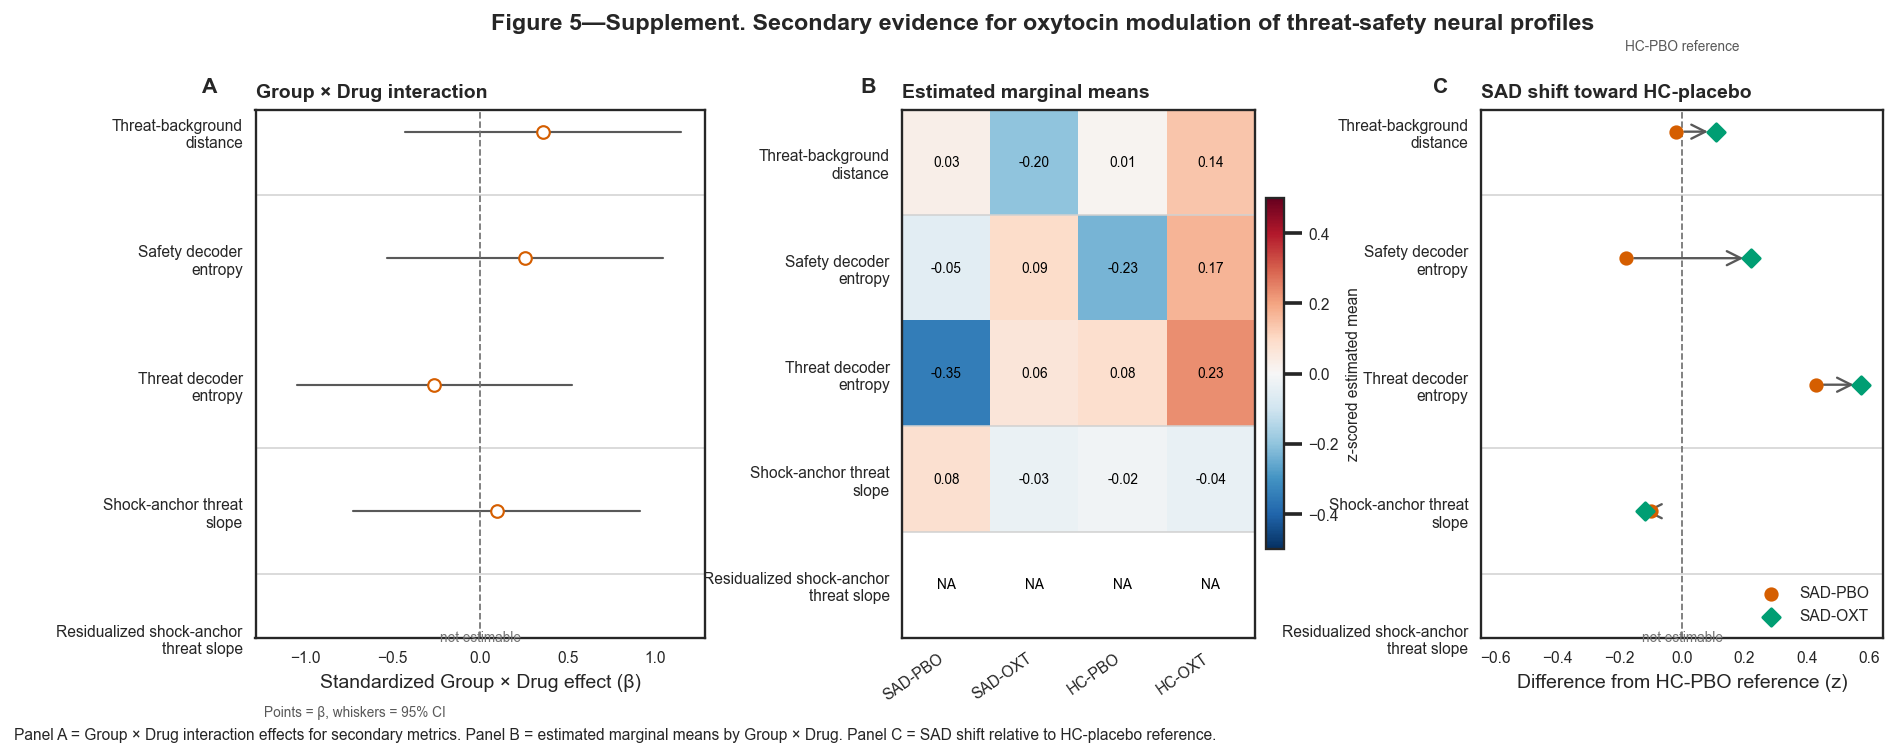

In [25]:
display(Markdown('**Figure 5—Supplement. Secondary view of oxytocin modulation using the five primary threat-safety neural metrics**'))

AIM5_SECONDARY_METRICS = SHARED_AIM2_TO_AIM5_METRICS.copy()
AIM5_SECONDARY_DOMAINS = {
    metric: PRIMARY_NEURAL_METRIC_FAMILIES.get(metric, 'Primary')
    for metric in AIM5_SECONDARY_METRICS
}
AIM5_SECONDARY_LABELS = {
    metric: PRIMARY_NEURAL_METRIC_LABELS.get(metric, metric.replace('_', '\n'))
    for metric in AIM5_SECONDARY_METRICS
}
AIM5_SECONDARY_COLUMN_ALIASES = {
    metric: PRIMARY_NEURAL_METRIC_COLUMN_CANDIDATES.get(metric, [metric])
    for metric in AIM5_SECONDARY_METRICS
}
AIM5_SECONDARY_TOKEN_ALIASES = {}
AIM5_SECONDARY_FIGURE_STEM = 'Figure5_Aim5_secondary_oxytocin_modulation'
AIM5_SECONDARY_TABLE_STEM = 'Table_Aim5_secondary_oxytocin_modulation'
AIM5_SECONDARY_CAPTION = 'Panel A = Group × Drug interaction effects for secondary metrics. Panel B = estimated marginal means by Group × Drug. Panel C = SAD shift relative to HC-placebo reference.'


def _aim5_compact_column_name(name):
    return ''.join(ch for ch in str(name).lower() if ch.isalnum())


def _aim5_find_secondary_column(data, metric):
    if metric in data.columns:
        return metric
    compact_lookup = {_aim5_compact_column_name(col): col for col in data.columns}
    for alias in AIM5_SECONDARY_COLUMN_ALIASES.get(metric, []):
        found = compact_lookup.get(_aim5_compact_column_name(alias))
        if found is not None:
            return found
    searchable = {col: _aim5_compact_column_name(col) for col in data.columns}
    for token_group in AIM5_SECONDARY_TOKEN_ALIASES.get(metric, []):
        compact_tokens = [_aim5_compact_column_name(token) for token in token_group]
        matches = [col for col, compact in searchable.items() if all(token in compact for token in compact_tokens)]
        if matches:
            return sorted(matches, key=lambda col: (len(str(col)), str(col)))[0]
    return None


def _aim5_prepare_secondary_data(subject_source_df=None, feature_space='FearNetwork'):
    df = subject_source_df if subject_source_df is not None else metrics_df
    if df is None or df.empty:
        return pd.DataFrame(), ['metrics_df is empty'], pd.DataFrame()
    data = _aim3_add_canonical_neural_metrics(df)
    if 'FeatureSpace' in data.columns:
        data = data[data['FeatureSpace'].astype(str).eq(feature_space)].copy()
    group_col = _aim3_first_existing(data, ['Group', 'group'])
    drug_col = _aim3_first_existing(data, ['Drug', 'drug', 'drug_condition'])
    subject_col = _aim3_first_existing(data, ['subject_id', 'Subject', 'sub_ID', 'sub'])
    missing = []
    for col_name, col in [('group', group_col), ('drug', drug_col), ('subject', subject_col)]:
        if col is None:
            missing.append(col_name)
    if missing:
        return pd.DataFrame(), missing, pd.DataFrame()
    source_rows = []
    available_metrics = []
    for metric in AIM5_SECONDARY_METRICS:
        source_col = _aim5_find_secondary_column(data, metric)
        if source_col is None:
            source_rows.append({'metric': metric, 'source_column': None, 'status': 'skipped: missing column'})
            continue
        data[metric] = pd.to_numeric(data[source_col], errors='coerce')
        if data[metric].notna().any():
            available_metrics.append(metric)
            status = 'available' if source_col == metric else 'available via alias'
            source_rows.append({'metric': metric, 'source_column': source_col, 'status': status})
        else:
            source_rows.append({'metric': metric, 'source_column': source_col, 'status': 'skipped: all values missing'})
    if not available_metrics:
        return pd.DataFrame(), ['no available secondary metrics'], pd.DataFrame(source_rows)
    keep_cols = [subject_col, group_col, drug_col] + available_metrics + [col for col in AIM5_PRIMARY_COVARIATE_CANDIDATES if col in data.columns]
    out = data[keep_cols].copy()
    out = out.rename(columns={subject_col: 'subject_id', group_col: 'Group', drug_col: 'Drug'})
    out['Group'] = out['Group'].map(_aim3_normalize_group)
    out['Drug'] = out['Drug'].map(_aim5_normalize_drug)
    out = out[out[['Group', 'Drug']].apply(tuple, axis=1).isin(AIM5_PRIMARY_CONDITIONS)].copy()
    for metric in available_metrics:
        out[metric] = pd.to_numeric(out[metric], errors='coerce')
    for col in ['demo_age', 'age', 'Age']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.reset_index(drop=True), [], pd.DataFrame(source_rows)


def _aim5_interpret_secondary(row):
    existing = row.get('interpretation', '')
    beta = row.get('beta_group_x_drug', np.nan)
    p_value = row.get('p_group_x_drug', np.nan)
    q_value = row.get('q_fdr_group_x_drug', np.nan)
    if not np.isfinite(beta) or pd.isna(p_value):
        return existing if str(existing).startswith('not estimable') else 'No modulation'
    uncertain = q_value >= 0.05 if pd.notna(q_value) else p_value >= 0.05
    if uncertain:
        return 'No modulation'
    sad_pbo_ref = row.get('SAD_PBO_minus_HC_PBO', np.nan)
    sad_oxt_ref = row.get('SAD_OXT_minus_HC_PBO', np.nan)
    if bool(row.get('shift_toward_HC_reference', False)) and abs(sad_pbo_ref) > 0.10:
        return 'HC-reference shift'
    hc_shift = row.get('emm_HC_OXT', np.nan) - row.get('emm_HC_PBO', np.nan)
    sad_shift = row.get('emm_SAD_OXT', np.nan) - row.get('emm_SAD_PBO', np.nan)
    if np.isfinite(hc_shift) and np.isfinite(sad_shift) and np.sign(hc_shift) == np.sign(sad_shift):
        return 'General drug effect'
    if np.isfinite(sad_pbo_ref) and np.isfinite(sad_oxt_ref) and abs(sad_oxt_ref) >= abs(sad_pbo_ref):
        return 'No normalization'
    return 'SAD-specific modulation'


def _aim5_fit_secondary_metric(data, metric, covariates=None):
    covariates = covariates or AIM5_PRIMARY_COVARIATE_CANDIDATES
    model_data = data[['subject_id', 'Group', 'Drug', metric] + [c for c in covariates if c in data.columns]].copy()
    model_data = model_data.dropna(subset=[metric, 'Group', 'Drug']).copy()
    counts = _aim5_condition_counts(model_data, metric)
    base = {
        'metric': metric,
        'domain': AIM5_SECONDARY_DOMAINS[metric],
        'n_total': int(model_data[metric].notna().sum()),
        'n_HC_PBO': counts['n_HC_Placebo'],
        'n_HC_OXT': counts['n_HC_Oxytocin'],
        'n_SAD_PBO': counts['n_SAD_Placebo'],
        'n_SAD_OXT': counts['n_SAD_Oxytocin'],
        'beta_group': np.nan,
        'beta_drug': np.nan,
        'beta_group_x_drug': np.nan,
        'ci95_low_group_x_drug': np.nan,
        'ci95_high_group_x_drug': np.nan,
        'p_group_x_drug': np.nan,
        'q_fdr_group_x_drug': np.nan,
        'emm_HC_PBO': np.nan,
        'emm_HC_OXT': np.nan,
        'emm_SAD_PBO': np.nan,
        'emm_SAD_OXT': np.nan,
        'SAD_PBO_minus_HC_PBO': np.nan,
        'SAD_OXT_minus_HC_PBO': np.nan,
        'shift_toward_HC_reference': False,
        'normalization_index': np.nan,
        'interpretation': 'No modulation',
    }
    if not all(value > 0 for value in counts.values()):
        base['interpretation'] = 'not estimable: missing Group × Drug cell'
        return base
    model_data['z_metric'] = _aim3_zscore(model_data[metric])
    model_data = model_data.dropna(subset=['z_metric']).copy()
    X, used_covariates = _aim5_design_matrix(model_data, covariates)
    fit = _aim3_fit_ols(model_data['z_metric'], X)
    if fit is None or 'Group_SAD_x_Drug_Oxytocin' not in fit['params'].index:
        base['interpretation'] = 'not estimable: insufficient complete cases'
        return base
    base['n_total'] = int(fit['n'])
    base['beta_group'] = float(fit['params'].get('Group_SAD', np.nan))
    base['beta_drug'] = float(fit['params'].get('Drug_Oxytocin', np.nan))
    base['beta_group_x_drug'] = float(fit['params']['Group_SAD_x_Drug_Oxytocin'])
    base['ci95_low_group_x_drug'] = float(fit['ci_low']['Group_SAD_x_Drug_Oxytocin'])
    base['ci95_high_group_x_drug'] = float(fit['ci_high']['Group_SAD_x_Drug_Oxytocin'])
    base['p_group_x_drug'] = float(fit['p']['Group_SAD_x_Drug_Oxytocin'])
    model_rows = model_data.loc[fit['index']].copy()
    for (group, drug), label in zip(AIM5_PRIMARY_CONDITIONS, AIM5_PRIMARY_CONDITION_LABELS):
        X_cond, _ = _aim5_design_matrix(model_rows, used_covariates, force_group=group, force_drug=drug)
        X_cond = X_cond.reindex(columns=fit['params'].index, fill_value=0.0)
        base[f'emm_{label.replace("-", "_")}'] = float((X_cond.to_numpy(dtype=float) @ fit['params'].to_numpy(dtype=float)).mean())
    base['SAD_PBO_minus_HC_PBO'] = base['emm_SAD_PBO'] - base['emm_HC_PBO']
    base['SAD_OXT_minus_HC_PBO'] = base['emm_SAD_OXT'] - base['emm_HC_PBO']
    if np.isfinite(base['SAD_PBO_minus_HC_PBO']) and np.isfinite(base['SAD_OXT_minus_HC_PBO']):
        base['shift_toward_HC_reference'] = bool(abs(base['SAD_OXT_minus_HC_PBO']) < abs(base['SAD_PBO_minus_HC_PBO']))
        base['normalization_index'] = abs(base['SAD_PBO_minus_HC_PBO']) - abs(base['SAD_OXT_minus_HC_PBO'])
    return base


def build_aim5_secondary_outputs(data):
    available_metrics = [metric for metric in AIM5_SECONDARY_METRICS if metric in data.columns and data[metric].notna().any()]
    rows = [_aim5_fit_secondary_metric(data, metric) for metric in available_metrics]
    table = pd.DataFrame(rows)
    if table.empty:
        return table
    table['q_fdr_group_x_drug'] = bh_fdr(table['p_group_x_drug']).values
    table['interpretation'] = table.apply(_aim5_interpret_secondary, axis=1)
    return table


def _aim5_secondary_domain_guides(ax, metrics):
    domains = [AIM5_SECONDARY_DOMAINS[metric] for metric in metrics]
    for idx in range(1, len(domains)):
        if domains[idx] != domains[idx - 1]:
            ax.axhline(idx - 0.5, color='0.82', linewidth=0.8, zorder=0)


def plot_aim5_secondary_outputs(table_df):
    metric_order = [metric for metric in AIM5_SECONDARY_METRICS if metric in set(table_df['metric'])]
    plot_table = table_df.set_index('metric').reindex(metric_order).reset_index()
    labels = [AIM5_SECONDARY_LABELS[m] for m in metric_order]
    y = np.arange(len(metric_order))
    height = max(4.9, 0.58 * len(metric_order) + 1.4)
    fig, axes = plt.subplots(1, 3, figsize=(15.0, height), gridspec_kw={'width_ratios': [1.32, 1.12, 1.18], 'wspace': 0.48})
    fig.patch.set_facecolor('white')
    title = 'Figure 5—Supplement. Secondary evidence for oxytocin modulation of threat-safety neural profiles'
    fig.suptitle(title, y=1.02, fontsize=12, fontweight='bold')

    ax = axes[0]
    est = pd.to_numeric(plot_table['beta_group_x_drug'], errors='coerce')
    lo = pd.to_numeric(plot_table['ci95_low_group_x_drug'], errors='coerce')
    hi = pd.to_numeric(plot_table['ci95_high_group_x_drug'], errors='coerce')
    q = pd.to_numeric(plot_table['q_fdr_group_x_drug'], errors='coerce')
    ax.axvline(0, color='0.45', linestyle='--', linewidth=0.9)
    _aim5_secondary_domain_guides(ax, metric_order)
    for i, (estimate, low, high, q_value) in enumerate(zip(est, lo, hi, q)):
        if not np.isfinite(estimate):
            ax.text(0, i, 'not estimable', ha='center', va='center', fontsize=7, color='0.45')
            continue
        ax.plot([low, high], [i, i], color='0.35', linewidth=1.1, zorder=1)
        face = OKABE['vermillion'] if pd.notna(q_value) and q_value < 0.05 else 'white'
        ax.scatter(estimate, i, s=42, facecolor=face, edgecolor=OKABE['vermillion'], linewidth=1.1, zorder=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Standardized Group × Drug effect (β)')
    ax.set_title('Group × Drug interaction', loc='left', fontsize=10, fontweight='bold')
    ax.set_xlim(_aim5_symmetric_limit(est, lo, hi))
    ax.text(0.02, -0.15, 'Points = β, whiskers = 95% CI', transform=ax.transAxes, fontsize=7, color='0.35')
    add_panel_label(ax, 'A')

    ax = axes[1]
    heat_values = plot_table[['emm_HC_PBO', 'emm_HC_OXT', 'emm_SAD_PBO', 'emm_SAD_OXT']].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
    finite_heat = heat_values[np.isfinite(heat_values)]
    heat_bound = max(0.5, float(np.nanmax(np.abs(finite_heat))) if finite_heat.size else 0.5)
    image = ax.imshow(heat_values, aspect='auto', cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-heat_bound, vcenter=0, vmax=heat_bound))
    _aim5_secondary_domain_guides(ax, metric_order)
    ax.set_xticks(np.arange(len(AIM5_PRIMARY_CONDITION_LABELS)))
    ax.set_xticklabels(AIM5_PRIMARY_CONDITION_LABELS, rotation=35, ha='right')
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title('Estimated marginal means', loc='left', fontsize=10, fontweight='bold')
    for i in range(heat_values.shape[0]):
        for j in range(heat_values.shape[1]):
            value = heat_values[i, j]
            text = 'NA' if not np.isfinite(value) else f'{value:.2f}'
            ax.text(j, i, text, ha='center', va='center', fontsize=7, color='black')
    cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label('z-scored estimated mean', fontsize=8)
    add_panel_label(ax, 'B')

    ax = axes[2]
    sad_pbo = pd.to_numeric(plot_table['SAD_PBO_minus_HC_PBO'], errors='coerce')
    sad_oxt = pd.to_numeric(plot_table['SAD_OXT_minus_HC_PBO'], errors='coerce')
    ax.axvline(0, color='0.45', linestyle='--', linewidth=0.9)
    _aim5_secondary_domain_guides(ax, metric_order)
    ax.text(0, -0.62, 'HC-PBO reference', ha='center', va='bottom', fontsize=7, color='0.35')
    for i, (pbo, oxt) in enumerate(zip(sad_pbo, sad_oxt)):
        if not np.isfinite(pbo) or not np.isfinite(oxt):
            ax.text(0, i, 'not estimable', ha='center', va='center', fontsize=7, color='0.45')
            continue
        ax.annotate('', xy=(oxt, i), xytext=(pbo, i), arrowprops={'arrowstyle': '->', 'lw': 1.2, 'color': '0.35', 'shrinkA': 4, 'shrinkB': 4})
        ax.scatter(pbo, i, s=34, color=OKABE['vermillion'], label='SAD-PBO' if i == 0 else None, zorder=3)
        ax.scatter(oxt, i, s=40, marker='D', color=OKABE['green'], label='SAD-OXT' if i == 0 else None, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Difference from HC-PBO reference (z)')
    ax.set_title('SAD shift toward HC-placebo', loc='left', fontsize=10, fontweight='bold')
    ax.set_xlim(_aim5_symmetric_limit(sad_pbo, sad_oxt))
    ax.legend(frameon=False, loc='lower right')
    add_panel_label(ax, 'C')

    for ax in axes:
        ax.tick_params(axis='both', length=3, width=0.8)
    fig.text(0.01, -0.02, AIM5_SECONDARY_CAPTION, ha='left', va='top', fontsize=8)
    return fig


def save_aim5_secondary_outputs(fig, table_df, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    png_path = fig_dir / f'{AIM5_SECONDARY_FIGURE_STEM}.png'
    svg_path = fig_dir / f'{AIM5_SECONDARY_FIGURE_STEM}.svg'
    csv_path = stats_dir / f'{AIM5_SECONDARY_TABLE_STEM}.csv'
    table_df.to_csv(csv_path, index=False)
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(svg_path, bbox_inches='tight')
    print(f'Saved {png_path}')
    print(f'Saved {svg_path}')
    print(f'Saved {csv_path}')
    return {'png': png_path, 'svg': svg_path, 'csv': csv_path}


aim5_secondary_data, aim5_secondary_missing, aim5_secondary_sources = _aim5_prepare_secondary_data()

if not aim5_secondary_sources.empty:
    display(Markdown('**Aim 5 secondary metric source mapping / skipped metrics**'))
    display(aim5_secondary_sources)

if aim5_secondary_data.empty:
    display(Markdown('Aim 5 secondary outputs were not generated because required observed subject-level data or secondary metric columns are unavailable.'))
    if aim5_secondary_missing:
        display(pd.DataFrame({'missing_requirement': aim5_secondary_missing}))
else:
    aim5_secondary_table = build_aim5_secondary_outputs(aim5_secondary_data)
    if aim5_secondary_table.empty:
        display(Markdown('Aim 5 secondary outputs were not generated because no secondary metrics were estimable after complete-case filtering.'))
    else:
        aim5_secondary_fig = plot_aim5_secondary_outputs(aim5_secondary_table)
        aim5_secondary_paths = save_aim5_secondary_outputs(aim5_secondary_fig, aim5_secondary_table)
        display(aim5_secondary_table)
        show_figure_once(aim5_secondary_fig)


### Aim 5 sensitivity visualization

Controlled by `task_Visualization-Aim5-sensitivity.md`. Figure 5—Supplement and `Table_Aim5_sensitivity_oxytocin_modulation` test whether the Aim 5 `Group × Drug` estimand is stable across available feature spaces and reasonable model specifications. The primary sensitivity claim is restricted to feature-space and model-specification robustness; SCR-defined learner subgroup outputs are not used as primary Aim 5 sensitivity evidence.


**Figure 5—Supplement. Sensitivity analysis for oxytocin modulation of threat-safety neural profiles**

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure5_Aim5_sensitivity_oxytocin_modulation.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/Figure5_Aim5_sensitivity_oxytocin_modulation.svg
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/Table_Aim5_sensitivity_oxytocin_modulation.csv


,metric,domain,sensitivity_family,sensitivity_name,feature_space,model_specification,n_total,n_HC_PBO,n_HC_OXT,n_SAD_PBO,n_SAD_OXT,beta_group,beta_drug,beta_group_x_drug,ci95_low_group_x_drug,ci95_high_group_x_drug,p_group_x_drug,q_fdr_group_x_drug,emm_HC_PBO,emm_HC_OXT,emm_SAD_PBO,emm_SAD_OXT,SAD_PBO_minus_HC_PBO,SAD_OXT_minus_HC_PBO,normalization_index,direction_matches_primary,significant_after_fdr,robustness_interpretation
0,Neural_Dist_Safety_Background,Geometry,feature_space,FearNetwork,FearNetwork,Primary covariate model,102,28,24,23,27,0.444310,-0.051065,0.071582,-0.673229,0.816393,0.849107,0.869817,-0.211215,-0.262280,0.233096,0.253612,0.444310,0.464827,-0.020517,True,False,Robust
1,Neural_Dist_Threat_Safety,Geometry,feature_space,FearNetwork,FearNetwork,Primary covariate model,102,28,24,23,27,0.403903,-0.533280,-0.105275,-0.867005,0.656455,0.784416,0.869817,0.096515,-0.436765,0.500418,-0.138137,0.403903,-0.234652,0.169251,True,False,Robust
2,Neural_SafetyEvidence,Certainty,feature_space,FearNetwork,FearNetwork,Primary covariate model,102,28,24,23,27,0.389488,-0.583121,-0.188745,-0.939893,0.562403,0.619076,0.869817,0.150597,-0.432524,0.540085,-0.231781,0.389488,-0.382378,0.007111,True,False,Robust
3,Neural_ThreatEvidence,Certainty,feature_space,FearNetwork,FearNetwork,Primary covariate model,102,28,24,23,27,0.406387,-0.581250,-0.127212,-0.878666,0.624243,0.737580,0.869817,0.125089,-0.456160,0.531476,-0.176985,0.406387,-0.302074,0.104312,True,False,Robust
4,Neural_Safety_Trajectory_Slope,Trajectory,feature_space,FearNetwork,FearNetwork,Primary covariate model,102,28,24,23,27,-0.003298,0.172361,-0.308282,-1.111956,0.495393,0.448272,0.869817,-0.002960,0.169401,-0.006258,-0.142178,-0.003298,-0.139218,-0.135921,True,False,Robust
5,Neural_Threat_Trajectory_Slope,Trajectory,feature_space,FearNetwork,FearNetwork,Primary covariate model,100,28,23,22,27,-0.383277,-0.491308,0.431570,-0.368970,1.232109,0.287183,0.869817,0.316936,-0.174372,-0.066341,-0.126079,-0.383277,-0.443015,-0.059738,True,False,Robust
6,Neural_Dist_Safety_Background,Geometry,feature_space,MemoryFearNetwork,MemoryFearNetwork,Primary covariate model,102,28,24,23,27,0.162729,0.190842,0.103518,-0.682348,0.889385,0.794289,0.869817,-0.202592,-0.011750,-0.039863,0.254497,0.162729,0.457089,-0.294360,True,False,Robust
7,Neural_Dist_Threat_Safety,Geometry,feature_space,MemoryFearNetwork,MemoryFearNetwork,Primary covariate model,102,28,24,23,27,-0.254915,-0.740017,0.603049,-0.176611,1.382710,0.127990,0.869817,0.335336,-0.404681,0.080421,-0.056547,-0.254915,-0.391883,-0.136968,False,False,Inconsistent
8,Neural_SafetyEvidence,Certainty,feature_space,MemoryFearNetwork,MemoryFearNetwork,Primary covariate model,102,28,24,23,27,0.125072,-1.047690,0.384010,-0.326693,1.094714,0.286168,0.869817,0.360885,-0.686805,0.485957,-0.177722,0.125072,-0.538607,-0.413535,False,False,Inconsistent
9,Neural_ThreatEvidence,Certainty,feature_space,MemoryFearNetwork,MemoryFearNetwork,Primary covariate model,102,28,24,23,27,0.338163,-0.742026,-0.091134,-0.820704,0.638436,0.804700,0.869817,0.229371,-0.512655,0.567533,-0.265626,0.338163,-0.494997,-0.156834,True,False,Inconsistent


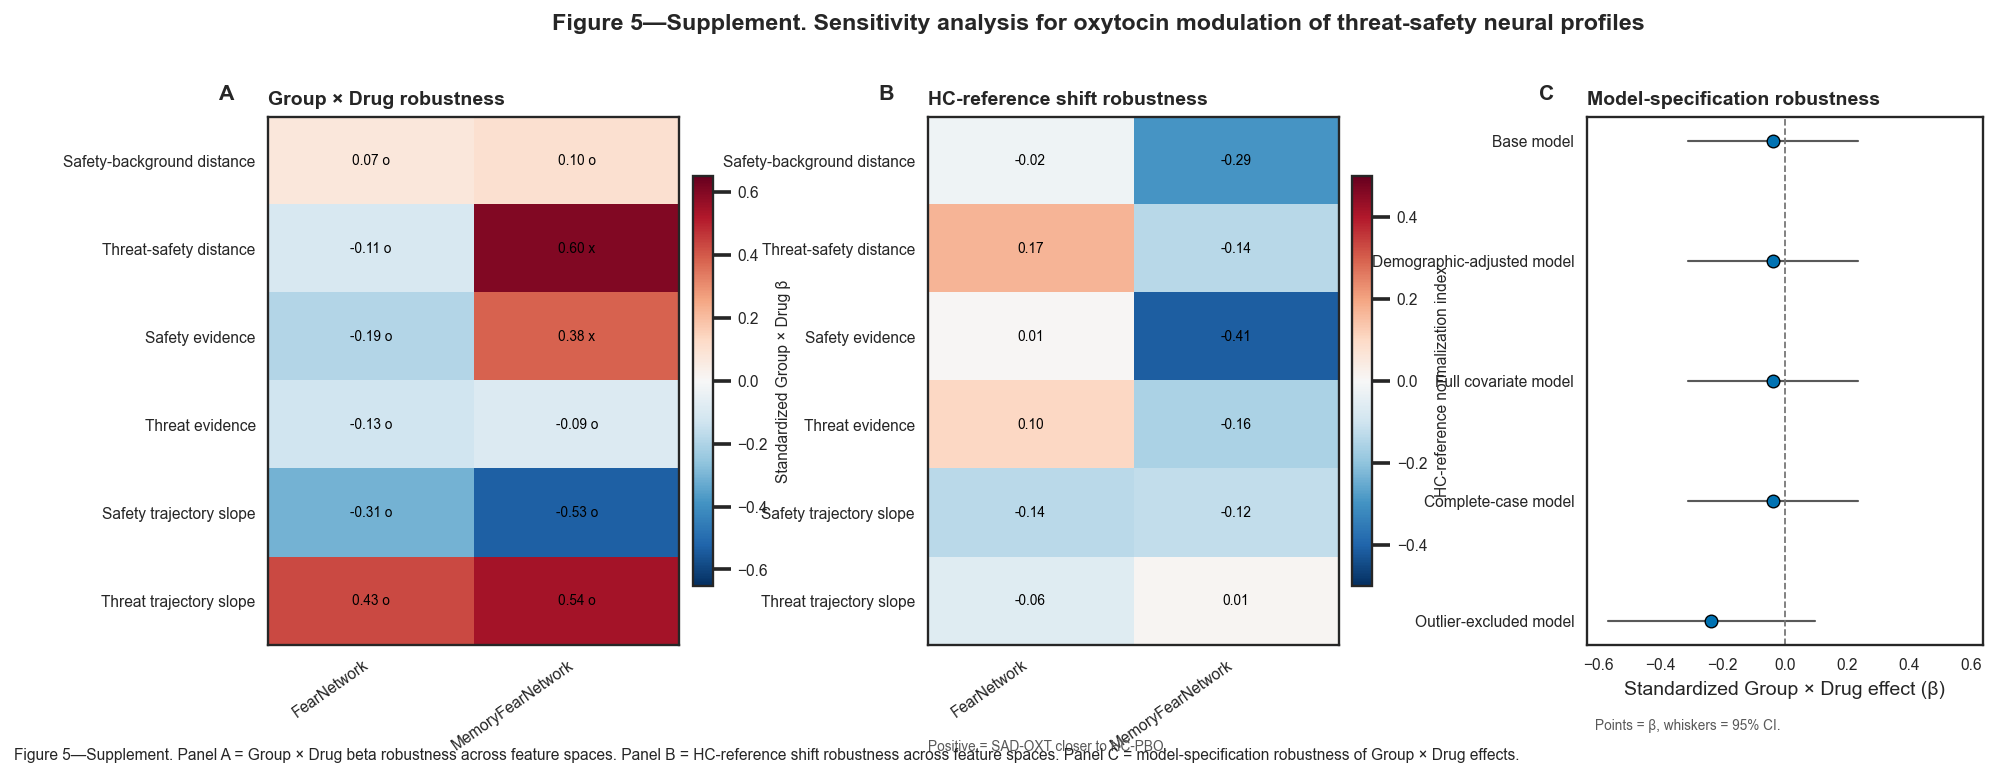

In [26]:
display(Markdown('**Figure 5—Supplement. Sensitivity analysis for oxytocin modulation of threat-safety neural profiles**'))

from matplotlib.colors import TwoSlopeNorm

AIM5_SENSITIVITY_FIGURE_STEM = 'Figure5_Aim5_sensitivity_oxytocin_modulation'
AIM5_SENSITIVITY_TABLE_STEM = 'Table_Aim5_sensitivity_oxytocin_modulation'
AIM5_SENSITIVITY_FEATURE_SPACE_ORDER = ['FearNetwork', 'MemoryFearNetwork', 'Schaefer_Tian', 'Schaefer', 'Tian', 'WholeBrain', 'WholeBrain_Parcellation', 'WholeBrain_Schaefer']
AIM5_SENSITIVITY_CAPTION = 'Figure 5—Supplement. Panel A = Group × Drug beta robustness across feature spaces. Panel B = HC-reference shift robustness across feature spaces. Panel C = model-specification robustness of Group × Drug effects.'


def _aim5_sensitivity_available_feature_spaces(df=None):
    source = metrics_df if df is None else df
    if source is None or source.empty or 'FeatureSpace' not in source.columns:
        return ['FearNetwork'] if source is not None and not source.empty else []
    available = sorted(source['FeatureSpace'].dropna().astype(str).unique().tolist())
    ordered = [space for space in AIM5_SENSITIVITY_FEATURE_SPACE_ORDER if space in available]
    ordered += [space for space in available if space not in ordered]
    return ordered


def _aim5_sensitivity_covariate_groups(data):
    demographic = [col for col in ['demo_age', 'age', 'Age', 'Gender', 'gender', 'Sex', 'sex'] if col in data.columns]
    run_order = [col for col in ['run', 'Run', 'order', 'Order', 'session', 'Session'] if col in data.columns]
    covariate_groups = {
        'Base model': [],
    }
    if demographic:
        covariate_groups['Demographic-adjusted model'] = demographic
    if run_order:
        covariate_groups['Run/order-adjusted model'] = run_order
    full_covariates = []
    for col in AIM5_PRIMARY_COVARIATE_CANDIDATES:
        if col in data.columns and col not in full_covariates:
            full_covariates.append(col)
    if full_covariates:
        covariate_groups['Full covariate model'] = full_covariates
    covariate_groups['Complete-case model'] = full_covariates
    covariate_groups['Outlier-excluded model'] = full_covariates
    return covariate_groups


def _aim5_sensitivity_prepare_feature_data(feature_space, source_df=None):
    data, missing = _aim5_prepare_primary_data(source_df, feature_space=feature_space)
    if data.empty:
        return data, missing
    data = data.copy()
    data['FeatureSpace'] = feature_space
    return data, []


def _aim5_sensitivity_standard_row(metric, sensitivity_family, sensitivity_name, feature_space, model_specification, status):
    return {
        'metric': metric,
        'domain': AIM5_PRIMARY_DOMAINS.get(metric, ''),
        'sensitivity_family': sensitivity_family,
        'sensitivity_name': sensitivity_name,
        'feature_space': feature_space,
        'model_specification': model_specification,
        'n_total': 0,
        'n_HC_PBO': 0,
        'n_HC_OXT': 0,
        'n_SAD_PBO': 0,
        'n_SAD_OXT': 0,
        'beta_group': np.nan,
        'beta_drug': np.nan,
        'beta_group_x_drug': np.nan,
        'ci95_low_group_x_drug': np.nan,
        'ci95_high_group_x_drug': np.nan,
        'p_group_x_drug': np.nan,
        'q_fdr_group_x_drug': np.nan,
        'emm_HC_PBO': np.nan,
        'emm_HC_OXT': np.nan,
        'emm_SAD_PBO': np.nan,
        'emm_SAD_OXT': np.nan,
        'SAD_PBO_minus_HC_PBO': np.nan,
        'SAD_OXT_minus_HC_PBO': np.nan,
        'normalization_index': np.nan,
        'direction_matches_primary': False,
        'significant_after_fdr': False,
        'robustness_interpretation': status,
    }


def _aim5_sensitivity_metric_row(data, metric, sensitivity_family, sensitivity_name, feature_space, model_specification, covariates=None, outlier_excluded=False, complete_case_covariates=None):
    if data is None or data.empty:
        return _aim5_sensitivity_standard_row(metric, sensitivity_family, sensitivity_name, feature_space, model_specification, 'Not estimable: subject-level data unavailable')
    model_data = data.copy()
    if metric not in model_data.columns:
        return _aim5_sensitivity_standard_row(metric, sensitivity_family, sensitivity_name, feature_space, model_specification, 'Not estimable: metric unavailable')
    covariates = [col for col in (covariates or []) if col in model_data.columns]
    complete_case_covariates = [col for col in (complete_case_covariates or []) if col in model_data.columns]
    if complete_case_covariates:
        model_data = model_data.dropna(subset=complete_case_covariates).copy()
    if outlier_excluded:
        z_values = _aim3_zscore(model_data[metric])
        model_data = model_data[z_values.abs().le(3) | z_values.isna()].copy()
    fit_row = _aim5_fit_primary_metric(model_data, metric, covariates=covariates)
    out = _aim5_sensitivity_standard_row(metric, sensitivity_family, sensitivity_name, feature_space, model_specification, '')
    out.update({key: fit_row.get(key, out.get(key)) for key in out if key in fit_row})
    out['sensitivity_family'] = sensitivity_family
    out['sensitivity_name'] = sensitivity_name
    out['feature_space'] = feature_space
    out['model_specification'] = model_specification
    out['normalization_index'] = abs(out['SAD_PBO_minus_HC_PBO']) - abs(out['SAD_OXT_minus_HC_PBO']) if pd.notna(out['SAD_PBO_minus_HC_PBO']) and pd.notna(out['SAD_OXT_minus_HC_PBO']) else np.nan
    if str(fit_row.get('interpretation', '')).startswith('not estimable'):
        out['robustness_interpretation'] = 'Not estimable: model cannot be fit for this sensitivity check'
    return out


def build_aim5_sensitivity_outputs(source_df=None):
    source = metrics_df if source_df is None else source_df
    feature_spaces = _aim5_sensitivity_available_feature_spaces(source)
    rows = []
    feature_data = {}
    for feature_space in feature_spaces:
        data, missing = _aim5_sensitivity_prepare_feature_data(feature_space, source)
        feature_data[feature_space] = data
        for metric in AIM5_PRIMARY_METRICS:
            if data.empty:
                status = 'Not estimable: missing ' + ', '.join(missing) if missing else 'Not estimable: feature-space data unavailable'
                rows.append(_aim5_sensitivity_standard_row(metric, 'feature_space', feature_space, feature_space, 'Primary covariate model', status))
                continue
            rows.append(_aim5_sensitivity_metric_row(data, metric, 'feature_space', feature_space, feature_space, 'Primary covariate model', covariates=AIM5_PRIMARY_COVARIATE_CANDIDATES))
    primary_feature = 'FearNetwork' if 'FearNetwork' in feature_data else (feature_spaces[0] if feature_spaces else 'FearNetwork')
    primary_data = feature_data.get(primary_feature, pd.DataFrame())
    if not primary_data.empty:
        covariate_groups = _aim5_sensitivity_covariate_groups(primary_data)
        for model_name, covariates in covariate_groups.items():
            for metric in AIM5_PRIMARY_METRICS:
                rows.append(_aim5_sensitivity_metric_row(primary_data, metric, 'model_specification', model_name, primary_feature, model_name, covariates=covariates, complete_case_covariates=covariates if model_name == 'Complete-case model' else None, outlier_excluded=model_name == 'Outlier-excluded model'))
    table = pd.DataFrame(rows)
    if table.empty:
        return table, feature_spaces, primary_feature
    table['q_fdr_group_x_drug'] = bh_fdr(table['p_group_x_drug']).values
    primary_ref = table[(table['feature_space'].astype(str).eq(primary_feature)) & (table['sensitivity_family'].eq('feature_space')) & (table['model_specification'].eq('Primary covariate model'))].copy()
    primary_beta = primary_ref.set_index('metric')['beta_group_x_drug'].to_dict() if not primary_ref.empty else {}
    primary_norm = primary_ref.set_index('metric')['normalization_index'].to_dict() if not primary_ref.empty else {}
    for idx, row in table.iterrows():
        beta = row['beta_group_x_drug']
        ref_beta = primary_beta.get(row['metric'], np.nan)
        norm = row['normalization_index']
        ref_norm = primary_norm.get(row['metric'], np.nan)
        if pd.notna(beta) and pd.notna(ref_beta) and ref_beta != 0:
            table.loc[idx, 'direction_matches_primary'] = bool(np.sign(beta) == np.sign(ref_beta))
        elif pd.notna(beta) and pd.notna(ref_beta):
            table.loc[idx, 'direction_matches_primary'] = bool(abs(beta) < 1e-12 and abs(ref_beta) < 1e-12)
        table.loc[idx, 'significant_after_fdr'] = bool(pd.notna(row['q_fdr_group_x_drug']) and row['q_fdr_group_x_drug'] < 0.05)
        if str(row['robustness_interpretation']).startswith('Not estimable'):
            continue
        direction_match = bool(table.loc[idx, 'direction_matches_primary'])
        norm_reversed = pd.notna(norm) and pd.notna(ref_norm) and np.sign(norm) != np.sign(ref_norm) and abs(norm) > 1e-12 and abs(ref_norm) > 1e-12
        ci_low = row['ci95_low_group_x_drug']
        ci_high = row['ci95_high_group_x_drug']
        ref_inside_ci = pd.notna(ref_beta) and pd.notna(ci_low) and pd.notna(ci_high) and ci_low <= ref_beta <= ci_high
        if norm_reversed or not direction_match:
            interpretation = 'Inconsistent'
        elif ref_inside_ci:
            interpretation = 'Robust'
        else:
            interpretation = 'Directionally consistent'
        table.loc[idx, 'robustness_interpretation'] = interpretation
    ordered_cols = [
        'metric', 'domain', 'sensitivity_family', 'sensitivity_name', 'feature_space', 'model_specification', 'n_total',
        'n_HC_PBO', 'n_HC_OXT', 'n_SAD_PBO', 'n_SAD_OXT', 'beta_group', 'beta_drug', 'beta_group_x_drug',
        'ci95_low_group_x_drug', 'ci95_high_group_x_drug', 'p_group_x_drug', 'q_fdr_group_x_drug', 'emm_HC_PBO',
        'emm_HC_OXT', 'emm_SAD_PBO', 'emm_SAD_OXT', 'SAD_PBO_minus_HC_PBO', 'SAD_OXT_minus_HC_PBO',
        'normalization_index', 'direction_matches_primary', 'significant_after_fdr', 'robustness_interpretation',
    ]
    table = table.reindex(columns=ordered_cols)
    return table, feature_spaces, primary_feature


def _aim5_sensitivity_heatmap_matrix(table, value_col, family='feature_space'):
    sub = table[table['sensitivity_family'].eq(family)].copy()
    if sub.empty:
        return pd.DataFrame(index=AIM5_PRIMARY_METRICS)
    pivot = sub.pivot_table(index='metric', columns='feature_space', values=value_col, aggfunc='first')
    columns = [space for space in AIM5_SENSITIVITY_FEATURE_SPACE_ORDER if space in pivot.columns]
    columns += [space for space in pivot.columns if space not in columns]
    return pivot.reindex(index=AIM5_PRIMARY_METRICS, columns=columns)


def _aim5_sensitivity_model_summary(table, primary_feature='FearNetwork'):
    sub = table[(table['sensitivity_family'].eq('model_specification')) & (table['feature_space'].astype(str).eq(primary_feature))].copy()
    sub = sub[pd.to_numeric(sub['beta_group_x_drug'], errors='coerce').notna()].copy()
    if sub.empty:
        return pd.DataFrame()
    rows = []
    for spec, group_df in sub.groupby('model_specification', sort=False):
        beta = pd.to_numeric(group_df['beta_group_x_drug'], errors='coerce').dropna()
        if beta.empty:
            continue
        mean_beta = float(beta.mean())
        if len(beta) > 1:
            se = float(beta.std(ddof=1) / np.sqrt(len(beta)))
            ci_delta = float(stats.t.ppf(0.975, len(beta) - 1) * se)
        else:
            ci_delta = np.nan
        rows.append({'model_specification': spec, 'mean_beta': mean_beta, 'ci_low': mean_beta - ci_delta if pd.notna(ci_delta) else np.nan, 'ci_high': mean_beta + ci_delta if pd.notna(ci_delta) else np.nan, 'n_metrics': int(len(beta))})
    return pd.DataFrame(rows)


def plot_aim5_sensitivity_outputs(table, primary_feature='FearNetwork'):
    if table is None or table.empty:
        print('Aim 5 sensitivity figure was not generated because no sensitivity rows are available.')
        return None
    beta_matrix = _aim5_sensitivity_heatmap_matrix(table, 'beta_group_x_drug')
    norm_matrix = _aim5_sensitivity_heatmap_matrix(table, 'normalization_index')
    summary = _aim5_sensitivity_model_summary(table, primary_feature=primary_feature)
    metric_labels = [AIM5_PRIMARY_LABELS.get(metric, metric).replace('\n', ' ') for metric in AIM5_PRIMARY_METRICS]
    fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.9), gridspec_kw={'width_ratios': [1.18, 1.18, 1.05], 'wspace': 0.5})
    fig.patch.set_facecolor('white')
    title = 'Figure 5—Supplement. Sensitivity analysis for oxytocin modulation of threat-safety neural profiles'
    fig.suptitle(title, y=1.03, fontsize=12, fontweight='bold')

    for ax, matrix, title_text, cbar_label, panel in [
        (axes[0], beta_matrix, 'Group × Drug robustness', 'Standardized Group × Drug β', 'A'),
        (axes[1], norm_matrix, 'HC-reference shift robustness', 'HC-reference normalization index', 'B'),
    ]:
        values = matrix.to_numpy(dtype=float) if not matrix.empty else np.empty((len(AIM5_PRIMARY_METRICS), 0))
        finite = values[np.isfinite(values)]
        bound = max(0.5, float(np.nanmax(np.abs(finite))) * 1.08 if finite.size else 0.5)
        image = ax.imshow(values, aspect='auto', cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-bound, vcenter=0, vmax=bound))
        ax.set_title(title_text, loc='left', fontsize=10, fontweight='bold')
        ax.set_yticks(np.arange(len(metric_labels)))
        ax.set_yticklabels(metric_labels)
        ax.set_xticks(np.arange(len(matrix.columns)))
        ax.set_xticklabels([str(col).replace('_', ' ') for col in matrix.columns], rotation=35, ha='right')
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                value = values[i, j]
                if not np.isfinite(value):
                    ax.text(j, i, 'NA', ha='center', va='center', fontsize=7, color='0.55')
                    continue
                marker = ''
                if panel == 'A':
                    match_rows = table[(table['sensitivity_family'].eq('feature_space')) & (table['metric'].eq(AIM5_PRIMARY_METRICS[i])) & (table['feature_space'].astype(str).eq(str(matrix.columns[j])))]
                    if not match_rows.empty:
                        marker = ' o' if bool(match_rows['direction_matches_primary'].iloc[0]) else ' x'
                ax.text(j, i, f'{value:.2f}{marker}', ha='center', va='center', fontsize=7, color='black')
        cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
        cbar.set_label(cbar_label, fontsize=8)
        add_panel_label(ax, panel)
    axes[1].text(0.0, -0.2, 'Positive = SAD-OXT closer to HC-PBO.', transform=axes[1].transAxes, fontsize=7, color='0.35')

    ax = axes[2]
    ax.axvline(0, color='0.45', linestyle='--', linewidth=0.9)
    if summary.empty:
        ax.text(0.5, 0.5, 'No estimable model-specification checks', ha='center', va='center', transform=ax.transAxes, fontsize=8, color='0.45')
        ax.set_yticks([])
        ax.set_xlim(-0.5, 0.5)
    else:
        y = np.arange(summary.shape[0])
        est = pd.to_numeric(summary['mean_beta'], errors='coerce')
        lo = pd.to_numeric(summary['ci_low'], errors='coerce')
        hi = pd.to_numeric(summary['ci_high'], errors='coerce')
        for i, row in summary.iterrows():
            estimate = row['mean_beta']
            low = row['ci_low']
            high = row['ci_high']
            if pd.notna(low) and pd.notna(high):
                ax.plot([low, high], [i, i], color='0.35', linewidth=1.1, zorder=1)
            ax.scatter(estimate, i, s=42, facecolor=OKABE['blue'], edgecolor='black', linewidth=0.7, zorder=2)
        ax.set_yticks(y)
        ax.set_yticklabels(summary['model_specification'])
        ax.invert_yaxis()
        ax.set_xlim(_aim5_symmetric_limit(est, lo, hi))
    ax.set_title('Model-specification robustness', loc='left', fontsize=10, fontweight='bold')
    ax.set_xlabel('Standardized Group × Drug effect (β)')
    ax.text(0.02, -0.16, 'Points = β, whiskers = 95% CI.', transform=ax.transAxes, fontsize=7, color='0.35')
    add_panel_label(ax, 'C')
    for ax in axes:
        ax.tick_params(axis='both', length=3, width=0.8)
    fig.text(0.01, -0.04, AIM5_SENSITIVITY_CAPTION, ha='left', va='top', fontsize=8)
    return fig


def save_aim5_sensitivity_outputs(fig, table_df, fig_dir=FIG_DIR, stats_dir=STATS_DIR):
    fig_dir = Path(fig_dir)
    stats_dir = Path(stats_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)
    stats_dir.mkdir(parents=True, exist_ok=True)
    png_path = fig_dir / f'{AIM5_SENSITIVITY_FIGURE_STEM}.png'
    svg_path = fig_dir / f'{AIM5_SENSITIVITY_FIGURE_STEM}.svg'
    csv_path = stats_dir / f'{AIM5_SENSITIVITY_TABLE_STEM}.csv'
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(svg_path, bbox_inches='tight')
    print(f'Saved {png_path}')
    print(f'Saved {svg_path}')
    table_df.to_csv(csv_path, index=False)
    print(f'Saved {csv_path}')
    return {'png': png_path, 'svg': svg_path, 'csv': csv_path}


aim5_sensitivity_source = metrics_df

aim5_sensitivity_table, aim5_sensitivity_feature_spaces, aim5_sensitivity_primary_feature = build_aim5_sensitivity_outputs(aim5_sensitivity_source)
if aim5_sensitivity_table.empty:
    display(Markdown('Aim 5 sensitivity outputs were not generated because required observed subject-level data are unavailable.'))
    display(pd.DataFrame({'missing_requirement': ['observed metrics_df with Aim 5 primary metrics']}))
else:
    aim5_sensitivity_fig = plot_aim5_sensitivity_outputs(aim5_sensitivity_table, primary_feature=aim5_sensitivity_primary_feature)
    aim5_sensitivity_paths = save_aim5_sensitivity_outputs(aim5_sensitivity_fig, aim5_sensitivity_table)
    display(aim5_sensitivity_table)
    show_figure_once(aim5_sensitivity_fig)


### Aim 5 whitelist audit

This audit records the allowed Aim 5 outputs from the three controlling task files and documents cleanup of older non-whitelisted Aim 5 content.


In [27]:
aim5_whitelist_checklist = pd.DataFrame([
    {
        'task_file': 'task_Visualization-Aim5-primary.md',
        'allowed_item': 'Figure 5 primary oxytocin modulation: Panel A Group × Drug forest plot; Panel B estimated marginal means heatmap; Panel C SAD shift toward HC-PBO reference',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 5 primary visualization',
        'status': 'implemented',
        'notes': 'Uses the six primary neural metrics and the primary Group × Drug model family with available covariates.',
    },
    {
        'task_file': 'task_Visualization-Aim5-primary.md',
        'allowed_item': 'Table_Aim5_primary_oxytocin_modulation.csv statistics table',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 5 primary visualization',
        'status': 'implemented',
        'notes': 'One row per primary metric with Group × Drug estimates, FDR q-values, estimated marginal means, HC-reference shifts, and interpretation.',
    },
    {
        'task_file': 'task_Visualization-Aim5-secondary.md',
        'allowed_item': 'Figure 5—Supplement secondary/supportive oxytocin modulation with the same 1 × 3 structure as primary Aim 5',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 5 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Uses only the requested secondary/supportive metrics, with explicit alias handling for shock-anchor columns.',
    },
    {
        'task_file': 'task_Visualization-Aim5-secondary.md',
        'allowed_item': 'Table_Aim5_secondary_oxytocin_modulation.csv compact statistics table',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 5 secondary/supportive visualization',
        'status': 'implemented',
        'notes': 'Records unavailable secondary metrics as skipped in notebook output rather than treating them as null results.',
    },
    {
        'task_file': 'task_Visualization-Aim5-sensitivity.md',
        'allowed_item': 'Figure 5—Supplement sensitivity analysis: Panel A feature-space Group × Drug robustness heatmap; Panel B HC-reference normalization heatmap; Panel C model-specification robustness forest plot',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 5 sensitivity visualization',
        'status': 'implemented',
        'notes': 'Uses available feature spaces and FearNetwork model-specification checks only; SCR learner subgroups are not used as primary sensitivity evidence.',
    },
    {
        'task_file': 'task_Visualization-Aim5-sensitivity.md',
        'allowed_item': 'Table_Aim5_sensitivity_oxytocin_modulation.csv sensitivity statistics table',
        'implemented_in_mvpa_l2': True,
        'cell_or_section': 'Aim 5 sensitivity visualization',
        'status': 'implemented',
        'notes': 'One row per primary metric × sensitivity check with absolute HC-reference normalization index and robustness interpretation.',
    },
])

aim5_removed_items = pd.DataFrame([
    {
        'removed_item': 'Generic legacy Aim 5 sensitivity block using render_sensitivity_block',
        'reason': 'Not one of the exact primary, secondary/supportive, or sensitivity outputs requested by the three Aim 5 task files.',
        'old_cell_or_section': 'Former Aim 5 Sensitivity: Drug-Modulation Robustness code cell',
    },
    {
        'removed_item': 'Unscoped older Aim 5 exploratory summaries, subgroup analyses, or extra plots',
        'reason': 'Umbrella Aim 5 task allows only items whitelisted in task_Visualization-Aim5-primary.md, task_Visualization-Aim5-secondary.md, and task_Visualization-Aim5-sensitivity.md.',
        'old_cell_or_section': 'Aim 5 section cleanup guard',
    },
])

display(Markdown('**Aim 5 whitelist checklist**'))
display(aim5_whitelist_checklist)
display(Markdown('**Aim 5 removed-items table**'))
display(aim5_removed_items)


**Aim 5 whitelist checklist**

,task_file,allowed_item,implemented_in_mvpa_l2,cell_or_section,status,notes
0,task_Visualization-Aim5-primary.md,Figure 5 primary oxytocin modulation: Panel A ...,True,Aim 5 primary visualization,implemented,Uses the six primary neural metrics and the pr...
1,task_Visualization-Aim5-primary.md,Table_Aim5_primary_oxytocin_modulation.csv sta...,True,Aim 5 primary visualization,implemented,One row per primary metric with Group × Drug e...
2,task_Visualization-Aim5-secondary.md,Figure 5—Supplement secondary/supportive oxyto...,True,Aim 5 secondary/supportive visualization,implemented,Uses only the requested secondary/supportive m...
3,task_Visualization-Aim5-secondary.md,Table_Aim5_secondary_oxytocin_modulation.csv c...,True,Aim 5 secondary/supportive visualization,implemented,Records unavailable secondary metrics as skipp...
4,task_Visualization-Aim5-sensitivity.md,Figure 5—Supplement sensitivity analysis: Pane...,True,Aim 5 sensitivity visualization,implemented,Uses available feature spaces and FearNetwork ...
5,task_Visualization-Aim5-sensitivity.md,Table_Aim5_sensitivity_oxytocin_modulation.csv...,True,Aim 5 sensitivity visualization,implemented,One row per primary metric × sensitivity check...


**Aim 5 removed-items table**

,removed_item,reason,old_cell_or_section
0,Generic legacy Aim 5 sensitivity block using r...,"Not one of the exact primary, secondary/suppor...",Former Aim 5 Sensitivity: Drug-Modulation Robu...
1,"Unscoped older Aim 5 exploratory summaries, su...",Umbrella Aim 5 task allows only items whitelis...,Aim 5 section cleanup guard


## Integrated Manuscript Primary Result Summary

This final audit table uses `manuscript_primary_results.csv` when available. It condenses the primary Aim 2-5 rows in manuscript order, foregrounding effect estimates and confidence intervals while retaining corrected p-values for reference.


In [28]:
if not manuscript_primary_df.empty:
    primary_view = manuscript_primary_df.copy()
elif primary_all_df.empty:
    frames = [df for df in [aim2_df, aim3_df, aim4_df, aim5_df] if not df.empty]
    primary_view = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()
else:
    primary_view = primary_all_df.copy()

if primary_view.empty:
    print('No primary model results available yet.')
else:
    if not manuscript_primary_df.empty:
        display(hierarchy_result_table(primary_view, n=200))
    else:
        display(tidy_result_table(primary_view, n=160))
    p_col = 'p' if 'p' in primary_view.columns else 'p_value' if 'p_value' in primary_view.columns else None
    if 'q' in primary_view.columns:
        q = numeric_col(primary_view, 'q')
        sig = primary_view[q < 0.05].copy()
        print(f'FDR-significant primary rows: {len(sig)}')
        display(hierarchy_result_table(sig, n=160) if not manuscript_primary_df.empty else tidy_result_table(sig, n=160))
    if p_col:
        p = numeric_col(primary_view, p_col)
        if 'q' in primary_view.columns:
            q = numeric_col(primary_view, 'q')
            nominal = primary_view[(p < 0.05) & ~(q < 0.05)].copy()
        else:
            nominal = primary_view[p < 0.05].copy()
        print(f'Nominal primary rows needing cautious interpretation: {len(nominal)}')
        display(hierarchy_result_table(nominal, n=120) if not manuscript_primary_df.empty else tidy_result_table(nominal, n=120))


,aim,scientific_question,feature_space,session,Group,clinical_score_label,clinical_score_role,scr_index,metric,metric_role,effect_label,effect_scale,estimate,ci_low,ci_high,p,q,n,status
0,Aim 2,Where are safety and threat in neural space?,FearNetwork,Placebo,NaN,NaN,NaN,NaN,Neural_Dist_Safety_Background,primary,SAD minus HC,raw neural metric units,0.035856,-0.005085,0.076798,0.084592,0.253775,51,ok
1,Aim 2,Where are safety and threat in neural space?,FearNetwork,Placebo,NaN,NaN,NaN,NaN,Neural_Dist_Threat_Safety,primary,SAD minus HC,raw neural metric units,0.044400,-0.027403,0.116202,0.219682,0.329522,51,ok
2,Aim 2,Are safety and threat cues represented decisiv...,FearNetwork,Placebo,NaN,NaN,NaN,NaN,Neural_SafetyEvidence,primary,SAD minus HC,raw neural metric units,0.060734,-0.032380,0.153847,0.195838,0.261118,51,ok
3,Aim 2,Are safety and threat cues represented decisiv...,FearNetwork,Placebo,NaN,NaN,NaN,NaN,Neural_ThreatEvidence,primary,SAD minus HC,raw neural metric units,0.064579,-0.023142,0.152300,0.145275,0.261118,51,ok
4,Aim 2,How do safety and threat representations chang...,FearNetwork,Placebo,NaN,NaN,NaN,NaN,Neural_Safety_Trajectory_Slope,primary,SAD minus HC,raw neural metric units,-0.003655,-0.062929,0.055620,0.901817,0.901817,51,ok
5,Aim 2,How do safety and threat representations chang...,FearNetwork,Placebo,NaN,NaN,NaN,NaN,Neural_Threat_Trajectory_Slope,primary,SAD minus HC,raw neural metric units,-0.010233,-0.029105,0.008640,0.280778,0.901817,50,ok
6,Aim 3,Clinical relevance of neural learning profiles,FearNetwork,Placebo,HC,DASS anxiety,primary,NaN,Neural_Dist_Safety_Background,primary,standardized neural metric slope,"standardized beta; z clinical outcome, z neura...",0.126970,-0.300248,0.554188,0.544716,0.965399,27,ok
7,Aim 3,Clinical relevance of neural learning profiles,FearNetwork,Placebo,HC,DASS anxiety,primary,NaN,Neural_Dist_Threat_Safety,primary,standardized neural metric slope,"standardized beta; z clinical outcome, z neura...",0.386111,-0.027531,0.799752,0.065841,0.530856,26,ok
8,Aim 3,Clinical relevance of neural learning profiles,FearNetwork,Placebo,HC,DASS anxiety,primary,NaN,Neural_SafetyEvidence,primary,standardized neural metric slope,"standardized beta; z clinical outcome, z neura...",0.599667,0.244315,0.955019,0.001971,0.027597,27,ok
9,Aim 3,Clinical relevance of neural learning profiles,FearNetwork,Placebo,HC,DASS anxiety,primary,NaN,Neural_ThreatEvidence,primary,standardized neural metric slope,"standardized beta; z clinical outcome, z neura...",0.481831,0.107219,0.856443,0.013967,0.097766,27,ok


FDR-significant primary rows: 2


,aim,scientific_question,feature_space,session,Group,clinical_score_label,clinical_score_role,scr_index,metric,metric_role,effect_label,effect_scale,estimate,ci_low,ci_high,p,q,n,status
8,Aim 3,Clinical relevance of neural learning profiles,FearNetwork,Placebo,HC,DASS anxiety,primary,NaN,Neural_SafetyEvidence,primary,standardized neural metric slope,"standardized beta; z clinical outcome, z neura...",0.599667,0.244315,0.955019,0.001971,0.027597,27,ok
39,Aim 4,Neural-SCR convergence,FearNetwork,Placebo,HC,NaN,NaN,SCR_Threat_Trajectory_Slope,Neural_Safety_Trajectory_Slope,primary,neural metric slope,SCR index units per neural metric unit,-0.057428,-0.096693,-0.018164,0.005936,0.047488,28,ok


Nominal primary rows needing cautious interpretation: 2


,aim,scientific_question,feature_space,session,Group,clinical_score_label,clinical_score_role,scr_index,metric,metric_role,effect_label,effect_scale,estimate,ci_low,ci_high,p,q,n,status
9,Aim 3,Clinical relevance of neural learning profiles,FearNetwork,Placebo,HC,DASS anxiety,primary,NaN,Neural_ThreatEvidence,primary,standardized neural metric slope,"standardized beta; z clinical outcome, z neura...",0.481831,0.107219,0.856443,0.013967,0.097766,27,ok
29,Aim 3,Clinical relevance of neural learning profiles,FearNetwork,Placebo,SAD,LSAS total,primary,NaN,Neural_Threat_Trajectory_Slope,primary,standardized neural metric slope,"standardized beta; z clinical outcome, z neura...",-0.524601,-0.935128,-0.114074,0.015135,0.105945,22,ok


## Saved Manuscript Artifacts And QC Dashboard

If the post-Hyak manuscript exporter has been run, the notebook displays the saved primary table, convergence matrix, reproducibility/QC dashboard, and compact Markdown summary for cross-checking. These rendered artifacts should agree with the required reproducibility table and pipeline compliance audit above.


In [29]:
for key, label in [
    ('manuscript_primary_md', 'Manuscript primary results'),
    ('aim4_convergence_md', 'Aim 4 convergence matrix'),
    ('qc_dashboard_md', 'Reproducibility/QC dashboard'),
    ('summary_md', 'Compact model summary'),
]:
    path = PATHS[key]
    if path.exists():
        display(Markdown(f'### {label}'))
        display(Markdown(path.read_text(encoding='utf-8')))
    else:
        print(f'Missing {label}: {path}')


### Manuscript primary results

# Manuscript Primary Results

Primary rows are ordered by aim, clinical hierarchy, group, and neural metric hierarchy. Effect estimates are foregrounded with confidence intervals; corrected p-values are retained for reference.

| aim | scientific_question | Group | clinical_score_label | scr_index | metric | effect_label | estimate | ci_low | ci_high | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim 2 | Where are safety and threat in neural space? |  |  |  | Neural_Dist_Safety_Background | SAD minus HC | 0.0359 | -0.00508 | 0.0768 | 0.254 | 51 | ok |
| Aim 2 | Where are safety and threat in neural space? |  |  |  | Neural_Dist_Threat_Safety | SAD minus HC | 0.0444 | -0.0274 | 0.116 | 0.33 | 51 | ok |
| Aim 2 | Are safety and threat cues represented decisively or ambiguously? |  |  |  | Neural_SafetyEvidence | SAD minus HC | 0.0607 | -0.0324 | 0.154 | 0.261 | 51 | ok |
| Aim 2 | Are safety and threat cues represented decisively or ambiguously? |  |  |  | Neural_ThreatEvidence | SAD minus HC | 0.0646 | -0.0231 | 0.152 | 0.261 | 51 | ok |
| Aim 2 | How do safety and threat representations change over learning? |  |  |  | Neural_Safety_Trajectory_Slope | SAD minus HC | -0.00365 | -0.0629 | 0.0556 | 0.902 | 51 | ok |
| Aim 2 | How do safety and threat representations change over learning? |  |  |  | Neural_Threat_Trajectory_Slope | SAD minus HC | -0.0102 | -0.0291 | 0.00864 | 0.902 | 50 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | DASS anxiety |  | Neural_Dist_Safety_Background | standardized neural metric slope | 0.127 | -0.3 | 0.554 | 0.965 | 27 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | DASS anxiety |  | Neural_Dist_Threat_Safety | standardized neural metric slope | 0.386 | -0.0275 | 0.8 | 0.531 | 26 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | DASS anxiety |  | Neural_SafetyEvidence | standardized neural metric slope | 0.6 | 0.244 | 0.955 | 0.0276 | 27 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | DASS anxiety |  | Neural_ThreatEvidence | standardized neural metric slope | 0.482 | 0.107 | 0.856 | 0.0978 | 27 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | DASS anxiety |  | Neural_Safety_Trajectory_Slope | standardized neural metric slope | -0.366 | -0.825 | 0.0925 | 0.802 | 27 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | DASS anxiety |  | Neural_Threat_Trajectory_Slope | standardized neural metric slope | 0.108 | -0.348 | 0.565 | 0.802 | 26 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | DASS anxiety |  | Neural_Dist_Safety_Background | standardized neural metric slope | 0.18 | -0.328 | 0.687 | 0.985 | 23 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | DASS anxiety |  | Neural_Dist_Threat_Safety | standardized neural metric slope | 0.158 | -0.307 | 0.623 | 0.985 | 23 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | DASS anxiety |  | Neural_SafetyEvidence | standardized neural metric slope | 0.212 | -0.25 | 0.673 | 0.543 | 23 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | DASS anxiety |  | Neural_ThreatEvidence | standardized neural metric slope | 0.444 | -0.000566 | 0.889 | 0.352 | 23 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | DASS anxiety |  | Neural_Safety_Trajectory_Slope | standardized neural metric slope | 0.118 | -0.412 | 0.648 | 0.749 | 22 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | DASS anxiety |  | Neural_Threat_Trajectory_Slope | standardized neural metric slope | -0.246 | -0.707 | 0.215 | 0.43 | 22 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | LSAS total |  | Neural_Dist_Safety_Background | standardized neural metric slope | -0.00718 | -0.425 | 0.41 | 0.972 | 28 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | LSAS total |  | Neural_Dist_Threat_Safety | standardized neural metric slope | -0.0577 | -0.485 | 0.37 | 0.965 | 27 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | LSAS total |  | Neural_SafetyEvidence | standardized neural metric slope | 0.15 | -0.263 | 0.562 | 0.995 | 28 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | LSAS total |  | Neural_ThreatEvidence | standardized neural metric slope | -0.0159 | -0.431 | 0.399 | 0.995 | 28 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | LSAS total |  | Neural_Safety_Trajectory_Slope | standardized neural metric slope | -0.0513 | -0.469 | 0.367 | 0.802 | 28 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | HC | LSAS total |  | Neural_Threat_Trajectory_Slope | standardized neural metric slope | -0.126 | -0.559 | 0.308 | 0.802 | 27 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | LSAS total |  | Neural_Dist_Safety_Background | standardized neural metric slope | 0.153 | -0.369 | 0.675 | 0.985 | 23 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | LSAS total |  | Neural_Dist_Threat_Safety | standardized neural metric slope | -0.102 | -0.582 | 0.377 | 0.985 | 23 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | LSAS total |  | Neural_SafetyEvidence | standardized neural metric slope | -0.336 | -0.792 | 0.12 | 0.521 | 23 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | LSAS total |  | Neural_ThreatEvidence | standardized neural metric slope | -0.134 | -0.634 | 0.367 | 0.742 | 23 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | LSAS total |  | Neural_Safety_Trajectory_Slope | standardized neural metric slope | 0.417 | -0.0994 | 0.933 | 0.3 | 22 | ok |
| Aim 3 | Clinical relevance of neural learning profiles | SAD | LSAS total |  | Neural_Threat_Trajectory_Slope | standardized neural metric slope | -0.525 | -0.935 | -0.114 | 0.106 | 22 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Safety_Trajectory_Slope | Neural_Dist_Safety_Background | neural metric slope | 0.0352 | -0.0258 | 0.0963 | 0.853 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Threat_Trajectory_Slope | Neural_Dist_Safety_Background | neural metric slope | 0.0351 | -0.0152 | 0.0854 | 0.853 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Safety_Trajectory_Slope | Neural_Dist_Threat_Safety | neural metric slope | -0.00272 | -0.0327 | 0.0273 | 0.853 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Threat_Trajectory_Slope | Neural_Dist_Threat_Safety | neural metric slope | -0.00398 | -0.029 | 0.021 | 0.853 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Safety_Trajectory_Slope | Neural_SafetyEvidence | neural metric slope | 0.0122 | -0.0138 | 0.0383 | 0.753 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Threat_Trajectory_Slope | Neural_SafetyEvidence | neural metric slope | -0.000626 | -0.0228 | 0.0215 | 0.954 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Safety_Trajectory_Slope | Neural_ThreatEvidence | neural metric slope | 0.00644 | -0.0208 | 0.0337 | 0.753 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Threat_Trajectory_Slope | Neural_ThreatEvidence | neural metric slope | 0.00494 | -0.0179 | 0.0277 | 0.753 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Safety_Trajectory_Slope | Neural_Safety_Trajectory_Slope | neural metric slope | -0.0298 | -0.0836 | 0.024 | 0.706 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Threat_Trajectory_Slope | Neural_Safety_Trajectory_Slope | neural metric slope | -0.0574 | -0.0967 | -0.0182 | 0.0475 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Safety_Trajectory_Slope | Neural_Threat_Trajectory_Slope | neural metric slope | 0.000889 | -0.0877 | 0.0895 | 0.984 | 28 | ok |
| Aim 4 | Neural-SCR convergence | HC |  | SCR_Threat_Trajectory_Slope | Neural_Threat_Trajectory_Slope | neural metric slope | -0.0149 | -0.0885 | 0.0588 | 0.908 | 28 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Safety_Trajectory_Slope | Neural_Dist_Safety_Background | neural metric slope | -0.000384 | -0.0245 | 0.0238 | 0.974 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Threat_Trajectory_Slope | Neural_Dist_Safety_Background | neural metric slope | -0.00287 | -0.0334 | 0.0276 | 0.966 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Safety_Trajectory_Slope | Neural_Dist_Threat_Safety | neural metric slope | 0.002 | -0.0132 | 0.0172 | 0.966 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Threat_Trajectory_Slope | Neural_Dist_Threat_Safety | neural metric slope | -0.00277 | -0.022 | 0.0165 | 0.966 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Safety_Trajectory_Slope | Neural_SafetyEvidence | neural metric slope | -0.00205 | -0.0126 | 0.00853 | 0.801 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Threat_Trajectory_Slope | Neural_SafetyEvidence | neural metric slope | 0.00514 | -0.00805 | 0.0183 | 0.801 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Safety_Trajectory_Slope | Neural_ThreatEvidence | neural metric slope | 0.00172 | -0.0109 | 0.0143 | 0.801 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Threat_Trajectory_Slope | Neural_ThreatEvidence | neural metric slope | -0.0038 | -0.0197 | 0.0121 | 0.801 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Safety_Trajectory_Slope | Neural_Safety_Trajectory_Slope | neural metric slope | -0.00448 | -0.0191 | 0.0101 | 0.752 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Threat_Trajectory_Slope | Neural_Safety_Trajectory_Slope | neural metric slope | -0.0114 | -0.0292 | 0.00631 | 0.752 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Safety_Trajectory_Slope | Neural_Threat_Trajectory_Slope | neural metric slope | -0.03 | -0.149 | 0.0895 | 0.752 | 22 | ok |
| Aim 4 | Neural-SCR convergence | SAD |  | SCR_Threat_Trajectory_Slope | Neural_Threat_Trajectory_Slope | neural metric slope | -0.0191 | -0.171 | 0.133 | 0.795 | 22 | ok |
| Aim 5 | Oxytocin modulation of diagnostic effects |  |  |  | Neural_Dist_Safety_Background | SAD x oxytocin interaction | 0.0052 | -0.0489 | 0.0593 | 0.849 | 102 | ok |
| Aim 5 | Oxytocin modulation of diagnostic effects |  |  |  | Neural_Dist_Threat_Safety | SAD x oxytocin interaction | -0.0107 | -0.0882 | 0.0668 | 0.849 | 102 | ok |
| Aim 5 | Oxytocin modulation of diagnostic effects |  |  |  | Neural_SafetyEvidence | SAD x oxytocin interaction | -0.0294 | -0.147 | 0.0877 | 0.738 | 102 | ok |
| Aim 5 | Oxytocin modulation of diagnostic effects |  |  |  | Neural_ThreatEvidence | SAD x oxytocin interaction | -0.019 | -0.131 | 0.093 | 0.738 | 102 | ok |
| Aim 5 | Oxytocin modulation of diagnostic effects |  |  |  | Neural_Safety_Trajectory_Slope | SAD x oxytocin interaction | -0.0254 | -0.0916 | 0.0408 | 0.448 | 102 | ok |
| Aim 5 | Oxytocin modulation of diagnostic effects |  |  |  | Neural_Threat_Trajectory_Slope | SAD x oxytocin interaction | 0.0106 | -0.00905 | 0.0302 | 0.448 | 100 | ok |


### Aim 4 convergence matrix

# Aim 4 Neural-SCR Convergence Matrix

Cells show effect estimate with 95% CI and q-value. This matrix is intended as a convergence/dissociation readout, not a significance-first screen.

| Group | scr_index | Neural_Dist_Safety_Background | Neural_Dist_Threat_Safety | Neural_SafetyEvidence | Neural_Safety_Trajectory_Slope | Neural_ThreatEvidence | Neural_Threat_Trajectory_Slope |
| --- | --- | --- | --- | --- | --- | --- | --- |
| HC | SCR_Safety_Trajectory_Slope | 0.035 [-0.026, 0.096]; q=0.85 | -0.0027 [-0.033, 0.027]; q=0.85 | 0.012 [-0.014, 0.038]; q=0.75 | -0.03 [-0.084, 0.024]; q=0.71 | 0.0064 [-0.021, 0.034]; q=0.75 | 0.00089 [-0.088, 0.089]; q=0.98 |
| HC | SCR_Threat_Trajectory_Slope | 0.035 [-0.015, 0.085]; q=0.85 | -0.004 [-0.029, 0.021]; q=0.85 | -0.00063 [-0.023, 0.022]; q=0.95 | -0.057 [-0.097, -0.018]; q=0.047 | 0.0049 [-0.018, 0.028]; q=0.75 | -0.015 [-0.089, 0.059]; q=0.91 |
| SAD | SCR_Safety_Trajectory_Slope | -0.00038 [-0.025, 0.024]; q=0.97 | 0.002 [-0.013, 0.017]; q=0.97 | -0.002 [-0.013, 0.0085]; q=0.8 | -0.0045 [-0.019, 0.01]; q=0.75 | 0.0017 [-0.011, 0.014]; q=0.8 | -0.03 [-0.15, 0.09]; q=0.75 |
| SAD | SCR_Threat_Trajectory_Slope | -0.0029 [-0.033, 0.028]; q=0.97 | -0.0028 [-0.022, 0.016]; q=0.97 | 0.0051 [-0.008, 0.018]; q=0.8 | -0.011 [-0.029, 0.0063]; q=0.75 | -0.0038 [-0.02, 0.012]; q=0.8 | -0.019 [-0.17, 0.13]; q=0.8 |


### Reproducibility/QC dashboard

# MVPA L2 Reproducibility/QC Dashboard

## Run State

- Harmonized input: `/gscratch/fang/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/mvpa_l2/harmonized/mvpa_l2_subject_metrics.csv`
- Git commit: `unavailable`
- Working tree: clean

## Subject Counts

| FeatureSpace | Group | Drug | rows |
| --- | --- | --- | --- |
| FearNetwork | HC | Oxytocin | 24 |
| FearNetwork | HC | Placebo | 29 |
| FearNetwork | SAD | Oxytocin | 28 |
| FearNetwork | SAD | Placebo | 23 |
| FearNetwork |  |  | 20 |
| MemoryFearNetwork | HC | Oxytocin | 24 |
| MemoryFearNetwork | HC | Placebo | 29 |
| MemoryFearNetwork | SAD | Oxytocin | 28 |
| MemoryFearNetwork | SAD | Placebo | 23 |
| MemoryFearNetwork |  |  | 20 |

## Highest Missingness

| FeatureSpace | variable | nonmissing_n | missing_n | missing_pct |
| --- | --- | --- | --- | --- |
| MemoryFearNetwork | Neural_Threat_Trajectory_Slope | 100 | 24 | 19.4 |
| FearNetwork | Neural_Threat_Trajectory_Slope | 100 | 24 | 19.4 |
| MemoryFearNetwork | SCR_Threat_Trajectory_Slope | 101 | 23 | 18.5 |
| MemoryFearNetwork | SCR_Safety_Trajectory_Slope | 101 | 23 | 18.5 |
| FearNetwork | SCR_Safety_Trajectory_Slope | 101 | 23 | 18.5 |
| FearNetwork | SCR_Threat_Trajectory_Slope | 101 | 23 | 18.5 |
| MemoryFearNetwork | Neural_Dist_Threat_Safety | 102 | 22 | 17.7 |
| MemoryFearNetwork | Neural_Safety_Trajectory_Slope | 102 | 22 | 17.7 |
| MemoryFearNetwork | Neural_ThreatEvidence | 102 | 22 | 17.7 |
| MemoryFearNetwork | Neural_SafetyEvidence | 102 | 22 | 17.7 |
| FearNetwork | Neural_Dist_Safety_Background | 102 | 22 | 17.7 |
| FearNetwork | Neural_Dist_Threat_Safety | 102 | 22 | 17.7 |
| FearNetwork | Neural_Safety_Trajectory_Slope | 102 | 22 | 17.7 |
| FearNetwork | Neural_ThreatEvidence | 102 | 22 | 17.7 |
| FearNetwork | Neural_SafetyEvidence | 102 | 22 | 17.7 |
| MemoryFearNetwork | Neural_Dist_Safety_Background | 102 | 22 | 17.7 |
| FearNetwork | lsas_total | 112 | 12 | 9.68 |
| MemoryFearNetwork | lsas_total | 112 | 12 | 9.68 |
| FearNetwork | dass_anxiety | 124 | 0 | 0 |
| MemoryFearNetwork | dass_anxiety | 124 | 0 | 0 |

## Model Status Counts

| table | status | rows |
| --- | --- | --- |
| aim1_decoding_primary.csv | ok | 5 |
| aim1_mask_feature_sensitivity.csv | ok | 10 |
| aim1_mask_feature_sensitivity_wide.csv | ok | 2 |
| aim1_mask_feature_sensitivity_wide.csv | missing_checkpoint | 1 |
| aim2_group_difference.csv | ok | 11 |
| aim3_clinical_relevance.csv | ok | 84 |
| aim4_scr_convergence.csv | ok | 48 |
| aim5_oxytocin_modulation.csv | ok | 10 |
| aim5_oxytocin_modulation.csv | missing_group_drug_complete_cases | 1 |
| primary_models_all.csv | ok | 153 |
| primary_models_all.csv | missing_group_drug_complete_cases | 1 |
| sensitivity_models_all.csv | ok | 168 |

## Leakage Audit

- Downstream manuscript scripts operate on harmonized subject-level metrics and do not refit decoders, scalers, feature masks, or probability calibration models.
- Predictive leakage risk must be audited in the upstream Hyak feature-space scripts, where subject-aware scaling, mask generation, feature selection, and cross-validation are implemented.
- Required upstream checks: `StandardScaler` fit inside train folds only; subject-aware validation (`StratifiedGroupKFold` or `LeaveOneGroupOut`); no held-out subject data in mask generation, hyperparameter tuning, or calibration.

## Exported Manuscript Artifacts

- `manuscript_primary_results.csv` and `.md`
- `aim4_convergence_matrix.csv`, `_wide.csv`, and `.md`
- `qc_subject_counts.csv`, `qc_missingness.csv`, and `qc_model_status_counts.csv`


### Compact model summary

# MVPA L2 Results Summary

## TableS2_Aim2_Sensitivity_Stats

| ci_low | ci_high |
| --- | --- |
| -0.01826 | 0.03669 |
| -0.06403 | 0.0281 |
| -0.07312 | 0.1045 |
| -0.03283 | 0.1315 |
| -0.02493 | 0.04498 |
| -0.1291 | 0.03358 |
| -0.01002 | 0.06647 |
| -0.0243 | 0.07158 |
| -0.02571 | 0.1514 |
| -0.003261 | 0.1591 |
| -0.04381 | 0.02202 |
| -0.00971 | 0.01339 |
| -0.02998 | 0.06763 |
| -0.04563 | 0.08514 |
| 0.01125 | 0.1817 |
| -0.04794 | 0.117 |
| -0.06058 | 0.01884 |
| -0.01441 | 0.0187 |
| -0.04236 | 0.0847 |
| -0.07647 | 0.08557 |

## aim1_decoding_primary

| analysis | feature_space | Group | q | status |
| --- | --- | --- | --- | --- |
| Aim1_Primary_Decoding | FearNetwork | SAD | 0 | ok |
| Aim1_Primary_Decoding | FearNetwork | HC | 0.001 | ok |
| Aim1_Primary_Decoding | FearNetwork | SAD_to_HC | 0.01333 | ok |
| Aim1_Primary_Decoding | FearNetwork | HC_to_SAD | 0.2155 | ok |
| Aim1_Spatial_Specificity | FearNetwork | SAD_HC | 0.53 | ok |

## aim1_decoding_primary_functional_drop_nulls

| feature_space |
| --- |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |

## aim1_decoding_primary_functional_drop_tests

| feature_space |
| --- |
| FearNetwork |
| FearNetwork |

## aim1_decoding_primary_raincloud

| feature_space |
| --- |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |

## aim1_mask_feature_sensitivity

| feature_space | estimate | status |
| --- | --- | --- |
| FearNetwork | 0.76 | ok |
| FearNetwork | 0.59 | ok |
| FearNetwork | 0.558 | ok |
| FearNetwork | 0.5272 | ok |
| FearNetwork | -0.02057 | ok |
| MemoryFearNetwork | 0.85 | ok |
| MemoryFearNetwork | 0.8733 | ok |
| MemoryFearNetwork | 0.6138 | ok |
| MemoryFearNetwork | 0.6875 | ok |
| MemoryFearNetwork | 0.06037 | ok |

## aim1_mask_feature_sensitivity_functional_drop_nulls

| feature_space |
| --- |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |

## aim1_mask_feature_sensitivity_functional_drop_tests

| feature_space |
| --- |
| FearNetwork |
| FearNetwork |
| MemoryFearNetwork |
| MemoryFearNetwork |

## aim1_mask_feature_sensitivity_raincloud

| feature_space |
| --- |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |
| FearNetwork |

## aim1_mask_feature_sensitivity_wide

| feature_space | status |
| --- | --- |
| FearNetwork | ok |
| MemoryFearNetwork | ok |
| Schaefer | missing_checkpoint |

## aim1_scr_sensitivity

| feature_space | estimate |
| --- | --- |
| FearNetwork | 0.7333 |
| FearNetwork | 0.65 |
| FearNetwork | 0.5446 |
| FearNetwork | 0.4926 |
| FearNetwork | 0.06122 |
| FearNetwork | 0.5833 |
| FearNetwork | 0.75 |
| FearNetwork | 0.5227 |
| FearNetwork | 0.5568 |
| FearNetwork | 0.06695 |
| FearNetwork | 0.73 |
| FearNetwork | 0.6571 |
| FearNetwork | 0.5706 |
| FearNetwork | 0.5394 |
| FearNetwork | 0.05477 |
| FearNetwork | 0.525 |
| FearNetwork | 0.55 |
| FearNetwork | 0.5437 |
| FearNetwork | 0.5094 |
| FearNetwork | -0.07429 |

## aim1_scr_sensitivity_functional_drop_nulls

_No rows._

## aim1_scr_sensitivity_functional_drop_tests

_No rows._

## aim1_scr_sensitivity_raincloud

_No rows._

## aim2_geometry_panel

_No rows._

## aim2_group_difference

| analysis | feature_space | metric | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Dist_Safety_Background | C(Group, Treatment(reference='HC'))[T.SAD] | 0.03586 | -0.005085 | 0.0768 | 0.08459 | 0.2538 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Decoder_Entropy_CSR | C(Group, Treatment(reference='HC'))[T.SAD] | 0.05584 | -0.0189 | 0.1306 | 0.1395 | 0.2611 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_ThreatEvidence | C(Group, Treatment(reference='HC'))[T.SAD] | 0.06458 | -0.02314 | 0.1523 | 0.1453 | 0.2611 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_SafetyEvidence | C(Group, Treatment(reference='HC'))[T.SAD] | 0.06073 | -0.03238 | 0.1538 | 0.1958 | 0.2611 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Dist_Threat_Safety | C(Group, Treatment(reference='HC'))[T.SAD] | 0.0444 | -0.0274 | 0.1162 | 0.2197 | 0.3295 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Threat_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD] | -0.01023 | -0.02911 | 0.00864 | 0.2808 | 0.9018 | 50 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Residualized_Shock_Anchor_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD] | 0.05024 | -0.1097 | 0.2101 | 0.5303 | 0.9018 | 50 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Decoder_Entropy_CSS | C(Group, Treatment(reference='HC'))[T.SAD] | -0.0221 | -0.09798 | 0.05378 | 0.5607 | 0.5607 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Shock_Anchor_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD] | -0.0002008 | -0.001523 | 0.001122 | 0.7613 | 0.9018 | 50 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Safety_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD] | -0.003655 | -0.06293 | 0.05562 | 0.9018 | 0.9018 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Dist_Threat_Background | C(Group, Treatment(reference='HC'))[T.SAD] | -0.003224 | -0.05905 | 0.0526 | 0.908 | 0.908 | 51 | ok |

## aim2_subject_condition_centroids

_No rows._

## aim2_trajectory_panel

_No rows._

## aim3_clinical_relevance

| analysis | feature_space | Group | metric | metric_z | clinical_score | clinical_score_z | term | estimate | ci_low | ci_high | p | q | n | n_clinical_outliers_removed | n_metric_outliers_removed | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_SafetyEvidence | z_Neural_SafetyEvidence | dass_anxiety | z_dass_anxiety | Q('z_Neural_SafetyEvidence') | 0.5997 | 0.2443 | 0.955 | 0.001971 | 0.0276 | 27 | 1 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | z_Neural_Threat_Trajectory_Slope | lsas_fear | z_lsas_fear | Q('z_Neural_Threat_Trajectory_Slope') | -0.5699 | -0.9844 | -0.1554 | 0.009786 | 0.1059 | 22 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_ThreatEvidence | z_Neural_ThreatEvidence | dass_anxiety | z_dass_anxiety | Q('z_Neural_ThreatEvidence') | 0.4818 | 0.1072 | 0.8564 | 0.01397 | 0.09777 | 27 | 1 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | z_Neural_Threat_Trajectory_Slope | lsas_total | z_lsas_total | Q('z_Neural_Threat_Trajectory_Slope') | -0.5246 | -0.9351 | -0.1141 | 0.01513 | 0.1059 | 22 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_ThreatEvidence | z_Neural_ThreatEvidence | dass_depression | z_dass_depression | Q('z_Neural_ThreatEvidence') | 0.4929 | 0.03013 | 0.9557 | 0.03806 | 0.3518 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_ThreatEvidence | z_Neural_ThreatEvidence | dass_anxiety | z_dass_anxiety | Q('z_Neural_ThreatEvidence') | 0.4443 | -0.0005661 | 0.8891 | 0.05026 | 0.3518 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_SafetyEvidence | z_Neural_SafetyEvidence | lsas_fear | z_lsas_fear | Q('z_Neural_SafetyEvidence') | 0.3895 | -0.00182 | 0.7809 | 0.05099 | 0.238 | 28 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Dist_Threat_Safety | z_Neural_Dist_Threat_Safety | dass_anxiety | z_dass_anxiety | Q('z_Neural_Dist_Threat_Safety') | 0.3861 | -0.02753 | 0.7998 | 0.06584 | 0.5309 | 26 | 1 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | z_Neural_Threat_Trajectory_Slope | lsas_avoid | z_lsas_avoid | Q('z_Neural_Threat_Trajectory_Slope') | -0.3898 | -0.8134 | 0.03367 | 0.06901 | 0.2418 | 22 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_fear | z_lsas_fear | Q('z_Neural_Safety_Trajectory_Slope') | 0.4727 | -0.04097 | 0.9864 | 0.06908 | 0.2418 | 22 | 0 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Dist_Safety_Background | z_Neural_Dist_Safety_Background | dass_stress | z_dass_stress | Q('z_Neural_Dist_Safety_Background') | -0.3438 | -0.7525 | 0.06495 | 0.09523 | 0.5309 | 27 | 1 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_total | z_lsas_total | Q('z_Neural_Safety_Trajectory_Slope') | 0.4167 | -0.09941 | 0.9327 | 0.1071 | 0.2998 | 22 | 0 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | dass_anxiety | z_dass_anxiety | Q('z_Neural_Safety_Trajectory_Slope') | -0.3661 | -0.8247 | 0.09254 | 0.1123 | 0.8023 | 27 | 1 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Dist_Threat_Safety | z_Neural_Dist_Threat_Safety | dass_stress | z_dass_stress | Q('z_Neural_Dist_Threat_Safety') | -0.3257 | -0.7358 | 0.0844 | 0.1138 | 0.5309 | 26 | 1 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Dist_Threat_Safety | z_Neural_Dist_Threat_Safety | dass_depression | z_dass_depression | Q('z_Neural_Dist_Threat_Safety') | 0.363 | -0.1021 | 0.828 | 0.1188 | 0.9854 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_SafetyEvidence | z_Neural_SafetyEvidence | lsas_total | z_lsas_total | Q('z_Neural_SafetyEvidence') | -0.3361 | -0.7918 | 0.1196 | 0.1392 | 0.5215 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_SafetyEvidence | z_Neural_SafetyEvidence | lsas_avoid | z_lsas_avoid | Q('z_Neural_SafetyEvidence') | -0.3104 | -0.7656 | 0.1447 | 0.1697 | 0.5215 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_SafetyEvidence | z_Neural_SafetyEvidence | lsas_fear | z_lsas_fear | Q('z_Neural_SafetyEvidence') | -0.3015 | -0.7711 | 0.1681 | 0.1949 | 0.5215 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Dist_Threat_Safety | z_Neural_Dist_Threat_Safety | dass_stress | z_dass_stress | Q('z_Neural_Dist_Threat_Safety') | 0.2913 | -0.1718 | 0.7544 | 0.2037 | 0.9854 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | ecr_total | z_ecr_total | Q('z_Neural_Safety_Trajectory_Slope') | -0.3233 | -0.8592 | 0.2126 | 0.2211 | 0.4299 | 22 | 0 | 1 | ok |

## aim4_convergence_matrix

| analysis | feature_space | Group | metric | scr_index | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.05743 | -0.09669 | -0.01816 | 0.005936 | 0.04749 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Dist_Safety_Background | SCR_Threat_Trajectory_Slope | Q('Neural_Dist_Safety_Background') | 0.03512 | -0.0152 | 0.08543 | 0.1627 | 0.8532 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.01145 | -0.02921 | 0.006311 | 0.1924 | 0.7516 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Dist_Safety_Background | SCR_Safety_Trajectory_Slope | Q('Neural_Dist_Safety_Background') | 0.03523 | -0.02583 | 0.09629 | 0.2454 | 0.8532 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | SCR_Safety_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.02979 | -0.08361 | 0.02403 | 0.2646 | 0.7056 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_SafetyEvidence | SCR_Safety_Trajectory_Slope | Q('Neural_SafetyEvidence') | 0.01224 | -0.01378 | 0.03826 | 0.3414 | 0.7527 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_SafetyEvidence | SCR_Threat_Trajectory_Slope | Q('Neural_SafetyEvidence') | 0.005143 | -0.008047 | 0.01833 | 0.4234 | 0.8007 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | SCR_Safety_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.004484 | -0.01906 | 0.01009 | 0.5262 | 0.7516 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | SCR_Safety_Trajectory_Slope | Q('Neural_Threat_Trajectory_Slope') | -0.02996 | -0.1495 | 0.08954 | 0.6048 | 0.7516 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_ThreatEvidence | SCR_Threat_Trajectory_Slope | Q('Neural_ThreatEvidence') | -0.003802 | -0.01966 | 0.01205 | 0.6205 | 0.8007 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_ThreatEvidence | SCR_Safety_Trajectory_Slope | Q('Neural_ThreatEvidence') | 0.006439 | -0.02085 | 0.03373 | 0.6307 | 0.7527 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_ThreatEvidence | SCR_Threat_Trajectory_Slope | Q('Neural_ThreatEvidence') | 0.00494 | -0.01785 | 0.02773 | 0.6586 | 0.7527 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Threat_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Threat_Trajectory_Slope') | -0.01486 | -0.08853 | 0.0588 | 0.6808 | 0.9077 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_SafetyEvidence | SCR_Safety_Trajectory_Slope | Q('Neural_SafetyEvidence') | -0.002046 | -0.01262 | 0.008529 | 0.6891 | 0.8007 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Dist_Threat_Safety | SCR_Threat_Trajectory_Slope | Q('Neural_Dist_Threat_Safety') | -0.003985 | -0.02899 | 0.02102 | 0.7451 | 0.8532 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Dist_Threat_Safety | SCR_Threat_Trajectory_Slope | Q('Neural_Dist_Threat_Safety') | -0.002772 | -0.02202 | 0.01647 | 0.7657 | 0.9664 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_ThreatEvidence | SCR_Safety_Trajectory_Slope | Q('Neural_ThreatEvidence') | 0.001717 | -0.01088 | 0.01432 | 0.7779 | 0.8007 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Dist_Threat_Safety | SCR_Safety_Trajectory_Slope | Q('Neural_Dist_Threat_Safety') | 0.002004 | -0.01322 | 0.01723 | 0.7853 | 0.9664 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Threat_Trajectory_Slope') | -0.01907 | -0.171 | 0.1329 | 0.7951 | 0.7951 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Dist_Safety_Background | SCR_Threat_Trajectory_Slope | Q('Neural_Dist_Safety_Background') | -0.00287 | -0.03339 | 0.02765 | 0.8456 | 0.9664 | 22 | ok |

## aim4_convergence_matrix_wide

| Group | scr_index |
| --- | --- |
| HC | SCR_Safety_Trajectory_Slope |
| HC | SCR_Threat_Trajectory_Slope |
| SAD | SCR_Safety_Trajectory_Slope |
| SAD | SCR_Threat_Trajectory_Slope |

## aim4_scr_convergence

| analysis | feature_space | Group | metric | scr_index | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.05743 | -0.09669 | -0.01816 | 0.005936 | 0.04749 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Dist_Threat_Safety | SCR_SafetyMinusBackground | Q('Neural_Dist_Threat_Safety') | 0.06658 | -0.005593 | 0.1388 | 0.06846 | 0.5477 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Safety_Trajectory_Slope') | -0.09532 | -0.2208 | 0.03013 | 0.1299 | 0.5197 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Dist_Safety_Background | SCR_Threat_Trajectory_Slope | Q('Neural_Dist_Safety_Background') | 0.03512 | -0.0152 | 0.08543 | 0.1627 | 0.8532 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_ThreatEvidence | SCR_SafetyMinusBackground | Q('Neural_ThreatEvidence') | 0.04262 | -0.01957 | 0.1048 | 0.1671 | 0.8007 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.01145 | -0.02921 | 0.006311 | 0.1924 | 0.7516 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Dist_Safety_Background | SCR_Safety_Trajectory_Slope | Q('Neural_Dist_Safety_Background') | 0.03523 | -0.02583 | 0.09629 | 0.2454 | 0.8532 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | SCR_Safety_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.02979 | -0.08361 | 0.02403 | 0.2646 | 0.7056 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Safety_Trajectory_Slope') | -0.04276 | -0.1294 | 0.04384 | 0.3133 | 0.7516 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_ThreatEvidence | SCR_ThreatMinusSafety | Q('Neural_ThreatEvidence') | 0.03146 | -0.03255 | 0.09546 | 0.3205 | 0.7527 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_SafetyEvidence | SCR_Safety_Trajectory_Slope | Q('Neural_SafetyEvidence') | 0.01224 | -0.01378 | 0.03826 | 0.3414 | 0.7527 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Threat_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Threat_Trajectory_Slope') | -0.08586 | -0.2939 | 0.1222 | 0.4027 | 0.7227 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_SafetyEvidence | SCR_SafetyMinusBackground | Q('Neural_SafetyEvidence') | -0.04377 | -0.1544 | 0.06688 | 0.4223 | 0.7527 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_SafetyEvidence | SCR_Threat_Trajectory_Slope | Q('Neural_SafetyEvidence') | 0.005143 | -0.008047 | 0.01833 | 0.4234 | 0.8007 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Dist_Threat_Safety | SCR_ThreatMinusSafety | Q('Neural_Dist_Threat_Safety') | -0.02702 | -0.09769 | 0.04365 | 0.4377 | 0.8532 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_SafetyEvidence | SCR_ThreatMinusSafety | Q('Neural_SafetyEvidence') | 0.02341 | -0.03905 | 0.08588 | 0.4467 | 0.7527 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | SCR_SafetyMinusBackground | Q('Neural_Safety_Trajectory_Slope') | 0.08558 | -0.1453 | 0.3165 | 0.4517 | 0.7227 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_ThreatEvidence | SCR_SafetyMinusBackground | Q('Neural_ThreatEvidence') | -0.03742 | -0.1523 | 0.07746 | 0.5078 | 0.7527 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Threat_Trajectory_Slope') | -0.228 | -0.9473 | 0.4912 | 0.5138 | 0.7516 | 22 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | SCR_Safety_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.004484 | -0.01906 | 0.01009 | 0.5262 | 0.7516 | 22 | ok |

## aim5_oxytocin_modulation

| analysis | feature_space | metric | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim5_Group_x_Drug | FearNetwork | Neural_Threat_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | 0.01058 | -0.009047 | 0.03021 | 0.2872 | 0.4483 | 100 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_Dist_Threat_Background | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | 0.03169 | -0.03844 | 0.1018 | 0.372 | 0.372 | 102 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_Safety_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | -0.02538 | -0.09156 | 0.04079 | 0.4483 | 0.4483 | 102 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_Decoder_Entropy_CSR | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | -0.03277 | -0.1308 | 0.06525 | 0.5086 | 0.5236 | 102 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_Decoder_Entropy_CSS | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | 0.03625 | -0.07617 | 0.1487 | 0.5236 | 0.5236 | 102 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_SafetyEvidence | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | -0.02944 | -0.1466 | 0.08772 | 0.6191 | 0.7376 | 102 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_ThreatEvidence | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | -0.01895 | -0.1309 | 0.093 | 0.7376 | 0.7376 | 102 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_Dist_Threat_Safety | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | -0.01071 | -0.0882 | 0.06678 | 0.7844 | 0.8491 | 102 | ok |
| Aim5_Group_x_Drug | FearNetwork | Shock_Anchor_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | 0.0001671 | -0.00128 | 0.001614 | 0.8191 | 0.8191 | 100 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_Dist_Safety_Background | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | 0.005202 | -0.04892 | 0.05932 | 0.8491 | 0.8491 | 102 | ok |
| Aim5_Group_x_Drug | FearNetwork | Residualized_Shock_Anchor_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] |  |  |  |  |  | 50 | missing_group_drug_complete_cases |

## manuscript_primary_results

| analysis | feature_space | Group | metric | scr_index | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_SafetyEvidence | nan | 0.5997 | 0.2443 | 0.955 | 0.001971 | 0.0276 | 27 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | SCR_Threat_Trajectory_Slope | -0.05743 | -0.09669 | -0.01816 | 0.005936 | 0.04749 | 28 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_ThreatEvidence | nan | 0.4818 | 0.1072 | 0.8564 | 0.01397 | 0.09777 | 27 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | nan | -0.5246 | -0.9351 | -0.1141 | 0.01513 | 0.1059 | 22 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_ThreatEvidence | nan | 0.4443 | -0.0005661 | 0.8891 | 0.05026 | 0.3518 | 23 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Dist_Threat_Safety | nan | 0.3861 | -0.02753 | 0.7998 | 0.06584 | 0.5309 | 26 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_Dist_Safety_Background | nan | 0.03586 | -0.005085 | 0.0768 | 0.08459 | 0.2538 | 51 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | nan | 0.4167 | -0.09941 | 0.9327 | 0.1071 | 0.2998 | 22 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Safety_Trajectory_Slope | nan | -0.3661 | -0.8247 | 0.09254 | 0.1123 | 0.8023 | 27 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_SafetyEvidence | nan | -0.3361 | -0.7918 | 0.1196 | 0.1392 | 0.5215 | 23 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_ThreatEvidence | nan | 0.06458 | -0.02314 | 0.1523 | 0.1453 | 0.2611 | 51 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Dist_Safety_Background | SCR_Threat_Trajectory_Slope | 0.03512 | -0.0152 | 0.08543 | 0.1627 | 0.8532 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | SCR_Threat_Trajectory_Slope | -0.01145 | -0.02921 | 0.006311 | 0.1924 | 0.7516 | 22 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_SafetyEvidence | nan | 0.06073 | -0.03238 | 0.1538 | 0.1958 | 0.2611 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_Dist_Threat_Safety | nan | 0.0444 | -0.0274 | 0.1162 | 0.2197 | 0.3295 | 51 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Dist_Safety_Background | SCR_Safety_Trajectory_Slope | 0.03523 | -0.02583 | 0.09629 | 0.2454 | 0.8532 | 28 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | SCR_Safety_Trajectory_Slope | -0.02979 | -0.08361 | 0.02403 | 0.2646 | 0.7056 | 28 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | nan | -0.2463 | -0.7072 | 0.2146 | 0.2764 | 0.4299 | 22 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_Threat_Trajectory_Slope | nan | -0.01023 | -0.02911 | 0.00864 | 0.2808 | 0.9018 | 50 | ok |
| Aim5_Group_x_Drug | FearNetwork | nan | Neural_Threat_Trajectory_Slope | nan | 0.01058 | -0.009047 | 0.03021 | 0.2872 | 0.4483 | 100 | ok |

## primary_models_all

| analysis | feature_space | Group | metric | metric_z | clinical_score | clinical_score_z | scr_index | term | estimate | ci_low | ci_high | p | q | n | n_clinical_outliers_removed | n_metric_outliers_removed | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_SafetyEvidence | z_Neural_SafetyEvidence | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_SafetyEvidence') | 0.5997 | 0.2443 | 0.955 | 0.001971 | 0.0276 | 27 | 1.0 | 0.0 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | nan | nan | nan | SCR_Threat_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.05743 | -0.09669 | -0.01816 | 0.005936 | 0.04749 | 28 | nan | nan | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | z_Neural_Threat_Trajectory_Slope | lsas_fear | z_lsas_fear | nan | Q('z_Neural_Threat_Trajectory_Slope') | -0.5699 | -0.9844 | -0.1554 | 0.009786 | 0.1059 | 22 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_ThreatEvidence | z_Neural_ThreatEvidence | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_ThreatEvidence') | 0.4818 | 0.1072 | 0.8564 | 0.01397 | 0.09777 | 27 | 1.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | z_Neural_Threat_Trajectory_Slope | lsas_total | z_lsas_total | nan | Q('z_Neural_Threat_Trajectory_Slope') | -0.5246 | -0.9351 | -0.1141 | 0.01513 | 0.1059 | 22 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_ThreatEvidence | z_Neural_ThreatEvidence | dass_depression | z_dass_depression | nan | Q('z_Neural_ThreatEvidence') | 0.4929 | 0.03013 | 0.9557 | 0.03806 | 0.3518 | 23 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_ThreatEvidence | z_Neural_ThreatEvidence | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_ThreatEvidence') | 0.4443 | -0.0005661 | 0.8891 | 0.05026 | 0.3518 | 23 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_SafetyEvidence | z_Neural_SafetyEvidence | lsas_fear | z_lsas_fear | nan | Q('z_Neural_SafetyEvidence') | 0.3895 | -0.00182 | 0.7809 | 0.05099 | 0.238 | 28 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Dist_Threat_Safety | z_Neural_Dist_Threat_Safety | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_Dist_Threat_Safety') | 0.3861 | -0.02753 | 0.7998 | 0.06584 | 0.5309 | 26 | 1.0 | 1.0 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | SAD | Neural_Dist_Threat_Safety | nan | nan | nan | SCR_SafetyMinusBackground | Q('Neural_Dist_Threat_Safety') | 0.06658 | -0.005593 | 0.1388 | 0.06846 | 0.5477 | 22 | nan | nan | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Threat_Trajectory_Slope | z_Neural_Threat_Trajectory_Slope | lsas_avoid | z_lsas_avoid | nan | Q('z_Neural_Threat_Trajectory_Slope') | -0.3898 | -0.8134 | 0.03367 | 0.06901 | 0.2418 | 22 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_fear | z_lsas_fear | nan | Q('z_Neural_Safety_Trajectory_Slope') | 0.4727 | -0.04097 | 0.9864 | 0.06908 | 0.2418 | 22 | 0.0 | 1.0 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_Dist_Safety_Background | nan | nan | nan | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.03586 | -0.005085 | 0.0768 | 0.08459 | 0.2538 | 51 | nan | nan | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Dist_Safety_Background | z_Neural_Dist_Safety_Background | dass_stress | z_dass_stress | nan | Q('z_Neural_Dist_Safety_Background') | -0.3438 | -0.7525 | 0.06495 | 0.09523 | 0.5309 | 27 | 1.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_total | z_lsas_total | nan | Q('z_Neural_Safety_Trajectory_Slope') | 0.4167 | -0.09941 | 0.9327 | 0.1071 | 0.2998 | 22 | 0.0 | 1.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_Safety_Trajectory_Slope') | -0.3661 | -0.8247 | 0.09254 | 0.1123 | 0.8023 | 27 | 1.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | HC | Neural_Dist_Threat_Safety | z_Neural_Dist_Threat_Safety | dass_stress | z_dass_stress | nan | Q('z_Neural_Dist_Threat_Safety') | -0.3257 | -0.7358 | 0.0844 | 0.1138 | 0.5309 | 26 | 1.0 | 1.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_Dist_Threat_Safety | z_Neural_Dist_Threat_Safety | dass_depression | z_dass_depression | nan | Q('z_Neural_Dist_Threat_Safety') | 0.363 | -0.1021 | 0.828 | 0.1188 | 0.9854 | 23 | 0.0 | 0.0 | ok |
| Aim4_SCR_Convergence_Groupwise_Placebo | FearNetwork | HC | Neural_Safety_Trajectory_Slope | nan | nan | nan | SCR_ThreatMinusSafety | Q('Neural_Safety_Trajectory_Slope') | -0.09532 | -0.2208 | 0.03013 | 0.1299 | 0.5197 | 28 | nan | nan | ok |
| Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS | FearNetwork | SAD | Neural_SafetyEvidence | z_Neural_SafetyEvidence | lsas_total | z_lsas_total | nan | Q('z_Neural_SafetyEvidence') | -0.3361 | -0.7918 | 0.1196 | 0.1392 | 0.5215 | 23 | 0.0 | 0.0 | ok |

## qc_missingness

_No rows._

## qc_model_status_counts

| status |
| --- |
| ok |
| ok |
| ok |
| missing_checkpoint |
| ok |
| ok |
| ok |
| ok |
| missing_group_drug_complete_cases |
| ok |
| missing_group_drug_complete_cases |
| ok |

## qc_subject_counts

| Group |
| --- |
| HC |
| HC |
| SAD |
| SAD |
| nan |
| HC |
| HC |
| SAD |
| SAD |
| nan |

## sensitivity_models_all

| analysis | sensitivity | feature_space | metric | scr_index | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_Dist_Safety_Background | SCR_SafetyMinusBackground | Q('Neural_Dist_Safety_Background') | -0.5011 | -0.7063 | -0.2959 | 9.185e-05 | 0.002205 | 22 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_Dist_Safety_Background | SCR_SafetyMinusBackground | Q('Neural_Dist_Safety_Background') | -0.3978 | -0.6031 | -0.1925 | 0.0003967 | 0.00952 | 39 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_Dist_Safety_Background | SCR_SafetyMinusBackground | Q('Neural_Dist_Safety_Background') | -0.2979 | -0.4585 | -0.1374 | 0.0004887 | 0.01173 | 57 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_Dist_Safety_Background | SCR_SafetyMinusBackground | Q('Neural_Dist_Safety_Background') | -0.3927 | -0.6305 | -0.155 | 0.002306 | 0.05535 | 30 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_Safety_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.0654 | -0.1071 | -0.02374 | 0.003079 | 0.03695 | 39 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_Dist_Safety_Background | SCR_ThreatMinusSafety | Q('Neural_Dist_Safety_Background') | 0.1711 | 0.0547 | 0.2874 | 0.005228 | 0.04183 | 39 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_Safety_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.03798 | -0.06765 | -0.00832 | 0.01311 | 0.1573 | 57 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_SafetyEvidence | SCR_Threat_Trajectory_Slope | Q('Neural_SafetyEvidence') | 0.02471 | 0.003636 | 0.04579 | 0.02346 | 0.2509 | 30 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_SafetyEvidence | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.09648 | 0.01125 | 0.1817 | 0.02765 | 0.1659 | 40 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_Dist_Safety_Background | SCR_ThreatMinusSafety | Q('Neural_Dist_Safety_Background') | 0.1408 | 0.01369 | 0.2678 | 0.03136 | 0.2509 | 30 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_Threat_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Threat_Trajectory_Slope') | -0.418 | -0.8038 | -0.03221 | 0.0346 | 0.2076 | 38 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_ThreatEvidence | SCR_ThreatMinusSafety | Q('Neural_ThreatEvidence') | 0.08228 | 0.001031 | 0.1635 | 0.04738 | 0.2843 | 30 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_Dist_Safety_Background | SCR_ThreatMinusSafety | Q('Neural_Dist_Safety_Background') | 0.1119 | -0.002728 | 0.2266 | 0.05549 | 0.4439 | 57 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_ThreatEvidence | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.07794 | -0.003261 | 0.1591 | 0.05958 | 0.321 | 58 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_Safety_Trajectory_Slope | SCR_Safety_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.04459 | -0.09163 | 0.002438 | 0.06236 | 0.2993 | 39 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_Threat_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Threat_Trajectory_Slope') | -0.4164 | -0.8735 | 0.04071 | 0.07121 | 0.4253 | 21 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_SafetyEvidence | SCR_Safety_Trajectory_Slope | Q('Neural_SafetyEvidence') | 0.02426 | -0.002613 | 0.05114 | 0.07472 | 0.3169 | 30 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_Dist_Safety_Background | SCR_ThreatMinusSafety | Q('Neural_Dist_Safety_Background') | 0.1227 | -0.01459 | 0.26 | 0.07636 | 0.4253 | 22 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_Threat_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Threat_Trajectory_Slope') | -0.366 | -0.778 | 0.04607 | 0.07922 | 0.3169 | 30 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_Dist_Threat_Safety | SCR_Safety_Trajectory_Slope | Q('Neural_Dist_Threat_Safety') | -0.02199 | -0.04717 | 0.00319 | 0.08267 | 0.4253 | 22 | ok |


## Notebook Execution QA

This final gate checks that the notebook rerun produced the expected manuscript-facing outputs and that no blocking audit rows remain.


In [30]:
expected_output_paths = {
    'Aim 4 primary table': STATS_DIR / 'Table4_Aim4_primary_neural_SCR_convergence.csv',
    'Aim 4 primary figure': FIG_DIR / 'Figure4_Aim4_primary_neural_SCR_convergence.png',
    'Aim 5 primary table': STATS_DIR / 'Table_Aim5_primary_oxytocin_modulation.csv',
    'Aim 5 primary figure': FIG_DIR / 'Figure5_Aim5_primary_oxytocin_modulation.png',
    'Manuscript primary results': PATHS['manuscript_primary'],
}
qa_rows = []
for label, output_path in expected_output_paths.items():
    qa_rows.append({'check': label, 'path': str(output_path), 'status': 'ok' if output_path.exists() else 'missing'})
qa_rows.append({'check': 'Pipeline compliance audit', 'path': 'pipeline_compliance_df', 'status': 'ok' if not pipeline_compliance_df['status'].isin(['needs_review', 'missing']).any() else 'needs_review'})
qa_rows.append({'check': 'Required reproducibility table', 'path': 'reproducibility_df', 'status': 'ok' if not reproducibility_df['status'].isin(['needs_manual_confirmation', 'needs_review', 'missing', 'missing_subject_metrics', 'missing_metadata']).any() else 'needs_review'})
notebook_qa_df = pd.DataFrame(qa_rows)
display(notebook_qa_df)
blocking = notebook_qa_df[~notebook_qa_df['status'].eq('ok')]
if not blocking.empty:
    raise ValueError('Notebook QA failed: ' + '; '.join(blocking['check'].astype(str)))


,check,path,status
0,Aim 4 primary table,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok
1,Aim 4 primary figure,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok
2,Aim 5 primary table,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok
3,Aim 5 primary figure,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok
4,Manuscript primary results,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok
5,Pipeline compliance audit,pipeline_compliance_df,ok
6,Required reproducibility table,reproducibility_df,ok


## Reporting Checklist

Before using these figures or tables in a manuscript, confirm:

- Subject counts and feature counts are reported for every primary and sensitivity analysis; missing optional outputs are labeled as missing rather than interpreted as null.
- Aim 1 primary decoding tests are restricted to `SAD-Placebo` and `HC-Placebo` subjects in the primary `FearNetwork` feature space.
- Aim 1 primary inference uses subject-level forced-choice accuracy and the 5,000-iteration subject-label permutation null.
- Aim 1 cross-group decoding is reported as secondary functional specificity or a 2AFC generalization index, not as the primary identification test.
- Aim 1 spatial specificity is reported as discrimination-weight cosine similarity, with Haufe-transformed maps treated as secondary interpretive evidence.
- Aim 1-4 SCR responder/learner sensitivity analyses pool placebo and oxytocin participants within subgroup because subgroup sample sizes are small; notebook-modeled subgroup analyses include `Drug` as a covariate when available.
- Aim 2 is organized by the three planned questions: geometry, decision certainty, and learning dynamics.
- Aim 3 labels `dass_anxiety` and `lsas_total` as primary clinical scores; `lsas_fear`, `lsas_avoid`, `dass_stress`, `dass_depression`, and `ecr_total` are secondary.
- Aim 4 uses the outlier-cleaned convergence matrix to evaluate neural-SCR alignment by effect size and confidence interval, not p-values alone.
- Aim 4 separates full-sample inference from SCR responder/learner sensitivity cohorts.
- Aim 5 is the only full placebo/oxytocin `Group x Drug` model family in this notebook; pooled SCR subgroup sensitivity checks for Aims 1-4 do not test `Group x Drug` effects.
- The pipeline compliance audit has been reviewed for decoder, CV, permutation, leakage-prevention, and fallback-checkpoint status.
- Saved figures and Markdown/CSV exports are regenerated after any upstream Hyak rerun or result-table update.
